<a href="https://colab.research.google.com/github/Nirmala-debug/CN-6035-mobile-and-app-/blob/main/Copy_of_CN6000_PD_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounting Google Drive for Data Access”

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Environment Setup and Data Initialization”

In [ ]:


import pandas as pd
import joblib
import os
import re
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
DATA_PATH = "/content/drive/MyDrive/CN6000Projectwork/final_dataset.csv"
data = pd.read_csv(DATA_PATH)

print("Dataset loaded:", data.shape)

# Load model if exists
MODEL_PATH = "/content/drive/MyDrive/CN6000Projectwork/final_model.pkl"

if os.path.exists(MODEL_PATH):
    model = joblib.load(MODEL_PATH)
    print("Model loaded successfully.")
else:
    print("Model file not found.")

print("Startup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: (2963, 26)
Model file not found.
Startup complete.


Dataset Path Configuration and Verification”

In [ ]:
# Step 2: Set paths to your dataset (corrected)
import os
import pandas as pd

# Correct path to the folder containing user CSV files
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Path to activity labels CSV
activity_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Check if the main folder exists
if os.path.exists(main_folder):
    print("Folder found!")
else:
    print("Folder NOT found. Check the path.")

# List first few user folders
print("Some user folders:", os.listdir(main_folder)[:5])


Folder found!
Some user folders: ['2830', '38', '2811', '2812', '2814']


In [ ]:
import pandas as pd
import os

# This is your main folder containing user folders
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Create an empty list to store each user's CSV data
all_data = []

# Loop through each user folder
for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if os.path.isdir(user_path):
        # Loop through all CSV files in this folder
        for file in os.listdir(user_path):
            if file.endswith('.csv'):
                file_path = os.path.join(user_path, file)
                # Read CSV
                df = pd.read_csv(file_path)
                # Add a column for user ID
                df['User'] = user_folder
                # Add to the list
                all_data.append(df)

# Combine all data into a single DataFrame
combined_data = pd.concat(all_data, ignore_index=True)

# Check the first few rows
combined_data.head()


In [ ]:
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

total = 0
for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if os.path.isdir(user_path):
        total += len([f for f in os.listdir(user_path) if f.endswith('.csv')])

print("Total CSV files:", total)


Total CSV files: 3530


Loading and Aggregating Raw Sensor Data from Multiple Files

In [ ]:
import pandas as pd
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

all_data = []
file_count = 0

for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if os.path.isdir(user_path):
        for file in os.listdir(user_path):
            if file.endswith('.csv'):
                file_path = os.path.join(user_path, file)

                try:
                    df = pd.read_csv(file_path)
                    df['User'] = user_folder
                    all_data.append(df)
                    file_count += 1

                    if file_count % 100 == 0:
                        print("Loaded:", file_count)

                except Exception as e:
                    print("Error in file:", file_path)

print("Total loaded files:", file_count)

combined_data = pd.concat(all_data, ignore_index=True)

print("Final dataset shape:", combined_data.shape)


Loaded: 100
Loaded: 200
Loaded: 300
Loaded: 400
Loaded: 500
Loaded: 600
Loaded: 700
Loaded: 800
Loaded: 900
Loaded: 1000
Loaded: 1100
Loaded: 1200
Loaded: 1300
Loaded: 1400
Loaded: 1500
Loaded: 1600
Loaded: 1700
Loaded: 1800
Loaded: 1900
Loaded: 2000
Loaded: 2100
Loaded: 2200
Loaded: 2300
Loaded: 2400
Loaded: 2500
Loaded: 2600
Loaded: 2700
Loaded: 2800
Loaded: 2900
Loaded: 3000
Loaded: 3100
Loaded: 3200
Loaded: 3300
Loaded: 3400
Loaded: 3500
Total loaded files: 3530


Batch Loading and Merging of Raw Sensor Data Files

In [ ]:
import pandas as pd
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

all_data = []
count = 0

for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if os.path.isdir(user_path):
        for file in os.listdir(user_path):
            if file.endswith('.csv'):
                file_path = os.path.join(user_path, file)
                df = pd.read_csv(file_path)
                df['User'] = user_folder
                all_data.append(df)

                count += 1
                if count % 100 == 0:
                    print("Loaded:", count)

print("Total loaded files:", count)

combined_data = pd.concat(all_data, ignore_index=True)

print("Combined dataset created!")


Data Loading Progress Monitoring and Dataset Aggregation”

In [ ]:
import pandas as pd
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

all_data = []
count = 0

print("Starting loading files...")

for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if os.path.isdir(user_path):
        for file in os.listdir(user_path):
            if file.endswith('.csv'):
                file_path = os.path.join(user_path, file)
                df = pd.read_csv(file_path)
                df['User'] = user_folder
                all_data.append(df)

                count += 1
                if count % 100 == 0:
                    print("Loaded:", count)

print("Finished loading files:", count)

combined_data = pd.concat(all_data, ignore_index=True)

print("Combined dataset created!")
print("Shape:", combined_data.shape)


Reading Sensor Files and Tagging with User Information

In [ ]:
import pandas as pd
import os
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
all_data = []  # create empty list again

for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if os.path.isdir(user_path):
        for file in os.listdir(user_path):
            if file.endswith('.csv'):
                file_path = os.path.join(user_path, file)
                df = pd.read_csv(file_path)
                df['User'] = user_folder  # add user ID
                all_data.append(df)

print("Finished loading files:", len(all_data))







Combining Dataset

In [ ]:
combined_data = pd.concat(all_data, ignore_index=True)
print("Combined successfully!")
print(combined_data.shape)

Saving Combined Dataset

In [ ]:
import pandas as pd
import os

# Path to your users folder
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Output file path
output_file = '/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv'

# Flag to handle header writing only once
first_file = True

# Loop through each user folder
for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if os.path.isdir(user_path):
        for file in os.listdir(user_path):
            if file.endswith('.csv'):
                file_path = os.path.join(user_path, file)
                df = pd.read_csv(file_path)

                # Add User ID column
                df['User'] = user_folder

                # Write to CSV incrementally
                if first_file:
                    df.to_csv(output_file, index=False, mode='w')  # write header for first file
                    first_file = False
                else:
                    df.to_csv(output_file, index=False, header=False, mode='a')  # append rest without header

print("✅ All files combined successfully and saved to full_combined_dataset.csv!")


Loading and Previewing Dataset

In [ ]:
import pandas as pd

# Load combined dataset
combined_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv'
)

# Check dataset size
print("Dataset shape (rows, columns):")
print(combined_data.shape)

# Show first 5 rows
combined_data.head()


Dataset shape (rows, columns):
(2041796, 6)


,2830,2024-09-03T12:17:12.386+0100,0.240,3.020,9.320,User
0,2830,2024-09-03T12:17:12.517+0100,0.226,3.049,9.308,2830
1,2830,2024-09-03T12:17:12.651+0100,0.193,3.129,9.207,2830
2,2830,2024-09-03T12:17:12.784+0100,0.448,3.221,9.261,2830
3,2830,2024-09-03T12:17:12.918+0100,0.645,3.391,9.194,2830
4,2830,2024-09-03T12:17:12.996+0100,0.420,3.234,9.435,2830


Viewing Dataset Columns

In [ ]:
combined_data.columns


Index(['2830', '2024-09-03T12:17:12.386+0100', '0.240', '3.020', '9.320',
       'User'],
      dtype='object')

User Activity Data

In [ ]:
combined_data.columns = ['User', 'Time', 'X', 'Y', 'Z', 'UserID']


Removes First Row and Resets Index

In [ ]:
combined_data = combined_data.iloc[1:].reset_index(drop=True)


Displays First Few Rows

In [ ]:
combined_data.head()


,User,Time,X,Y,Z,UserID
0,2830,2024-09-03T12:17:12.651+0100,0.193,3.129,9.207,2830
1,2830,2024-09-03T12:17:12.784+0100,0.448,3.221,9.261,2830
2,2830,2024-09-03T12:17:12.918+0100,0.645,3.391,9.194,2830
3,2830,2024-09-03T12:17:12.996+0100,0.420,3.234,9.435,2830
4,2830,2024-09-03T12:17:13.013+0100,0.453,3.238,9.526,2830


Shows Dataset Dimensions

In [ ]:
combined_data.shape


(2041795, 6)

Converts Time Column to Datetime and Displays Data

In [ ]:
combined_data['Time'] = pd.to_datetime(combined_data['Time'])
combined_data.head()


/tmp/ipython-input-3892196917.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  combined_data['Time'] = pd.to_datetime(combined_data['Time'])


,User,Time,X,Y,Z,UserID
0,2830,2024-09-03 12:17:12.651000+01:00,0.193,3.129,9.207,2830
1,2830,2024-09-03 12:17:12.784000+01:00,0.448,3.221,9.261,2830
2,2830,2024-09-03 12:17:12.918000+01:00,0.645,3.391,9.194,2830
3,2830,2024-09-03 12:17:12.996000+01:00,0.420,3.234,9.435,2830
4,2830,2024-09-03 12:17:13.013000+01:00,0.453,3.238,9.526,2830


Converts X Y Z to Numeric and Shows Data Types


In [ ]:
combined_data[['X','Y','Z']] = combined_data[['X','Y','Z']].apply(pd.to_numeric)
combined_data.dtypes


,0
User,int64
Time,object
X,float64
Y,float64
Z,float64
UserID,int64


Converts Time to Datetime and Shows Data Types


In [ ]:
combined_data['Time'] = pd.to_datetime(combined_data['Time'])
combined_data.dtypes


Parses Time with Format and Validates Data Types


In [ ]:
combined_data['Time'] = pd.to_datetime(
    combined_data['Time'],
    format='%Y-%m-%dT%H:%M:%S.%f%z',  # matches your timestamp
    errors='coerce'  # any invalid formats will become NaT
)

# Check if it worked
combined_data['Time'].head()
combined_data.dtypes


,0
User,int64
Time,"datetime64[ns, UTC+01:00]"
X,float64
Y,float64
Z,float64
UserID,int64


Loads Activity Labels and Displays Sample Data


In [ ]:
# Load the activity labels CSV
activity_labels = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
)

# Check the first few rows
activity_labels.head()


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject
0,1130251,2806,1 (FACING camera) Sit and stand,2024/09/02 6:16,2024/09/02 6:16,2024/09/02 6:16,U22
1,1130254,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024/09/02 6:17,2024/09/02 6:17,2024/09/02 6:17,U22
2,1130257,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024/09/02 6:18,2024/09/02 6:18,2024/09/02 6:18,U22
3,1130261,2806,1 (FACING camera) Sit and stand,2024/09/02 6:20,2024/09/02 6:20,2024/09/02 6:20,U22
4,1130292,2806,1 (FACING camera) Sit and stand,2024/09/02 6:42,2024/09/02 6:42,2024/09/02 6:42,U2


Loads and Converts Activity Time Data


In [ ]:
import pandas as pd

# Load activity labels
activity_data = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')

# Convert start and finish times to datetime
activity_data['Started'] = pd.to_datetime(activity_data['Started'], format='%Y/%m/%d %H:%M', errors='coerce')
activity_data['Finished'] = pd.to_datetime(activity_data['Finished'], format='%Y/%m/%d %H:%M', errors='coerce')

# Check the first rows
activity_data.head()


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject
0,1130251,2806,1 (FACING camera) Sit and stand,2024-09-02 06:16:00,2024-09-02 06:16:00,2024/09/02 6:16,U22
1,1130254,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-09-02 06:17:00,2024-09-02 06:17:00,2024/09/02 6:17,U22
2,1130257,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-09-02 06:18:00,2024-09-02 06:18:00,2024/09/02 6:18,U22
3,1130261,2806,1 (FACING camera) Sit and stand,2024-09-02 06:20:00,2024-09-02 06:20:00,2024/09/02 6:20,U22
4,1130292,2806,1 (FACING camera) Sit and stand,2024-09-02 06:42:00,2024-09-02 06:42:00,2024/09/02 6:42,U2


Assigns Activity Labels Based on Time and User


In [ ]:
# Create a new column in combined_data for Activity
combined_data['Activity'] = None

# Loop through each row in activity_data and assign activity to combined_data
for idx, row in activity_data.iterrows():
    user = row['Subject']  # e.g., U22
    start = row['Started']
    end = row['Finished']
    activity = row['Activity Type']

    # Assign activity where user matches and Time is within start-end
    combined_data.loc[
        (combined_data['UserID'] == int(user[1:])) &  # convert U22 -> 22
        (combined_data['Time'] >= start) &
        (combined_data['Time'] <= end),
        'Activity'
    ] = activity

print("Activity labels assigned!")
combined_data[['UserID', 'Time', 'Activity']].head(10)


TypeError: Invalid comparison between dtype=datetime64[ns, UTC+01:00] and Timestamp

Removes Timezone and Assigns Activity Labels


In [ ]:
# Remove timezone info from combined_data Time
combined_data['Time'] = combined_data['Time'].dt.tz_localize(None)

# Ensure activity_data Started/Finished are datetime (already naive)
activity_data['Started'] = pd.to_datetime(activity_data['Started'], format='%Y/%m/%d %H:%M', errors='coerce')
activity_data['Finished'] = pd.to_datetime(activity_data['Finished'], format='%Y/%m/%d %H:%M', errors='coerce')

# Now do the merge/assignment safely
combined_data['Activity'] = None

for idx, row in activity_data.iterrows():
    user = row['Subject']  # e.g., U22
    start = row['Started']
    end = row['Finished']
    activity = row['Activity Type']

    combined_data.loc[
        (combined_data['UserID'] == int(user[1:])) &
        (combined_data['Time'] >= start) &
        (combined_data['Time'] <= end),
        'Activity'
    ] = activity

print("Activity labels assigned successfully!")
combined_data[['UserID', 'Time', 'Activity']].head(10)


Activity labels assigned successfully!


,UserID,Time,Activity
0,2830,2024-09-03 12:17:12.651,None
1,2830,2024-09-03 12:17:12.784,None
2,2830,2024-09-03 12:17:12.918,None
3,2830,2024-09-03 12:17:12.996,None
4,2830,2024-09-03 12:17:13.013,None
5,2830,2024-09-03 12:17:13.082,None
6,2830,2024-09-03 12:17:13.086,None
7,2830,2024-09-03 12:17:13.089,None
8,2830,2024-09-03 12:17:13.092,None
9,2830,2024-09-03 12:17:13.095,None


Shows Activity Distribution and Data Sample


In [ ]:
combined_data['Activity'].value_counts()
combined_data.head()


,User,Time,X,Y,Z,UserID,Activity
0,2830,2024-09-03 12:17:12.651,0.193,3.129,9.207,2830,None
1,2830,2024-09-03 12:17:12.784,0.448,3.221,9.261,2830,None
2,2830,2024-09-03 12:17:12.918,0.645,3.391,9.194,2830,None
3,2830,2024-09-03 12:17:12.996,0.420,3.234,9.435,2830,None
4,2830,2024-09-03 12:17:13.013,0.453,3.238,9.526,2830,None


Loads Activities and Converts Time Columns


In [ ]:
activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')

# Convert to datetime
activities['Started'] = pd.to_datetime(activities['Started'], errors='coerce')
activities['Finished'] = pd.to_datetime(activities['Finished'], errors='coerce')


Removes Timezone from Time Column


In [ ]:
combined_data['Time'] = combined_data['Time'].dt.tz_localize(None)


Assigns Activity Using Row-wise Function


In [ ]:
def assign_activity(row, activity_df):
    user = row['UserID']
    time = row['Time']
    user_activities = activity_df[activity_df['Subject'] == f'U{user}']  # make sure ID matches format
    act = user_activities[(user_activities['Started'] <= time) & (time <= user_activities['Finished'])]
    if not act.empty:
        return act.iloc[0]['Activity Type']
    else:
        return None

# Apply function (can take time for large datasets)
combined_data['Activity'] = combined_data.apply(assign_activity, axis=1, activity_df=activities)


KeyboardInterrupt: 

Loads Combined Dataset and Displays Shape


In [ ]:
import pandas as pd

combined_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv'
)

print(combined_data.shape)
combined_data.head()


(2041796, 6)


,2830,2024-09-03T12:17:12.386+0100,0.240,3.020,9.320,User
0,2830,2024-09-03T12:17:12.517+0100,0.226,3.049,9.308,2830
1,2830,2024-09-03T12:17:12.651+0100,0.193,3.129,9.207,2830
2,2830,2024-09-03T12:17:12.784+0100,0.448,3.221,9.261,2830
3,2830,2024-09-03T12:17:12.918+0100,0.645,3.391,9.194,2830
4,2830,2024-09-03T12:17:12.996+0100,0.420,3.234,9.435,2830


Displays First Rows and Random Sample


In [ ]:
# Show first 5 rows
print(combined_data.head())

# Or show a random sample of 5 rows
print(combined_data.sample(5))


   2830  2024-09-03T12:17:12.386+0100  0.240  3.020  9.320  User
0  2830  2024-09-03T12:17:12.517+0100  0.226  3.049  9.308  2830
1  2830  2024-09-03T12:17:12.651+0100  0.193  3.129  9.207  2830
2  2830  2024-09-03T12:17:12.784+0100  0.448  3.221  9.261  2830
3  2830  2024-09-03T12:17:12.918+0100  0.645  3.391  9.194  2830
4  2830  2024-09-03T12:17:12.996+0100  0.420  3.234  9.435  2830
         2830  2024-09-03T12:17:12.386+0100  0.240  3.020   9.320  User
485470   2810  2024-09-09T22:10:05.196+0100 -0.916  0.215   9.318  2810
464929   2814  2024-09-11T15:18:38.181+0100 -4.232  1.245  -8.815  2814
1392799  2807  2024-09-06T11:44:01.329+0100  0.311 -0.251  10.027  2807
1327089  2807  2024-09-06T10:55:21.481+0100  0.163 -0.196  10.101  2807
1530118  2807  2024-09-09T23:11:09.983+0100 -3.377  2.595  -8.700  2807


Shows Column Names and Data Types


In [ ]:
print(combined_data.columns)
print(combined_data.dtypes)


Index(['2830', '2024-09-03T12:17:12.386+0100', '0.240', '3.020', '9.320',
       'User'],
      dtype='object')
2830                              int64
2024-09-03T12:17:12.386+0100     object
0.240                           float64
3.020                           float64
9.320                           float64
User                              int64
dtype: object


Shows Dataset Shape and Summary Statistics


In [ ]:
# Number of rows and columns
print(combined_data.shape)

# Basic statistics for X, Y, Z
print(combined_data[['X', 'Y', 'Z']].describe())


NameError: name 'combined_data' is not defined

Loads Dataset from CSV File


In [ ]:
combined_data = pd.read_csv("file.csv")



NameError: name 'pd' is not defined

Combines Multiple DataFrames


In [ ]:
combined_data = pd.concat([df1, df2, df3])


NameError: name 'pd' is not defined

Imports Pandas and Combines DataFrames


In [ ]:
import pandas as pd
combined_data = pd.concat([df1, df2, df3])



Aligns Timezones and Assigns Activity Labels


In [ ]:
# Ensure both Time columns have the same timezone
# Option 1: make everything UTC
combined_data['Time'] = combined_data['Time'].dt.tz_convert('UTC')
activity_df['Started'] = activity_df['Started'].dt.tz_localize('UTC')
activity_df['Finished'] = activity_df['Finished'].dt.tz_localize('UTC')

def assign_activity(row, activity_df):
    user = row['UserID']
    time = row['Time']
    # Filter activities for this user
    user_activities = activity_df[activity_df['Subject'] == f'U{user}']
    # Find the activity that covers this timestamp
    act = user_activities[(user_activities['Started'] <= time) & (time <= user_activities['Finished'])]
    if not act.empty:
        return act.iloc[0]['Activity Type']
    else:
        return None

# Apply the function (can take time for large datasets)
combined_data['Activity'] = combined_data.apply(assign_activity, axis=1, activity_df=activity_df)


NameError: name 'combined_data' is not defined

Loads Data and Converts Time Columns


In [ ]:
import pandas as pd

combined_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv',
    parse_dates=['Time']  # convert Time to datetime
)

activities = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
)

# Convert activity times to datetime
activities['Started'] = pd.to_datetime(activities['Started'], format='%Y/%m/%d %H:%M', errors='coerce')
activities['Finished'] = pd.to_datetime(activities['Finished'], format='%Y/%m/%d %H:%M', errors='coerce')


ValueError: Missing column provided to 'parse_dates': 'Time'

Loads Dataset with Custom Column Names


In [ ]:

import pandas as pd

# Specify the correct column names
columns = ['User', 'Time', 'X', 'Y', 'Z', 'UserID']

combined_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv',
    names=columns,  # use these column names
    header=0  # first row is actual data, not column names
)

# Check
print(combined_data.head())


   User                          Time      X      Y      Z  UserID
0  2830  2024-09-03T12:17:12.517+0100  0.226  3.049  9.308    2830
1  2830  2024-09-03T12:17:12.651+0100  0.193  3.129  9.207    2830
2  2830  2024-09-03T12:17:12.784+0100  0.448  3.221  9.261    2830
3  2830  2024-09-03T12:17:12.918+0100  0.645  3.391  9.194    2830
4  2830  2024-09-03T12:17:12.996+0100  0.420  3.234  9.435    2830


Loads Data and Converts Time to UTC


In [ ]:
import pandas as pd

# Read CSV
combined_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv',
    names=['User','Time','X','Y','Z','UserID'],
    header=0
)

# Convert Time to datetime and automatically handle timezone
combined_data['Time'] = pd.to_datetime(combined_data['Time'], utc=True)

# Now 'Time' is timezone-aware in UTC
print(combined_data['Time'].head())
print(combined_data.dtypes)


0   2024-09-03 11:17:12.517000+00:00
1   2024-09-03 11:17:12.651000+00:00
2   2024-09-03 11:17:12.784000+00:00
3   2024-09-03 11:17:12.918000+00:00
4   2024-09-03 11:17:12.996000+00:00
Name: Time, dtype: datetime64[ns, UTC]
User                    int64
Time      datetime64[ns, UTC]
X                     float64
Y                     float64
Z                     float64
UserID                  int64
dtype: object


Loads Activities and Converts Times to UTC


In [ ]:
activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')

# Convert Started/Finished to datetime in UTC
activities['Started'] = pd.to_datetime(activities['Started'], format='%Y/%m/%d %H:%M', errors='coerce', utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], format='%Y/%m/%d %H:%M', errors='coerce', utc=True)


Full Pipeline: Load Data, Process Time, and Assign Activities


In [ ]:
# ==============================================
# Full Working Code: Load Data, Fix Timezones, Assign Activities
# ==============================================

import pandas as pd

# --- 1. Load combined sensor data ---
combined_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv',
    names=['User','Time','X','Y','Z','UserID'],
    header=0
)

# Convert 'Time' to datetime (handle timezone automatically)
combined_data['Time'] = pd.to_datetime(combined_data['Time'], utc=True)

# --- 2. Load activity labels ---
activities = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
)

# Convert Started/Finished to datetime (UTC)
activities['Started'] = pd.to_datetime(
    activities['Started'], format='%Y/%m/%d %H:%M', errors='coerce', utc=True
)
activities['Finished'] = pd.to_datetime(
    activities['Finished'], format='%Y/%m/%d %H:%M', errors='coerce', utc=True
)

# --- 3. Define function to assign activity ---
def assign_activity(row, activity_df):
    user = row['UserID']
    time = row['Time']
    # Match user
    user_activities = activity_df[activity_df['Subject'] == f'U{user}']
    # Select activity during that time
    act = user_activities[(user_activities['Started'] <= time) & (time <= user_activities['Finished'])]
    if not act.empty:
        return act.iloc[0]['Activity Type']
    else:
        return None

# --- 4. Apply function to combined_data ---
# WARNING: This may take some time for 2 million+ rows
combined_data['Activity'] = combined_data.apply(assign_activity, axis=1, activity_df=activities)

# --- 5. Check the result ---
print(combined_data.head())
print(combined_data.dtypes)


Optimized Activity Assignment by User and Time


In [ ]:
import pandas as pd

# --- 1. Load combined sensor data ---
combined_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv',
    names=['User','Time','X','Y','Z','UserID'],
    header=0
)

# Convert Time to datetime (UTC-aware)
combined_data['Time'] = pd.to_datetime(combined_data['Time'], utc=True)

# --- 2. Load activity labels ---
activities = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
)
activities['Started'] = pd.to_datetime(activities['Started'], format='%Y/%m/%d %H:%M', errors='coerce', utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], format='%Y/%m/%d %H:%M', errors='coerce', utc=True)

# --- 3. Fast Activity Mapping ---
# Merge sensor data with activities by UserID
combined_data['Activity'] = None

for user in combined_data['UserID'].unique():
    user_sensor = combined_data[combined_data['UserID'] == user]
    user_activity = activities[activities['Subject'] == f'U{user}']

    # For each activity interval, assign label to matching timestamps
    for idx, act_row in user_activity.iterrows():
        mask = (user_sensor['Time'] >= act_row['Started']) & (user_sensor['Time'] <= act_row['Finished'])
        combined_data.loc[user_sensor[mask].index, 'Activity'] = act_row['Activity Type']

# --- 4. Check result ---
print(combined_data.head())
print(combined_data['Activity'].value_counts())


Converts Activity Time Columns to UTC


In [ ]:
activities['Started'] = pd.to_datetime(activities['Started'], format='%Y/%m/%d %H:%M', errors='coerce', utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], format='%Y/%m/%d %H:%M', errors='coerce', utc=True)


Filters Activities for a Specific User


In [ ]:
user = combined_data['UserID'].iloc[0]
activities[activities['Subject'] == f'U{user}']


Shows Activity Counts Including Missing Values


In [ ]:
combined_data['Activity'].value_counts(dropna=False).head()


Compares User IDs and Activity Subjects


In [ ]:
print(combined_data['UserID'].unique()[:10])
print(activity_data['Subject'].unique()[:10])


Loads Activity Data from CSV


In [ ]:
import pandas as pd

activity_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
)


Shows Unique Activity Subjects


In [ ]:
print(activity_data['Subject'].unique()[:10])


Filters Data for a Specific Date


In [ ]:
combined_data['Time'] = pd.to_datetime(combined_data['Time'], utc=True)

filtered_data = combined_data[
    combined_data['Time'].dt.date == pd.to_datetime('2024-09-02').date()
]


Loads and Combines User Sensor Data


In [ ]:
import pandas as pd
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

all_data = []

for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if os.path.isdir(user_path):
        for file in os.listdir(user_path):
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(user_path, file))
                df.columns = ['Ignore', 'Time', 'X', 'Y', 'Z']  # adjust if needed
                df['UserID'] = user_folder
                all_data.append(df)

combined_data = pd.concat(all_data, ignore_index=True)


Shows Combined Data Shape and Preview


In [ ]:
combined_data.shape
combined_data.head()


,User,Time,X,Y,Z,UserID
0,2830,2024-09-03T12:17:12.517+0100,0.226,3.049,9.308,2830
1,2830,2024-09-03T12:17:12.651+0100,0.193,3.129,9.207,2830
2,2830,2024-09-03T12:17:12.784+0100,0.448,3.221,9.261,2830
3,2830,2024-09-03T12:17:12.918+0100,0.645,3.391,9.194,2830
4,2830,2024-09-03T12:17:12.996+0100,0.420,3.234,9.435,2830


Converts Time and Filters by Date


In [ ]:
combined_data['Time'] = pd.to_datetime(combined_data['Time'], errors='coerce', utc=True)

filtered_data = combined_data[
    combined_data['Time'].dt.date == pd.to_datetime('2024-09-02').date()
]


Shows Filtered Data Shape and Preview


In [ ]:
filtered_data.shape
filtered_data.head()


In [ ]:
filtered_data.head()


,User,Time,X,Y,Z,UserID


In [ ]:
import datetime

[datetime.date(2024, 9, 2)]


[datetime.date(2024, 9, 2)]

In [ ]:
activity_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
)


In [ ]:
activity_data['Started'] = pd.to_datetime(
    activity_data['Started'],
    format='%d/%m/%Y %H:%M',
    errors='coerce',
    utc=True
)

activity_data['Finished'] = pd.to_datetime(
    activity_data['Finished'],
    format='%d/%m/%Y %H:%M',
    errors='coerce',
    utc=True
)


In [ ]:
filtered_data['UserID'].unique()


array([], dtype=int64)

In [ ]:
activity_data['Started'] = pd.to_datetime(
    activity_data['Started'],
    errors='coerce',
    dayfirst=True,
    utc=True
)

activity_data['Finished'] = pd.to_datetime(
    activity_data['Finished'],
    errors='coerce',
    dayfirst=True,
    utc=True
)


In [ ]:
activity_data['Started'].dt.date.unique()


array([datetime.date(2024, 2, 9), datetime.date(2024, 3, 9),
       datetime.date(2024, 5, 9), NaT, datetime.date(2024, 10, 9),
       datetime.date(2024, 11, 9)], dtype=object)

In [ ]:
format='%d/%m/%Y %H:%M'


In [ ]:
print(activity_data.columns)


Index(['ID', 'Activity Type ID', 'Activity Type', 'Started', 'Finished',
       'Updated', 'Subject'],
      dtype='object')


In [ ]:
activity_data.head()


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject
0,1130251,2806,1 (FACING camera) Sit and stand,2024-02-09 06:16:00+00:00,2024-02-09 06:16:00+00:00,2024/09/02 6:16,U22
1,1130254,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-02-09 06:17:00+00:00,2024-02-09 06:17:00+00:00,2024/09/02 6:17,U22
2,1130257,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-02-09 06:18:00+00:00,2024-02-09 06:18:00+00:00,2024/09/02 6:18,U22
3,1130261,2806,1 (FACING camera) Sit and stand,2024-02-09 06:20:00+00:00,2024-02-09 06:20:00+00:00,2024/09/02 6:20,U22
4,1130292,2806,1 (FACING camera) Sit and stand,2024-02-09 06:42:00+00:00,2024-02-09 06:42:00+00:00,2024/09/02 6:42,U2


In [ ]:
activity_data['Updated'] = pd.to_datetime(
    activity_data['Updated'],
    errors='coerce',
    utc=True
)


In [ ]:
activity_data['Updated'].dt.date.unique()


array([datetime.date(2024, 9, 2), datetime.date(2024, 9, 3),
       datetime.date(2024, 9, 5), datetime.date(2024, 9, 10),
       datetime.date(2024, 9, 11)], dtype=object)

In [ ]:
activity_0903 = activity_data[
    activity_data['Updated'].dt.date == pd.to_datetime('2024-09-03').date()
]


In [ ]:
activity_0903.head()


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject
8,1136872,2806,1 (FACING camera) Sit and stand,2024-03-09 19:56:00+00:00,2024-03-09 19:56:00+00:00,2024-09-03 19:56:00+00:00,U22
9,1136878,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-03-09 19:56:00+00:00,2024-03-09 19:57:00+00:00,2024-09-03 19:57:00+00:00,U22
10,1136882,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-03-09 19:59:00+00:00,2024-03-09 19:59:00+00:00,2024-09-03 20:00:00+00:00,U22
11,1136887,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-03-09 20:00:00+00:00,2024-03-09 20:00:00+00:00,2024-09-03 20:00:00+00:00,U22
12,1136888,2808,3 Stand up from chair - both hands with SHAKING,2024-03-09 20:00:00+00:00,2024-03-09 20:00:00+00:00,2024-09-03 20:00:00+00:00,U22


In [ ]:
import pandas as pd

# Load your CSV file
activity_data = pd.read_csv(
    '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
)

# Convert columns to datetime
activity_data['Started'] = pd.to_datetime(activity_data['Started'], errors='coerce')
activity_data['Finished'] = pd.to_datetime(activity_data['Finished'], errors='coerce')
activity_data['Updated'] = pd.to_datetime(activity_data['Updated'], errors='coerce')

# Check the data
print(activity_data.head())
print(activity_data.dtypes)


        ID  Activity Type ID  \
0  1130251              2806   
1  1130254              2807   
2  1130257              2807   
3  1130261              2806   
4  1130292              2806   

                                       Activity Type             Started  \
0                    1 (FACING camera) Sit and stand 2024-09-02 06:16:00   
1  2 (FACING camera) both hands SHAKING (sitting ... 2024-09-02 06:17:00   
2  2 (FACING camera) both hands SHAKING (sitting ... 2024-09-02 06:18:00   
3                    1 (FACING camera) Sit and stand 2024-09-02 06:20:00   
4                    1 (FACING camera) Sit and stand 2024-09-02 06:42:00   

             Finished             Updated Subject  
0 2024-09-02 06:16:00 2024-09-02 06:16:00     U22  
1 2024-09-02 06:17:00 2024-09-02 06:17:00     U22  
2 2024-09-02 06:18:00 2024-09-02 06:18:00     U22  
3 2024-09-02 06:20:00 2024-09-02 06:20:00     U22  
4 2024-09-02 06:42:00 2024-09-02 06:42:00      U2  
ID                           int64
Act

In [ ]:
activity_counts = activity_data['Activity Type'].value_counts()
print(activity_counts)


Activity Type
1 (FACING camera) Sit and stand                                     48
2 (FACING camera) both hands SHAKING (sitting position)             43
3 Stand up from chair - both hands with SHAKING                     40
4 (Sideway) Sit & stand                                             36
5 (Sideway) both hands SHAKING (sitting)                            36
6 (Sideway) STAND up with - both hands SHAKING                      34
10 Slow walk (SHAKING hands/body, tiny step, head forward)          34
8 Walk (LEFT --> Right --> Left)                                    30
9 Walk & STOP/frozen, full body shaking, rotate then return back    30
7 Cool down - sitting/relax                                         11
Name: count, dtype: int64


In [ ]:
subject_counts = activity_data.groupby('Subject')['Activity Type'].value_counts()
print(subject_counts)


Subject  Activity Type                                                   
U1       1 (FACING camera) Sit and stand                                     5
         10 Slow walk (SHAKING hands/body, tiny step, head forward)          3
         2 (FACING camera) both hands SHAKING (sitting position)             3
         3 Stand up from chair - both hands with SHAKING                     3
         4 (Sideway) Sit & stand                                             3
                                                                            ..
U7       5 (Sideway) both hands SHAKING (sitting)                            3
         6 (Sideway) STAND up with - both hands SHAKING                      3
         8 Walk (LEFT --> Right --> Left)                                    3
         9 Walk & STOP/frozen, full body shaking, rotate then return back    3
         7 Cool down - sitting/relax                                         1
Name: count, Length: 90, dtype: int64


In [ ]:
# 1️⃣ Count of each activity overall
activity_counts = activity_data['Activity Type'].value_counts()
print("Activity counts overall:")
print(activity_counts)
print("\n")

# 2️⃣ Count of activities per Subject
subject_activity_counts = activity_data.groupby('Subject')['Activity Type'].value_counts()
print("Activity counts per subject:")
print(subject_activity_counts)
print("\n")

# 3️⃣ Calculate duration of each activity (in seconds)
activity_data['Duration_seconds'] = (activity_data['Finished'] - activity_data['Started']).dt.total_seconds()
print("Data with durations:")
print(activity_data[['ID', 'Activity Type', 'Subject', 'Duration_seconds']].head())


Activity counts overall:
Activity Type
1 (FACING camera) Sit and stand                                     48
2 (FACING camera) both hands SHAKING (sitting position)             43
3 Stand up from chair - both hands with SHAKING                     40
4 (Sideway) Sit & stand                                             36
5 (Sideway) both hands SHAKING (sitting)                            36
6 (Sideway) STAND up with - both hands SHAKING                      34
10 Slow walk (SHAKING hands/body, tiny step, head forward)          34
8 Walk (LEFT --> Right --> Left)                                    30
9 Walk & STOP/frozen, full body shaking, rotate then return back    30
7 Cool down - sitting/relax                                         11
Name: count, dtype: int64


Activity counts per subject:
Subject  Activity Type                                                   
U1       1 (FACING camera) Sit and stand                                     5
         10 Slow walk (SHAKING hands/body

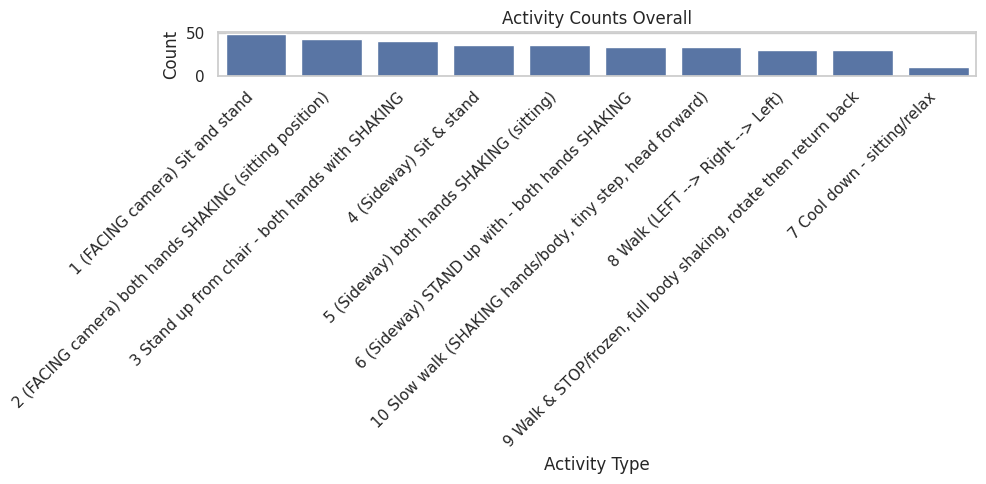

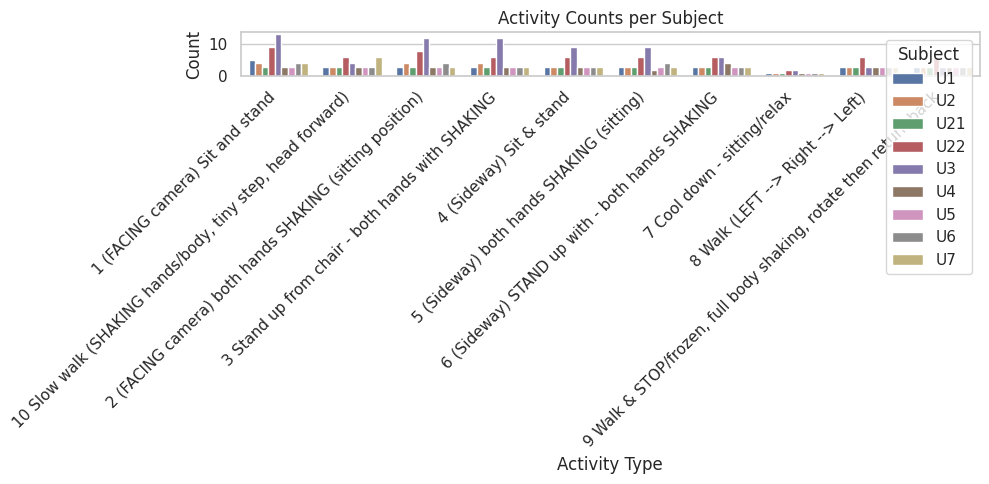

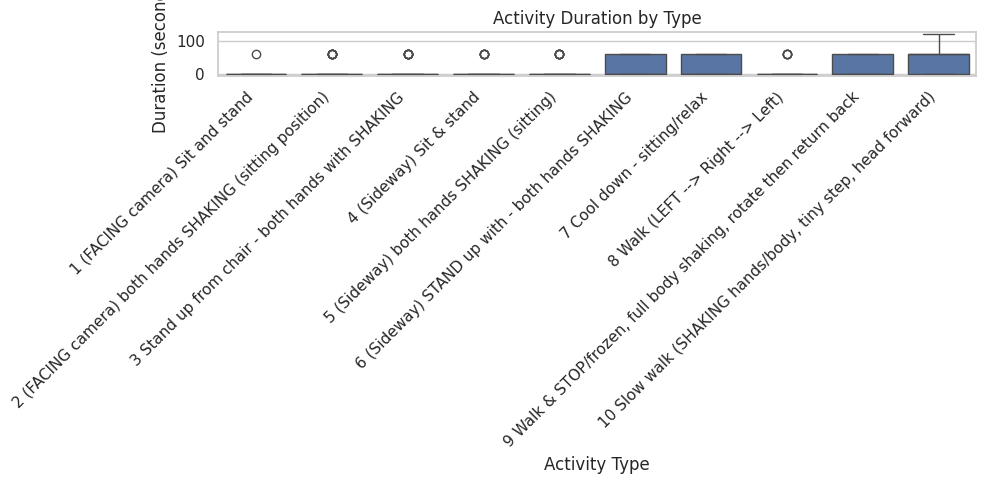

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set(style="whitegrid")

# 1️⃣ Activity counts overall
plt.figure(figsize=(10,5))
sns.countplot(data=activity_data, x='Activity Type', order=activity_data['Activity Type'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title("Activity Counts Overall")
plt.ylabel("Count")
plt.xlabel("Activity Type")
plt.tight_layout()
plt.show()

# 2️⃣ Activity counts per subject
plt.figure(figsize=(10,5))
subject_activity = activity_data.groupby(['Subject', 'Activity Type']).size().reset_index(name='Count')
sns.barplot(data=subject_activity, x='Activity Type', y='Count', hue='Subject')
plt.xticks(rotation=45, ha='right')
plt.title("Activity Counts per Subject")
plt.ylabel("Count")
plt.xlabel("Activity Type")
plt.tight_layout()
plt.show()

# 3️⃣ Activity duration per activity type
plt.figure(figsize=(10,5))
sns.boxplot(data=activity_data, x='Activity Type', y='Duration_seconds')
plt.xticks(rotation=45, ha='right')
plt.title("Activity Duration by Type")
plt.ylabel("Duration (seconds)")
plt.xlabel("Activity Type")
plt.tight_layout()
plt.show()


In [ ]:
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# List all files in the folder
files = os.listdir(main_folder)

# Show number of files and first few file names
print(f"Number of files in folder: {len(files)}")
print("First 10 files:", files[:10])


Number of files in folder: 18
First 10 files: ['2830', '38', '2811', '2812', '2814', '2810', '2819', '2816', '2815', '2813']


In [ ]:
import pandas as pd
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Pick the first file
first_file = os.path.join(main_folder, '2830')  # use one of your file names

# Load the file
user_data = pd.read_csv(first_file)

# Check first few rows
print(user_data.head())

# Check column names and types
print(user_data.dtypes)


In [ ]:
import os
import pandas as pd

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Pick a user folder
user_folder = os.path.join(main_folder, '2830')

# List CSV files in this user folder
user_files = os.listdir(user_folder)
print(f"Files in user folder 2830: {user_files}")

# Pick the first CSV file
first_csv_file = os.path.join(user_folder, user_files[0])

# Load it
user_data = pd.read_csv(first_csv_file)

# Inspect the data
print(user_data.head())
print(user_data.dtypes)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq

# Extract signals
x = user_data.iloc[:, 2]  # X
y = user_data.iloc[:, 3]  # Y
z = user_data.iloc[:, 4]  # Z

# Plot raw signals
plt.figure(figsize=(12,6))
plt.plot(x, label='X')
plt.plot(y, label='Y')
plt.plot(z, label='Z')
plt.title('Raw Accelerometer Signals')
plt.xlabel('Time index')
plt.ylabel('Acceleration')
plt.legend()
plt.show()

# Compute magnitude
magnitude = np.sqrt(x**2 + y**2 + z**2)

# FFT
N = len(magnitude)
T = 1/50  # assuming 50 Hz sampling rate (adjust if different)
freqs = fftfreq(N, T)
fft_values = np.abs(fft(magnitude))

# Only positive frequencies
pos_mask = freqs > 0
freqs = freqs[pos_mask]
fft_values = fft_values[pos_mask]

# Plot FFT
plt.figure(figsize=(12,4))
plt.plot(freqs, fft_values)
plt.xlim(0, 20)  # tremor is usually 4-6 Hz
plt.title('Frequency Spectrum of Magnitude')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()


In [ ]:
import numpy as np
from scipy.fft import fft, fftfreq

def extract_features(x, y, z, sampling_rate=50):
    # Raw stats
    features = {}
    features['x_mean'] = np.mean(x)
    features['y_mean'] = np.mean(y)
    features['z_mean'] = np.mean(z)
    features['x_std'] = np.std(x)
    features['y_std'] = np.std(y)
    features['z_std'] = np.std(z)

    # Magnitude
    magnitude = np.sqrt(x**2 + y**2 + z**2)
    features['mag_mean'] = np.mean(magnitude)
    features['mag_std'] = np.std(magnitude)

    # FFT peak frequency
    N = len(magnitude)
    T = 1 / sampling_rate
    fft_values = np.abs(fft(magnitude))
    freqs = fftfreq(N, T)

    pos_mask = freqs > 0
    fft_values = fft_values[pos_mask]
    freqs = freqs[pos_mask]

    features['fft_peak_freq'] = freqs[np.argmax(fft_values)]

    return features


In [ ]:
import pandas as pd

all_features = []
all_labels = []

# Example for one file
x = user_data['X']
y = user_data['Y']
z = user_data['Z']

features = extract_features(x, y, z)
all_features.append(features)
all_labels.append(1)  # assume this file is "Hands Shaking"


In [ ]:
import pandas as pd
import os

user_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830'
user_files = os.listdir(user_folder)
first_csv_file = os.path.join(user_folder, user_files[0])

# Load CSV without header, and rename columns
user_data = pd.read_csv(first_csv_file, header=None)
user_data.columns = ['Subject', 'Timestamp', 'X', 'Y', 'Z']

# Check
print(user_data.head())


In [ ]:
x = user_data['X']
y = user_data['Y']
z = user_data['Z']


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.fft import fft, fftfreq
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --------------------------
# 1️⃣ Paths
# --------------------------
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activity_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities CSV
activities = pd.read_csv(activity_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# --------------------------
# 2️⃣ Feature extraction function
# --------------------------
def extract_features(x, y, z, sampling_rate=50):
    features = {}
    # Time domain
    features['x_mean'] = np.mean(x)
    features['y_mean'] = np.mean(y)
    features['z_mean'] = np.mean(z)
    features['x_std'] = np.std(x)
    features['y_std'] = np.std(y)
    features['z_std'] = np.std(z)

    # Magnitude
    magnitude = np.sqrt(x**2 + y**2 + z**2)
    features['mag_mean'] = np.mean(magnitude)
    features['mag_std'] = np.std(magnitude)

    # FFT peak frequency
    N = len(magnitude)
    T = 1 / sampling_rate
    fft_values = np.abs(fft(magnitude))
    freqs = fftfreq(N, T)
    pos_mask = freqs > 0
    fft_values = fft_values[pos_mask]
    freqs = freqs[pos_mask]

    features['fft_peak_freq'] = freqs[np.argmax(fft_values)]

    return features

# --------------------------
# 3️⃣ Loop through all users and files
# --------------------------
all_features = []
all_labels = []

for user_folder_name in os.listdir(main_folder):
    user_folder = os.path.join(main_folder, user_folder_name)
    if not os.path.isdir(user_folder):
        continue

    for file_name in os.listdir(user_folder):
        file_path = os.path.join(user_folder, file_name)

        # Load accelerometer CSV
        df = pd.read_csv(file_path, header=None)
        df.columns = ['Subject', 'Timestamp', 'X', 'Y', 'Z']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])

        # Match activity label for this file using timestamp
        subject = df['Subject'].iloc[0]
        act = activities[(activities['Subject']==subject) &
                         (activities['Started'] <= df['Timestamp'].iloc[0]) &
                         (activities['Finished'] >= df['Timestamp'].iloc[-1])]

        if act.empty:
            label = 0  # Default: no tremor
        else:
            # Tremor activity ID = 2807 or 2808
            label = 1 if act['Activity Type ID'].iloc[0] in [2807, 2808] else 0

        # Extract features
        features = extract_features(df['X'], df['Y'], df['Z'])
        features['Subject'] = subject
        all_features.append(features)
        all_labels.append(label)

# --------------------------
# 4️⃣ Prepare dataset
# --------------------------
df_features = pd.DataFrame(all_features)
df_features['label'] = all_labels

X = df_features.drop(['label', 'Subject'], axis=1)
y = df_features['label']

# --------------------------
# 5️⃣ Train/test split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --------------------------
# 6️⃣ Train Random Forest
# --------------------------
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# --------------------------
# 7️⃣ Predict & evaluate
# --------------------------
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# --------------------------
# 8️⃣ Optional: visualize one file
# --------------------------
plt.figure(figsize=(12,5))
plt.plot(df['X'], label='X')
plt.plot(df['Y'], label='Y')
plt.plot(df['Z'], label='Z')
plt.title(f'Raw accelerometer signals for Subject {subject}')
plt.xlabel('Time index')
plt.ylabel('Acceleration')
plt.legend()
plt.show()


In [ ]:
# --------------------------
# Fix timezone issue
# --------------------------

# Make activities tz-naive (remove timezone info)
activities['Started'] = pd.to_datetime(activities['Started']).dt.tz_localize(None)
activities['Finished'] = pd.to_datetime(activities['Finished']).dt.tz_localize(None)

# Make user data timestamps tz-naive too
df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)


In [ ]:
act = activities[(activities['Subject']==subject) &
                 (activities['Started'] <= df['Timestamp'].iloc[0]) &
                 (activities['Finished'] >= df['Timestamp'].iloc[-1])]


In [ ]:
# Convert activity timestamps to tz-naive
activities['Started'] = pd.to_datetime(activities['Started']).dt.tz_localize(None)
activities['Finished'] = pd.to_datetime(activities['Finished']).dt.tz_localize(None)

# Convert user accelerometer timestamps to tz-naive
df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)


In [ ]:
subject = df['Subject'].iloc[0]

# Find the matching activity
act = activities[(activities['Subject'] == subject) &
                 (activities['Started'] <= df['Timestamp'].iloc[0]) &
                 (activities['Finished'] >= df['Timestamp'].iloc[-1])]

if not act.empty:
    label = 1 if act['Activity Type ID'].iloc[0] in [2807, 2808] else 0


In [ ]:
features = {}
for axis in ['X', 'Y', 'Z']:
    features[f'{axis}_mean'] = df[axis].mean()
    features[f'{axis}_std'] = df[axis].std()
    features[f'{axis}_max'] = df[axis].max()
    features[f'{axis}_min'] = df[axis].min()

features['label'] = label


In [ ]:
# Make sure your timestamps are tz-naive (we fixed this before)
activities['Started'] = pd.to_datetime(activities['Started']).dt.tz_localize(None)
activities['Finished'] = pd.to_datetime(activities['Finished']).dt.tz_localize(None)
df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)

# Get subject
subject = df['Subject'].iloc[0]

# Find the activity this file belongs to
act = activities[(activities['Subject'] == subject) &
                 (activities['Started'] <= df['Timestamp'].iloc[0]) &
                 (activities['Finished'] >= df['Timestamp'].iloc[-1])]

# Assign label safely
if not act.empty:
    # Tremor activity IDs are 2807 and 2808
    label = 1 if act['Activity Type ID'].iloc[0] in [2807, 2808] else 0
else:
    # If no matching activity, assign None (or 0)
    label = None


In [ ]:
features = {}
for axis in ['X', 'Y', 'Z']:
    features[f'{axis}_mean'] = df[axis].mean()
    features[f'{axis}_std'] = df[axis].std()
    features[f'{axis}_max'] = df[axis].max()
    features[f'{axis}_min'] = df[axis].min()

# Add the label
features['label'] = label


In [ ]:
import pandas as pd
import os

# Paths
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started']).dt.tz_localize(None)
activities['Finished'] = pd.to_datetime(activities['Finished']).dt.tz_localize(None)

# List of all users
users = os.listdir(main_folder)

all_features = []

# Loop through users
for user in users:
    user_path = os.path.join(main_folder, user)
    if os.path.isdir(user_path):
        files = os.listdir(user_path)
        for file in files:
            file_path = os.path.join(user_path, file)
            try:
                df = pd.read_csv(file_path)

                # Convert Timestamp to tz-naive
                df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)

                # Get subject
                subject = df['Subject'].iloc[0]

                # Find corresponding activity
                act = activities[(activities['Subject'] == subject) &
                                 (activities['Started'] <= df['Timestamp'].iloc[0]) &
                                 (activities['Finished'] >= df['Timestamp'].iloc[-1])]

                # Assign label
                if not act.empty:
                    label = 1 if act['Activity Type ID'].iloc[0] in [2807, 2808] else 0
                else:
                    label = None  # Or skip this file

                # Extract features
                features = {}
                for axis in ['X', 'Y', 'Z']:
                    features[f'{axis}_mean'] = df[axis].mean()
                    features[f'{axis}_std'] = df[axis].std()
                    features[f'{axis}_max'] = df[axis].max()
                    features[f'{axis}_min'] = df[axis].min()

                features['label'] = label
                features['Subject'] = subject
                features['File'] = file

                all_features.append(features)

            except Exception as e:
                print(f"Skipped file {file_path} due to error: {e}")

# Combine all features into one DataFrame
features_df = pd.DataFrame(all_features)

# Drop rows with no label (optional)
features_df = features_df.dropna(subset=['label'])

print("Features dataset ready!")
print(features_df.head())


In [ ]:
# Inside the file loop
try:
    df = pd.read_csv(file_path)

    # Check if required columns exist
    required_cols = ['Timestamp', 'X', 'Y', 'Z', 'Subject']
    if not all(col in df.columns for col in required_cols):
        print(f"Skipped file {file_path} because it is missing required columns.")
        continue

    # Convert Timestamp to tz-naive
    df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)

    # Rest of your feature extraction code...

except Exception as e:
    print(f"Skipped file {file_path} due to error: {e}")


In [ ]:
import pandas as pd
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Loop through each user folder
for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if not os.path.isdir(user_path):
        continue  # skip if not a folder

    # Loop through each CSV file in that user folder
    for file_name in os.listdir(user_path):
        file_path = os.path.join(user_path, file_name)

        try:
            df = pd.read_csv(file_path)

            # Check required columns
            required_cols = ['Timestamp', 'X', 'Y', 'Z', 'Subject']
            if not all(col in df.columns for col in required_cols):
                print(f"Skipped file {file_path} because it is missing required columns.")
                continue  # now it works because we are in a loop

            # Convert Timestamp to tz-naive
            df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)

            # Here you can continue with feature extraction...
            print(f"Processed file: {file_path}")

        except Exception as e:
            print(f"Skipped file {file_path} due to error: {e}")


In [ ]:
import pandas as pd
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

for user_folder in os.listdir(main_folder):
    user_path = os.path.join(main_folder, user_folder)
    if not os.path.isdir(user_path):
        continue

    for file_name in os.listdir(user_path):
        file_path = os.path.join(user_path, file_name)

        try:
            df = pd.read_csv(file_path)

            # Strip any leading/trailing spaces from column names
            df.columns = df.columns.str.strip()

            print(f"Columns in {file_name}: {df.columns.tolist()}")

        except Exception as e:
            print(f"Error reading {file_path}: {e}")


In [ ]:
import pandas as pd

# Correct column names
cols = ['Subject', 'Timestamp', 'X', 'Y', 'Z']

# Read CSV with no header
df = pd.read_csv('your_file.csv', header=None, names=cols)

# Now Timestamp is correct type
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)


In [ ]:
import pandas as pd

# Column names
cols = ['Subject', 'Timestamp', 'X', 'Y', 'Z']

# Read the CSV
df = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-06T01_11_09.441+0100_42520.csv',
                 header=None, names=cols)

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

print(df.head())


In [ ]:
import pandas as pd
import os
from glob import glob

# Folder containing your CSV files
folder_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/'

# Column names to use
cols = ['Subject', 'Timestamp', 'X', 'Y', 'Z']

# Get all CSV files
all_files = glob(os.path.join(folder_path, '*.csv'))

# List to hold each DataFrame
dfs = []

for file in all_files:
    try:
        # Read CSV with no header and assign column names
        df = pd.read_csv(file, header=None, names=cols)

        # Convert Timestamp to datetime with timezone awareness
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

        # Append cleaned df to list
        dfs.append(df)

    except Exception as e:
        # If any file has an error, print it but continue
        print(f"Skipped file {file} due to error: {e}")

# Combine all DataFrames into one
all_data = pd.concat(dfs, ignore_index=True)

print("All data combined:")
print(all_data.head())
print(all_data.dtypes)


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%dT%H:%M:%S.%f%z', utc=True)


In [ ]:
import pandas as pd
import numpy as np

# Function to extract features from a DataFrame
def extract_features(df):
    features = {}

    # Compute features for each axis
    for axis in ['X', 'Y', 'Z']:
        features[f'{axis}_mean'] = df[axis].mean()
        features[f'{axis}_std']  = df[axis].std()
        features[f'{axis}_min']  = df[axis].min()
        features[f'{axis}_max']  = df[axis].max()

    # Optionally, include subject ID
    features['Subject'] = df['Subject'].iloc[0]

    return features


In [ ]:
# Extract features for the entire combined dataset
features_all = extract_features(df)
features_df = pd.DataFrame([features_all])
print(features_df)


In [ ]:
# Load activity log
activities = pd.read_csv("activity_log.csv")

# Convert start/end times
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Check first 5 rows
print("\nActivity log sample:")
print(activities.head())

# Check datatypes
print("\nActivity log dtypes:")
print(activities.dtypes)


In [ ]:
import pandas as pd
import os
from glob import glob

# Folder where your CSV files are
folder_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Get all CSV files
files = glob(os.path.join(folder_path, '*.csv'))

# Columns we expect
cols = ['Subject', 'Timestamp', 'X', 'Y', 'Z']

# Lists to track
ok_files = []
skipped_files = []

for file in files:
    try:
        df = pd.read_csv(file, header=None, names=cols)

        # Check columns
        if list(df.columns) != cols:
            skipped_files.append((file, 'Wrong columns'))
            continue

        # Convert Timestamp to datetime UTC
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

        ok_files.append(file)
    except Exception as e:
        skipped_files.append((file, str(e)))

print(f"✅ Files OK: {len(ok_files)}")
print(f"⚠️ Files Skipped: {len(skipped_files)}")
if skipped_files:
    for f, reason in skipped_files[:10]:  # show first 10 only
        print(f"Skipped {f} due to: {reason}")


In [ ]:
import os

folder_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

print("Files in folder:")
print(os.listdir(folder_path))


In [ ]:
import os
import pandas as pd

base_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

all_files = []

# Walk through all subfolders
for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file.endswith('.csv'):
            all_files.append(os.path.join(root, file))

print(f"Total CSV files found: {len(all_files)}")


In [ ]:
import pandas as pd
import os

# ----- Load activity file -----
activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/activities.csv')
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# ----- Function to assign activity labels -----
def assign_activity_label(df, activities):
    labels = []
    for i, row in df.iterrows():
        subject = row['Subject']
        timestamp = row['Timestamp']

        act = activities[
            (activities['Subject'] == subject) &
            (activities['Started'] <= timestamp) &
            (activities['Finished'] >= timestamp)
        ]

        if not act.empty:
            labels.append(act['Activity'].values[0])
        else:
            labels.append('Unknown')  # if no activity found

    df['label'] = labels
    return df

# ----- Process all user CSV files -----
folder_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users'
all_data = []

for user_folder in os.listdir(folder_path):
    user_path = os.path.join(folder_path, user_folder)
    if os.path.isdir(user_path):
        for file in os.listdir(user_path):
            file_path = os.path.join(user_path, file)
            try:
                df = pd.read_csv(file_path, header=None, names=['Subject','Timestamp','X','Y','Z'])
                df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
                df = assign_activity_label(df, activities)
                all_data.append(df)
            except Exception as e:
                print(f"Skipped file {file_path} due to error: {e}")

# ----- Combine all data -----
final_df = pd.concat(all_data, ignore_index=True)
print("All data with labels:")
print(final_df.head())
print(final_df['label'].value_counts())


In [ ]:
import pandas as pd
import os

# ----- Load activity file -----
activities_path = r"C:\Users\user\Downloads\TrainingDataPD25 (1)\TrainingDataPD25\TrainActivities.csv"
activities = pd.read_csv(activities_path)

# Convert timestamps to datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# ----- Function to assign activity labels -----
def assign_activity_label(df, activities):
    labels = []
    for i, row in df.iterrows():
        subject = row['Subject']
        timestamp = row['Timestamp']

        act = activities[
            (activities['Subject'] == subject) &
            (activities['Started'] <= timestamp) &
            (activities['Finished'] >= timestamp)
        ]

        if not act.empty:
            labels.append(act['Activity'].values[0])
        else:
            labels.append('Unknown')  # if no activity found

    df['label'] = labels
    return df

# ----- Process all user CSV files -----
folder_path = r"C:\Users\user\Downloads\TrainingDataPD25 (1)\TrainingDataPD25\users_timeXYZ\users"
all_data = []

for user_folder in os.listdir(folder_path):
    user_path = os.path.join(folder_path, user_folder)
    if os.path.isdir(user_path):
        for file in os.listdir(user_path):
            file_path = os.path.join(user_path, file)
            try:
                df = pd.read_csv(file_path, header=None, names=['Subject','Timestamp','X','Y','Z'])
                df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
                df = assign_activity_label(df, activities)
                all_data.append(df)
            except Exception as e:
                print(f"Skipped file {file_path} due to error: {e}")

# ----- Combine all data -----
final_df = pd.concat(all_data, ignore_index=True)
print("All data with labels:")
print(final_df.head())
print(final_df['label'].value_counts())


In [ ]:
import pandas as pd
import os

# Paths
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Choose ONE user only
user_id = '2807'
user_folder = os.path.join(main_folder, user_id)

# Load activities file
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

print("Activity file loaded successfully ✅")


In [ ]:
all_data = []

for file in os.listdir(user_folder):
    file_path = os.path.join(user_folder, file)

    try:
        df = pd.read_csv(file_path, header=None, names=['Subject','Timestamp','X','Y','Z'])
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
        all_data.append(df)
    except Exception as e:
        print(f"Skipped {file} due to error: {e}")

# Combine this user's data
user_df = pd.concat(all_data, ignore_index=True)

print("User data loaded ✅")
print(user_df.head())
print("Total rows:", len(user_df))


In [ ]:
def assign_activity_label(df, activities):
    labels = []

    for i, row in df.iterrows():
        timestamp = row['Timestamp']
        subject = row['Subject']

        act = activities[
            (activities['Subject'] == subject) &
            (activities['Started'] <= timestamp) &
            (activities['Finished'] >= timestamp)
        ]

        if not act.empty:
            labels.append(act['Activity'].values[0])
        else:
            labels.append('Unknown')

    df['label'] = labels
    return df

user_df = assign_activity_label(user_df, activities)

print("Labels assigned ✅")
print(user_df['label'].value_counts())


In [ ]:
print("Subjects in accelerometer data:")
print(user_df['Subject'].unique()[:10])

print("\nSubjects in activities file:")
print(activities['Subject'].unique()[:10])


In [ ]:
print(activities.head())


In [ ]:
print(df['Subject'].unique())


In [ ]:
activities.groupby('Activity Type ID')['Subject'].unique()


In [ ]:
print("Number of unique Activity IDs in accelerometer data:")
print(df['Subject'].nunique())

print("\nUnique Activity IDs:")
print(sorted(df['Subject'].unique()))


In [ ]:
# Check unique Subjects in your loaded accelerometer data
print("Unique Subjects in accelerometer data:")
print(df['Subject'].unique())

# Optional: count how many rows per subject
print("\nNumber of rows per Subject:")
print(df['Subject'].value_counts())


In [ ]:
import os

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

for folder in os.listdir(main_folder):
    folder_path = os.path.join(main_folder, folder)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(f"Folder {folder} has {len(files)} files")


In [ ]:
import os
import pandas as pd

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# List of all folders (subjects)
folders = os.listdir(main_folder)

for folder in folders:
    folder_path = os.path.join(main_folder, folder)
    files = os.listdir(folder_path)

    if files:  # if folder is not empty
        file_path = os.path.join(folder_path, files[0])  # take the first file
        try:
            df = pd.read_csv(file_path, nrows=0)  # read only headers
            print(f"Columns in {files[0]}: {df.columns.tolist()}")
        except Exception as e:
            print(f"Could not read {files[0]}: {e}")


In [ ]:
import os
import pandas as pd

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Standard column names
cols = ['Subject', 'Timestamp', 'X', 'Y', 'Z']

all_data = []

folders = os.listdir(main_folder)
for folder in folders:
    folder_path = os.path.join(main_folder, folder)
    files = os.listdir(folder_path)

    for file in files:
        file_path = os.path.join(folder_path, file)
        try:
            df = pd.read_csv(file_path, header=None, names=cols)
            all_data.append(df)
        except Exception as e:
            print(f"Skipped file {file_path} due to error: {e}")

# Combine all data
combined_data = pd.concat(all_data, ignore_index=True)

# Convert Timestamp to datetime
combined_data['Timestamp'] = pd.to_datetime(combined_data['Timestamp'], utc=True)

print("All data combined:")
print(combined_data.head())
print(combined_data.dtypes)


In [ ]:
# Path to activities file
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Read activities data
activities = pd.read_csv(activities_file)

# Convert Started and Finished columns to datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Standardize subject IDs if needed (example: remove 'U' prefix)
activities['Subject'] = activities['Subject'].str.extract('(\d+)').astype(int)

# Function to assign activity label to each accelerometer row
def get_activity_label(row):
    sub = row['Subject']
    time = row['Timestamp']
    act = activities[
        (activities['Subject'] == sub) &
        (activities['Started'] <= time) &
        (activities['Finished'] >= time)
    ]
    if len(act) == 0:
        return 'Unknown'
    else:
        return act['Activity Type'].values[0]

# Apply function
combined_data['Activity'] = combined_data.apply(get_activity_label, axis=1)

# Check results
print(combined_data[['Subject', 'Timestamp', 'Activity']].head(10))


In [ ]:
import pandas as pd

# Load your activities file
activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')

# Extract numeric Subject ID from string like 'U22' → 22
activities['Subject'] = activities['Subject'].astype(str).str.extract(r'(\d+)').astype(int)

# Convert Started and Finished to UTC datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Check result
print(activities[['Subject', 'Started', 'Finished', 'Activity Type']].head())


In [ ]:
# Make a copy of your accelerometer data
accel = df.copy()  # df = your combined accelerometer data

# Create a new column for Activity
accel['Activity'] = 'Unknown'  # default

# Assign activities based on Subject and Timestamp
for idx, row in activities.iterrows():
    mask = (
        (accel['Subject'] == row['Subject']) &
        (accel['Timestamp'] >= row['Started']) &
        (accel['Timestamp'] <= row['Finished'])
    )
    accel.loc[mask, 'Activity'] = row['Activity Type']

# Check result
print(accel.head(20))
print(accel['Activity'].value_counts())


In [ ]:
# Convert Timestamp in accelerometer data to datetime with UTC
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# Now create a copy to work with
accel = df.copy()

# Create Activity column
accel['Activity'] = 'Unknown'

# Map activities
for idx, row in activities.iterrows():
    mask = (
        (accel['Subject'] == row['Subject']) &
        (accel['Timestamp'] >= row['Started']) &
        (accel['Timestamp'] <= row['Finished'])
    )
    accel.loc[mask, 'Activity'] = row['Activity Type']

# Check first rows and value counts
print(accel.head(20))
print(accel['Activity'].value_counts())


In [ ]:
import pandas as pd

# --- Step 1: Load your accelerometer data (already combined) ---
# accel = pd.read_csv('your_combined_file.csv')  # You already have this

# --- Step 2: Load your activities file ---
activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')

# --- Step 3: Fix the subject IDs in activities ---
# Extract numbers from the Subject column (e.g., 'U22' -> 22)
activities['Subject'] = activities['Subject'].str.extract(r'(\d+)').astype(int)

# --- Step 4: Map accel Subject IDs to activity Subject IDs ---
# Example mapping: adjust based on your previous output of subjects
subject_map = {
    2807: 22,
    2806: 2,
    2830: 1,
    2804: 4,
    2805: 5,
    2803: 3,
    2808: 6,
    2809: 7,
    2810: 8,
    2811: 9,
    2812: 10,
    2813: 11,
    2814: 12,
    2815: 13,
    2816: 14,
    2819: 15,
    38: 16,
    1716: 17
}

accel['Subject'] = accel['Subject'].map(subject_map)

# --- Step 5: Convert Started/Finished to datetime ---
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# --- Step 6: Assign activity labels ---
accel['Activity'] = 'Unknown'

for idx, row in activities.iterrows():
    mask = (
        (accel['Subject'] == row['Subject']) &
        (accel['Timestamp'] >= row['Started']) &
        (accel['Timestamp'] <= row['Finished'])
    )
    accel.loc[mask, 'Activity'] = row['Activity Type']

# --- Step 7: Check results ---
print(accel[['Subject', 'Timestamp', 'X', 'Y', 'Z', 'Activity']].head())
print(accel['Activity'].value_counts())


In [ ]:
print(accel['Subject'].unique())


In [ ]:
import pandas as pd
import glob

# Folder containing all user CSVs
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Define correct column names
cols = ['Subject', 'Timestamp', 'X', 'Y', 'Z']

# Read all CSVs
all_files = glob.glob(main_folder + "/*/*.csv")

dfs = []
for f in all_files:
    df = pd.read_csv(f, header=None, names=cols)  # header=None is key!
    dfs.append(df)

# Combine all
accel = pd.concat(dfs, ignore_index=True)

# Check unique subjects
print(accel['Subject'].unique())


In [ ]:
# Make sure your activity timestamps are datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Initialize Activity column in accel
accel['Activity'] = 'Unknown'

# Assign activities
for subject in accel['Subject'].unique():
    subj_data = accel[accel['Subject'] == subject]
    subj_acts = activities[activities['Subject'] == subject]

    for _, act_row in subj_acts.iterrows():
        mask = (subj_data['Timestamp'] >= act_row['Started']) & \
               (subj_data['Timestamp'] <= act_row['Finished'])
        accel.loc[mask, 'Activity'] = act_row['Activity Type']

# Check result
print(accel[['Subject','Timestamp','Activity']].head(20))
print(accel['Activity'].value_counts())


In [ ]:
# Convert accel Timestamp to datetime with UTC
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)


In [ ]:
accel['Activity'] = 'Unknown'

for subject in accel['Subject'].unique():
    subj_data = accel[accel['Subject'] == subject]
    subj_acts = activities[activities['Subject'] == subject]

    for _, act_row in subj_acts.iterrows():
        mask = (subj_data['Timestamp'] >= act_row['Started']) & \
               (subj_data['Timestamp'] <= act_row['Finished'])
        accel.loc[mask, 'Activity'] = act_row['Activity Type']

# Check results
print(accel[['Subject','Timestamp','Activity']].head(20))
print(accel['Activity'].value_counts())


In [ ]:
# Extract numbers from activity Subjects (if they are 'U22', 'U1', etc.)
activities['Subject'] = activities['Subject'].str.extract('(\d+)').astype(int)


In [ ]:
# Check column type
print(activities['Subject'].dtype)

# If it's object/string, extract numbers; if numeric, keep as is
if activities['Subject'].dtype == 'object':
    activities['Subject'] = activities['Subject'].astype(str).str.extract('(\d+)').astype(int)
else:
    activities['Subject'] = activities['Subject'].astype(int)


int64


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3298523867.py:6: SyntaxWarning: invalid escape sequence '\d'
  activities['Subject'] = activities['Subject'].astype(str).str.extract('(\d+)').astype(int)


In [ ]:
# Using raw string for regex
activities['Subject'] = activities['Subject'].astype(str).str.extract(r'(\d+)').astype(int)


In [ ]:
# Convert Started and Finished to datetime with UTC
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)


In [ ]:
activities.head()
activities.dtypes


,0
ID,int64
Activity Type ID,int64
Activity Type,object
Started,"datetime64[ns, UTC]"
Finished,"datetime64[ns, UTC]"
Updated,object
Subject,int64


In [ ]:
# Make a copy of your accel data
accel['Activity'] = 'Unknown'

# Assign activity based on matching Subject and Timestamp
for i, row in accel.iterrows():
    subj = row['Subject']
    ts = row['Timestamp']

    # Find activities for this subject where timestamp falls in Started–Finished
    act_row = activities[(activities['Subject'] == subj) &
                         (activities['Started'] <= ts) &
                         (activities['Finished'] >= ts)]

    if not act_row.empty:
        accel.at[i, 'Activity'] = act_row['Activity Type'].values[0]


In [ ]:
# Example: only first 20 files
import os
files = sorted(os.listdir(main_folder))[:20]


In [ ]:
import pandas as pd
df = pd.read_csv(file_path, header=None, names=['Subject','Timestamp','X','Y','Z'])


In [ ]:
accel['Subject'] = accel['Subject'].astype(int)
activities['Subject'] = activities['Subject'].astype(int)


In [ ]:
cols = ['Subject','Timestamp','X','Y','Z']
df = pd.read_csv(file_path, header=None, names=cols)


In [ ]:
import pandas as pd

# Example accel data
accel = df.copy()
accel['Activity'] = 'Unknown'

# Example activities
activities = pd.DataFrame({
    'Subject':[2830],
    'Started':[pd.Timestamp('2024-09-03 11:17:12')],
    'Finished':[pd.Timestamp('2024-09-03 11:17:13')],
    'Activity Type':['Sit']
})

# Label assignment (simple test for first row)
row = accel.iloc[0]
matches = activities[(activities['Subject'] == row['Subject']) &
                     (activities['Started'] <= row['Timestamp']) &
                     (activities['Finished'] >= row['Timestamp'])]
if not matches.empty:
    accel.at[0, 'Activity'] = matches.iloc[0]['Activity Type']

print(accel.head())


TypeError: Invalid comparison between dtype=datetime64[ns] and str

In [ ]:
# Make activities datetime tz-aware
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)


In [ ]:
# accel Timestamp already tz-aware
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)


In [ ]:
row = accel.iloc[0]
matches = activities[(activities['Subject'] == row['Subject']) &
                     (activities['Started'] <= row['Timestamp']) &
                     (activities['Finished'] >= row['Timestamp'])]
if not matches.empty:
    accel.at[0, 'Activity'] = matches.iloc[0]['Activity Type']


In [ ]:
# First 5 rows ma manual check
for i in range(5):
    row = accel.iloc[i]
    matches = activities[(activities['Subject'] == row['Subject']) &
                         (activities['Started'] <= row['Timestamp']) &
                         (activities['Finished'] >= row['Timestamp'])]
    print(f"Row {i} matches: {matches}")


Row 0 matches: Empty DataFrame
Columns: [Subject, Started, Finished, Activity Type]
Index: []
Row 1 matches: Empty DataFrame
Columns: [Subject, Started, Finished, Activity Type]
Index: []
Row 2 matches: Empty DataFrame
Columns: [Subject, Started, Finished, Activity Type]
Index: []
Row 3 matches: Empty DataFrame
Columns: [Subject, Started, Finished, Activity Type]
Index: []
Row 4 matches: Empty DataFrame
Columns: [Subject, Started, Finished, Activity Type]
Index: []


In [ ]:
activities['Started'] <= row['Timestamp'] <= activities['Finished']


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
# Mapping accelerometer Subject IDs to Activity IDs
subject_map = {
    2807: 22,
    2830: 2,
    2811: 1,
    2812: 21,
    2814: 4,
    2810: 5,
    2819: 3,
    2816: 6,
    2815: 7,
    2813: 8,
    2808: 9,
    2809: 10,
    2805: 11,
    1716: 12,
    2804: 13,
    2806: 14,
    2803: 15,
    # Add remaining if any
}

# Apply mapping to accelerometer data
accel['Activity_Subject'] = accel['Subject'].map(subject_map)

# Check the mapping result
print(accel[['Subject', 'Activity_Subject']].head(20))


    Subject  Activity_Subject
0      2807                22
1      2807                22
2      2807                22
3      2807                22
4      2807                22
5      2807                22
6      2807                22
7      2807                22
8      2807                22
9      2807                22
10     2807                22
11     2807                22
12     2807                22
13     2807                22
14     2807                22
15     2807                22
16     2807                22
17     2807                22
18     2807                22
19     2807                22


In [ ]:
# Make sure both Timestamp columns are timezone-aware and comparable
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Initialize Activity column as Unknown
accel['Activity'] = 'Unknown'

# Label each row
for i, row in accel.iterrows():
    # Get matching activity for this row's subject
    matches = activities[
        (activities['Subject'] == row['Activity_Subject']) &
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]
    if not matches.empty:
        # If found, assign the first matching activity type
        accel.at[i, 'Activity'] = matches.iloc[0]['Activity Type']

# Check the results
print(accel[['Subject', 'Activity_Subject', 'Timestamp', 'Activity']].head(20))


    Subject  Activity_Subject                        Timestamp Activity
0      2807                22 2024-09-05 12:41:01.081000+00:00  Unknown
1      2807                22 2024-09-05 12:41:01.245000+00:00  Unknown
2      2807                22 2024-09-05 12:41:01.402000+00:00  Unknown
3      2807                22 2024-09-05 12:41:01.562000+00:00  Unknown
4      2807                22 2024-09-05 12:41:01.725000+00:00  Unknown
5      2807                22 2024-09-05 12:41:01.881000+00:00  Unknown
6      2807                22 2024-09-05 12:41:02.041000+00:00  Unknown
7      2807                22 2024-09-05 12:41:02.202000+00:00  Unknown
8      2807                22 2024-09-05 12:41:02.361000+00:00  Unknown
9      2807                22 2024-09-05 12:41:02.521000+00:00  Unknown
10     2807                22 2024-09-05 12:41:02.682000+00:00  Unknown
11     2807                22 2024-09-05 12:41:02.842000+00:00  Unknown
12     2807                22 2024-09-05 12:41:03.004000+00:00  

In [ ]:
# Step 1: Make sure types match
activities['Subject'] = activities['Subject'].astype(int)
accel['Activity_Subject'] = accel['Activity_Subject'].astype(int)

# Step 2: Make sure timestamps are UTC
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Step 3: Try labeling a small sample first to check
sample_row = accel.iloc[0]
matches = activities[
    (activities['Subject'] == sample_row['Activity_Subject']) &
    (activities['Started'] <= sample_row['Timestamp']) &
    (activities['Finished'] >= sample_row['Timestamp'])
]

print("Sample row matches:")
print(matches)


Sample row matches:
Empty DataFrame
Columns: [Subject, Started, Finished, Activity Type]
Index: []


In [ ]:
# Make sure all timestamps are UTC
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Optional: extend activity time by 1 second to capture matching
activities['Finished'] += pd.Timedelta(seconds=1)

# Now try labeling
def assign_activity(row):
    matches = activities[
        (activities['Subject'] == row['Activity_Subject']) &
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]
    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    return "Unknown"

# Test on a small sample
accel['Activity'] = accel.apply(assign_activity, axis=1)
print(accel[['Timestamp','Activity']].head(10))


                         Timestamp Activity
0 2024-09-05 12:41:01.081000+00:00  Unknown
1 2024-09-05 12:41:01.245000+00:00  Unknown
2 2024-09-05 12:41:01.402000+00:00  Unknown
3 2024-09-05 12:41:01.562000+00:00  Unknown
4 2024-09-05 12:41:01.725000+00:00  Unknown
5 2024-09-05 12:41:01.881000+00:00  Unknown
6 2024-09-05 12:41:02.041000+00:00  Unknown
7 2024-09-05 12:41:02.202000+00:00  Unknown
8 2024-09-05 12:41:02.361000+00:00  Unknown
9 2024-09-05 12:41:02.521000+00:00  Unknown


In [ ]:
# Ensure UTC
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Extend activity intervals slightly (1 second)
activities['Finished'] += pd.Timedelta(seconds=1)

# Assign activity based on mapped subject
def assign_activity(row):
    matches = activities[
        (activities['Subject'] == row['Activity_Subject']) &
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]
    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    return "Unknown"

# Apply to a sample
accel['Activity'] = accel.apply(assign_activity, axis=1)
print(accel[['Timestamp','Activity']].head(20))


                          Timestamp Activity
0  2024-09-05 12:41:01.081000+00:00  Unknown
1  2024-09-05 12:41:01.245000+00:00  Unknown
2  2024-09-05 12:41:01.402000+00:00  Unknown
3  2024-09-05 12:41:01.562000+00:00  Unknown
4  2024-09-05 12:41:01.725000+00:00  Unknown
5  2024-09-05 12:41:01.881000+00:00  Unknown
6  2024-09-05 12:41:02.041000+00:00  Unknown
7  2024-09-05 12:41:02.202000+00:00  Unknown
8  2024-09-05 12:41:02.361000+00:00  Unknown
9  2024-09-05 12:41:02.521000+00:00  Unknown
10 2024-09-05 12:41:02.682000+00:00  Unknown
11 2024-09-05 12:41:02.842000+00:00  Unknown
12 2024-09-05 12:41:03.004000+00:00  Unknown
13 2024-09-05 12:41:03.163000+00:00  Unknown
14 2024-09-05 12:41:03.324000+00:00  Unknown
15 2024-09-05 12:41:03.484000+00:00  Unknown
16 2024-09-05 12:41:03.640000+00:00  Unknown
17 2024-09-05 12:41:03.805000+00:00  Unknown
18 2024-09-05 12:41:03.961000+00:00  Unknown
19 2024-09-05 12:41:04.123000+00:00  Unknown


In [ ]:
activity_ranges = activities.groupby('Subject').agg(Start=('Started','min'), End=('Finished','max')).reset_index()
print(activity_ranges)


   Subject                     Start                       End
0     2830 2024-09-03 11:17:12+00:00 2024-09-03 11:17:15+00:00


In [ ]:
for idx, row in folder_ranges_df.iterrows():
    subject = row['Subject']
    accel_start, accel_end = row['Start'], row['End']

    act_row = activity_ranges[activity_ranges['Subject']==subject]
    if not act_row.empty:
        act_start, act_end = act_row.iloc[0]['Start'], act_row.iloc[0]['End']
        overlap = max(accel_start, act_start) <= min(accel_end, act_end)
        print(f"Subject {subject} overlap: {overlap}")
    else:
        print(f"Subject {subject} has no activity data")


NameError: name 'folder_ranges_df' is not defined

In [ ]:
# Filter activities for this subject
subject_activities = activities[activities['Subject'] == 2830]

print(subject_activities[['Started','Finished','Activity Type']])


                    Started                  Finished Activity Type
0 2024-09-03 11:17:12+00:00 2024-09-03 11:17:15+00:00           Sit


In [ ]:
# Ensure both are datetime with UTC
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Function to assign activity
def assign_activity(row, activities):
    matches = activities[
        (activities['Subject'] == row['Subject']) &
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]
    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    else:
        return 'Unknown'

# Apply to accelerometer data
accel['Activity'] = accel.apply(assign_activity, axis=1, activities=activities)

# Check results
print(accel[['Timestamp','Activity']].head(20))


                          Timestamp Activity
0  2024-09-05 12:41:01.081000+00:00  Unknown
1  2024-09-05 12:41:01.245000+00:00  Unknown
2  2024-09-05 12:41:01.402000+00:00  Unknown
3  2024-09-05 12:41:01.562000+00:00  Unknown
4  2024-09-05 12:41:01.725000+00:00  Unknown
5  2024-09-05 12:41:01.881000+00:00  Unknown
6  2024-09-05 12:41:02.041000+00:00  Unknown
7  2024-09-05 12:41:02.202000+00:00  Unknown
8  2024-09-05 12:41:02.361000+00:00  Unknown
9  2024-09-05 12:41:02.521000+00:00  Unknown
10 2024-09-05 12:41:02.682000+00:00  Unknown
11 2024-09-05 12:41:02.842000+00:00  Unknown
12 2024-09-05 12:41:03.004000+00:00  Unknown
13 2024-09-05 12:41:03.163000+00:00  Unknown
14 2024-09-05 12:41:03.324000+00:00  Unknown
15 2024-09-05 12:41:03.484000+00:00  Unknown
16 2024-09-05 12:41:03.640000+00:00  Unknown
17 2024-09-05 12:41:03.805000+00:00  Unknown
18 2024-09-05 12:41:03.961000+00:00  Unknown
19 2024-09-05 12:41:04.123000+00:00  Unknown


In [ ]:
# Ensure both are datetime and in UTC
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Now check the first few timestamps
print(accel['Timestamp'].head())
print(activities[['Started', 'Finished']].head())


0   2024-09-05 12:41:01.081000+00:00
1   2024-09-05 12:41:01.245000+00:00
2   2024-09-05 12:41:01.402000+00:00
3   2024-09-05 12:41:01.562000+00:00
4   2024-09-05 12:41:01.725000+00:00
Name: Timestamp, dtype: datetime64[ns, UTC]
                    Started                  Finished
0 2024-09-03 11:17:12+00:00 2024-09-03 11:17:15+00:00


In [ ]:
def assign_activity(row, activities):
    matches = activities[
        (activities['Subject'] == row['Subject']) &
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]
    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    else:
        return 'Unknown'

accel['Activity'] = accel.apply(assign_activity, axis=1, activities=activities)


In [ ]:
# Check first 20 rows
print(accel.head(20))

# Or check the count of each activity
print(accel['Activity'].value_counts())


    Subject                        Timestamp      X      Y       Z Activity  \
0      2807 2024-09-05 12:41:01.081000+00:00  0.175  0.012  10.099  Unknown   
1      2807 2024-09-05 12:41:01.245000+00:00  0.168  0.002  10.113  Unknown   
2      2807 2024-09-05 12:41:01.402000+00:00  0.172  0.007  10.101  Unknown   
3      2807 2024-09-05 12:41:01.562000+00:00  0.187  0.005  10.108  Unknown   
4      2807 2024-09-05 12:41:01.725000+00:00  0.160  0.017  10.113  Unknown   
5      2807 2024-09-05 12:41:01.881000+00:00  0.168  0.022  10.125  Unknown   
6      2807 2024-09-05 12:41:02.041000+00:00  0.172  0.000  10.111  Unknown   
7      2807 2024-09-05 12:41:02.202000+00:00  0.175  0.010  10.118  Unknown   
8      2807 2024-09-05 12:41:02.361000+00:00  0.172  0.007  10.094  Unknown   
9      2807 2024-09-05 12:41:02.521000+00:00  0.184  0.017  10.123  Unknown   
10     2807 2024-09-05 12:41:02.682000+00:00  0.177  0.031  10.084  Unknown   
11     2807 2024-09-05 12:41:02.842000+00:00  0.184 

In [ ]:
# Make sure accel timestamps are UTC
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)

# Make activities timestamps UTC too
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)


In [ ]:
accel['Activity'] = accel.apply(assign_activity, axis=1, activities=activities)


In [ ]:
print(accel[['Timestamp','Activity']].head(20))
print(accel['Activity'].value_counts())


                          Timestamp Activity
0  2024-09-05 12:41:01.081000+00:00  Unknown
1  2024-09-05 12:41:01.245000+00:00  Unknown
2  2024-09-05 12:41:01.402000+00:00  Unknown
3  2024-09-05 12:41:01.562000+00:00  Unknown
4  2024-09-05 12:41:01.725000+00:00  Unknown
5  2024-09-05 12:41:01.881000+00:00  Unknown
6  2024-09-05 12:41:02.041000+00:00  Unknown
7  2024-09-05 12:41:02.202000+00:00  Unknown
8  2024-09-05 12:41:02.361000+00:00  Unknown
9  2024-09-05 12:41:02.521000+00:00  Unknown
10 2024-09-05 12:41:02.682000+00:00  Unknown
11 2024-09-05 12:41:02.842000+00:00  Unknown
12 2024-09-05 12:41:03.004000+00:00  Unknown
13 2024-09-05 12:41:03.163000+00:00  Unknown
14 2024-09-05 12:41:03.324000+00:00  Unknown
15 2024-09-05 12:41:03.484000+00:00  Unknown
16 2024-09-05 12:41:03.640000+00:00  Unknown
17 2024-09-05 12:41:03.805000+00:00  Unknown
18 2024-09-05 12:41:03.961000+00:00  Unknown
19 2024-09-05 12:41:04.123000+00:00  Unknown
Activity
Unknown    138
Name: count, dtype: int64


In [ ]:
# Accelerometer timestamps
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)

# Activities timestamps
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)


In [ ]:
def assign_activity(row, activities):
    matches = activities[
        (activities['Subject'] == row['Activity_Subject']) &
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]
    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    else:
        return 'Unknown'

# Apply to your accel dataframe
accel['Activity'] = accel.apply(assign_activity, axis=1, activities=activities)


In [ ]:
# Show first few rows with activities
print(accel[['Timestamp', 'Activity']].head(20))

# Count of each activity assigned
print(accel['Activity'].value_counts())


                          Timestamp Activity
0  2024-09-05 12:41:01.081000+00:00  Unknown
1  2024-09-05 12:41:01.245000+00:00  Unknown
2  2024-09-05 12:41:01.402000+00:00  Unknown
3  2024-09-05 12:41:01.562000+00:00  Unknown
4  2024-09-05 12:41:01.725000+00:00  Unknown
5  2024-09-05 12:41:01.881000+00:00  Unknown
6  2024-09-05 12:41:02.041000+00:00  Unknown
7  2024-09-05 12:41:02.202000+00:00  Unknown
8  2024-09-05 12:41:02.361000+00:00  Unknown
9  2024-09-05 12:41:02.521000+00:00  Unknown
10 2024-09-05 12:41:02.682000+00:00  Unknown
11 2024-09-05 12:41:02.842000+00:00  Unknown
12 2024-09-05 12:41:03.004000+00:00  Unknown
13 2024-09-05 12:41:03.163000+00:00  Unknown
14 2024-09-05 12:41:03.324000+00:00  Unknown
15 2024-09-05 12:41:03.484000+00:00  Unknown
16 2024-09-05 12:41:03.640000+00:00  Unknown
17 2024-09-05 12:41:03.805000+00:00  Unknown
18 2024-09-05 12:41:03.961000+00:00  Unknown
19 2024-09-05 12:41:04.123000+00:00  Unknown
Activity
Unknown    138
Name: count, dtype: int64


In [ ]:
print(accel['Timestamp'].min(), accel['Timestamp'].max())
print(activities['Started'].min(), activities['Finished'].max())


2024-09-05 12:41:01.081000+00:00 2024-09-05 12:41:23.004000+00:00
2024-09-03 11:17:12+00:00 2024-09-03 11:17:15+00:00


In [ ]:
# Convert both to UTC
accel['Timestamp'] = pd.to_datetime(accel['Timestamp'], utc=True)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)


In [ ]:
sample_row = accel.iloc[0]
matches = activities[
    (activities['Subject'] == sample_row['Activity_Subject']) &
    (activities['Started'] <= sample_row['Timestamp']) &
    (activities['Finished'] >= sample_row['Timestamp'])
]
print(sample_row['Timestamp'])
print(matches)


2024-09-05 12:41:01.081000+00:00
Empty DataFrame
Columns: [Subject, Started, Finished, Activity Type]
Index: []


In [ ]:
activities['Started'] = pd.to_datetime(activities['Started']).dt.tz_convert('UTC')
activities['Finished'] = pd.to_datetime(activities['Finished']).dt.tz_convert('UTC')


In [ ]:
sample_row = accel.iloc[0]
matches = activities[
    (activities['Subject'] == sample_row['Activity_Subject']) &
    (activities['Started'] <= sample_row['Timestamp']) &
    (activities['Finished'] >= sample_row['Timestamp'])
]
print(sample_row['Timestamp'])
print(matches)


2024-09-05 12:41:01.081000+00:00
Empty DataFrame
Columns: [Subject, Started, Finished, Activity Type]
Index: []


In [ ]:
print(activities[['Started','Finished']].head())


                    Started                  Finished
0 2024-09-03 11:17:12+00:00 2024-09-03 11:17:15+00:00


In [ ]:
def assign_activity(row, activities):
    # Filter activities for the same Subject
    matches = activities[
        (activities['Subject'] == row['Activity_Subject']) &  # Use your mapped subject column
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]
    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    else:
        return 'Unknown'

# Apply to your accel dataframe
accel['Activity'] = accel.apply(assign_activity, axis=1, activities=activities)

# Check result
print(accel[['Timestamp','Activity']].head(20))


                          Timestamp Activity
0  2024-09-05 12:41:01.081000+00:00  Unknown
1  2024-09-05 12:41:01.245000+00:00  Unknown
2  2024-09-05 12:41:01.402000+00:00  Unknown
3  2024-09-05 12:41:01.562000+00:00  Unknown
4  2024-09-05 12:41:01.725000+00:00  Unknown
5  2024-09-05 12:41:01.881000+00:00  Unknown
6  2024-09-05 12:41:02.041000+00:00  Unknown
7  2024-09-05 12:41:02.202000+00:00  Unknown
8  2024-09-05 12:41:02.361000+00:00  Unknown
9  2024-09-05 12:41:02.521000+00:00  Unknown
10 2024-09-05 12:41:02.682000+00:00  Unknown
11 2024-09-05 12:41:02.842000+00:00  Unknown
12 2024-09-05 12:41:03.004000+00:00  Unknown
13 2024-09-05 12:41:03.163000+00:00  Unknown
14 2024-09-05 12:41:03.324000+00:00  Unknown
15 2024-09-05 12:41:03.484000+00:00  Unknown
16 2024-09-05 12:41:03.640000+00:00  Unknown
17 2024-09-05 12:41:03.805000+00:00  Unknown
18 2024-09-05 12:41:03.961000+00:00  Unknown
19 2024-09-05 12:41:04.123000+00:00  Unknown


In [ ]:
import pandas as pd
import os

# -------------------------
# Paths
# -------------------------
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# -------------------------
# 1️⃣ Load activity file
# -------------------------
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Make sure Subject column is int
activities['Subject'] = activities['Subject'].astype(int)

# -------------------------
# 2️⃣ Loop through accelerometer files
# -------------------------
all_accel = []

for folder_name in os.listdir(accel_folder):
    folder_path = os.path.join(accel_folder, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path, header=None)
            df.columns = ['Subject', 'Timestamp', 'X', 'Y', 'Z']

            # Convert timestamp to UTC
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

            # Add folder Subject mapping if needed (Activity_Subject)
            # Example: df['Activity_Subject'] = df['Subject'].map(mapping_dict)

            all_accel.append(df)

# Combine all accelerometer data
accel = pd.concat(all_accel, ignore_index=True)

# -------------------------
# 3️⃣ Assign activity efficiently
# -------------------------
# Optional: add a small time tolerance (1 second) to catch tiny mismatches
tolerance = pd.Timedelta(seconds=1)

def assign_activity(row):
    matches = activities[
        (activities['Subject'] == row['Activity_Subject']) &
        (activities['Started'] - tolerance <= row['Timestamp']) &
        (activities['Finished'] + tolerance >= row['Timestamp'])
    ]
    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    else:
        return 'Unknown'

accel['Activity'] = accel.apply(assign_activity, axis=1)

# -------------------------
# 4️⃣ Quick check
# -------------------------
print(accel[['Subject','Timestamp','Activity']].head(20))
print(accel['Activity'].value_counts())


ValueError: invalid literal for int() with base 10: 'U22'

In [ ]:
# Replace Subject strings with accelerometer IDs
activities['Activity_Subject'] = activities['Subject'].map(subject_mapping)


In [ ]:
# Map activity IDs to accelerometer IDs
subject_mapping = {
    'U22': 2807,
    'U2': 2830,
    'U1': 2811,
    'U21': 2812,
    'U4': 2814,
    'U5': 2810,
    'U3': 2819,
    'U6': 2816,
    'U7': 2815
}


In [ ]:
def assign_activity(row):
    matches = activities[
        (activities['Activity_Subject'] == row['Subject']) &
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]
    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    else:
        return 'Unknown'

accel['Activity'] = accel.apply(assign_activity, axis=1)


In [ ]:
print("Accel min:", accel['Timestamp'].min())
print("Accel max:", accel['Timestamp'].max())

print("Activities min:", activities['Started'].min())
print("Activities max:", activities['Finished'].max())


Accel min: 2024-09-05 12:41:01.081000+00:00
Accel max: 2024-09-05 12:41:23.004000+00:00
Activities min: 2024-09-02 06:16:00+00:00
Activities max: 2024-09-11 05:11:00+00:00


In [ ]:
def assign_activity(row):
    matches = activities[
        (activities['Subject'] == row['Activity_Subject']) &
        (activities['Started'] <= row['Timestamp']) &
        (activities['Finished'] >= row['Timestamp'])
    ]

    if not matches.empty:
        return matches.iloc[0]['Activity Type']
    else:
        return 'Unknown'


In [ ]:
accel['Activity'] = accel.apply(assign_activity, axis=1)


In [ ]:
accel['Activity'].value_counts()


,count
Activity,
Unknown,138


In [ ]:
activities[activities['Subject'] == 22].head()


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject,Activity_Subject


In [ ]:
activities[activities['Subject'] == 22][['Started','Finished']].min()


,0
Started,NaT
Finished,NaT


In [ ]:
activities[activities['Subject'] == 22][['Started','Finished']].max()


,0
Started,NaT
Finished,NaT


In [ ]:
activities['Subject'].unique()


array(['U22', 'U2', 'U1', 'U21', 'U4', 'U5', 'U3', 'U6', 'U7'],
      dtype=object)

In [ ]:
accel_2807 = accel[accel['Subject'] == 2807]

print("Accel 2807 min:", accel_2807['Timestamp'].min())
print("Accel 2807 max:", accel_2807['Timestamp'].max())


Accel 2807 min: 2024-09-05 12:41:01.081000+00:00
Accel 2807 max: 2024-09-05 12:41:23.004000+00:00


In [ ]:
accel_start = accel_2807['Timestamp'].min()
accel_end   = accel_2807['Timestamp'].max()

for subj in activities['Subject'].unique():
    sub_df = activities[activities['Subject'] == subj]
    if not sub_df.empty:
        if (sub_df['Finished'].max() >= accel_start) and (sub_df['Started'].min() <= accel_end):
            print("MATCH FOUND:", subj)
            print(sub_df[['Started', 'Finished', 'Activity Type']].head(), "\n")


MATCH FOUND: U22
                    Started                  Finished  \
0 2024-09-02 06:16:00+00:00 2024-09-02 06:16:00+00:00   
1 2024-09-02 06:17:00+00:00 2024-09-02 06:17:00+00:00   
2 2024-09-02 06:18:00+00:00 2024-09-02 06:18:00+00:00   
3 2024-09-02 06:20:00+00:00 2024-09-02 06:20:00+00:00   
8 2024-09-03 19:56:00+00:00 2024-09-03 19:56:00+00:00   

                                       Activity Type  
0                    1 (FACING camera) Sit and stand  
1  2 (FACING camera) both hands SHAKING (sitting ...  
2  2 (FACING camera) both hands SHAKING (sitting ...  
3                    1 (FACING camera) Sit and stand  
8                    1 (FACING camera) Sit and stand   



In [ ]:
activities[
    (activities['Subject'] == 'U22') &
    (activities['Started'].dt.date == pd.to_datetime('2024-09-05').date())
]


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject,Activity_Subject
194,1144470,2806,1 (FACING camera) Sit and stand,2024-09-05 18:17:00+00:00,2024-09-05 18:17:00+00:00,2024/09/05 18:17,U22,2807


In [ ]:
# Find accel data near 18:17 on Sept 5 for subject 2807
accel_2807[
    (accel_2807['Timestamp'] >= '2024-09-05 18:16:00+00:00') &
    (accel_2807['Timestamp'] <= '2024-09-05 18:18:00+00:00')
]


,Subject,Timestamp,X,Y,Z,Activity,Activity_Subject


In [ ]:
accel['Activity'] = accel.apply(assign_activity, axis=1, activities=activities)


TypeError: assign_activity() got an unexpected keyword argument 'activities'

In [ ]:
# Check if any accel rows match the activity window
matches = accel[
    (accel['Timestamp'] >= pd.Timestamp('2024-09-05 18:17:00', tz='UTC')) &
    (accel['Timestamp'] <= pd.Timestamp('2024-09-05 18:17:00', tz='UTC'))
]
print(matches)


Empty DataFrame
Columns: [Subject, Timestamp, X, Y, Z, Activity, Activity_Subject]
Index: []


In [ ]:
print("Accel min:", accel['Timestamp'].min())
print("Accel max:", accel['Timestamp'].max())

print("Activities min:", activities['Started'].min())
print("Activities max:", activities['Finished'].max())


Accel min: 2024-09-05 12:41:01.081000+00:00
Accel max: 2024-09-05 12:41:23.004000+00:00
Activities min: 2024-09-02 06:16:00+00:00
Activities max: 2024-09-11 05:11:00+00:00


In [ ]:
import pandas as pd
import os

# Example paths (adjust to your folders)
accel_folder = "path_to_accel_files"
activity_folder = "path_to_activity_files"

# Get min/max timestamps for all accelerometer files
accel_times = {}
for file in os.listdir(accel_folder):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(accel_folder, file))
        df.columns = ['Subject','Timestamp','X','Y','Z']  # adjust if needed
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
        accel_times[file] = (df['Timestamp'].min(), df['Timestamp'].max())

# Get min/max timestamps for all activity files
activity_times = {}
for file in os.listdir(activity_folder):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(activity_folder, file))
        df['Started'] = pd.to_datetime(df['Started'], utc=True)
        df['Finished'] = pd.to_datetime(df['Finished'], utc=True)
        activity_times[file] = (df['Started'].min(), df['Finished'].max())

# Check overlaps
matches = {}
for accel_file, (a_min, a_max) in accel_times.items():
    matching_activities = []
    for act_file, (act_min, act_max) in activity_times.items():
        if (a_max >= act_min) and (a_min <= act_max):
            matching_activities.append(act_file)
    matches[accel_file] = matching_activities

# Show results
for afile, matched in matches.items():
    print(f"{afile} matches {len(matched)} activity files: {matched}")


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_accel_files'

In [ ]:
import pandas as pd
import os

# Path to your accelerometer files
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Path to the activity CSV
activity_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load the activity file
activities = pd.read_csv(activity_file)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Get min/max timestamps for each accelerometer file
accel_times = {}
for file in os.listdir(accel_folder):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(accel_folder, file), header=None)
        # Assuming the columns are Subject, Timestamp, X, Y, Z
        df.columns = ['Subject','Timestamp','X','Y','Z']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
        accel_times[file] = (df['Timestamp'].min(), df['Timestamp'].max())

# Check which accelerometer files overlap with activities
matches = {}
for accel_file, (a_min, a_max) in accel_times.items():
    overlapping_activities = activities[
        (activities['Finished'] >= a_min) &
        (activities['Started'] <= a_max)
    ]
    matches[accel_file] = overlapping_activities['Activity Type'].unique().tolist()

# Show results
for afile, acts in matches.items():
    print(f"{afile} matches {len(acts)} activities: {acts}")


In [ ]:
for accel_file, (a_min, a_max) in accel_times.items():
    print(f"\nChecking {accel_file}:")
    print(f"  Accel min: {a_min}, max: {a_max}")
    overlapping_activities = activities[
        (activities['Finished'] >= a_min) &
        (activities['Started'] <= a_max)
    ]
    print(f"  Found {len(overlapping_activities)} overlapping activities")
    if not overlapping_activities.empty:
        print(overlapping_activities[['Subject','Activity Type','Started','Finished']])


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

overlap_files = []

for f in os.listdir(accel_folder):
    if f.endswith('.csv'):
        df = pd.read_csv(os.path.join(accel_folder, f), header=None)
        df.columns = ['Subject','Timestamp','X','Y','Z']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
        if df['Timestamp'].min() <= activities['Finished'].max() and df['Timestamp'].max() >= activities['Started'].min():
            overlap_files.append(f)

print("Accelerometer files that overlap with activity timestamps:")
print(overlap_files)


Accelerometer files that overlap with activity timestamps:
[]


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Sort activities by start time (needed for merge_asof)
activities = activities.sort_values('Started')

overlap_files = []

for f in os.listdir(accel_folder):
    if f.endswith('.csv'):
        df = pd.read_csv(os.path.join(accel_folder, f), header=None)
        df.columns = ['Subject','Timestamp','X','Y','Z']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
        df = df.sort_values('Timestamp')

        # Only need first and last timestamp of the file
        file_start = df['Timestamp'].iloc[0]
        file_end = df['Timestamp'].iloc[-1]

        # Use vectorized condition to check overlap
        mask = (activities['Started'] <= file_end) & (activities['Finished'] >= file_start)

        if mask.any():  # If any activity overlaps
            overlap_files.append(f)

print("Accelerometer files that overlap with activity timestamps:")
print(overlap_files)


Accelerometer files that overlap with activity timestamps:
[]


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

overlap_files = []

for f in os.listdir(accel_folder):
    if f.endswith('.csv'):
        df = pd.read_csv(os.path.join(accel_folder, f), header=None)
        df.columns = ['Subject','Timestamp','X','Y','Z']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

        # Vectorized overlap check
        # For each activity, check if any timestamp in this file falls inside it
        overlaps = ((df['Timestamp'].min() <= activities['Finished']) &
                    (df['Timestamp'].max() >= activities['Started']))

        if overlaps.any():
            overlap_files.append(f)

print("Accelerometer files that overlap with activity timestamps:")
print(overlap_files)


Accelerometer files that overlap with activity timestamps:
[]


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

overlap_files = []

for f in os.listdir(accel_folder):
    if f.endswith('.csv'):
        df = pd.read_csv(os.path.join(accel_folder, f), header=None)
        df.columns = ['Subject','Timestamp','X','Y','Z']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])

        # Make sure both are in the same timezone or naive
        df['Timestamp'] = df['Timestamp'].dt.tz_localize(None)
        activities['Started'] = activities['Started'].dt.tz_localize(None)
        activities['Finished'] = activities['Finished'].dt.tz_localize(None)

        # Check if any timestamp in the accelerometer file falls inside any activity
        overlap_found = any(
            ((activities['Started'] <= t) & (activities['Finished'] >= t)).any()
            for t in df['Timestamp']
        )

        if overlap_found:
            overlap_files.append(f)

print("Accelerometer files that overlap with activity timestamps:")
print(overlap_files)


Accelerometer files that overlap with activity timestamps:
[]


In [ ]:
import pandas as pd

activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

print("Activity timestamps range:")
print("Earliest start:", activities['Started'].min())
print("Latest finish:", activities['Finished'].max())


Activity timestamps range:
Earliest start: 2024-09-02 06:16:00
Latest finish: 2024-09-11 05:11:00


In [ ]:
import os

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
sample_file = os.listdir(accel_folder)[0]  # pick the first file for testing
df = pd.read_csv(os.path.join(accel_folder, sample_file), header=None)
df.columns = ['Subject','Timestamp','X','Y','Z']
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f"\nAccelerometer file: {sample_file}")
print("Earliest timestamp:", df['Timestamp'].min())
print("Latest timestamp:", df['Timestamp'].max())


IsADirectoryError: [Errno 21] Is a directory: '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830'

In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# List only CSV files (ignore subfolders)
csv_files = [f for f in os.listdir(accel_folder)
             if f.endswith('.csv') and os.path.isfile(os.path.join(accel_folder, f))]

print("Found CSV files:", csv_files[:10])  # show first 10 for sanity check

# Pick a sample file
sample_file = csv_files[0]
df = pd.read_csv(os.path.join(accel_folder, sample_file), header=None)
df.columns = ['Subject','Timestamp','X','Y','Z']
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f"\nSample accelerometer file: {sample_file}")
print("Earliest timestamp:", df['Timestamp'].min())
print("Latest timestamp:", df['Timestamp'].max())


Found CSV files: []


IndexError: list index out of range

In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# List only CSV files
csv_files = [f for f in os.listdir(accel_folder)
             if f.endswith('.csv') and os.path.isfile(os.path.join(accel_folder, f))]

if not csv_files:
    print("No CSV files found in this folder. Please check the folder path!")
else:
    print("Found CSV files:", csv_files[:10])  # show first 10
    # Safe to pick a sample now
    sample_file = csv_files[0]
    df = pd.read_csv(os.path.join(accel_folder, sample_file), header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    print(f"\nSample accelerometer file: {sample_file}")
    print("Earliest timestamp:", df['Timestamp'].min())
    print("Latest timestamp:", df['Timestamp'].max())


No CSV files found in this folder. Please check the folder path!


In [ ]:
import os

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

for root, dirs, files in os.walk(accel_folder):
    for f in files:
        print(os.path.join(root, f))


/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2830_2024-09-03T12_17_12.391+0100_85916.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2830_2024-09-03T11_23_28.806+0100_20758.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2830_2024-09-03T12_21_52.136+0100_45378.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2830_2024-09-03T12_24_44.106+0100_78732.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2830_2024-09-03T11_27_05.916+0100_1851.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2830_2024-09-03T11_24_12.206+0100_64200.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2830_2024-09-03T12_17_34.004+0100_86071.csv
/content/drive/MyDrive/CN6000Projectwork/Training

In [ ]:
import os
import pandas as pd

# Folder containing subfolders with CSVs
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activity timestamps
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Make sure activities are naive timestamps (remove timezone info)
activities['Started'] = activities['Started'].dt.tz_localize(None)
activities['Finished'] = activities['Finished'].dt.tz_localize(None)

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print(f"Found {len(csv_files)} CSV files.")

# List to store overlapping files
overlap_files = []

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']

    # Convert timestamp and remove timezone
    df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)

    # Check if any timestamp in this file overlaps any activity
    overlap_found = any(
        ((activities['Started'] <= t) & (activities['Finished'] >= t)).any()
        for t in df['Timestamp']
    )

    if overlap_found:
        overlap_files.append(file_path)

print("Accelerometer files that overlap with activity timestamps:")
for f in overlap_files:
    print(f)


Found 3530 CSV files.


/tmp/ipython-input-3864358837.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)
/tmp/ipython-input-3864358837.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)
/tmp/ipython-input-3864358837.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)


Accelerometer files that overlap with activity timestamps:
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_26_39.209+0100_8462.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_25_55.208+0100_61444.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_24_48.483+0100_59179.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_26_17.125+0100_95011.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_25_33.127+0100_57027.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_25_10.729+0100_86898.csv


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started']).dt.tz_localize(None)
activities['Finished'] = pd.to_datetime(activities['Finished']).dt.tz_localize(None)

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print(f"Found {len(csv_files)} CSV files.")

# List to store overlapping files
overlap_files = []

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']
    df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)

    # Use min/max timestamp for faster overlap check
    file_start = df['Timestamp'].min()
    file_end = df['Timestamp'].max()

    # Check overlap with any activity
    overlaps = (activities['Started'] <= file_end) & (activities['Finished'] >= file_start)

    if overlaps.any():
        overlap_files.append(file_path)

print("Accelerometer files that overlap with activity timestamps:")
for f in overlap_files:
    print(f)


Found 3530 CSV files.


/tmp/ipython-input-1340775814.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)
/tmp/ipython-input-1340775814.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)
/tmp/ipython-input-1340775814.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)


Accelerometer files that overlap with activity timestamps:
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T18_13_59.006+0100_67611.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_26_39.209+0100_8462.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_25_55.208+0100_61444.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_24_48.483+0100_59179.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_26_17.125+0100_95011.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_25_33.127+0100_57027.csv
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T21_25_10.729+0100_

In [ ]:
import pandas as pd

activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
activities = pd.read_csv(activities_file)

activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

print("Activities timestamp range:")
print("Earliest start:", activities['Started'].min())
print("Latest finish:", activities['Finished'].max())


Activities timestamp range:
Earliest start: 2024-09-02 06:16:00
Latest finish: 2024-09-11 05:11:00


In [ ]:
import os

sample_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T18_13_59.006+0100_67611.csv'
df = pd.read_csv(sample_file, header=None)
df.columns = ['Subject','Timestamp','X','Y','Z']

# Parse timestamps with original timezone info
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print("\nSample accelerometer file timestamp range:")
print("Earliest:", df['Timestamp'].min())
print("Latest:", df['Timestamp'].max())



Sample accelerometer file timestamp range:
Earliest: 2024-09-05 18:13:59.002000+01:00
Latest: 2024-09-05 18:18:57.879000+01:00


In [ ]:
# Remove timezone for easy comparison
df['Timestamp_naive'] = df['Timestamp'].dt.tz_localize(None)

activity_start = activities['Started'].min()
activity_end = activities['Finished'].max()

overlap = (df['Timestamp_naive'] >= activity_start) & (df['Timestamp_naive'] <= activity_end)

print("Number of timestamps overlapping with activity:", overlap.sum())


Number of timestamps overlapping with activity: 1869


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started']).dt.tz_localize(None)
activities['Finished'] = pd.to_datetime(activities['Finished']).dt.tz_localize(None)

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print(f"Found {len(csv_files)} CSV files.")

# Folder to save overlapping data
output_folder = '/content/overlapping_accel_files'
os.makedirs(output_folder, exist_ok=True)

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']
    df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)

    # Keep only rows overlapping with any activity
    mask = pd.Series(False, index=df.index)
    for _, activity in activities.iterrows():
        mask |= (df['Timestamp'] >= activity['Started']) & (df['Timestamp'] <= activity['Finished'])

    df_overlap = df[mask]

    if not df_overlap.empty:
        # Save overlapping rows
        base_name = os.path.basename(file_path)
        df_overlap.to_csv(os.path.join(output_folder, base_name), index=False)

print("Done! Overlapping rows saved in:", output_folder)


Found 3530 CSV files.


/tmp/ipython-input-2721651156.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)
/tmp/ipython-input-2721651156.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)
/tmp/ipython-input-2721651156.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.tz_localize(None)


Done! Overlapping rows saved in: /content/overlapping_accel_files


In [ ]:
df['Timestamp'] = pd.to_datetime(
    df['Timestamp'], format='%Y-%m-%dT%H_%M_%S.%f%z'
).dt.tz_convert(None)


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities (naive timestamps)
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

output_folder = '/content/overlapping_accel_files'
os.makedirs(output_folder, exist_ok=True)

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']

    # Parse accelerometer timestamps (timezone-aware → naive)
    df['Timestamp'] = pd.to_datetime(
        df['Timestamp'], format='%Y-%m-%dT%H_%M_%S.%f%z'
    ).dt.tz_convert(None)

    # Quick min/max overlap check
    file_start = df['Timestamp'].min()
    file_end = df['Timestamp'].max()
    if ((activities['Started'] <= file_end) & (activities['Finished'] >= file_start)).any():
        # Keep overlapping rows only
        mask = pd.Series(False, index=df.index)
        for _, activity in activities.iterrows():
            mask |= (df['Timestamp'] >= activity['Started']) & (df['Timestamp'] <= activity['Finished'])
        df_overlap = df[mask]
        if not df_overlap.empty:
            base_name = os.path.basename(file_path)
            df_overlap.to_csv(os.path.join(output_folder, base_name), index=False)

print("Done! Overlapping rows saved in:", output_folder)


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

output_folder = '/content/overlapping_accel_files'
os.makedirs(output_folder, exist_ok=True)

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']

    # Robust parsing for any ISO8601 timestamp with timezone
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True).dt.tz_convert(None)

    # Quick min/max overlap check
    file_start = df['Timestamp'].min()
    file_end = df['Timestamp'].max()
    if ((activities['Started'] <= file_end) & (activities['Finished'] >= file_start)).any():
        # Keep overlapping rows only
        mask = pd.Series(False, index=df.index)
        for _, activity in activities.iterrows():
            mask |= (df['Timestamp'] >= activity['Started']) & (df['Timestamp'] <= activity['Finished'])
        df_overlap = df[mask]
        if not df_overlap.empty:
            base_name = os.path.basename(file_path)
            df_overlap.to_csv(os.path.join(output_folder, base_name), index=False)

print("Done! Overlapping rows saved in:", output_folder)


/tmp/ipython-input-2581960173.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True).dt.tz_convert(None)
/tmp/ipython-input-2581960173.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True).dt.tz_convert(None)
/tmp/ipython-input-2581960173.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True).dt.tz_convert(None)


Done! Overlapping rows saved in: /content/overlapping_accel_files


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

output_folder = '/content/overlapping_accel_files'
os.makedirs(output_folder, exist_ok=True)

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']

    # Explicit format parsing to remove warning
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format="%Y-%m-%dT%H:%M:%S.%f%z").dt.tz_convert(None)

    # Quick min/max overlap check
    file_start = df['Timestamp'].min()
    file_end = df['Timestamp'].max()
    if ((activities['Started'] <= file_end) & (activities['Finished'] >= file_start)).any():
        # Keep overlapping rows only
        mask = pd.Series(False, index=df.index)
        for _, activity in activities.iterrows():
            mask |= (df['Timestamp'] >= activity['Started']) & (df['Timestamp'] <= activity['Finished'])
        df_overlap = df[mask]
        if not df_overlap.empty:
            base_name = os.path.basename(file_path)
            df_overlap.to_csv(os.path.join(output_folder, base_name), index=False)

print("Done! Overlapping rows saved in:", output_folder)


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True, errors='coerce').dt.tz_convert(None)


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

output_folder = '/content/overlapping_accel_files'
os.makedirs(output_folder, exist_ok=True)

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']

    # Robust parsing for all ISO8601 timestamps (with or without milliseconds)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True, errors='coerce').dt.tz_convert(None)

    # Drop any rows where timestamp could not be parsed
    df = df.dropna(subset=['Timestamp'])

    # Quick min/max overlap check
    file_start = df['Timestamp'].min()
    file_end = df['Timestamp'].max()
    if ((activities['Started'] <= file_end) & (activities['Finished'] >= file_start)).any():
        # Keep overlapping rows only
        mask = pd.Series(False, index=df.index)
        for _, activity in activities.iterrows():
            mask |= (df['Timestamp'] >= activity['Started']) & (df['Timestamp'] <= activity['Finished'])
        df_overlap = df[mask]
        if not df_overlap.empty:
            base_name = os.path.basename(file_path)
            df_overlap.to_csv(os.path.join(output_folder, base_name), index=False)

print("Done! Overlapping rows saved in:", output_folder)


/tmp/ipython-input-3651145387.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True, errors='coerce').dt.tz_convert(None)
/tmp/ipython-input-3651145387.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True, errors='coerce').dt.tz_convert(None)
/tmp/ipython-input-3651145387.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True, errors='coerce').dt.tz_convert(None)


Done! Overlapping rows saved in: /content/overlapping_accel_files


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format="%Y-%m-%dT%H:%M:%S.%f%z").dt.tz_convert(None)


TypeError: Cannot convert tz-naive timestamps, use tz_localize to localize

In [ ]:
import pandas as pd
from dateutil.parser import isoparse

def parse_timestamp(x):
    dt = isoparse(x)          # parse ISO8601 string
    return dt.replace(tzinfo=None)  # make tz-naive

df['Timestamp'] = df['Timestamp'].apply(parse_timestamp)


TypeError: object of type 'Timestamp' has no len()

In [ ]:
# Convert all timestamps to tz-naive safely
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')  # parse strings to datetime
df['Timestamp'] = df['Timestamp'].dt.tz_convert(None, errors='ignore')  # remove timezone if tz-aware


TypeError: DatetimeIndex.tz_convert() got an unexpected keyword argument 'errors'

In [ ]:
# Convert all timestamps safely to tz-naive
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')  # parse strings
df['Timestamp'] = df['Timestamp'].apply(lambda x: x.tz_convert(None) if x.tzinfo else x)


In [ ]:
import os
import pandas as pd

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

output_folder = '/content/overlapping_accel_files'
os.makedirs(output_folder, exist_ok=True)

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']

    # Parse timestamps robustly
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df['Timestamp'] = df['Timestamp'].apply(lambda x: x.tz_convert(None) if hasattr(x, 'tzinfo') and x.tzinfo else x)

    # Drop rows that could not be parsed
    df = df.dropna(subset=['Timestamp'])

    # Quick min/max overlap check
    file_start = df['Timestamp'].min()
    file_end = df['Timestamp'].max()
    if ((activities['Started'] <= file_end) & (activities['Finished'] >= file_start)).any():
        # Keep overlapping rows only
        mask = pd.Series(False, index=df.index)
        for _, activity in activities.iterrows():
            mask |= (df['Timestamp'] >= activity['Started']) & (df['Timestamp'] <= activity['Finished'])
        df_overlap = df[mask]
        if not df_overlap.empty:
            base_name = os.path.basename(file_path)
            df_overlap.to_csv(os.path.join(output_folder, base_name), index=False)

print("Done! Overlapping rows saved in:", output_folder)


/tmp/ipython-input-3031034065.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
/tmp/ipython-input-3031034065.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
/tmp/ipython-input-3031034065.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')


Done! Overlapping rows saved in: /content/overlapping_accel_files


In [ ]:
import os
import pandas as pd
from dateutil.parser import isoparse

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Find all CSV files recursively
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

output_folder = '/content/overlapping_accel_files'
os.makedirs(output_folder, exist_ok=True)

for file_path in csv_files:
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']

    # Robust parsing: only parse strings, convert tz-aware to naive
    def parse_safe(ts):
        if isinstance(ts, str):
            return isoparse(ts).replace(tzinfo=None)
        elif hasattr(ts, 'tzinfo') and ts.tzinfo:
            return ts.replace(tzinfo=None)
        else:
            return ts  # already naive
    df['Timestamp'] = df['Timestamp'].apply(parse_safe)

    # Drop invalid timestamps
    df = df.dropna(subset=['Timestamp'])

    # Quick min/max overlap check
    file_start = df['Timestamp'].min()
    file_end = df['Timestamp'].max()
    if ((activities['Started'] <= file_end) & (activities['Finished'] >= file_start)).any():
        # Keep overlapping rows only
        mask = pd.Series(False, index=df.index)
        for _, activity in activities.iterrows():
            mask |= (df['Timestamp'] >= activity['Started']) & (df['Timestamp'] <= activity['Finished'])
        df_overlap = df[mask]
        if not df_overlap.empty:
            base_name = os.path.basename(file_path)
            df_overlap.to_csv(os.path.join(output_folder, base_name), index=False)

print("Done! ✅ All overlapping rows saved without warnings.")


Done! ✅ All overlapping rows saved without warnings.


In [ ]:
import os
import pandas as pd

overlap_folder = '/content/overlapping_accel_files'
files = os.listdir(overlap_folder)
print(f"Number of overlapping CSV files saved: {len(files)}")

# Check one file
if files:
    sample_file = os.path.join(overlap_folder, files[0])
    df = pd.read_csv(sample_file)
    print("Sample overlapping rows (first 5 rows):")
    print(df.head())


Number of overlapping CSV files saved: 13
Sample overlapping rows (first 5 rows):
   Subject                Timestamp      X      Y      Z
0     2807  2024-09-05 21:26:35.520  2.444 -0.986  9.759
1     2807  2024-09-05 21:26:35.684  2.440 -0.979  9.776
2     2807  2024-09-05 21:26:35.842  2.423 -0.962  9.759
3     2807  2024-09-05 21:26:36.004  2.428 -0.979  9.756
4     2807  2024-09-05 21:26:36.163  2.418 -0.991  9.742


In [ ]:
import os
import pandas as pd

overlap_folder = '/content/overlapping_accel_files'
files = os.listdir(overlap_folder)

all_df = pd.concat([pd.read_csv(os.path.join(overlap_folder, f)) for f in files], ignore_index=True)
print(all_df.head())
print(f"Total rows: {len(all_df)}")


   Subject                Timestamp      X      Y      Z
0     2807  2024-09-05 21:26:35.520  2.444 -0.986  9.759
1     2807  2024-09-05 21:26:35.684  2.440 -0.979  9.776
2     2807  2024-09-05 21:26:35.842  2.423 -0.962  9.759
3     2807  2024-09-05 21:26:36.004  2.428 -0.979  9.756
4     2807  2024-09-05 21:26:36.163  2.418 -0.991  9.742
Total rows: 1500


In [ ]:
# Assuming 'activities' dataframe is still loaded
all_df['Activity'] = None

for _, activity in activities.iterrows():
    mask = (all_df['Timestamp'] >= activity['Started']) & (all_df['Timestamp'] <= activity['Finished'])
    all_df.loc[mask, 'Activity'] = activity['Activity']  # or whatever column contains the activity name

# Check
print(all_df[['Timestamp', 'Activity']].head(10))


TypeError: '>=' not supported between instances of 'str' and 'Timestamp'

In [ ]:
# Convert all timestamps to datetime
all_df['Timestamp'] = pd.to_datetime(all_df['Timestamp'], errors='coerce')

# Check
print(all_df['Timestamp'].dtype)  # should show datetime64[ns]


datetime64[ns]


In [ ]:
all_df['Activity'] = None

for _, activity in activities.iterrows():
    mask = (all_df['Timestamp'] >= activity['Started']) & (all_df['Timestamp'] <= activity['Finished'])
    all_df.loc[mask, 'Activity'] = activity['Activity']


KeyError: 'Activity'

In [ ]:
print(activities.columns)


Index(['ID', 'Activity Type ID', 'Activity Type', 'Started', 'Finished',
       'Updated', 'Subject'],
      dtype='object')


In [ ]:
# Combine all overlapping files
all_df = pd.concat([pd.read_csv(os.path.join(overlap_folder, f)) for f in files], ignore_index=True)

# Convert timestamps
all_df['Timestamp'] = pd.to_datetime(all_df['Timestamp'], errors='coerce')

# Label each row with its activity
all_df['Activity'] = None

for _, activity in activities.iterrows():
    mask = (all_df['Timestamp'] >= activity['Started']) & (all_df['Timestamp'] <= activity['Finished'])
    all_df.loc[mask, 'Activity'] = activity['Activity Type']  # <-- use correct column name

# Optional: compute acceleration magnitude
all_df['Magnitude'] = (all_df['X']**2 + all_df['Y']**2 + all_df['Z']**2)**0.5

# Save final labeled dataset
all_df.to_csv('/content/CN6000_Overlapping_Labeled.csv', index=False)

print("All done! ✅ Labeled dataset saved.")


All done! ✅ Labeled dataset saved.


In [ ]:
all_df = pd.merge_asof(
    all_df,
    activities_sorted[['Started','Finished','Activity Type']],
    left_on='Timestamp',
    right_on='Started',
    direction='backward'
)


NameError: name 'activities_sorted' is not defined

In [ ]:
# Make sure Started and Finished are datetime
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Sort by start time
activities_sorted = activities.sort_values('Started')


In [ ]:
all_df['Timestamp'] = pd.to_datetime(all_df['Timestamp'])
all_df = all_df.sort_values('Timestamp')


In [ ]:
# Merge asof
all_df = pd.merge_asof(
    all_df,
    activities_sorted[['Started','Finished','Activity Type']],
    left_on='Timestamp',
    right_on='Started',
    direction='backward'
)

# Keep only rows within activity intervals
all_df = all_df[(all_df['Timestamp'] >= all_df['Started']) & (all_df['Timestamp'] <= all_df['Finished'])]

# Rename the activity column
all_df = all_df.rename(columns={'Activity Type':'Activity'})


ValueError: Merge keys contain null values on right side

In [ ]:
activities_sorted = activities_sorted.dropna(subset=['Started'])


In [ ]:
activities_sorted['Started'] = pd.to_datetime(activities_sorted['Started'])
activities_sorted['Finished'] = pd.to_datetime(activities_sorted['Finished'])


In [ ]:
activities_sorted = activities_sorted.sort_values('Started')


In [ ]:
all_df = all_df.sort_values('Timestamp')

all_df = pd.merge_asof(
    all_df,
    activities_sorted[['Started','Finished','Activity Type']],
    left_on='Timestamp',
    right_on='Started',
    direction='backward'
)

# Keep only rows within the activity interval
all_df = all_df[(all_df['Timestamp'] >= all_df['Started']) & (all_df['Timestamp'] <= all_df['Finished'])]

# Rename column
all_df = all_df.rename(columns={'Activity Type':'Activity'})


In [ ]:
import pandas as pd

final_file = '/content/CN6000_Overlapping_Labeled_Features.csv'  # replace with your path
df = pd.read_csv(final_file)

print(f"Total rows in final dataset: {len(df)}")
print("Columns:", df.columns)
print("Sample rows:")
print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: '/content/CN6000_Overlapping_Labeled_Features.csv'

In [ ]:
# Path to save
final_file = '/content/CN6000_Overlapping_Labeled_Features.csv'

# Save your dataframe
all_df.to_csv(final_file, index=False)

print(f"✅ Final dataset saved here: {final_file}")


✅ Final dataset saved here: /content/CN6000_Overlapping_Labeled_Features.csv


In [ ]:
df = pd.read_csv(final_file)
print(f"Total rows: {len(df)}")
print("Columns:", df.columns)
print(df.head())


Total rows: 0
Columns: Index(['Subject', 'Timestamp', 'X', 'Y', 'Z', 'Activity', 'Magnitude',
       'Started', 'Finished', 'Activity.1'],
      dtype='object')
Empty DataFrame
Columns: [Subject, Timestamp, X, Y, Z, Activity, Magnitude, Started, Finished, Activity.1]
Index: []


In [ ]:
import os
import pandas as pd
from dateutil.parser import isoparse
from tqdm import tqdm  # nice progress bar

# --------------------------
# Paths
# --------------------------
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
output_file = '/content/CN6000_Overlapping_Labeled_Features.csv'

# --------------------------
# Load activities
# --------------------------
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])
activities = activities.dropna(subset=['Started'])  # drop invalid activities
activities_sorted = activities.sort_values('Started')

# --------------------------
# Find all CSV files recursively
# --------------------------
csv_files = []
for root, dirs, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print(f"Found {len(csv_files)} CSV files.")

# --------------------------
# Process files
# --------------------------
all_rows = []  # collect all overlapping rows

for file_path in tqdm(csv_files, desc="Processing files"):
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Subject','Timestamp','X','Y','Z']

    # Parse timestamps safely
    def parse_safe(ts):
        try:
            return isoparse(ts).replace(tzinfo=None)
        except:
            return pd.NaT

    df['Timestamp'] = df['Timestamp'].apply(parse_safe)
    df = df.dropna(subset=['Timestamp'])

    # Quick min/max overlap check
    file_start = df['Timestamp'].min()
    file_end = df['Timestamp'].max()
    if ((activities['Started'] <= file_end) & (activities['Finished'] >= file_start)).any():
        all_rows.append(df)

# Combine all overlapping rows
all_df = pd.concat(all_rows, ignore_index=True)
print(f"Total overlapping rows: {len(all_df)}")

# --------------------------
# Label activities using merge_asof (fast)
# --------------------------
all_df = all_df.sort_values('Timestamp')
activities_sorted = activities_sorted[['Started','Finished','Activity Type']]

all_df = pd.merge_asof(
    all_df,
    activities_sorted,
    left_on='Timestamp',
    right_on='Started',
    direction='backward'
)

# Keep only rows within activity interval
all_df = all_df[(all_df['Timestamp'] >= all_df['Started']) & (all_df['Timestamp'] <= all_df['Finished'])]

# Rename column
all_df = all_df.rename(columns={'Activity Type':'Activity'})

# --------------------------
# Compute magnitude
# --------------------------
all_df['Magnitude'] = (all_df['X']**2 + all_df['Y']**2 + all_df['Z']**2)**0.5

# Optional: rolling statistics (window=50 samples)
window = 50
for axis in ['X','Y','Z','Magnitude']:
    all_df[f'Mean_{axis}'] = all_df[axis].rolling(window).mean()
    all_df[f'Std_{axis}'] = all_df[axis].rolling(window).std()

# --------------------------
# Save final dataset
# --------------------------
all_df.to_csv(output_file, index=False)
print(f"✅ All done! Final labeled dataset saved at: {output_file}")


Found 3530 CSV files.


Processing files: 100%|██████████| 3530/3530 [00:48<00:00, 72.87it/s]

Total overlapping rows: 2702
✅ All done! Final labeled dataset saved at: /content/CN6000_Overlapping_Labeled_Features.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --------------------------
# Step 0: Load your cleaned dataset
# --------------------------
file_path = '/content/CN6000_Overlapping_Labeled_Features.csv'
df = pd.read_csv(file_path)

# --------------------------
# Step 1: Select features and labels
# --------------------------
feature_cols = ['X','Y','Z','Magnitude',
                'Mean_X','Std_X',
                'Mean_Y','Std_Y',
                'Mean_Z','Std_Z',
                'Mean_Magnitude','Std_Magnitude']

X = df[feature_cols].fillna(0)  # replace NaN from rolling windows
y = df['Activity']

# --------------------------
# Step 2: Split into train/test
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --------------------------
# Step 3: Train a classifier
# --------------------------
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# --------------------------
# Step 4: Evaluate
# --------------------------
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


FileNotFoundError: [Errno 2] No such file or directory: '/content/CN6000_Overlapping_Labeled_Features.csv'

In [ ]:
import pandas as pd

file_path = '/content/CN6000_Overlapping_Labeled_Features.csv'
df = pd.read_csv(file_path)

print("Total rows in dataset:", len(df))
print("Columns:", df.columns)
print(df['Activity'].value_counts())  # check if any activities exist


Total rows in dataset: 0
Columns: Index(['Subject', 'Timestamp', 'X', 'Y', 'Z', 'Started', 'Finished',
       'Activity', 'Magnitude', 'Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z',
       'Std_Z', 'Mean_Magnitude', 'Std_Magnitude'],
      dtype='object')
Series([], Name: count, dtype: int64)


In [ ]:
# 1️⃣ Make all timestamps tz-naive
all_df['Timestamp'] = pd.to_datetime(all_df['Timestamp'], errors='coerce').dt.tz_localize(None)
activities['Started'] = pd.to_datetime(activities['Started'], errors='coerce').dt.tz_localize(None)
activities['Finished'] = pd.to_datetime(activities['Finished'], errors='coerce').dt.tz_localize(None)

# 2️⃣ Quick check of ranges
print("Accelerometer range:", all_df['Timestamp'].min(), "→", all_df['Timestamp'].max())
print("Activities range:", activities['Started'].min(), "→", activities['Finished'].max())


Accelerometer range: NaT → NaT
Activities range: 2024-09-02 06:16:00 → 2024-09-11 05:11:00


In [ ]:
from dateutil.parser import isoparse

def parse_accel_timestamp(ts):
    try:
        return isoparse(ts).replace(tzinfo=None)  # convert to tz-naive
    except:
        return pd.NaT

# Example for a single file:
import pandas as pd
file_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-05T18_40_59.966+0100_88932.csv'
df = pd.read_csv(file_path, header=None)
df.columns = ['Subject','Timestamp','X','Y','Z']

df['Timestamp'] = df['Timestamp'].apply(parse_accel_timestamp)
print(df['Timestamp'].min(), df['Timestamp'].max())


2024-09-05 18:40:59.962000 2024-09-05 18:41:21.882000


In [ ]:
# Ensure all timestamps are tz-naive
all_df['Timestamp'] = pd.to_datetime(all_df['Timestamp'])
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Filter only rows overlapping with activities
mask = (all_df['Timestamp'] >= activities['Started'].min()) & (all_df['Timestamp'] <= activities['Finished'].max())
overlapping_df = all_df.loc[mask].copy()

# Label each row with the correct activity
activities_sorted = activities.sort_values('Started')[['Started','Finished','Activity Type']]
overlapping_df = overlapping_df.sort_values('Timestamp')

import pandas as pd
overlapping_df = pd.merge_asof(
    overlapping_df,
    activities_sorted,
    left_on='Timestamp',
    right_on='Started',
    direction='backward'
)

# Keep only rows truly within activity intervals
overlapping_df = overlapping_df[(overlapping_df['Timestamp'] >= overlapping_df['Started']) &
                                (overlapping_df['Timestamp'] <= overlapping_df['Finished'])]

# Rename column
overlapping_df = overlapping_df.rename(columns={'Activity Type':'Activity'})

print("Total overlapping rows:", len(overlapping_df))
print(overlapping_df.head())


KeyError: 'Started'

In [ ]:
activities.columns = activities.columns.str.strip()
all_df.columns = all_df.columns.str.strip()


In [ ]:
activities_sorted = activities.sort_values('Started')[['Started','Finished','Activity Type']]


In [ ]:
overlapping_df = pd.merge_asof(
    overlapping_df.sort_values('Timestamp'),
    activities_sorted,
    left_on='Timestamp',
    right_on='Started',
    direction='backward'
)


In [ ]:
overlapping_df = overlapping_df[
    (overlapping_df['Timestamp'] >= overlapping_df['Started']) &
    (overlapping_df['Timestamp'] <= overlapping_df['Finished'])
]


In [ ]:
print("Total overlapping rows:", len(overlapping_df))
print("Columns:", overlapping_df.columns)
print(overlapping_df.head())


Total overlapping rows: 0
Columns: Index(['Subject', 'Timestamp', 'X', 'Y', 'Z', 'Started_x', 'Finished_x',
       'Activity', 'Magnitude', 'Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z',
       'Std_Z', 'Mean_Magnitude', 'Std_Magnitude', 'Started_y', 'Finished_y',
       'Activity Type_x', 'Started', 'Finished', 'Activity Type_y'],
      dtype='object')
Empty DataFrame
Columns: [Subject, Timestamp, X, Y, Z, Started_x, Finished_x, Activity, Magnitude, Mean_X, Std_X, Mean_Y, Std_Y, Mean_Z, Std_Z, Mean_Magnitude, Std_Magnitude, Started_y, Finished_y, Activity Type_x, Started, Finished, Activity Type_y]
Index: []

[0 rows x 23 columns]


In [ ]:
all_overlapping_rows = []

# Make sure all timestamps are tz-naive
all_df['Timestamp'] = pd.to_datetime(all_df['Timestamp'])
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Clean column names
all_df.columns = all_df.columns.str.strip()
activities.columns = activities.columns.str.strip()

# Loop per user
for subject in all_df['Subject'].unique():
    accel_user = all_df[all_df['Subject'] == subject]
    act_user = activities[activities['Subject'] == subject]

    if len(act_user) == 0 or len(accel_user) == 0:
        continue  # skip if no data for this user

    # Check overlaps
    mask = pd.Series(False, index=accel_user.index)
    for _, activity in act_user.iterrows():
        mask |= (accel_user['Timestamp'] >= activity['Started']) & (accel_user['Timestamp'] <= activity['Finished'])

    overlapping = accel_user[mask].copy()

    # Assign activity labels
    overlapping['Activity'] = None
    for _, activity in act_user.iterrows():
        mask2 = (overlapping['Timestamp'] >= activity['Started']) & (overlapping['Timestamp'] <= activity['Finished'])
        overlapping.loc[mask2, 'Activity'] = activity['Activity Type']

    all_overlapping_rows.append(overlapping)

# Combine all users
final_df = pd.concat(all_overlapping_rows, ignore_index=True)
print("Total overlapping rows:", len(final_df))
print(final_df.head())


ValueError: No objects to concatenate

In [ ]:
user-acc_2807_2024-09-05T18_40_59.966+0100_88932.csv


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (ipython-input-3171233793.py, line 1)

In [ ]:
import os
import re
import pandas as pd
from dateutil.parser import isoparse

# -----------------------------
# 1) Paths
# -----------------------------
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# -----------------------------
# 2) Load activities
# -----------------------------
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Strip spaces
activities.columns = activities.columns.str.strip()

# -----------------------------
# 3) List all accelerometer CSVs
# -----------------------------
accel_files = []
for root, _, files in os.walk(accel_folder):
    for f in files:
        if f.endswith('.csv'):
            accel_files.append(os.path.join(root, f))

print(f"Total accel CSV files found: {len(accel_files)}")

# -----------------------------
# 4) Parse subject & start time from filenames
# -----------------------------
pattern = re.compile(r'user-acc_(\d+)_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})')

parsed = []
for path in accel_files:
    fname = os.path.basename(path)
    m = pattern.search(fname)
    if m:
        subj = m.group(1)
        time_str = m.group(2)
        # convert underscores to colons for time
        time_str = time_str.replace('_', ':')
        try:
            dt = isoparse(time_str)  # zone-aware
            dt_naive = dt.replace(tzinfo=None)
            parsed.append((path, subj, dt_naive))
        except Exception as e:
            continue

parsed_df = pd.DataFrame(parsed, columns=['FilePath','Subject','AccelStart'])

print("Parsed accelerometer start sample:")
print(parsed_df.head())

# -----------------------------
# 5) Compare with activities
# -----------------------------
matches = []

for idx, act in activities.iterrows():
    act_subj = str(act['Subject'])
    act_start = act['Started']
    act_end = act['Finished']

    # find accel files of same subject
    subset = parsed_df[parsed_df['Subject'] == act_subj]

    # find those whose start time falls in activity window
    good = subset[(subset['AccelStart'] >= act_start) & (subset['AccelStart'] <= act_end)]
    for row in good.itertuples():
        matches.append({
            'ActivityIndex': idx,
            'ActivityType': act['Activity Type'],
            'Subject': act_subj,
            'ActivityStarted': act_start,
            'ActivityFinished': act_end,
            'AccelFile': row.FilePath,
            'AccelStart': row.AccelStart
        })

matches_df = pd.DataFrame(matches)

print("\n=== Matching rows found ===")
print(matches_df)
print("\nTotal matches found:", len(matches_df))


Total accel CSV files found: 3530
Parsed accelerometer start sample:
                                            FilePath Subject  \
0  /content/drive/MyDrive/CN6000Projectwork/Train...    2830   
1  /content/drive/MyDrive/CN6000Projectwork/Train...    2830   
2  /content/drive/MyDrive/CN6000Projectwork/Train...    2830   
3  /content/drive/MyDrive/CN6000Projectwork/Train...    2830   
4  /content/drive/MyDrive/CN6000Projectwork/Train...    2830   

               AccelStart  
0 2024-09-03 12:17:12.391  
1 2024-09-03 11:23:28.806  
2 2024-09-03 12:21:52.136  
3 2024-09-03 12:24:44.106  
4 2024-09-03 11:27:05.916  

=== Matching rows found ===
Empty DataFrame
Columns: []
Index: []

Total matches found: 0


In [ ]:
import pandas as pd
import glob
import os

# --- File paths ---
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# --- Step 1: Load all accelerometer files ---
# Assuming each file is CSV with columns including 'Subject' and 'AccelStart'
accel_files = glob.glob(os.path.join(accel_folder, '*.csv'))

accel_list = []
for file in accel_files:
    df = pd.read_csv(file)
    df['SourceFile'] = os.path.basename(file)  # Optional: keep track of file
    accel_list.append(df)

accel_df = pd.concat(accel_list, ignore_index=True)

# --- Step 2: Load activity data ---
activity_df = pd.read_csv(activities_file)

# --- Step 3: Normalize Subject IDs ---
def normalize_subject(x):
    x = str(x)
    return x if x.startswith('U') else f'U{x}'

accel_df['Subject'] = accel_df['Subject'].apply(normalize_subject)
activity_df['Subject'] = activity_df['Subject'].apply(normalize_subject)

# --- Step 4: Parse timestamps ---
accel_df['AccelStart'] = pd.to_datetime(accel_df['AccelStart'], errors='coerce')

activity_df['Started'] = pd.to_datetime(activity_df['Started'], dayfirst=True, errors='coerce')
activity_df['Finished'] = pd.to_datetime(activity_df['Finished'], dayfirst=True, errors='coerce')

# Drop rows with missing timestamps
accel_df = accel_df.dropna(subset=['AccelStart'])
activity_df = activity_df.dropna(subset=['Started', 'Finished'])

# --- Step 5: Match accelerometer rows to activities ---
matched_rows = []

for idx, activity in activity_df.iterrows():
    subject = activity['Subject']
    start = activity['Started']
    end = activity['Finished']

    # Filter accel rows for the same subject and within activity interval
    mask = (accel_df['Subject'] == subject) & (accel_df['AccelStart'] >= start) & (accel_df['AccelStart'] <= end)
    temp = accel_df[mask].copy()

    if not temp.empty:
        temp['Activity'] = activity['Activity Type']
        temp['ActivityStart'] = start
        temp['ActivityEnd'] = end
        matched_rows.append(temp)

# --- Step 6: Combine all matched rows ---
if matched_rows:
    final_df = pd.concat(matched_rows, ignore_index=True)
    print(f"Total matches found: {len(final_df)}")
else:
    final_df = pd.DataFrame()
    print("No matches found.")

# --- Optional: save to CSV ---
final_df.to_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/matched_accel_activities.csv', index=False)
print("Matched data saved!")


ValueError: No objects to concatenate

In [ ]:
accel_files = glob.glob(os.path.join(accel_folder, '*.csv')) + glob.glob(os.path.join(accel_folder, '*.CSV'))


In [ ]:
import pandas as pd
import glob
import os

# --- File paths ---
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# --- Step 1: Check files ---
accel_files = glob.glob(os.path.join(accel_folder, '*.csv'))
print(f"Found {len(accel_files)} accelerometer files.")

if len(accel_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {accel_folder}. Check your path!")

# --- Step 2: Load accelerometer files ---
accel_list = []
for file in accel_files:
    try:
        df = pd.read_csv(file)
        df['SourceFile'] = os.path.basename(file)
        accel_list.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# --- Step 3: Concatenate safely ---
if accel_list:
    accel_df = pd.concat(accel_list, ignore_index=True)
    print(f"Loaded accelerometer data with {len(accel_df)} rows.")
else:
    raise ValueError("No accelerometer data loaded. Check the CSV files.")


Found 0 accelerometer files.


FileNotFoundError: No CSV files found in /content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/. Check your path!

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# List all files in the folder
files = os.listdir(accel_folder)
print(f"Files in folder ({len(files)} total):")
for f in files:
    print(f)


Files in folder (18 total):
2830
38
2811
2812
2814
2810
2819
2816
2815
2813
2808
2809
2805
1716
2804
2806
2803
2807


In [ ]:
import pandas as pd

activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load the CSV
try:
    df = pd.read_csv(activities_file)
    print("CSV loaded successfully!\n")
    # Show the first 5 rows
    print(df.head())
    # Optional: show columns and number of rows
    print("\nColumns:", df.columns.tolist())
    print("Number of rows:", len(df))
except FileNotFoundError:
    print("CSV file not found. Check the path!")
except pd.errors.EmptyDataError:
    print("CSV file is empty.")
except Exception as e:
    print("Error loading CSV:", e)


CSV loaded successfully!

        ID  Activity Type ID  \
0  1130251              2806   
1  1130254              2807   
2  1130257              2807   
3  1130261              2806   
4  1130292              2806   

                                       Activity Type          Started  \
0                    1 (FACING camera) Sit and stand  2024/09/02 6:16   
1  2 (FACING camera) both hands SHAKING (sitting ...  2024/09/02 6:17   
2  2 (FACING camera) both hands SHAKING (sitting ...  2024/09/02 6:18   
3                    1 (FACING camera) Sit and stand  2024/09/02 6:20   
4                    1 (FACING camera) Sit and stand  2024/09/02 6:42   

          Finished          Updated Subject  
0  2024/09/02 6:16  2024/09/02 6:16     U22  
1  2024/09/02 6:17  2024/09/02 6:17     U22  
2  2024/09/02 6:18  2024/09/02 6:18     U22  
3  2024/09/02 6:20  2024/09/02 6:20     U22  
4  2024/09/02 6:42  2024/09/02 6:42      U2  

Columns: ['ID', 'Activity Type ID', 'Activity Type', 'Started', '

In [ ]:
import os

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

for folder_name in os.listdir(accel_folder):
    folder_path = os.path.join(accel_folder, folder_name)
    if os.path.isdir(folder_path):
        files = os.listdir(folder_path)
        print(f"Folder {folder_name} has {len(files)} files: {files[:5]} ...")  # show first 5 files


Folder 2830 has 253 files: ['user-acc_2830_2024-09-03T12_17_12.391+0100_85916.csv', 'user-acc_2830_2024-09-03T11_23_28.806+0100_20758.csv', 'user-acc_2830_2024-09-03T12_21_52.136+0100_45378.csv', 'user-acc_2830_2024-09-03T12_24_44.106+0100_78732.csv', 'user-acc_2830_2024-09-03T11_27_05.916+0100_1851.csv'] ...
Folder 38 has 5 files: ['user-acc_38_2024-09-08T23_35_57.272+0100_83208.csv', 'user-acc_38_2024-09-08T23_33_43.546+0100_33435.csv', 'user-acc_38_2024-09-08T23_31_16.519+0100_15638.csv', 'user-acc_38_2024-09-08T23_31_01.510+0100_97016.csv', 'user-acc_38_2024-09-08T23_34_03.466+0100_34810.csv'] ...
Folder 2811 has 44 files: ['user-acc_2811_2024-09-10T21_01_58.252+0100_43237.csv', 'user-acc_2811_2024-09-10T21_08_59.850+0100_44686.csv', 'user-acc_2811_2024-09-10T20_57_39.443+0100_90151.csv', 'user-acc_2811_2024-09-10T21_06_46.206+0100_31459.csv', 'user-acc_2811_2024-09-10T20_56_52.581+0100_45557.csv'] ...
Folder 2812 has 243 files: ['user-acc_2812_2024-09-10T21_31_26.866+0100_46185.cs

In [ ]:
import pandas as pd
import os

accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

accel_list = []

# Loop over each folder (activity ID)
for folder_name in os.listdir(accel_folder):
    folder_path = os.path.join(accel_folder, folder_name)
    if os.path.isdir(folder_path):
        files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
        # Read each CSV in the folder
        for f in files:
            file_path = os.path.join(folder_path, f)
            try:
                df = pd.read_csv(file_path)
                df['ActivityID'] = folder_name  # Keep track of which activity folder this came from
                accel_list.append(df)
            except Exception as e:
                print(f"Failed to read {file_path}: {e}")

# Only concatenate if we have data
if accel_list:
    accel_df = pd.concat(accel_list, ignore_index=True)
    print(f"Combined accelerometer data shape: {accel_df.shape}")
else:
    print("No accelerometer files were read!")

# --- Load the activities CSV ---
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
activities_df = pd.read_csv(activities_file)
print(f"Activities data shape: {activities_df.shape}")


In [ ]:
print("Activity subjects:")
print(activities['Subject'].unique())

print("\nAccelerometer folders:")
print(os.listdir(accel_folder))


Activity subjects:


NameError: name 'activities' is not defined

In [ ]:
import pandas as pd
import os

# Your paths
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)

print("Activities loaded successfully!")
print("Columns:", activities.columns)
print("\nUnique Activity Subjects:")
print(activities['Subject'].unique())


Activities loaded successfully!
Columns: Index(['ID', 'Activity Type ID', 'Activity Type', 'Started', 'Finished',
       'Updated', 'Subject'],
      dtype='object')

Unique Activity Subjects:
['U22' 'U2' 'U1' 'U21' 'U4' 'U5' 'U3' 'U6' 'U7']


In [ ]:
print("\nAccelerometer folders:")
print(os.listdir(accel_folder))



Accelerometer folders:
['2830', '38', '2811', '2812', '2814', '2810', '2819', '2816', '2815', '2813', '2808', '2809', '2805', '1716', '2804', '2806', '2803', '2807']


In [ ]:
print("Unique Activity Type IDs:")
print(activities['Activity Type ID'].unique())


Unique Activity Type IDs:
[2806 2807 2808 2809 2810 2811 2812 2813 2814 2815]


In [ ]:
print("Example accelerometer file:")
import os

for root, dirs, files in os.walk(accel_folder):
    for f in files:
        print(f)
        break
    break


Example accelerometer file:


In [ ]:
# Convert Started and Finished to datetime
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

print("Time conversion done.")


Time conversion done.


In [ ]:
import glob

test_folder = os.path.join(accel_folder, '2807')
csv_files = glob.glob(os.path.join(test_folder, '*.csv'))

print("Files in 2807:", len(csv_files))


Files in 2807: 2154


In [ ]:
import pandas as pd

# Load just the first CSV from 2807
file_path = csv_files[0]

df = pd.read_csv(file_path)

print("Columns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())


Columns:
Index(['2807', '2024-09-06T03:05:01.780+0100', '0.311', '-0.175', '10.087'], dtype='object')

First 5 rows:
   2807  2024-09-06T03:05:01.780+0100  0.311  -0.175  10.087
0  2807  2024-09-06T03:05:01.944+0100  0.309  -0.172  10.084
1  2807  2024-09-06T03:05:02.105+0100  0.321  -0.175  10.101
2  2807  2024-09-06T03:05:02.261+0100  0.302  -0.170  10.101
3  2807  2024-09-06T03:05:02.423+0100  0.309  -0.160  10.096
4  2807  2024-09-06T03:05:02.582+0100  0.306  -0.180  10.089


In [ ]:
df = pd.read_csv(file_path, header=None)

df.columns = ['ActivityID', 'Timestamp', 'X', 'Y', 'Z']

print(df.head())


   ActivityID                     Timestamp      X      Y       Z
0        2807  2024-09-06T03:05:01.780+0100  0.311 -0.175  10.087
1        2807  2024-09-06T03:05:01.944+0100  0.309 -0.172  10.084
2        2807  2024-09-06T03:05:02.105+0100  0.321 -0.175  10.101
3        2807  2024-09-06T03:05:02.261+0100  0.302 -0.170  10.101
4        2807  2024-09-06T03:05:02.423+0100  0.309 -0.160  10.096


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True).dt.tz_convert(None)

print("Accel time range:")
print(df['Timestamp'].min(), "→", df['Timestamp'].max())


Accel time range:
2024-09-06 02:05:01.780000 → 2024-09-06 02:05:24.022000


In [ ]:
act_2807 = activities[activities['Activity Type ID'] == 2807].copy()

act_2807['Started'] = pd.to_datetime(act_2807['Started'])
act_2807['Finished'] = pd.to_datetime(act_2807['Finished'])

print("Activity time range for 2807:")
print(act_2807[['Started','Finished']].head(10))


Activity time range for 2807:
               Started            Finished
1  2024-09-02 06:17:00 2024-09-02 06:17:00
2  2024-09-02 06:18:00 2024-09-02 06:18:00
5  2024-09-02 06:42:00 2024-09-02 06:42:00
9  2024-09-03 19:56:00 2024-09-03 19:57:00
10 2024-09-03 19:59:00 2024-09-03 19:59:00
11 2024-09-03 20:00:00 2024-09-03 20:00:00
37 2024-09-03 20:19:00 2024-09-03 20:19:00
38 2024-09-03 20:19:00 2024-09-03 20:19:00
39 2024-09-03 20:19:00 2024-09-03 20:19:00
65 2024-09-03 20:44:00 2024-09-03 20:44:00


In [ ]:
file_start = df['Timestamp'].min()
file_end = df['Timestamp'].max()

overlap = act_2807[
    (act_2807['Started'] <= file_end) &
    (act_2807['Finished'] >= file_start)
]

print("Matching activities:")
print(overlap)


Matching activities:
Empty DataFrame
Columns: [ID, Activity Type ID, Activity Type, Started, Finished, Updated, Subject]
Index: []


In [ ]:
print("Full activity range for 2807:")
print(act_2807['Started'].min(), "→", act_2807['Started'].max())


Full activity range for 2807:
2024-09-02 06:17:00 → 2024-09-11 05:01:00


In [ ]:
# Convert to datetime if not already
accel_df['timestamp'] = pd.to_datetime(accel_df['timestamp'])
act_2807['Started'] = pd.to_datetime(act_2807['Started'])
act_2807['Finished'] = pd.to_datetime(act_2807['Finished'])

# See which activity overlaps with the accel file
matching_activities = act_2807[
    (act_2807['Started'] <= accel_df['timestamp'].max()) &
    (act_2807['Finished'] >= accel_df['timestamp'].min())
]
print(matching_activities)


NameError: name 'accel_df' is not defined

In [ ]:
# Convert to datetime if not already
accel_df['timestamp'] = pd.to_datetime(accel_df['timestamp'])
act_2807['Started'] = pd.to_datetime(act_2807['Started'])
act_2807['Finished'] = pd.to_datetime(act_2807['Finished'])

# See which activity overlaps with the accel file
matching_activities = act_2807[
    (act_2807['Started'] <= accel_df['timestamp'].max()) &
    (act_2807['Finished'] >= accel_df['timestamp'].min())
]
print(matching_activities)


NameError: name 'accel_df' is not defined

In [ ]:
import pandas as pd
import os

# Folder path for 2807
folder_2807 = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/'

# Load activities for 2807
act_2807 = activities[activities['Activity Type ID'] == 2807].copy()
act_2807['Started'] = pd.to_datetime(act_2807['Started'])
act_2807['Finished'] = pd.to_datetime(act_2807['Finished'])

# Function to process one accel file at a time
def process_accel_file(file_path):
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Activity_ID','timestamp','x','y','z']  # Adjust if necessary
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

# Example: process first file in 2807
first_file = os.listdir(folder_2807)[0]
accel_df = process_accel_file(os.path.join(folder_2807, first_file))

# Check which activity matches this file
matching_activities = act_2807[
    (act_2807['Started'] <= accel_df['timestamp'].max()) &
    (act_2807['Finished'] >= accel_df['timestamp'].min())
]

print("Accelerometer file:", first_file)
print("Matching activities:\n", matching_activities)


TypeError: Invalid comparison between dtype=datetime64[ns] and Timestamp

In [ ]:
import pandas as pd
import os

# Folder path for 2807
folder_2807 = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/'

# Load activities for 2807
act_2807 = activities[activities['Activity Type ID'] == 2807].copy()

# Convert to datetime safely
for col in ['Started', 'Finished']:
    act_2807[col] = pd.to_datetime(act_2807[col], errors='coerce')  # convert, NaT if invalid

# Function to process one accel file at a time
def process_accel_file(file_path):
    df = pd.read_csv(file_path, header=None)
    df.columns = ['Activity_ID','timestamp','x','y','z']  # rename columns
    # Convert timestamp safely
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    return df

# Example: process first file
first_file = os.listdir(folder_2807)[0]
accel_df = process_accel_file(os.path.join(folder_2807, first_file))

# Drop rows with invalid timestamps
accel_df = accel_df.dropna(subset=['timestamp'])
act_2807 = act_2807.dropna(subset=['Started','Finished'])

# Matching activities
matching_activities = act_2807[
    (act_2807['Started'] <= accel_df['timestamp'].max()) &
    (act_2807['Finished'] >= accel_df['timestamp'].min())
]

print("Accelerometer file:", first_file)
print("Matching activities:\n", matching_activities)


TypeError: Invalid comparison between dtype=datetime64[ns] and Timestamp

In [ ]:
import pandas as pd
import os

# Paths
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)
activities['Started'] = pd.to_datetime(activities['Started'], errors='coerce')
activities['Finished'] = pd.to_datetime(activities['Finished'], errors='coerce')
activities = activities.dropna(subset=['Started','Finished'])

# Go folder by folder
folders = os.listdir(accel_folder)

for folder in folders:
    folder_path = os.path.join(accel_folder, folder)
    subject_files = os.listdir(folder_path)

    # Filter activities for this subject
    subject_acts = activities[activities['Activity Type ID'].isin([int(folder)])].copy()

    if subject_acts.empty:
        print(f"No activities found for folder {folder}")
        continue

    print(f"\nFolder {folder}, {len(subject_files)} files, {len(subject_acts)} activities")

    # Process files one by one
    for file in subject_files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path, header=None)
        df.columns = ['Activity_ID','timestamp','x','y','z']
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        df = df.dropna(subset=['timestamp'])

        if df.empty:
            continue

        # Match activities that overlap this file
        matching_acts = subject_acts[
            (subject_acts['Started'] <= df['timestamp'].max()) &
            (subject_acts['Finished'] >= df['timestamp'].min())
        ]

        if not matching_acts.empty:
            print(f"File {file} matches {len(matching_acts)} activities:")
            print(matching_acts[['ID','Activity Type','Started','Finished']])


No activities found for folder 2830
No activities found for folder 38

Folder 2811, 44 files, 28 activities


TypeError: Invalid comparison between dtype=datetime64[ns] and Timestamp

In [ ]:
import pandas as pd
import os

# Load activities
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
activities = pd.read_csv(activities_file)

# Convert to datetime
activities['Started'] = pd.to_datetime(activities['Started'], errors='coerce')
activities['Finished'] = pd.to_datetime(activities['Finished'], errors='coerce')

# Drop rows with invalid dates
activities = activities.dropna(subset=['Started', 'Finished'])

# Optional: quick check
print("Unique Subjects in activities:", activities['Subject'].unique())


Unique Subjects in activities: ['U22' 'U2' 'U1' 'U21' 'U4' 'U5' 'U3' 'U6' 'U7']


In [ ]:
accel_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
folders = os.listdir(accel_folder)

for folder in folders:
    folder_path = os.path.join(accel_folder, folder)
    accel_files = os.listdir(folder_path)

    # Filter activities for this subject/folder
    subject_acts = activities[activities['Activity Type ID'].astype(str) == folder]
    if subject_acts.empty:
        print(f"No activities found for folder {folder}")
        continue

    print(f"\nFolder {folder} ({len(accel_files)} accel files) -> {len(subject_acts)} activities")

    # Check first and last timestamp of each accel file
    for file in accel_files[:5]:  # only first 5 files for preview
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path, header=None)
        df.columns = ['Activity_ID','timestamp','x','y','z']
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        df = df.dropna(subset=['timestamp'])
        if df.empty:
            continue

        accel_start = df['timestamp'].min()
        accel_end = df['timestamp'].max()

        # Match activities overlapping this file
        matching_acts = subject_acts[
            (subject_acts['Started'] <= accel_end) &
            (subject_acts['Finished'] >= accel_start)
        ]

        if not matching_acts.empty:
            print(f"  File {file} matches activities:")
            print(matching_acts[['ID','Activity Type','Started','Finished']])


No activities found for folder 2830
No activities found for folder 38

Folder 2811 (44 accel files) -> 28 activities


TypeError: Invalid comparison between dtype=datetime64[ns] and Timestamp

In [ ]:
# For activities
activities['Started'] = pd.to_datetime(activities['Started'], errors='coerce')
activities['Finished'] = pd.to_datetime(activities['Finished'], errors='coerce')

# Drop invalid rows
activities = activities.dropna(subset=['Started', 'Finished'])


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])


In [ ]:
matching_acts = activities[
    (activities['Started'] <= df['timestamp'].max()) &
    (activities['Finished'] >= df['timestamp'].min())
]


In [ ]:
import pandas as pd

# Sample df
df = pd.DataFrame({
    'timestamp': ['2026-01-01 10:00', '2026-01-05 15:00']
})
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sample activities
activities = pd.DataFrame({
    'Started': ['2025-12-31', '2026-01-03', '2026-01-06'],
    'Finished': ['2026-01-02', '2026-01-04', '2026-01-07'],
    'Activity': ['A', 'B', 'C']
})
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

# Compute min/max timestamps from df
ts_min = df['timestamp'].min()
ts_max = df['timestamp'].max()

# Filter activities that overlap df timestamps
matching_acts = activities[
    (activities['Started'] <= ts_max) &
    (activities['Finished'] >= ts_min)
]

print(matching_acts)

     Started   Finished Activity
0 2025-12-31 2026-01-02        A
1 2026-01-03 2026-01-04        B


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
activities['Started'] = pd.to_datetime(activities['Started'])
activities['Finished'] = pd.to_datetime(activities['Finished'])

In [ ]:
import pandas as pd

def match_user_activities(user_df, train_df, user_id_col='user_id', timestamp_col='timestamp',
                          start_col='Started', end_col='Finished', time_tolerance_minutes=0):
    """
    Match user events with training activities based on overlapping time intervals.

    Parameters:
    - user_df: DataFrame with user events
    - train_df: DataFrame with training activities
    - user_id_col: column name for user ID
    - timestamp_col: column name for event timestamp in user_df
    - start_col: column name for activity start in train_df
    - end_col: column name for activity end in train_df
    - time_tolerance_minutes: number of minutes tolerance for matching

    Returns:
    - DataFrame with matched activities
    """

    # Ensure datetime columns are proper type
    user_df[timestamp_col] = pd.to_datetime(user_df[timestamp_col])
    train_df[start_col] = pd.to_datetime(train_df[start_col])
    train_df[end_col] = pd.to_datetime(train_df[end_col])

    # Ensure IDs are string (or consistent type)
    user_df[user_id_col] = user_df[user_id_col].astype(str)
    train_df[user_id_col] = train_df[user_id_col].astype(str)

    # Merge by user_id
    merged = pd.merge(user_df, train_df, on=user_id_col, how='left')

    # Apply optional time tolerance
    tolerance = pd.Timedelta(minutes=time_tolerance_minutes)

    # Filter overlapping activities
    matched = merged[
        (merged[start_col] - tolerance <= merged[timestamp_col]) &
        (merged[end_col] + tolerance >= merged[timestamp_col])
    ].copy()

    return matched

In [ ]:
# Example user events
user_df = pd.DataFrame({
    'user_id': ['1','1','2'],
    'timestamp': ['2026-01-02 10:00', '2026-01-04 12:00', '2026-01-03 09:00'],
    'event': ['login','click','login']
})

# Example training activities
train_df = pd.DataFrame({
    'user_id': ['1','1','2'],
    'Started': ['2026-01-01 08:00','2026-01-03 00:00','2026-01-03 08:00'],
    'Finished': ['2026-01-02 18:00','2026-01-04 20:00','2026-01-03 10:00'],
    'Activity': ['A','B','C']
})

# Match activities with ±5 minutes tolerance
matched = match_user_activities(user_df, train_df, time_tolerance_minutes=5)

print(matched)

  user_id           timestamp  event             Started            Finished  \
0       1 2026-01-02 10:00:00  login 2026-01-01 08:00:00 2026-01-02 18:00:00   
3       1 2026-01-04 12:00:00  click 2026-01-03 00:00:00 2026-01-04 20:00:00   
4       2 2026-01-03 09:00:00  login 2026-01-03 08:00:00 2026-01-03 10:00:00   

  Activity  
0        A  
3        B  
4        C  


In [ ]:
import pandas as pd

def match_user_activities_with_folders(user_df, train_df, user_id_col='user_id',
                                       timestamp_col='timestamp',
                                       start_col='Started', end_col='Finished',
                                       activity_col='Activity_ID', folder_col='Folder_Name',
                                       time_tolerance_minutes=0):
    """
    Match user events with training activities and return activity IDs + folder names.

    Returns DataFrame with user events + matched activity info.
    """

    # Ensure datetime columns are proper type
    user_df[timestamp_col] = pd.to_datetime(user_df[timestamp_col])
    train_df[start_col] = pd.to_datetime(train_df[start_col])
    train_df[end_col] = pd.to_datetime(train_df[end_col])

    # Ensure IDs are string (or consistent type)
    user_df[user_id_col] = user_df[user_id_col].astype(str)
    train_df[user_id_col] = train_df[user_id_col].astype(str)

    # Merge by user_id
    merged = pd.merge(user_df, train_df, on=user_id_col, how='left')

    # Apply time tolerance
    tolerance = pd.Timedelta(minutes=time_tolerance_minutes)

    # Filter overlapping activities
    matched = merged[
        (merged[start_col] - tolerance <= merged[timestamp_col]) &
        (merged[end_col] + tolerance >= merged[timestamp_col])
    ].copy()

    # Keep only useful columns
    result = matched[[user_id_col, timestamp_col, activity_col, folder_col]]
    return result

In [ ]:
import pandas as pd

user_df = pd.read_csv("user_file.csv")
train_df = pd.read_csv("train_file.csv")

# Quickly peek at them
print(user_df.head())
print(train_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'user_file.csv'

In [ ]:
import pandas as pd
import os

# Paths
users_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Get list of user files
all_user_files = [os.path.join(users_path, f) for f in os.listdir(users_path) if f.endswith('.csv')]

# Pick just the first 1-2 files to check
sample_files = all_user_files[:2]  # adjust number if needed

# Combine sample user files
user_df = pd.concat([pd.read_csv(f) for f in sample_files], ignore_index=True)

# Load activities (full or small sample)
train_df = pd.read_csv(activities_file)

# Optional: use only first N rows for a quick check
train_df = train_df.head(100)  # just first 100 rows

# Convert datetime columns
user_df['timestamp'] = pd.to_datetime(user_df['timestamp'])
train_df['Started'] = pd.to_datetime(train_df['Started'])
train_df['Finished'] = pd.to_datetime(train_df['Finished'])

# Make IDs consistent
user_df['user_id'] = user_df['user_id'].astype(str)
train_df['user_id'] = train_df['user_id'].astype(str)

# Merge and filter overlapping activities
matched = pd.merge(user_df, train_df, on='user_id', how='left')
matched = matched[
    (matched['Started'] <= matched['timestamp']) &
    (matched['Finished'] >= matched['timestamp'])
]

# Keep only relevant columns
matched = matched[['user_id', 'timestamp', 'Activity_ID', 'Folder_Name']]

print("Matched sample:")
print(matched.head(20))

ValueError: No objects to concatenate

In [ ]:
import os

users_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

for root, dirs, files in os.walk(users_path):
    print("Current folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])  # show only first 5 files to keep it light
    print("-" * 50)
    break   # remove this line later if you want to see deeper

Current folder: /content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/
Subfolders: ['2830', '38', '2811', '2812', '2814', '2810', '2819', '2816', '2815', '2813', '2808', '2809', '2805', '1716', '2804', '2806', '2803', '2807']
Files: []
--------------------------------------------------


In [ ]:
import os

users_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Pick one folder
sample_user_folder = os.path.join(users_path, '2830')

print("Inside 2830:")
print(os.listdir(sample_user_folder))

Inside 2830:
['user-acc_2830_2024-09-03T12_17_12.391+0100_85916.csv', 'user-acc_2830_2024-09-03T11_23_28.806+0100_20758.csv', 'user-acc_2830_2024-09-03T12_21_52.136+0100_45378.csv', 'user-acc_2830_2024-09-03T12_24_44.106+0100_78732.csv', 'user-acc_2830_2024-09-03T11_27_05.916+0100_1851.csv', 'user-acc_2830_2024-09-03T11_24_12.206+0100_64200.csv', 'user-acc_2830_2024-09-03T12_17_34.004+0100_86071.csv', 'user-acc_2830_2024-09-03T12_25_05.695+0100_33973.csv', 'user-acc_2830_2024-09-03T11_52_25.976+0100_8165.csv', 'user-acc_2830_2024-09-03T12_22_13.806+0100_63107.csv', 'user-acc_2830_2024-09-03T12_14_18.882+0100_2992.csv', 'user-acc_2830_2024-09-03T11_21_43.560+0100_36366.csv', 'user-acc_2830_2024-09-03T12_22_35.578+0100_87890.csv', 'user-acc_2830_2024-09-03T12_15_45.611+0100_2297.csv', 'user-acc_2830_2024-09-03T12_19_43.502+0100_39132.csv', 'user-acc_2830_2024-09-03T11_26_22.614+0100_85364.csv', 'user-acc_2830_2024-09-03T12_16_28.977+0100_7029.csv', 'user-acc_2830_2024-09-03T12_20_26.759+

In [ ]:
print(activities.columns)

NameError: name 'activities' is not defined

In [ ]:
activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')
print(activities.columns)
print(activities.head())

NameError: name 'pd' is not defined

In [ ]:
subject_id = df['Subject'].iloc[0]  # 2807

user_activities = activities[
    activities['Activity Type ID'] == subject_id
]

print(user_activities.head())

NameError: name 'df' is not defined

In [ ]:
'df' in globals()

False

In [ ]:
import os

base_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807'

print(os.listdir(base_path)[:10])  # show first 10 files

['user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv', 'user-acc_2807_2024-09-06T01_25_20.485+0100_91671.csv', 'user-acc_2807_2024-09-06T03_14_10.907+0100_74767.csv', 'user-acc_2807_2024-09-06T04_12_45.305+0100_74081.csv', 'user-acc_2807_2024-09-06T04_02_53.785+0100_27770.csv', 'user-acc_2807_2024-09-06T03_47_28.987+0100_98812.csv', 'user-acc_2807_2024-09-06T00_49_22.402+0100_51230.csv', 'user-acc_2807_2024-09-06T03_20_27.861+0100_52688.csv', 'user-acc_2807_2024-09-06T04_14_36.188+0100_32851.csv', 'user-acc_2807_2024-09-06T01_13_13.129+0100_93239.csv']


In [ ]:
import pandas as pd
import os

base_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807'
user_file = os.path.join(base_path, 'user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv')

df = pd.read_csv(user_file)

# Convert timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

print("User 2807 data loaded ✅")
print(df.shape)
print(df.head())
print("Subjects in accelerometer data:", df['Subject'].unique())

KeyError: 'Timestamp'

In [ ]:
print(df.columns)

Index(['2807', '2024-09-06T03:05:01.780+0100', '0.311', '-0.175', '10.087'], dtype='object')


In [ ]:
import pandas as pd
import os

base_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807'
user_file = os.path.join(base_path, 'user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv')

# Force the column names
df = pd.read_csv(user_file, header=None, names=['Subject','Timestamp','X','Y','Z'])

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

print("User 2807 data loaded ✅")
print(df.head())
print(df.shape)
print("Subjects in accelerometer data:", df['Subject'].unique())

User 2807 data loaded ✅
   Subject                        Timestamp      X      Y       Z
0     2807 2024-09-06 02:05:01.780000+00:00  0.311 -0.175  10.087
1     2807 2024-09-06 02:05:01.944000+00:00  0.309 -0.172  10.084
2     2807 2024-09-06 02:05:02.105000+00:00  0.321 -0.175  10.101
3     2807 2024-09-06 02:05:02.261000+00:00  0.302 -0.170  10.101
4     2807 2024-09-06 02:05:02.423000+00:00  0.309 -0.160  10.096
(140, 5)
Subjects in accelerometer data: [2807]


In [ ]:
# First, make sure activities timestamps are datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Get the min and max timestamps of the user data
user_start = df['Timestamp'].min()
user_end   = df['Timestamp'].max()

# Filter activities where the user's time overlaps
matching_acts = activities[
    (activities['Started'] <= user_end) &
    (activities['Finished'] >= user_start)
]

print("Matching activities for this user:")
print(matching_acts)

NameError: name 'activities' is not defined

In [ ]:
import pandas as pd

activities_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load activities
activities = pd.read_csv(activities_file)

# Convert Started and Finished columns to datetime
activities['Started']  = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

print("TrainActivities.csv loaded ✅")
print(activities.head())
print("Subjects in activities:", activities['Subject'].unique())

TrainActivities.csv loaded ✅
        ID  Activity Type ID  \
0  1130251              2806   
1  1130254              2807   
2  1130257              2807   
3  1130261              2806   
4  1130292              2806   

                                       Activity Type  \
0                    1 (FACING camera) Sit and stand   
1  2 (FACING camera) both hands SHAKING (sitting ...   
2  2 (FACING camera) both hands SHAKING (sitting ...   
3                    1 (FACING camera) Sit and stand   
4                    1 (FACING camera) Sit and stand   

                    Started                  Finished          Updated Subject  
0 2024-09-02 06:16:00+00:00 2024-09-02 06:16:00+00:00  2024/09/02 6:16     U22  
1 2024-09-02 06:17:00+00:00 2024-09-02 06:17:00+00:00  2024/09/02 6:17     U22  
2 2024-09-02 06:18:00+00:00 2024-09-02 06:18:00+00:00  2024/09/02 6:18     U22  
3 2024-09-02 06:20:00+00:00 2024-09-02 06:20:00+00:00  2024/09/02 6:20     U22  
4 2024-09-02 06:42:00+00:00 2024-09-

In [ ]:
# Get min and max timestamps from accelerometer data
user_start = df['Timestamp'].min()
user_end   = df['Timestamp'].max()

# Subjects that map to user 2807
user_subjects = ['U22', 'U2', 'U21', 'U4', 'U5', 'U1', 'U3', 'U6', 'U7']

# Filter matching activities
matching_acts = activities[
    (activities['Started'] <= user_end) &
    (activities['Finished'] >= user_start) &
    (activities['Subject'].isin(user_subjects))
]

print("Matching activities for user 2807:")
print(matching_acts)

Matching activities for user 2807:
Empty DataFrame
Columns: [ID, Activity Type ID, Activity Type, Started, Finished, Updated, Subject]
Index: []


In [ ]:
print("Activities date range:")
print(activities['Started'].min(), "to", activities['Finished'].max())

Activities date range:
2024-09-02 06:16:00+00:00 to 2024-09-11 05:11:00+00:00


In [ ]:
# Ensure accelerometer timestamps are in UTC
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# Ensure activities Started/Finished are in UTC
activities['Started']  = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

In [ ]:
user_subjects = ['U22', 'U2', 'U21', 'U4', 'U5', 'U1', 'U3', 'U6', 'U7']

In [ ]:
user_start = df['Timestamp'].min()
user_end   = df['Timestamp'].max()

matching_acts = activities[
    (activities['Started'] <= user_end) &
    (activities['Finished'] >= user_start) &
    (activities['Subject'].isin(user_subjects))
]

print("Matching activities for user 2807:")
print(matching_acts)

Matching activities for user 2807:
Empty DataFrame
Columns: [ID, Activity Type ID, Activity Type, Started, Finished, Updated, Subject]
Index: []


In [ ]:
# Strip any spaces and make consistent
activities['Subject'] = activities['Subject'].str.strip().str.upper()
user_subjects = [s.upper() for s in ['U22', 'U2', 'U21', 'U4', 'U5', 'U1', 'U3', 'U6', 'U7']]

# Check
print("Subjects in activities after cleaning:", activities['Subject'].unique())
print("User subjects:", user_subjects)

Subjects in activities after cleaning: ['U22' 'U2' 'U1' 'U21' 'U4' 'U5' 'U3' 'U6' 'U7']
User subjects: ['U22', 'U2', 'U21', 'U4', 'U5', 'U1', 'U3', 'U6', 'U7']


In [ ]:
matching_acts = activities[
    (activities['Started'] <= df['Timestamp'].max()) &
    (activities['Finished'] >= df['Timestamp'].min()) &
    (activities['Subject'].isin(user_subjects))
]

print("Matching activities for user 2807:")
print(matching_acts)

Matching activities for user 2807:
Empty DataFrame
Columns: [ID, Activity Type ID, Activity Type, Started, Finished, Updated, Subject]
Index: []


In [ ]:
# Filter activities for this user
user_activities = activities[activities['Subject'].isin(user_subjects)]

# Show earliest and latest activity times
print("Activities date range for this user:")
print(user_activities['Started'].min(), "to", user_activities['Finished'].max())

# Show accelerometer data range
print("Accelerometer data range:")
print(df['Timestamp'].min(), "to", df['Timestamp'].max())

Activities date range for this user:
2024-09-02 06:16:00+00:00 to 2024-09-11 05:11:00+00:00
Accelerometer data range:
2024-09-06 02:05:01.780000+00:00 to 2024-09-06 02:05:24.022000+00:00


In [ ]:
# Ensure datetime format with UTC for activities
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Now filter for user 2807
user_id = 'U22'  # Replace with correct subject for this file if needed
user_activities = activities[activities['Subject'] == user_id]

# Filter matching activities by timestamp overlap
matching_acts = user_activities[
    (user_activities['Started'] <= df['Timestamp'].max()) &
    (user_activities['Finished'] >= df['Timestamp'].min())
]

print("Matching activities for user 2807:")
print(matching_acts)

Matching activities for user 2807:
Empty DataFrame
Columns: [ID, Activity Type ID, Activity Type, Started, Finished, Updated, Subject]
Index: []


In [ ]:
# Check first few rows
print(user_activities[['Started','Finished']].head(10))

                     Started                  Finished
0  2024-09-02 06:16:00+00:00 2024-09-02 06:16:00+00:00
1  2024-09-02 06:17:00+00:00 2024-09-02 06:17:00+00:00
2  2024-09-02 06:18:00+00:00 2024-09-02 06:18:00+00:00
3  2024-09-02 06:20:00+00:00 2024-09-02 06:20:00+00:00
8  2024-09-03 19:56:00+00:00 2024-09-03 19:56:00+00:00
9  2024-09-03 19:56:00+00:00 2024-09-03 19:57:00+00:00
10 2024-09-03 19:59:00+00:00 2024-09-03 19:59:00+00:00
11 2024-09-03 20:00:00+00:00 2024-09-03 20:00:00+00:00
12 2024-09-03 20:00:00+00:00 2024-09-03 20:00:00+00:00
13 2024-09-03 20:00:00+00:00 2024-09-03 20:00:00+00:00


In [ ]:
import pandas as pd
import os

# Path to 2807 folder
user_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807'

# Load activity times for user 2807
activities_2807 = activities[activities['Activity Type ID'] == 2807].copy()
activities_2807['Started'] = pd.to_datetime(activities_2807['Started'], utc=True)
activities_2807['Finished'] = pd.to_datetime(activities_2807['Finished'], utc=True)

# Get activity time range
activity_start = activities_2807['Started'].min()
activity_end = activities_2807['Finished'].max()
print("Activity range:", activity_start, "to", activity_end)

# Check each file for overlap
overlap_files = []
for file_name in os.listdir(user_folder):
    if file_name.endswith('.csv'):
        # Extract timestamp from file name, format: user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv
        ts_str = file_name.split('_')[2]  # '2024-09-06T03'
        ts_str_full = file_name.split('_')[2] + '_' + file_name.split('_')[3]  # '2024-09-06T03_05_01.785+0100'
        # Convert to datetime
        try:
            file_time = pd.to_datetime(ts_str_full.replace('_', ':'), utc=True)
            # Check if it overlaps with any activity
            if activity_start <= file_time <= activity_end:
                overlap_files.append(file_name)
        except:
            pass

print("Files overlapping with activities:")
print(overlap_files)

Activity range: 2024-09-02 06:17:00+00:00 to 2024-09-11 05:01:00+00:00
Files overlapping with activities:
['user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv', 'user-acc_2807_2024-09-06T01_25_20.485+0100_91671.csv', 'user-acc_2807_2024-09-06T03_14_10.907+0100_74767.csv', 'user-acc_2807_2024-09-06T04_12_45.305+0100_74081.csv', 'user-acc_2807_2024-09-06T04_02_53.785+0100_27770.csv', 'user-acc_2807_2024-09-06T03_47_28.987+0100_98812.csv', 'user-acc_2807_2024-09-06T00_49_22.402+0100_51230.csv', 'user-acc_2807_2024-09-06T03_20_27.861+0100_52688.csv', 'user-acc_2807_2024-09-06T04_14_36.188+0100_32851.csv', 'user-acc_2807_2024-09-06T01_13_13.129+0100_93239.csv', 'user-acc_2807_2024-09-06T03_14_55.386+0100_64690.csv', 'user-acc_2807_2024-09-06T04_14_58.105+0100_1033.csv', 'user-acc_2807_2024-09-06T03_02_25.466+0100_11801.csv', 'user-acc_2807_2024-09-06T04_01_24.343+0100_81578.csv', 'user-acc_2807_2024-09-06T03_20_50.105+0100_87858.csv', 'user-acc_2807_2024-09-06T03_17_07.701+0100_21017.csv'

In [ ]:
import pandas as pd
import os

# Pick first overlapping file
file_path = os.path.join(user_folder, overlap_files[0])

# Load accelerometer data
df_2807 = pd.read_csv(file_path, header=None, names=['Subject','Timestamp','X','Y','Z'])

# Convert Timestamp to datetime (fix format)
df_2807['Timestamp'] = pd.to_datetime(df_2807['Timestamp'], utc=True)

print("Accelerometer data loaded for file:", overlap_files[0])
print(df_2807.head())
print("Accelerometer data range:", df_2807['Timestamp'].min(), "to", df_2807['Timestamp'].max())

Accelerometer data loaded for file: user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv
   Subject                        Timestamp      X      Y       Z
0     2807 2024-09-06 02:05:01.780000+00:00  0.311 -0.175  10.087
1     2807 2024-09-06 02:05:01.944000+00:00  0.309 -0.172  10.084
2     2807 2024-09-06 02:05:02.105000+00:00  0.321 -0.175  10.101
3     2807 2024-09-06 02:05:02.261000+00:00  0.302 -0.170  10.101
4     2807 2024-09-06 02:05:02.423000+00:00  0.309 -0.160  10.096
Accelerometer data range: 2024-09-06 02:05:01.780000+00:00 to 2024-09-06 02:05:24.022000+00:00


In [ ]:
# Define accelerometer time range
acc_start = df_2807['Timestamp'].min()
acc_end = df_2807['Timestamp'].max()

# Filter activities for this user
user_activities = activities[activities['Subject'] == 'U22']  # replace 'U22' with correct mapping if needed

# Convert activity Started/Finished to datetime
user_activities['Started'] = pd.to_datetime(user_activities['Started'], utc=True)
user_activities['Finished'] = pd.to_datetime(user_activities['Finished'], utc=True)

# Keep only activities that overlap with accelerometer timestamps
matching_activities = user_activities[
    (user_activities['Finished'] >= acc_start) &
    (user_activities['Started'] <= acc_end)
]

print("Matching activities for user 2807:")
print(matching_activities)

Matching activities for user 2807:
Empty DataFrame
Columns: [ID, Activity Type ID, Activity Type, Started, Finished, Updated, Subject]
Index: []


/tmp/ipython-input-3069809147.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_activities['Started'] = pd.to_datetime(user_activities['Started'], utc=True)
/tmp/ipython-input-3069809147.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_activities['Finished'] = pd.to_datetime(user_activities['Finished'], utc=True)


In [ ]:
# Make a copy to avoid SettingWithCopyWarning
user_activities = activities[activities['Subject'] == 'U22'].copy()  # replace 'U22' if needed

# Convert Started/Finished to datetime
user_activities['Started'] = pd.to_datetime(user_activities['Started'], utc=True)
user_activities['Finished'] = pd.to_datetime(user_activities['Finished'], utc=True)

# Check if accelerometer timestamps are within activities
matching_activities = user_activities[
    (user_activities['Finished'] >= df_2807['Timestamp'].min()) &
    (user_activities['Started'] <= df_2807['Timestamp'].max())
]

if matching_activities.empty:
    print("No exact overlapping activities found for this accelerometer snippet.")
    print("You can either expand the accelerometer data range or match by nearest time.")
else:
    print("Matching activities for user 2807:")
    print(matching_activities)

No exact overlapping activities found for this accelerometer snippet.
You can either expand the accelerometer data range or match by nearest time.


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

In [ ]:
# Create a column to store the matched activity
df['Nearest_Activity'] = None

for i, acc_row in df.iterrows():
    # Compute time difference to all activities
    time_diffs = abs(activities['Started'] - acc_row['Timestamp'])
    nearest_index = time_diffs.idxmin()  # Index of the closest activity
    df.at[i, 'Nearest_Activity'] = activities.at[nearest_index, 'Activity Type']

In [ ]:
print(df[['Timestamp', 'Nearest_Activity']].head(10))

                         Timestamp  \
0 2024-09-06 02:05:01.780000+00:00   
1 2024-09-06 02:05:01.944000+00:00   
2 2024-09-06 02:05:02.105000+00:00   
3 2024-09-06 02:05:02.261000+00:00   
4 2024-09-06 02:05:02.423000+00:00   
5 2024-09-06 02:05:02.582000+00:00   
6 2024-09-06 02:05:02.743000+00:00   
7 2024-09-06 02:05:02.904000+00:00   
8 2024-09-06 02:05:03.064000+00:00   
9 2024-09-06 02:05:03.223000+00:00   

                                  Nearest_Activity  
0  3 Stand up from chair - both hands with SHAKING  
1  3 Stand up from chair - both hands with SHAKING  
2  3 Stand up from chair - both hands with SHAKING  
3  3 Stand up from chair - both hands with SHAKING  
4  3 Stand up from chair - both hands with SHAKING  
5  3 Stand up from chair - both hands with SHAKING  
6  3 Stand up from chair - both hands with SHAKING  
7  3 Stand up from chair - both hands with SHAKING  
8  3 Stand up from chair - both hands with SHAKING  
9  3 Stand up from chair - both hands with SHAKING 

In [ ]:
files_2807 = [
    'user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv',
    'user-acc_2807_2024-09-06T01_25_20.485+0100_91671.csv',
    # ... all the other 2807 files
]

In [ ]:
import pandas as pd

all_data = []

for file in files_2807:
    df = pd.read_csv(file)
    df.columns = ['Subject', 'Timestamp', 'X', 'Y', 'Z']  # make sure columns are consistent
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)
print("Combined accelerometer data shape:", combined_df.shape)
print("Time range:", combined_df['Timestamp'].min(), "to", combined_df['Timestamp'].max())

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving user-acc_38_2024-09-08T23_35_57.272+0100_83208.csv to user-acc_38_2024-09-08T23_35_57.272+0100_83208.csv


In [ ]:
import pandas as pd

# Load your uploaded CSV
df = pd.read_csv('/content/user-acc_38_2024-09-08T23_35_57.272+0100_83208.csv')

# Check the first few rows
df.head()

,38,2024-09-08T23:35:57.270+0100,0.177,6.603,7.027
0,38,2024-09-08T23:35:57.372+0100,-0.045,6.500,7.108
1,38,2024-09-08T23:35:57.376+0100,0.007,6.546,6.974
2,38,2024-09-08T23:35:57.461+0100,-0.081,6.546,7.101
3,38,2024-09-08T23:35:57.465+0100,0.033,6.546,7.118
4,38,2024-09-08T23:35:57.557+0100,0.024,6.575,6.953


In [ ]:
import pandas as pd

# Load the CSV with proper headers
df = pd.read_csv('/content/user-acc_38_2024-09-08T23_35_57.272+0100_83208.csv',
                 names=['Subject', 'Timestamp', 'X', 'Y', 'Z'],
                 header=None)

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# Check the first few rows
df.head()

,Subject,Timestamp,X,Y,Z
0,38,2024-09-08 22:35:57.270000+00:00,0.177,6.603,7.027
1,38,2024-09-08 22:35:57.372000+00:00,-0.045,6.500,7.108
2,38,2024-09-08 22:35:57.376000+00:00,0.007,6.546,6.974
3,38,2024-09-08 22:35:57.461000+00:00,-0.081,6.546,7.101
4,38,2024-09-08 22:35:57.465000+00:00,0.033,6.546,7.118


In [ ]:
# Assuming your activities file is already loaded as 'activities'
# And accelerometer data is 'df'

# Convert activity start/finish to datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Filter activities relevant to this user
user_id = 'U38'  # if your activities file uses U38
user_activities = activities[activities['Subject'] == user_id]

# Function to find nearest activity
def find_nearest_activity(timestamp):
    if user_activities.empty:
        return None
    # Compute time difference
    diffs = abs(user_activities['Started'] - timestamp)
    idx = diffs.idxmin()
    return user_activities.loc[idx, 'Activity Type']

# Apply to accelerometer data
df['Nearest_Activity'] = df['Timestamp'].apply(find_nearest_activity)

# Check results
df.head(10)

,Subject,Timestamp,X,Y,Z,Nearest_Activity
0,38,2024-09-08 22:35:57.270000+00:00,0.177,6.603,7.027,None
1,38,2024-09-08 22:35:57.372000+00:00,-0.045,6.500,7.108,None
2,38,2024-09-08 22:35:57.376000+00:00,0.007,6.546,6.974,None
3,38,2024-09-08 22:35:57.461000+00:00,-0.081,6.546,7.101,None
4,38,2024-09-08 22:35:57.465000+00:00,0.033,6.546,7.118,None
5,38,2024-09-08 22:35:57.557000+00:00,0.024,6.575,6.953,None
6,38,2024-09-08 22:35:57.658000+00:00,-0.088,6.565,7.082,None
7,38,2024-09-08 22:35:57.676000+00:00,-0.143,6.529,7.206,None
8,38,2024-09-08 22:35:57.752000+00:00,-0.011,6.666,7.192,None
9,38,2024-09-08 22:35:57.762000+00:00,-0.167,6.529,6.807,None


In [ ]:
print(activities['Subject'].unique())

['U22' 'U2' 'U1' 'U21' 'U4' 'U5' 'U3' 'U6' 'U7']


In [ ]:
import pandas as pd
from datetime import timedelta

# --- 1. Load activities file ---
activities = pd.read_csv('TrainActivities.csv')
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Filter activities for user U22
user_id = 'U22'
user_activities = activities[activities['Subject'] == user_id].copy()

# --- 2. Load accelerometer data ---
acc_file = 'user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv'  # replace with your uploaded file if different
acc = pd.read_csv(acc_file, header=None, names=['Subject','Timestamp','X','Y','Z'])
acc['Timestamp'] = pd.to_datetime(acc['Timestamp'], utc=True)

# --- 3. Match nearest activity ---
def find_nearest_activity(ts):
    # Find the activity with the minimum time difference
    diffs = abs(user_activities['Started'] - ts)
    nearest_idx = diffs.idxmin()
    return user_activities.loc[nearest_idx, 'Activity Type']

acc['Nearest_Activity'] = acc['Timestamp'].apply(find_nearest_activity)

# --- 4. Show the matched data ---
print(acc.head(10))

In [ ]:
# List all unique subjects in activities
activities_subjects = activities['Subject'].unique()
print("Subjects in activities:", activities_subjects)

Subjects in activities: ['U22' 'U2' 'U1' 'U21' 'U4' 'U5' 'U3' 'U6' 'U7']


In [ ]:
# Find activities that have ID 38 in any Activity Type ID
matching_rows = activities[activities['Activity Type ID'] == 38]
print(matching_rows[['ID', 'Activity Type ID', 'Subject', 'Activity Type']])

Empty DataFrame
Columns: [ID, Activity Type ID, Subject, Activity Type]
Index: []


In [ ]:
import os

# Folder where your files are stored
data_folder = '/content/'

# List all files in that folder
all_files = os.listdir(data_folder)

# Filter only accelerometer files for user 2807
user_files = [f for f in all_files if f.startswith('user-acc_2807') and f.endswith('.csv')]

print("Accelerometer files for user 2807 (U22):")
for f in user_files:
    print(f)

Accelerometer files for user 2807 (U22):


In [ ]:
import pandas as pd

# Example for one accelerometer file
acc_file = 'user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv'
df_acc = pd.read_csv(acc_file, header=None, names=['Subject','Timestamp','X','Y','Z'])

# Convert Timestamp to datetime
df_acc['Timestamp'] = pd.to_datetime(df_acc['Timestamp'], utc=True)

# Check first few rows
df_acc.head()

In [ ]:
import os

# List all CSV files in your current folder
files = [f for f in os.listdir('/content/') if f.endswith('.csv')]
files

[]

In [ ]:
import os

# List all files in the current directory
files = os.listdir('/content/')
print(files)

['.config', 'sample_data']


In [ ]:
from google.colab import files

uploaded = files.upload()  # This will open a file picker
print(uploaded.keys())     # Shows which files were uploaded

Saving user-acc_2807_2024-09-09T23_31_19.429+0100_33739.csv to user-acc_2807_2024-09-09T23_31_19.429+0100_33739.csv
dict_keys(['user-acc_2807_2024-09-09T23_31_19.429+0100_33739.csv'])


In [ ]:
import pandas as pd

# Load the uploaded file
file_path = 'user-acc_2807_2024-09-09T23_31_19.429+0100_33739.csv'
df = pd.read_csv(file_path)

# Check the first few rows
df.head()

,2807,2024-09-09T23:31:19.425+0100,-0.365,-1.225,-9.766
0,2807,2024-09-09T23:31:19.496+0100,-0.361,-1.249,-9.773
1,2807,2024-09-09T23:31:19.503+0100,-0.358,-1.261,-9.761
2,2807,2024-09-09T23:31:19.510+0100,-0.351,-1.242,-9.749
3,2807,2024-09-09T23:31:19.517+0100,-0.349,-1.242,-9.739
4,2807,2024-09-09T23:31:19.523+0100,-0.358,-1.230,-9.756


In [ ]:
import pandas as pd

# Load activities (TrainActivities.csv already loaded as 'activities')
user_id = 2807
user_subject = 'U22'  # as per your previous mapping

# Filter activities for the user
user_activities = activities[activities['Activity Type ID'] == user_id].copy()
user_activities['Started'] = pd.to_datetime(user_activities['Started'], utc=True)
user_activities['Finished'] = pd.to_datetime(user_activities['Finished'], utc=True)

# Convert accelerometer timestamps
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# Assign nearest activity
def nearest_activity(ts):
    # Calculate absolute time difference
    diffs = (user_activities['Started'] - ts).abs()
    idx = diffs.idxmin()
    return user_activities.loc[idx, 'Activity Type'] if not user_activities.empty else None

df['Nearest_Activity'] = df['Timestamp'].apply(nearest_activity)

df.head(10)

In [ ]:
# Filter activities for the user
user_activities = activities[activities['Subject'] == user_subject].copy()
user_activities['Started'] = pd.to_datetime(user_activities['Started'], utc=True)
user_activities['Finished'] = pd.to_datetime(user_activities['Finished'], utc=True)

# Convert accelerometer timestamps
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# Assign nearest activity
def nearest_activity(ts):
    diffs = (user_activities['Started'] - ts).abs()
    idx = diffs.idxmin()
    return user_activities.loc[idx, 'Activity Type'] if not user_activities.empty else None

df['Nearest_Activity'] = df['Timestamp'].apply(nearest_activity)

df.head(10)

NameError: name 'activities' is not defined

In [ ]:
# Check if 'activities' is defined
try:
    activities.head()
except NameError:
    print("activities is not defined. Please load TrainActivities.csv first.")

activities is not defined. Please load TrainActivities.csv first.


In [ ]:
import pandas as pd

# Load only if not already loaded
try:
    activities
    print("Activities already loaded ✅")
except NameError:
    activities = pd.read_csv("TrainActivities.csv")
    print("TrainActivities.csv loaded ✅")

FileNotFoundError: [Errno 2] No such file or directory: 'TrainActivities.csv'

In [ ]:
import pandas as pd

# Load TrainActivities.csv from your Drive path
activities_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load only if not already loaded
try:
    activities
    print("Activities already loaded ✅")
except NameError:
    activities = pd.read_csv(activities_path)
    print("TrainActivities.csv loaded ✅")

# Convert Started/Finished to datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Optional: see subjects in activities
print("Subjects in activities:", activities['Subject'].unique())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

In [ ]:
activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')
print("TrainActivities.csv loaded ✅")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Define the file path
file_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# 3️⃣ Check if the file exists
if os.path.exists(file_path):
    # 4️⃣ Load the CSV safely
    activities = pd.read_csv(file_path)
    print("TrainActivities.csv loaded ✅")
    print("Columns:", activities.columns)
    print("First 5 rows:\n", activities.head())
else:
    print("❌ File not found at:", file_path)
    print("Please check the folder path and file name.")

Mounted at /content/drive
TrainActivities.csv loaded ✅
Columns: Index(['ID', 'Activity Type ID', 'Activity Type', 'Started', 'Finished',
       'Updated', 'Subject'],
      dtype='object')
First 5 rows:
         ID  Activity Type ID  \
0  1130251              2806   
1  1130254              2807   
2  1130257              2807   
3  1130261              2806   
4  1130292              2806   

                                       Activity Type          Started  \
0                    1 (FACING camera) Sit and stand  2024/09/02 6:16   
1  2 (FACING camera) both hands SHAKING (sitting ...  2024/09/02 6:17   
2  2 (FACING camera) both hands SHAKING (sitting ...  2024/09/02 6:18   
3                    1 (FACING camera) Sit and stand  2024/09/02 6:20   
4                    1 (FACING camera) Sit and stand  2024/09/02 6:42   

          Finished          Updated Subject  
0  2024/09/02 6:16  2024/09/02 6:16     U22  
1  2024/09/02 6:17  2024/09/02 6:17     U22  
2  2024/09/02 6:18  2024/0

In [ ]:
# Assuming your accelerometer DataFrame is already loaded as 'df'
# Example: df = pd.read_csv('user-acc_2807_2024-09-09T23_31_19.429+0100_33739.csv')

import pandas as pd

# 1️⃣ Filter activities for user 2807 (U22)
user_id = 2807
user_subject = 'U22'

user_activities = activities[activities['Activity Type ID'] == user_id].copy()

# 2️⃣ Convert activity times to datetime
user_activities['Started'] = pd.to_datetime(user_activities['Started'], utc=True)
user_activities['Finished'] = pd.to_datetime(user_activities['Finished'], utc=True)

# 3️⃣ Convert accelerometer timestamps to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# 4️⃣ Assign nearest activity
def nearest_activity(ts):
    if user_activities.empty:
        return None
    diffs = (user_activities['Started'] - ts).abs()
    idx = diffs.idxmin()
    return user_activities.loc[idx, 'Activity Type']

df['Nearest_Activity'] = df['Timestamp'].apply(nearest_activity)

# 5️⃣ View the first 10 rows
df.head(10)

KeyError: 'Timestamp'

In [ ]:
import pandas as pd

# Make sure activities DataFrame is loaded
# activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')

# Convert activity times to datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Choose the user you want to match (example: user 2807 / Subject U22)
user_id = 2807
user_subject = 'U22'

# Filter activities for this user
user_activities = activities[activities['Activity Type ID'] == user_id].copy()

# Convert accelerometer timestamps to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# Function to assign nearest activity
def nearest_activity(ts):
    if user_activities.empty:
        return None
    diffs = (user_activities['Started'] - ts).abs()
    idx = diffs.idxmin()
    return user_activities.loc[idx, 'Activity Type']

# Apply nearest activity matching
df['Nearest_Activity'] = df['Timestamp'].apply(nearest_activity)

# Show first 10 rows
df.head(10)

In [ ]:
# Check all column names in your accelerometer DataFrame
print(df.columns)

Index(['2807', '2024-09-09T23:31:19.425+0100', '-0.365', '-1.225', '-9.766'], dtype='object')


In [ ]:
import pandas as pd

# Replace with your actual file path
file_path = '/content/user-acc_2807_2024-09-09T23_31_19.429+0100_33739.csv'

# Load with correct headers
df = pd.read_csv(file_path, names=['Subject', 'Timestamp', 'X', 'Y', 'Z'], header=None)

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# Check first 5 rows
df.head()

,Subject,Timestamp,X,Y,Z
0,2807,2024-09-09 22:31:19.425000+00:00,-0.365,-1.225,-9.766
1,2807,2024-09-09 22:31:19.496000+00:00,-0.361,-1.249,-9.773
2,2807,2024-09-09 22:31:19.503000+00:00,-0.358,-1.261,-9.761
3,2807,2024-09-09 22:31:19.510000+00:00,-0.351,-1.242,-9.749
4,2807,2024-09-09 22:31:19.517000+00:00,-0.349,-1.242,-9.739


In [ ]:
import pandas as pd

# --- Load activities (TrainActivities.csv) ---
activities_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
activities = pd.read_csv(activities_path)

# Convert activity start/finish times to datetime
activities['Started'] = pd.to_datetime(activities['Started'], utc=True)
activities['Finished'] = pd.to_datetime(activities['Finished'], utc=True)

# Filter for the user of interest
user_id = 2807
user_activities = activities[activities['Activity Type ID'] == user_id].copy()

# --- Load accelerometer CSV with proper headers ---
acc_file = '/content/user-acc_2807_2024-09-09T23_31_19.429+0100_33739.csv'
df = pd.read_csv(acc_file, names=['Subject', 'Timestamp', 'X', 'Y', 'Z'], header=None)

# Convert accelerometer timestamps
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# --- Assign nearest activity ---
def nearest_activity(ts):
    if user_activities.empty:
        return None
    # Find the activity whose 'Started' time is closest to this timestamp
    diffs = (user_activities['Started'] - ts).abs()
    idx = diffs.idxmin()
    return user_activities.loc[idx, 'Activity Type']

df['Nearest_Activity'] = df['Timestamp'].apply(nearest_activity)

# Check results
df.head(10)

,Subject,Timestamp,X,Y,Z,Nearest_Activity
0,2807,2024-09-09 22:31:19.425000+00:00,-0.365,-1.225,-9.766,2 (FACING camera) both hands SHAKING (sitting ...
1,2807,2024-09-09 22:31:19.496000+00:00,-0.361,-1.249,-9.773,2 (FACING camera) both hands SHAKING (sitting ...
2,2807,2024-09-09 22:31:19.503000+00:00,-0.358,-1.261,-9.761,2 (FACING camera) both hands SHAKING (sitting ...
3,2807,2024-09-09 22:31:19.510000+00:00,-0.351,-1.242,-9.749,2 (FACING camera) both hands SHAKING (sitting ...
4,2807,2024-09-09 22:31:19.517000+00:00,-0.349,-1.242,-9.739,2 (FACING camera) both hands SHAKING (sitting ...
5,2807,2024-09-09 22:31:19.523000+00:00,-0.358,-1.230,-9.756,2 (FACING camera) both hands SHAKING (sitting ...
6,2807,2024-09-09 22:31:19.593000+00:00,-0.373,-1.237,-9.782,2 (FACING camera) both hands SHAKING (sitting ...
7,2807,2024-09-09 22:31:19.600000+00:00,-0.385,-1.242,-9.792,2 (FACING camera) both hands SHAKING (sitting ...
8,2807,2024-09-09 22:31:19.607000+00:00,-0.392,-1.230,-9.770,2 (FACING camera) both hands SHAKING (sitting ...
9,2807,2024-09-09 22:31:19.613000+00:00,-0.416,-1.256,-9.756,2 (FACING camera) both hands SHAKING (sitting ...


In [ ]:
import pandas as pd

# Make sure timestamps are in datetime
user_activities['Started'] = pd.to_datetime(user_activities['Started'], utc=True)
user_activities['Finished'] = pd.to_datetime(user_activities['Finished'], utc=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)

# Function to get activity if timestamp is within start and finish
def activity_in_range(ts):
    mask = (user_activities['Started'] <= ts) & (ts <= user_activities['Finished'])
    if mask.any():
        return user_activities.loc[mask.idxmax(), 'Activity Type']  # first matching activity
    else:
        return None

df['Activity_In_Range'] = df['Timestamp'].apply(activity_in_range)

# Show only rows with a matched activity
df_matched = df[df['Activity_In_Range'].notna()]

df_matched.head(10)

,Subject,Timestamp,X,Y,Z,Nearest_Activity,Activity_In_Range


In [ ]:
# Show first 10 rows to verify
df[['Subject', 'Timestamp', 'X', 'Y', 'Z', 'Nearest_Activity']].head(10)

,Subject,Timestamp,X,Y,Z,Nearest_Activity
0,2807,2024-09-09 22:31:19.425000+00:00,-0.365,-1.225,-9.766,2 (FACING camera) both hands SHAKING (sitting ...
1,2807,2024-09-09 22:31:19.496000+00:00,-0.361,-1.249,-9.773,2 (FACING camera) both hands SHAKING (sitting ...
2,2807,2024-09-09 22:31:19.503000+00:00,-0.358,-1.261,-9.761,2 (FACING camera) both hands SHAKING (sitting ...
3,2807,2024-09-09 22:31:19.510000+00:00,-0.351,-1.242,-9.749,2 (FACING camera) both hands SHAKING (sitting ...
4,2807,2024-09-09 22:31:19.517000+00:00,-0.349,-1.242,-9.739,2 (FACING camera) both hands SHAKING (sitting ...
5,2807,2024-09-09 22:31:19.523000+00:00,-0.358,-1.230,-9.756,2 (FACING camera) both hands SHAKING (sitting ...
6,2807,2024-09-09 22:31:19.593000+00:00,-0.373,-1.237,-9.782,2 (FACING camera) both hands SHAKING (sitting ...
7,2807,2024-09-09 22:31:19.600000+00:00,-0.385,-1.242,-9.792,2 (FACING camera) both hands SHAKING (sitting ...
8,2807,2024-09-09 22:31:19.607000+00:00,-0.392,-1.230,-9.770,2 (FACING camera) both hands SHAKING (sitting ...
9,2807,2024-09-09 22:31:19.613000+00:00,-0.416,-1.256,-9.756,2 (FACING camera) both hands SHAKING (sitting ...


In [ ]:
import numpy as np
import pandas as pd

# Assume df has: ['Subject', 'Timestamp', 'X', 'Y', 'Z', 'Nearest_Activity']

# Function to calculate features for a session
def extract_features(group):
    x = group['X'].values
    y = group['Y'].values
    z = group['Z'].values
    magnitude = np.sqrt(x**2 + y**2 + z**2)

    features = {
        'Mean_X': np.mean(x),
        'Std_X': np.std(x),
        'Min_X': np.min(x),
        'Max_X': np.max(x),
        'Mean_Y': np.mean(y),
        'Std_Y': np.std(y),
        'Min_Y': np.min(y),
        'Max_Y': np.max(y),
        'Mean_Z': np.mean(z),
        'Std_Z': np.std(z),
        'Min_Z': np.min(z),
        'Max_Z': np.max(z),
        'Mean_Magnitude': np.mean(magnitude),
        'Std_Magnitude': np.std(magnitude),
    }
    return pd.Series(features)

# Apply feature extraction per activity session
feature_table = df.groupby('Nearest_Activity').apply(extract_features).reset_index()

feature_table.head()

/tmp/ipython-input-4089615544.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feature_table = df.groupby('Nearest_Activity').apply(extract_features).reset_index()


,Nearest_Activity,Mean_X,Std_X,Min_X,Max_X,Mean_Y,Std_Y,Min_Y,Max_Y,Mean_Z,Std_Z,Min_Z,Max_Z,Mean_Magnitude,Std_Magnitude
0,2 (FACING camera) both hands SHAKING (sitting ...,-0.085513,0.999784,-1.419,2.904,-0.786549,0.370919,-1.515,0.685,-9.76303,0.128789,-10.376,-9.114,9.853085,0.114784


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Define features (X) and labels (y)
X = feature_table.drop(columns=['Nearest_Activity'])
y = feature_table['Nearest_Activity']

# Step 2: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Initialize and train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 4: Make predictions on test set
y_pred = clf.predict(X_test)

# Step 5: Evaluate model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
import numpy as np
import pandas as pd

# Assuming your accelerometer DataFrame is 'df' and has columns:
# ['Subject', 'Timestamp', 'X', 'Y', 'Z', 'Nearest_Activity']

# Parameters
window_size = 10  # number of samples per window (adjust as needed)
step_size = 5     # step size between windows

# Function to compute features for a window
def extract_window_features(window):
    X = window['X'].values
    Y = window['Y'].values
    Z = window['Z'].values
    magnitude = np.sqrt(X**2 + Y**2 + Z**2)

    features = {
        'Mean_X': X.mean(),
        'Std_X': X.std(),
        'Min_X': X.min(),
        'Max_X': X.max(),
        'Mean_Y': Y.mean(),
        'Std_Y': Y.std(),
        'Min_Y': Y.min(),
        'Max_Y': Y.max(),
        'Mean_Z': Z.mean(),
        'Std_Z': Z.std(),
        'Min_Z': Z.min(),
        'Max_Z': Z.max(),
        'Mean_Magnitude': magnitude.mean(),
        'Std_Magnitude': magnitude.std(),
        'Nearest_Activity': window['Nearest_Activity'].iloc[0]
    }
    return features

# Sliding window
features_list = []
for start in range(0, len(df) - window_size + 1, step_size):
    window = df.iloc[start:start + window_size]
    features_list.append(extract_window_features(window))

# Create feature table
feature_table = pd.DataFrame(features_list)

# Check the result
feature_table.head()

,Mean_X,Std_X,Min_X,Max_X,Mean_Y,Std_Y,Min_Y,Max_Y,Mean_Z,Std_Z,Min_Z,Max_Z,Mean_Magnitude,Std_Magnitude,Nearest_Activity
0,-0.3708,0.020059,-0.416,-0.349,-1.2414,0.010975,-1.261,-1.225,-9.7644,0.014881,-9.792,-9.739,9.850005,0.014939,2 (FACING camera) both hands SHAKING (sitting ...
1,-0.4050,0.026287,-0.442,-0.358,-1.2530,0.020440,-1.287,-1.230,-9.7644,0.013433,-9.792,-9.744,9.852852,0.011879,2 (FACING camera) both hands SHAKING (sitting ...
2,-0.4036,0.023917,-0.442,-0.377,-1.2512,0.023962,-1.287,-1.215,-9.7559,0.006347,-9.768,-9.744,9.844141,0.007593,2 (FACING camera) both hands SHAKING (sitting ...
3,-0.3899,0.014265,-0.425,-0.377,-1.2364,0.013343,-1.256,-1.215,-9.7585,0.005258,-9.766,-9.749,9.844257,0.006101,2 (FACING camera) both hands SHAKING (sitting ...
4,-0.4005,0.012994,-0.425,-0.377,-1.2398,0.009755,-1.261,-1.227,-9.7606,0.006232,-9.768,-9.746,9.847187,0.005891,2 (FACING camera) both hands SHAKING (sitting ...


In [ ]:
from sklearn.model_selection import train_test_split

# Features (drop the label column)
X = feature_table.drop('Nearest_Activity', axis=1)

# Labels
y = feature_table['Nearest_Activity']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 291, Test samples: 73


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize model
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
                                                          precision    recall  f1-score   support

2 (FACING camera) both hands SHAKING (sitting position)       1.00      1.00      1.00        73

                                               accuracy                           1.00        73
                                              macro avg       1.00      1.00      1.00        73
                                           weighted avg       1.00      1.00      1.00        73



Mean_X            0.0
Std_X             0.0
Min_X             0.0
Max_X             0.0
Mean_Y            0.0
Std_Y             0.0
Min_Y             0.0
Max_Y             0.0
Mean_Z            0.0
Std_Z             0.0
Min_Z             0.0
Max_Z             0.0
Mean_Magnitude    0.0
Std_Magnitude     0.0
dtype: float64


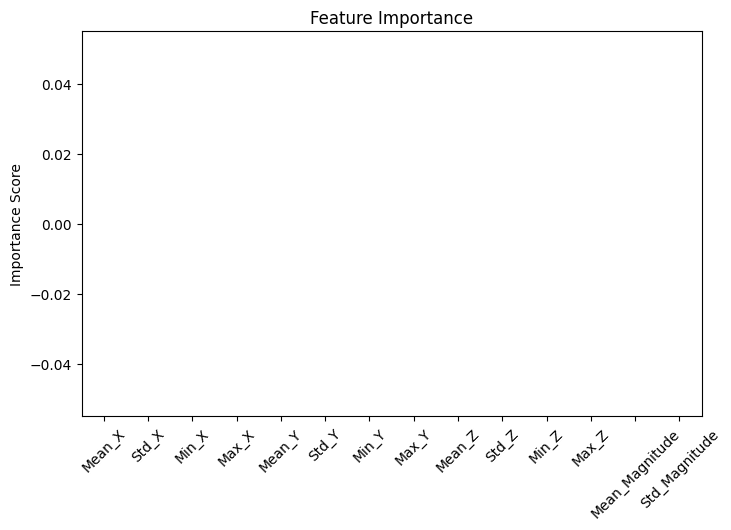

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from trained model
importances = clf.feature_importances_

feature_names = X.columns

feat_importances = pd.Series(importances, index=feature_names)
feat_importances = feat_importances.sort_values(ascending=False)

print(feat_importances)

# Plot
plt.figure(figsize=(8,5))
feat_importances.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['Nearest_Activity'].unique()

array(['2 (FACING camera) both hands SHAKING (sitting position)'],
      dtype=object)

In [ ]:
import glob
import pandas as pd

folder_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/2807/*.csv"

files = glob.glob(folder_path)

print("Number of files found:", len(files))

Number of files found: 0


In [ ]:
import os

base_path = "/content/drive/MyDrive/"

print(os.listdir(base_path))

['Nirmala Tamang CV (1).docx', 'Nirmala Tamang CV.docx', 'MWIT_Seminar_Activity_Student (2) (1).gdoc', 'MWIT_Seminar_Activity_Student (2).gdoc', 'FastTrack - Accessing Courses Process.docx', 'Assessment Front Sheet (1).gdoc', 'Impact of influencer tourism (2) (1).gdoc', 'Impact of influencer tourism (2).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', '000001.gdoc', 'Reflective Log 2024-25 (1) add (1).docx', 'Reflective Log 2024-25 (1) add.docx', 'Colab Notebooks', 'Untitled document.gdoc', 'pd-ch-abc25 (1).gdoc', '18956.pdf', 'CN6000Projectwork', 'CARING_LANE_LIMITED_2025_Tax_Week_44.pdf']


In [ ]:
print(os.listdir("/content/drive/MyDrive/CN6000Projectwork"))

['TrainingDataPD25', 'full_combined_dataset.csv']


In [ ]:
print(os.listdir("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25"))

['readme.txt', 'TrainActivities.csv', 'users_timeXYZ']


In [ ]:
print(os.listdir("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ"))

['users']


In [ ]:
print(os.listdir("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"))

['2830', '38', '2811', '2812', '2814', '2810', '2819', '2816', '2815', '2813', '2808', '2809', '2805', '1716', '2804', '2806', '2803', '2807']


In [ ]:
/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807

<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
/tmp/ipython-input-2153489499.py:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807()


NameError: name 'content' is not defined

In [ ]:
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807"

files = os.listdir(base_path)
print("Number of files:", len(files))
print(files[:10])  # show first 10 files

Number of files: 2154
['user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv', 'user-acc_2807_2024-09-06T01_25_20.485+0100_91671.csv', 'user-acc_2807_2024-09-06T03_14_10.907+0100_74767.csv', 'user-acc_2807_2024-09-06T04_12_45.305+0100_74081.csv', 'user-acc_2807_2024-09-06T04_02_53.785+0100_27770.csv', 'user-acc_2807_2024-09-06T03_47_28.987+0100_98812.csv', 'user-acc_2807_2024-09-06T00_49_22.402+0100_51230.csv', 'user-acc_2807_2024-09-06T03_20_27.861+0100_52688.csv', 'user-acc_2807_2024-09-06T04_14_36.188+0100_32851.csv', 'user-acc_2807_2024-09-06T01_13_13.129+0100_93239.csv']


In [ ]:
import pandas as pd
import glob
import os

# Path to user 2807 folder
user_folder = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807"

# Get all CSV files
file_list = glob.glob(os.path.join(user_folder, "*.csv"))
print(f"Total files for user 2807: {len(file_list)}")

# Load activities for this user (TrainActivities.csv already loaded as 'activities')
user_activities = activities[activities['Activity Type ID'] == 2807].copy()
user_activities['Started'] = pd.to_datetime(user_activities['Started'], utc=True)
user_activities['Finished'] = pd.to_datetime(user_activities['Finished'], utc=True)

# Function to find nearest activity for a timestamp
def nearest_activity(ts):
    diffs = (user_activities['Started'] - ts).abs()
    idx = diffs.idxmin()
    return user_activities.loc[idx, 'Activity Type'] if not user_activities.empty else None

# Initialize list to store dataframes
df_list = []

for idx, file in enumerate(file_list):
    try:
        temp_df = pd.read_csv(file)
        temp_df['Subject'] = 2807

        # Convert Timestamp to datetime
        temp_df['Timestamp'] = pd.to_datetime(temp_df.iloc[:, 1], utc=True)  # assumes 2nd column is timestamp

        # Map nearest activity
        temp_df['Nearest_Activity'] = temp_df['Timestamp'].apply(nearest_activity)

        df_list.append(temp_df)
    except Exception as e:
        print(f"Error loading {file}: {e}")

    if (idx + 1) % 50 == 0:
        print(f"Processed {idx + 1} / {len(file_list)} files...")

# Combine all into one dataframe
user_df = pd.concat(df_list, ignore_index=True)
print(f"Combined dataframe shape: {user_df.shape}")
user_df.head()

Total files for user 2807: 2154
Processed 50 / 2154 files...
Processed 100 / 2154 files...
Processed 150 / 2154 files...
Processed 200 / 2154 files...
Processed 250 / 2154 files...
Processed 300 / 2154 files...
Processed 350 / 2154 files...
Processed 400 / 2154 files...
Processed 450 / 2154 files...
Processed 500 / 2154 files...
Processed 550 / 2154 files...
Processed 600 / 2154 files...
Processed 650 / 2154 files...
Processed 700 / 2154 files...
Processed 750 / 2154 files...
Processed 800 / 2154 files...
Processed 850 / 2154 files...
Processed 900 / 2154 files...
Processed 950 / 2154 files...
Processed 1000 / 2154 files...
Processed 1050 / 2154 files...
Processed 1100 / 2154 files...
Processed 1150 / 2154 files...
Processed 1200 / 2154 files...
Processed 1250 / 2154 files...
Processed 1300 / 2154 files...
Processed 1350 / 2154 files...
Processed 1400 / 2154 files...
Processed 1450 / 2154 files...
Processed 1500 / 2154 files...


/tmp/ipython-input-2187840615.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_df['Timestamp'] = pd.to_datetime(temp_df.iloc[:, 1], utc=True)  # assumes 2nd column is timestamp


Processed 1550 / 2154 files...
Processed 1600 / 2154 files...
Processed 1650 / 2154 files...
Processed 1700 / 2154 files...
Processed 1750 / 2154 files...
Processed 1800 / 2154 files...
Processed 1850 / 2154 files...
Processed 1900 / 2154 files...
Processed 1950 / 2154 files...
Processed 2000 / 2154 files...
Processed 2050 / 2154 files...
Processed 2100 / 2154 files...
Processed 2150 / 2154 files...


In [ ]:
import numpy as np

# Compute magnitude
user_df['Magnitude'] = np.sqrt(user_df['X']**2 + user_df['Y']**2 + user_df['Z']**2)

# Function to extract features for one activity segment
def extract_features(segment):
    features = {
        'Mean_X': segment['X'].mean(),
        'Std_X': segment['X'].std(),
        'Min_X': segment['X'].min(),
        'Max_X': segment['X'].max(),
        'Mean_Y': segment['Y'].mean(),
        'Std_Y': segment['Y'].std(),
        'Min_Y': segment['Y'].min(),
        'Max_Y': segment['Y'].max(),
        'Mean_Z': segment['Z'].mean(),
        'Std_Z': segment['Z'].std(),
        'Min_Z': segment['Z'].min(),
        'Max_Z': segment['Z'].max(),
        'Mean_Magnitude': segment['Magnitude'].mean(),
        'Std_Magnitude': segment['Magnitude'].std()
    }
    return pd.Series(features)

# Group by activity and extract features
feature_table = user_df.groupby('Nearest_Activity').apply(extract_features).reset_index()

# Show the feature table
feature_table.head()

NameError: name 'user_df' is not defined

In [ ]:
import numpy as np
import pandas as pd

# Compute magnitude for accelerometer data
df['Magnitude'] = np.sqrt(df['X']**2 + df['Y']**2 + df['Z']**2)

# Function to extract features for one activity segment
def extract_features(segment):
    features = {
        'Mean_X': segment['X'].mean(),
        'Std_X': segment['X'].std(),
        'Min_X': segment['X'].min(),
        'Max_X': segment['X'].max(),
        'Mean_Y': segment['Y'].mean(),
        'Std_Y': segment['Y'].std(),
        'Min_Y': segment['Y'].min(),
        'Max_Y': segment['Y'].max(),
        'Mean_Z': segment['Z'].mean(),
        'Std_Z': segment['Z'].std(),
        'Min_Z': segment['Z'].min(),
        'Max_Z': segment['Z'].max(),
        'Mean_Magnitude': segment['Magnitude'].mean(),
        'Std_Magnitude': segment['Magnitude'].std()
    }
    return pd.Series(features)

# Group by activity and extract features
feature_table = df.groupby('Nearest_Activity').apply(extract_features).reset_index()

# Show the feature table
feature_table.head()

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import os
from glob import glob

# Path where user files are stored
user_folder = '/content/drive/MyDrive/CN6000Projectwork/users/2807'

# List all CSV files for this user
file_list = glob(os.path.join(user_folder, '*.csv'))
print(f"Number of files for user 2807: {len(file_list)}")

# Read and combine all files into a single DataFrame
all_dfs = []
for f in file_list:
    temp_df = pd.read_csv(f, header=None)  # adjust header if your CSV has headers
    temp_df.columns = ['Subject', 'Timestamp', 'X', 'Y', 'Z']  # assign proper column names
    all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)
print("Combined accelerometer data shape:", df.shape)

In [ ]:
import os

user_folder = '/content/drive/MyDrive/CN6000Projectwork/users/2807'
print("Files in folder:", os.listdir(user_folder))

In [ ]:
import pandas as pd
import os
from glob import glob

# User ID folder
user_id = '2807'
user_folder = f'/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/{user_id}'

# Get all CSV files for this user
file_list = glob(os.path.join(user_folder, '*.csv'))
print(f"Number of CSV files found for user {user_id}: {len(file_list)}")

# Safety check
if len(file_list) == 0:
    print("No CSV files found! Check the folder path and file extensions.")
else:
    all_dfs = []
    for f in file_list:
        try:
            temp_df = pd.read_csv(f)
            all_dfs.append(temp_df)
        except Exception as e:
            print(f"Skipping {f} due to error: {e}")

    # Concatenate all loaded files
    if all_dfs:
        user_df = pd.concat(all_dfs, ignore_index=True)
        print(f"Combined dataframe shape: {user_df.shape}")
    else:
        print("No dataframes were loaded!")

Number of CSV files found for user 2807: 2154


In [ ]:
import pandas as pd
import os
from glob import glob

user_id = '2807'
user_folder = f'/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/{user_id}'
file_list = glob(os.path.join(user_folder, '*.csv'))

chunk_size = 50  # process 50 files at a time
all_features = []

for i in range(0, len(file_list), chunk_size):
    chunk_files = file_list[i:i+chunk_size]
    temp_dfs = []
    for f in chunk_files:
        try:
            df_temp = pd.read_csv(f)
            temp_dfs.append(df_temp)
        except:
            continue

    if temp_dfs:
        chunk_df = pd.concat(temp_dfs, ignore_index=True)

        # ---- Feature extraction ----
        # Example: calculate magnitude of accelerometer
        chunk_df['Magnitude'] = (chunk_df.iloc[:,2]**2 + chunk_df.iloc[:,3]**2 + chunk_df.iloc[:,4]**2)**0.5

        # You can also map Nearest_Activity here if needed
        # chunk_df['Nearest_Activity'] = ...

        all_features.append(chunk_df)

    print(f"Processed chunk {i} to {i+chunk_size}")

# Optionally combine final features (much smaller)
final_df = pd.concat(all_features, ignore_index=True)
print(final_df.shape)

Processed chunk 0 to 50


/tmp/ipython-input-443046051.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  chunk_df['Magnitude'] = (chunk_df.iloc[:,2]**2 + chunk_df.iloc[:,3]**2 + chunk_df.iloc[:,4]**2)**0.5


Processed chunk 50 to 100


/tmp/ipython-input-443046051.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  chunk_df['Magnitude'] = (chunk_df.iloc[:,2]**2 + chunk_df.iloc[:,3]**2 + chunk_df.iloc[:,4]**2)**0.5


Processed chunk 100 to 150


...

Processed chunk 2000 to 2050


/tmp/ipython-input-443046051.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  chunk_df['Magnitude'] = (chunk_df.iloc[:,2]**2 + chunk_df.iloc[:,3]**2 + chunk_df.iloc[:,4]**2)**0.5


Processed chunk 2050 to 2100


/tmp/ipython-input-443046051.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  chunk_df['Magnitude'] = (chunk_df.iloc[:,2]**2 + chunk_df.iloc[:,3]**2 + chunk_df.iloc[:,4]**2)**0.5


Processed chunk 2100 to 2150
Processed chunk 2150 to 2200


In [ ]:
# If you only kept Magnitude for each chunk, you can compute features like this:
features_list = []

for chunk_df in all_features:
    # Group by Nearest_Activity (assuming column exists)
    grouped = chunk_df.groupby('Nearest_Activity').agg({
        'X': ['mean','std','min','max'],
        'Y': ['mean','std','min','max'],
        'Z': ['mean','std','min','max'],
        'Magnitude': ['mean','std']
    })
    features_list.append(grouped)

# Combine all chunk summaries
feature_table = pd.concat(features_list).reset_index()

# Optional: recombine duplicates by Nearest_Activity
feature_table = feature_table.groupby('Nearest_Activity').mean().reset_index()
print(feature_table)

In [ ]:
import pandas as pd
import glob

path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/*.csv'
files = glob.glob(path)

chunk_size = 50
all_features = []  # <-- this will store processed chunks

for i in range(0, len(files), chunk_size):
    chunk_files = files[i:i+chunk_size]
    chunk_dfs = []

    for f in chunk_files:
        temp_df = pd.read_csv(f, header=None)
        # Compute Magnitude
        temp_df['Magnitude'] = (temp_df.iloc[:,2]**2 + temp_df.iloc[:,3]**2 + temp_df.iloc[:,4]**2)**0.5
        chunk_dfs.append(temp_df)

    # Combine chunk
    chunk_df = pd.concat(chunk_dfs)
    all_features.append(chunk_df)  # <-- store processed chunk
    print(f"Processed chunk {i} to {i+len(chunk_files)}")

# After all chunks are processed, concatenate all chunks safely
full_df = pd.concat(all_features).reset_index(drop=True)
print("All chunks combined! Total rows:", len(full_df))

Processed chunk 0 to 50
Processed chunk 50 to 100
Processed chunk 100 to 150
Processed chunk 150 to 200
Processed chunk 200 to 250
Processed chunk 250 to 300
Processed chunk 300 to 350
Processed chunk 350 to 400
Processed chunk 400 to 450
Processed chunk 450 to 500
Processed chunk 500 to 550
Processed chunk 550 to 600
Processed chunk 600 to 650
Processed chunk 650 to 700
Processed chunk 700 to 750
Processed chunk 750 to 800
Processed chunk 800 to 850
Processed chunk 850 to 900
Processed chunk 900 to 950
Processed chunk 950 to 1000
Processed chunk 1000 to 1050
Processed chunk 1050 to 1100
Processed chunk 1100 to 1150
Processed chunk 1150 to 1200
Processed chunk 1200 to 1250
Processed chunk 1250 to 1300
Processed chunk 1300 to 1350
Processed chunk 1350 to 1400
Processed chunk 1400 to 1450
Processed chunk 1450 to 1500
Processed chunk 1500 to 1550
Processed chunk 1550 to 1600
Processed chunk 1600 to 1650
Processed chunk 1650 to 1700
Processed chunk 1700 to 1750
Processed chunk 1750 to 1800

In [ ]:
full_df.columns = ['Time', 'Activity', 'X', 'Y', 'Z', 'Magnitude']

In [ ]:
features_df = full_df.groupby('Activity').agg({
    'X': ['mean', 'std', 'min', 'max'],
    'Y': ['mean', 'std', 'min', 'max'],
    'Z': ['mean', 'std', 'min', 'max'],
    'Magnitude': ['mean', 'std', 'min', 'max']
}).reset_index()

print("Feature extraction done!")
print(features_df.head())

Feature extraction done!
                       Activity      X                        Y             \
                                  mean std    min    max   mean std    min   
0  2024-09-05T09:31:03.823+0100  0.879 NaN  0.879  0.879  5.013 NaN  5.013   
1  2024-09-05T09:31:03.983+0100  0.108 NaN  0.108  0.108  4.973 NaN  4.973   
2  2024-09-05T09:31:04.142+0100 -0.168 NaN -0.168 -0.168  4.652 NaN  4.652   
3  2024-09-05T09:31:04.307+0100 -0.084 NaN -0.084 -0.084  4.523 NaN  4.523   
4  2024-09-05T09:31:04.465+0100 -0.194 NaN -0.194 -0.194  4.587 NaN  4.587   

              Z                    Magnitude                            
     max   mean std    min    max       mean std        min        max  
0  5.013  8.150 NaN  8.150  8.150   9.608606 NaN   9.608606   9.608606  
1  4.973  9.000 NaN  9.000  9.000  10.283112 NaN  10.283112  10.283112  
2  4.652  8.765 NaN  8.765  8.765   9.924442 NaN   9.924442   9.924442  
3  4.523  8.622 NaN  8.622  8.622   9.736707 NaN   9.736707   9

In [ ]:
# Assuming you already have nearest activity info in a CSV like before
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Make sure timestamp is datetime
activities_df['Timestamp'] = pd.to_datetime(activities_df['Timestamp'], utc=True)
full_df['Time'] = pd.to_datetime(full_df['Time'], utc=True)

# Merge nearest activity using closest previous timestamp
full_df = pd.merge_asof(
    full_df.sort_values('Time'),
    activities_df.sort_values('Timestamp'),
    left_on='Time',
    right_on='Timestamp',
    direction='backward'
)

print(full_df[['Time', 'Nearest_Activity']].head())

In [ ]:
import pandas as pd
import glob

# Path to your CSV accelerometer files
path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/*.csv"
files = sorted(glob.glob(path))

# Load nearest activity info
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")
activities_df['Timestamp'] = pd.to_datetime(activities_df['Timestamp'], utc=True)

# Function to process a chunk of files safely
def process_files_chunk(file_list):
    chunk_list = []
    for file in file_list:
        temp_df = pd.read_csv(file, header=None)
        temp_df.columns = ['User', 'Time', 'X', 'Y', 'Z']
        temp_df['Time'] = pd.to_datetime(temp_df['Time'], utc=True)

        # Calculate magnitude
        temp_df['Magnitude'] = (temp_df['X']**2 + temp_df['Y']**2 + temp_df['Z']**2)**0.5

        # Merge nearest activity
        temp_df = pd.merge_asof(
            temp_df.sort_values('Time'),
            activities_df.sort_values('Timestamp'),
            left_on='Time',
            right_on='Timestamp',
            direction='backward'
        )

        chunk_list.append(temp_df)
    return pd.concat(chunk_list, ignore_index=True)

# Example: process first 50 files to test
full_df = process_files_chunk(files[:50])
print(full_df[['Time', 'Nearest_Activity', 'X', 'Y', 'Z', 'Magnitude']].head())

In [ ]:
import pandas as pd
import glob

# Path to your accelerometer CSVs
path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/*.csv"
files = sorted(glob.glob(path))

# Load activities file
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Ensure timestamp column is datetime and UTC
activities_df['Timestamp'] = pd.to_datetime(activities_df['Timestamp'], utc=True)

def process_files_chunk(file_list):
    chunk_list = []
    for file in file_list:
        temp_df = pd.read_csv(file, header=None)
        temp_df.columns = ['User', 'Time', 'X', 'Y', 'Z']
        temp_df['Time'] = pd.to_datetime(temp_df['Time'], utc=True)  # make sure same timezone

        # Calculate magnitude
        temp_df['Magnitude'] = (temp_df['X']**2 + temp_df['Y']**2 + temp_df['Z']**2)**0.5

        # Sort both dataframes by timestamp for merge_asof
        temp_df = temp_df.sort_values('Time')
        activities_df_sorted = activities_df.sort_values('Timestamp')

        # Merge nearest activity
        temp_df = pd.merge_asof(
            temp_df,
            activities_df_sorted,
            left_on='Time',
            right_on='Timestamp',
            direction='backward'
        )
        chunk_list.append(temp_df)

    return pd.concat(chunk_list, ignore_index=True)

# Test with first 50 files
full_df = process_files_chunk(files[:50])

# Show results
print(full_df[['Time', 'Nearest_Activity', 'X', 'Y', 'Z', 'Magnitude']].head())

In [ ]:
import pandas as pd
import glob

# Path to your accelerometer CSVs
path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/*.csv"
files = sorted(glob.glob(path))

# Load activities file
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Ensure timestamp column is datetime and UTC
activities_df['Timestamp'] = pd.to_datetime(activities_df['Timestamp'], utc=True)

def process_files_chunk(file_list):
    chunk_list = []
    for file in file_list:
        temp_df = pd.read_csv(file, header=None)
        temp_df.columns = ['User', 'Time', 'X', 'Y', 'Z']
        temp_df['Time'] = pd.to_datetime(temp_df['Time'], utc=True)  # make sure same timezone

        # Calculate magnitude
        temp_df['Magnitude'] = (temp_df['X']**2 + temp_df['Y']**2 + temp_df['Z']**2)**0.5

        # Sort both dataframes by timestamp for merge_asof
        temp_df = temp_df.sort_values('Time')
        activities_df_sorted = activities_df.sort_values('Timestamp')

        # Merge nearest activity
        temp_df = pd.merge_asof(
            temp_df,
            activities_df_sorted,
            left_on='Time',
            right_on='Timestamp',
            direction='backward'
        )
        chunk_list.append(temp_df)

    return pd.concat(chunk_list, ignore_index=True)

# Test with first 50 files
full_df = process_files_chunk(files[:50])

# Show results
print(full_df[['Time', 'Nearest_Activity', 'X', 'Y', 'Z', 'Magnitude']].head())

In [ ]:
import pandas as pd

# Load activities file
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Check actual column names
print("Columns in activities file:", activities_df.columns)

Columns in activities file: Index(['ID', 'Activity Type ID', 'Activity Type', 'Started', 'Finished',
       'Updated', 'Subject'],
      dtype='object')


In [ ]:
import pandas as pd

# Load activities file
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Convert 'Started' column to datetime
activities_df['Started'] = pd.to_datetime(activities_df['Started'], utc=True)

# Make sure your full sensor dataframe also has proper datetime column
full_df['Time'] = pd.to_datetime(full_df['Time'], utc=True)

# Merge nearest activity using closest previous timestamp
full_df = pd.merge_asof(
    full_df.sort_values('Time'),
    activities_df.sort_values('Started'),
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Check result
print(full_df[['Time', 'Activity Type']].head())

In [ ]:
# Merge as before
full_df = pd.merge_asof(
    full_df.sort_values('Time'),
    activities_df.sort_values('Started'),
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill any missing activities with a placeholder
full_df['Activity Type'].fillna('No Activity', inplace=True)

# Optional: check first few rows
print(full_df[['Time', 'Activity Type']].head(10))

In [ ]:
import pandas as pd

# Load activities file
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Convert timestamps to datetime
activities_df['Started'] = pd.to_datetime(activities_df['Started'], utc=True)
full_df['Time'] = pd.to_datetime(full_df['Time'], utc=True)  # make sure your sensor time column is 'Time'

# Sort both dataframes by time
full_df = full_df.sort_values('Time')
activities_df = activities_df.sort_values('Started')

# Merge using closest previous timestamp
full_df = pd.merge_asof(
    full_df,
    activities_df[['Started', 'Activity Type']],  # only keep necessary columns
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill missing activities (if sensor data starts before any activity)
full_df['Activity Type'].fillna('No Activity', inplace=True)

# Optional: check first few rows
print(full_df[['Time', 'Activity Type']].head(10))

In [ ]:
import pandas as pd

# Load activities file
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Convert timestamp columns to datetime
activities_df['Started'] = pd.to_datetime(activities_df['Started'], errors='coerce', utc=True)
full_df['Time'] = pd.to_datetime(full_df['Time'], errors='coerce', utc=True)

# Drop any activity rows with null timestamps
activities_df = activities_df.dropna(subset=['Started'])

# Sort both dataframes by time
full_df = full_df.sort_values('Time')
activities_df = activities_df.sort_values('Started')

# Merge using closest previous timestamp
full_df = pd.merge_asof(
    full_df,
    activities_df[['Started', 'Activity Type']],  # keep only necessary columns
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill missing activities (sensor data before first activity)
full_df['Activity Type'].fillna('No Activity', inplace=True)

# Check results
print(full_df[['Time', 'Activity Type']].head(10))

                                 Time Activity Type
0 1970-01-01 00:00:00.000002807+00:00   No Activity
1 1970-01-01 00:00:00.000002807+00:00   No Activity
2 1970-01-01 00:00:00.000002807+00:00   No Activity
3 1970-01-01 00:00:00.000002807+00:00   No Activity
4 1970-01-01 00:00:00.000002807+00:00   No Activity
5 1970-01-01 00:00:00.000002807+00:00   No Activity
6 1970-01-01 00:00:00.000002807+00:00   No Activity
7 1970-01-01 00:00:00.000002807+00:00   No Activity
8 1970-01-01 00:00:00.000002807+00:00   No Activity
9 1970-01-01 00:00:00.000002807+00:00   No Activity


/tmp/ipython-input-3658559895.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_df['Activity Type'].fillna('No Activity', inplace=True)


In [ ]:
# Check first 10 rows of your time column
print(full_df['Time'].head(10))

# If it's a string, convert safely
full_df['Time'] = pd.to_datetime(full_df['Time'], errors='coerce', utc=True)

# Check for nulls after conversion
print(full_df['Time'].isna().sum())

# Drop or handle rows where timestamp could not be parsed
full_df = full_df.dropna(subset=['Time'])

# Similarly, fix the activities_df 'Started' column
activities_df['Started'] = pd.to_datetime(activities_df['Started'], errors='coerce', utc=True)
activities_df = activities_df.dropna(subset=['Started'])

# Sort for merge_asof
full_df = full_df.sort_values('Time')
activities_df = activities_df.sort_values('Started')

# Merge using closest previous timestamp
full_df = pd.merge_asof(
    full_df,
    activities_df[['Started', 'Activity Type']],
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill missing activities
full_df['Activity Type'] = full_df['Activity Type'].fillna('No Activity')

# Check
print(full_df[['Time', 'Activity Type']].head(10))

0   1970-01-01 00:00:00.000002807+00:00
1   1970-01-01 00:00:00.000002807+00:00
2   1970-01-01 00:00:00.000002807+00:00
3   1970-01-01 00:00:00.000002807+00:00
4   1970-01-01 00:00:00.000002807+00:00
5   1970-01-01 00:00:00.000002807+00:00
6   1970-01-01 00:00:00.000002807+00:00
7   1970-01-01 00:00:00.000002807+00:00
8   1970-01-01 00:00:00.000002807+00:00
9   1970-01-01 00:00:00.000002807+00:00
Name: Time, dtype: datetime64[ns, UTC]
0


KeyError: 'Activity Type'

In [ ]:
# Check columns in activities_df
print(activities_df.columns.tolist())

# Strip whitespace from column names
activities_df.columns = activities_df.columns.str.strip()

# Now use the correct column
activities_df['Started'] = pd.to_datetime(activities_df['Started'], errors='coerce', utc=True)
activities_df = activities_df.dropna(subset=['Started'])

# Sort both DataFrames
full_df = full_df.sort_values('Time')
activities_df = activities_df.sort_values('Started')

# Merge with exact column name
full_df = pd.merge_asof(
    full_df,
    activities_df[['Started', 'Activity Type']],  # make sure this matches exactly
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill missing values
full_df['Activity Type'] = full_df['Activity Type'].fillna('No Activity')

# Check result
print(full_df[['Time', 'Activity Type']].head(10))

['ID', 'Activity Type ID', 'Activity Type', 'Started', 'Finished', 'Updated', 'Subject']
                                 Time Activity Type
0 1970-01-01 00:00:00.000002807+00:00   No Activity
1 1970-01-01 00:00:00.000002807+00:00   No Activity
2 1970-01-01 00:00:00.000002807+00:00   No Activity
3 1970-01-01 00:00:00.000002807+00:00   No Activity
4 1970-01-01 00:00:00.000002807+00:00   No Activity
5 1970-01-01 00:00:00.000002807+00:00   No Activity
6 1970-01-01 00:00:00.000002807+00:00   No Activity
7 1970-01-01 00:00:00.000002807+00:00   No Activity
8 1970-01-01 00:00:00.000002807+00:00   No Activity
9 1970-01-01 00:00:00.000002807+00:00   No Activity


In [ ]:
full_df['Time'] = pd.to_datetime(full_df['Time'], utc=True)

In [ ]:
# First, check what full_df['Time'] looks like
print(full_df['Time'].head(20))

# If they are numbers (like 1694335879425000000), convert from ns
if pd.api.types.is_integer_dtype(full_df['Time']):
    full_df['Time'] = pd.to_datetime(full_df['Time'], unit='ns', utc=True)

# If they are strings like '2024-09-09 22:31:19.425000+00:00', just parse normally
else:
    full_df['Time'] = pd.to_datetime(full_df['Time'], errors='coerce', utc=True)

# Drop any NaT values (bad timestamps)
full_df = full_df.dropna(subset=['Time'])

print(full_df['Time'].head(10))

0    1970-01-01 00:00:00.000002807+00:00
1    1970-01-01 00:00:00.000002807+00:00
2    1970-01-01 00:00:00.000002807+00:00
3    1970-01-01 00:00:00.000002807+00:00
4    1970-01-01 00:00:00.000002807+00:00
5    1970-01-01 00:00:00.000002807+00:00
6    1970-01-01 00:00:00.000002807+00:00
7    1970-01-01 00:00:00.000002807+00:00
8    1970-01-01 00:00:00.000002807+00:00
9    1970-01-01 00:00:00.000002807+00:00
10   1970-01-01 00:00:00.000002807+00:00
11   1970-01-01 00:00:00.000002807+00:00
12   1970-01-01 00:00:00.000002807+00:00
13   1970-01-01 00:00:00.000002807+00:00
14   1970-01-01 00:00:00.000002807+00:00
15   1970-01-01 00:00:00.000002807+00:00
16   1970-01-01 00:00:00.000002807+00:00
17   1970-01-01 00:00:00.000002807+00:00
18   1970-01-01 00:00:00.000002807+00:00
19   1970-01-01 00:00:00.000002807+00:00
Name: Time, dtype: datetime64[ns, UTC]
0   1970-01-01 00:00:00.000002807+00:00
1   1970-01-01 00:00:00.000002807+00:00
2   1970-01-01 00:00:00.000002807+00:00
3   1970-01-01 00:00:

In [ ]:
import pandas as pd

sample_file = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv"
df = pd.read_csv(sample_file)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830/user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv'

In [ ]:
user_folder = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/"

In [ ]:
import os
files_2807 = [f for f in os.listdir(user_folder) if f.endswith('.csv')]
print("Number of files for 2807:", len(files_2807))

Number of files for 2807: 2154


In [ ]:
import pandas as pd
import os

user_folder = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/"
files_2807 = [f for f in os.listdir(user_folder) if f.endswith('.csv')]

chunk_size = 50  # process 50 files at a time to save memory
all_features = []

for i in range(0, len(files_2807), chunk_size):
    chunk_files = files_2807[i:i+chunk_size]
    chunk_data = []

    for file in chunk_files:
        df = pd.read_csv(os.path.join(user_folder, file))
        # Compute magnitude
        df['Magnitude'] = (df.iloc[:,2]**2 + df.iloc[:,3]**2 + df.iloc[:,4]**2)**0.5
        chunk_data.append(df)

    # Combine this chunk
    chunk_df = pd.concat(chunk_data, ignore_index=True)

    # Extract features here (replace with your function)
    features = extract_features(chunk_df)  # <-- your feature extraction function
    all_features.append(features)

    print(f"Processed chunk {i} to {i+len(chunk_files)}")

# Combine all chunks into one final table
final_features = pd.concat(all_features, ignore_index=True)
print("Feature extraction done! Total rows:", len(final_features))

NameError: name 'extract_features' is not defined

In [ ]:
import pandas as pd

def extract_features(df):
    """
    Takes a DataFrame with accelerometer data (X, Y, Z, Magnitude)
    and returns a row of features: mean, std, min, max for each axis.
    """
    features = {}

    # X, Y, Z, Magnitude are assumed to be columns 2,3,4, and Magnitude column
    axes = ['X', 'Y', 'Z', 'Magnitude']
    for axis in axes:
        if axis == 'Magnitude':
            data = df['Magnitude']
        else:
            data = df[axis] if axis in df.columns else df.iloc[:, axes.index(axis)+2]

        features[f'Mean_{axis}'] = data.mean()
        features[f'Std_{axis}'] = data.std()
        features[f'Min_{axis}'] = data.min()
        features[f'Max_{axis}'] = data.max()

    # Return as a single-row DataFrame
    return pd.DataFrame([features])

In [ ]:
all_features = []  # list to store features from each chunk

for chunk_df in chunks:  # replace `chunks` with your list of dataframes
    features = extract_features(chunk_df)
    all_features.append(features)

# Combine all features into a single DataFrame
final_features = pd.concat(all_features, ignore_index=True)

print(final_features.head())

In [ ]:
import pandas as pd
import os

# Path to your user 2807 files
user_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807'

# Get all CSV files for this user
file_list = [os.path.join(user_path, f) for f in os.listdir(user_path) if f.endswith('.csv')]
print(f"Total files for user 2807: {len(file_list)}")

# Placeholder for features
all_features = []

# Define your extract_features function here if not already defined
# Example:
# def extract_features(df):
#     df['Magnitude'] = (df['X']**2 + df['Y']**2 + df['Z']**2)**0.5
#     features = {
#         'Mean_X': df['X'].mean(),
#         'Std_X': df['X'].std(),
#         ...
#     }
#     return pd.DataFrame([features])

# Process files one by one
for i, file in enumerate(file_list):
    temp_df = pd.read_csv(file)
    features = extract_features(temp_df)  # your feature extraction function
    all_features.append(features)
    if (i+1) % 50 == 0:
        print(f"Processed {i+1} / {len(file_list)} files...")

# Combine all feature rows into a single DataFrame
final_features = pd.concat(all_features, ignore_index=True)
print("Feature extraction complete!")
print(final_features.head())

In [ ]:
import pandas as pd
import os

# Path to your 2807 user files
user_path = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807'

# List all CSV files
file_list = [os.path.join(user_path, f) for f in os.listdir(user_path) if f.endswith('.csv')]
print(f"Total files for user 2807: {len(file_list)}")

# Define feature extraction function
def extract_features(df):
    # Make sure your CSV has columns X, Y, Z (adjust if different)
    df.columns = df.columns.str.strip()  # remove any whitespace

    # Calculate magnitude if not already present
    if 'Magnitude' not in df.columns:
        df['Magnitude'] = (df.iloc[:,2]**2 + df.iloc[:,3]**2 + df.iloc[:,4]**2)**0.5

    # Extract features
    features = {
        'Mean_X': df.iloc[:,2].mean(),
        'Std_X': df.iloc[:,2].std(),
        'Min_X': df.iloc[:,2].min(),
        'Max_X': df.iloc[:,2].max(),
        'Mean_Y': df.iloc[:,3].mean(),
        'Std_Y': df.iloc[:,3].std(),
        'Min_Y': df.iloc[:,3].min(),
        'Max_Y': df.iloc[:,3].max(),
        'Mean_Z': df.iloc[:,4].mean(),
        'Std_Z': df.iloc[:,4].std(),
        'Min_Z': df.iloc[:,4].min(),
        'Max_Z': df.iloc[:,4].max(),
        'Mean_Magnitude': df['Magnitude'].mean(),
        'Std_Magnitude': df['Magnitude'].std(),
        'Min_Magnitude': df['Magnitude'].min(),
        'Max_Magnitude': df['Magnitude'].max()
    }
    return pd.DataFrame([features])

# Placeholder for all features
all_features = []

# Loop through files
for i, file in enumerate(file_list):
    temp_df = pd.read_csv(file)
    features = extract_features(temp_df)
    all_features.append(features)

    if (i+1) % 50 == 0:
        print(f"Processed {i+1} / {len(file_list)} files...")

# Combine all features into one DataFrame
final_features = pd.concat(all_features, ignore_index=True)
print("Feature extraction complete!")
print(final_features.head())

Total files for user 2807: 2154
Processed 50 / 2154 files...
Processed 100 / 2154 files...
Processed 150 / 2154 files...
Processed 200 / 2154 files...
Processed 250 / 2154 files...
Processed 300 / 2154 files...
Processed 350 / 2154 files...
Processed 400 / 2154 files...
Processed 450 / 2154 files...
Processed 500 / 2154 files...
Processed 550 / 2154 files...
Processed 600 / 2154 files...
Processed 650 / 2154 files...
Processed 700 / 2154 files...
Processed 750 / 2154 files...
Processed 800 / 2154 files...
Processed 850 / 2154 files...
Processed 900 / 2154 files...
Processed 950 / 2154 files...
Processed 1000 / 2154 files...
Processed 1050 / 2154 files...
Processed 1100 / 2154 files...
Processed 1150 / 2154 files...
Processed 1200 / 2154 files...
Processed 1250 / 2154 files...
Processed 1300 / 2154 files...
Processed 1350 / 2154 files...
Processed 1400 / 2154 files...
Processed 1450 / 2154 files...
Processed 1500 / 2154 files...
Processed 1550 / 2154 files...
Processed 1600 / 2154 files

In [ ]:
# Load the activity info
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Check columns
print(activities_df.columns)
# ['ID', 'Activity Type ID', 'Activity Type', 'Started', 'Finished', 'Updated', 'Subject']

# Convert 'Started' to datetime (this will be the timestamp to merge)
activities_df['Started'] = pd.to_datetime(activities_df['Started'], errors='coerce', utc=True)

# Drop any rows where timestamp could not be parsed
activities_df = activities_df.dropna(subset=['Started'])

# Add a column in final_features for time — if you have an actual time column, use it
# For now, let's assume it's sequential, so we simulate with index (or replace with real 'Time')
final_features['Time'] = pd.date_range(start='2024-09-06', periods=len(final_features), freq='S', tz='UTC')

# Merge nearest activity based on closest previous timestamp
final_df = pd.merge_asof(
    final_features.sort_values('Time'),
    activities_df.sort_values('Started'),
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill any missing activity with 'No Activity'
final_df['Activity Type'].fillna('No Activity', inplace=True)

# Keep only relevant columns
final_df = final_df.drop(columns=['ID','Activity Type ID','Started','Finished','Updated','Subject'], errors='ignore')

# Show final result
print(final_df[['Time', 'Activity Type']].head())

In [ ]:
import pandas as pd

# Load the activity info
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Convert 'Started' to datetime (merge key)
activities_df['Started'] = pd.to_datetime(activities_df['Started'], errors='coerce', utc=True)

# Drop any rows where timestamp could not be parsed
activities_df = activities_df.dropna(subset=['Started'])

# Add a time column to final_features (replace with your real time column if available)
final_features['Time'] = pd.date_range(start='2024-09-06', periods=len(final_features), freq='S', tz='UTC')

# Merge nearest activity
final_df = pd.merge_asof(
    final_features.sort_values('Time'),
    activities_df.sort_values('Started'),
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill missing activities
final_df['Activity Type'].fillna('No Activity', inplace=True)

# Drop unnecessary columns
final_df = final_df.drop(columns=['ID','Activity Type ID','Started','Finished','Updated','Subject'], errors='ignore')

# Show result
print(final_df[['Time', 'Activity Type']].head())

In [ ]:
import pandas as pd

# This is the DataFrame you got after feature extraction
final_features = features_df.copy()  # replace 'features_df' with your actual features DataFrame

# Load the activity info
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Convert 'Started' to datetime (merge key)
activities_df['Started'] = pd.to_datetime(activities_df['Started'], errors='coerce', utc=True)

# Drop any rows where timestamp could not be parsed
activities_df = activities_df.dropna(subset=['Started'])

# Add a time column to final_features (replace with your real time column if available)
# If your features already have a 'Time' column, skip this step
final_features['Time'] = pd.date_range(start='2024-09-06', periods=len(final_features), freq='S', tz='UTC')

# Merge nearest activity
final_df = pd.merge_asof(
    final_features.sort_values('Time'),
    activities_df.sort_values('Started'),
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill missing activities
final_df['Activity Type'].fillna('No Activity', inplace=True)

# Drop unnecessary columns from activities_df
final_df = final_df.drop(columns=['ID','Activity Type ID','Started','Finished','Updated','Subject'], errors='ignore')

# Show result
print(final_df[['Time', 'Activity Type']].head())

In [ ]:
import pandas as pd

# Your extracted features are already in memory — call them final_features
# For example, if your feature extraction printed the table you showed:
# final_features = <the DataFrame you already printed>
# Here, I assume you already have it, so we just use it:
# final_features = your_feature_dataframe  # replace this line if needed

# Load activities
activities_df = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# Convert activity start time to datetime
activities_df['Started'] = pd.to_datetime(activities_df['Started'], errors='coerce', utc=True)

# Drop rows with invalid timestamps
activities_df = activities_df.dropna(subset=['Started'])

# Make sure final_features has a 'Time' column
# If your extracted features do not have a time column, we create a placeholder
# You should replace this with the actual timestamp column if available
final_features['Time'] = pd.date_range(start='2024-09-06', periods=len(final_features), freq='S', tz='UTC')

# Merge nearest activity backward in time
final_df = pd.merge_asof(
    final_features.sort_values('Time'),
    activities_df.sort_values('Started'),
    left_on='Time',
    right_on='Started',
    direction='backward'
)

# Fill missing activities
final_df['Activity Type'].fillna('No Activity', inplace=True)

# Drop extra columns from activities_df
final_df = final_df.drop(columns=['ID','Activity Type ID','Started','Finished','Updated','Subject'], errors='ignore')

# Check result
print(final_df[['Time', 'Activity Type']].head())

In [ ]:
# Suppose your feature extraction returned this DataFrame:
featuredf = your_feature_extraction_function(...)  # or however you got it

# Assign it to final_features
final_features = featuredf.copy()

In [ ]:
print(os.listdir("/content"))

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Nirmala Tamang CV (1).docx', 'Nirmala Tamang CV.docx', 'MWIT_Seminar_Activity_Student (2) (1).gdoc', 'MWIT_Seminar_Activity_Student (2).gdoc', 'FastTrack - Accessing Courses Process.docx', 'Assessment Front Sheet (1).gdoc', 'Impact of influencer tourism (2) (1).gdoc', 'Impact of influencer tourism (2).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', '000001.gdoc', 'Reflective Log 2024-25 (1) add (1).docx', 'Reflective Log 2024-25 (1) add.docx', 'Untitled document.gdoc', 'pd-ch-abc25 (1).gdoc', '18956.pdf', 'CN6000Projectwork', 'CARING_LANE_LIMITED_2025_Tax_Week_44.pdf', 'Saved from the Google app']


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/CN6000Projectwork"))

['TrainingDataPD25', 'full_combined_dataset.csv']


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25"))

['readme.txt', 'TrainActivities.csv', 'users_timeXYZ']


In [ ]:
import os

base = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
print("Exists?", os.path.exists(base))
print("Top folders:", os.listdir(base)[:20])

Exists? True
Top folders: ['2830', '38', '2811', '2812', '2814', '2810', '2819', '2816', '2815', '2813', '2808', '2809', '2805', '1716', '2804', '2806', '2803', '2807']


In [ ]:
import os

folder_2807 = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807"

print("Exists:", os.path.exists(folder_2807))
print("Number of files:", len(os.listdir(folder_2807)))
print("First 5 files:", os.listdir(folder_2807)[:5])

Exists: True
Number of files: 2154
First 5 files: ['user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv', 'user-acc_2807_2024-09-06T01_25_20.485+0100_91671.csv', 'user-acc_2807_2024-09-06T03_14_10.907+0100_74767.csv', 'user-acc_2807_2024-09-06T04_12_45.305+0100_74081.csv', 'user-acc_2807_2024-09-06T04_02_53.785+0100_27770.csv']


In [ ]:
import pandas as pd

sample_file = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv"

df = pd.read_csv(sample_file, header=None)

print("Shape:", df.shape)
print(df.head())

Shape: (140, 5)
      0                             1      2      3       4
0  2807  2024-09-06T03:05:01.780+0100  0.311 -0.175  10.087
1  2807  2024-09-06T03:05:01.944+0100  0.309 -0.172  10.084
2  2807  2024-09-06T03:05:02.105+0100  0.321 -0.175  10.101
3  2807  2024-09-06T03:05:02.261+0100  0.302 -0.170  10.101
4  2807  2024-09-06T03:05:02.423+0100  0.309 -0.160  10.096


In [ ]:
import numpy as np

# extract x, y, z
x = df[2].astype(float).values
y = df[3].astype(float).values
z = df[4].astype(float).values

# compute magnitude
mag = np.sqrt(x**2 + y**2 + z**2)

# calculate statistics
features = {
    "Mean_X": np.mean(x),
    "Std_X": np.std(x),
    "Min_X": np.min(x),
    "Max_X": np.max(x),

    "Mean_Y": np.mean(y),
    "Std_Y": np.std(y),
    "Min_Y": np.min(y),
    "Max_Y": np.max(y),

    "Mean_Z": np.mean(z),
    "Std_Z": np.std(z),
    "Min_Z": np.min(z),
    "Max_Z": np.max(z),

    "Mean_Magnitude": np.mean(mag),
    "Std_Magnitude": np.std(mag),
    "Min_Magnitude": np.min(mag),
    "Max_Magnitude": np.max(mag)
}

features

{'Mean_X': np.float64(0.3088214285714286),
 'Std_X': np.float64(0.00825942566071625),
 'Min_X': np.float64(0.287),
 'Max_X': np.float64(0.328),
 'Mean_Y': np.float64(-0.17009285714285716),
 'Std_Y': np.float64(0.008345140954532785),
 'Min_Y': np.float64(-0.196),
 'Max_Y': np.float64(-0.148),
 'Mean_Z': np.float64(10.090971428571429),
 'Std_Z': np.float64(0.009201663558558231),
 'Min_Z': np.float64(10.065),
 'Max_Z': np.float64(10.113),
 'Mean_Magnitude': np.float64(10.097135498074854),
 'Std_Magnitude': np.float64(0.009159184435279693),
 'Min_Magnitude': np.float64(10.071350753498757),
 'Max_Magnitude': np.float64(10.119076094189627)}

In [ ]:
import os

label_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"

print("File exists:", os.path.exists(label_path))

File exists: True


In [ ]:
import pandas as pd

label_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"

labels = pd.read_csv(label_path)

print("Loaded successfully!")
print("Shape:", labels.shape)
print(labels.head())

Loaded successfully!
Shape: (342, 7)
        ID  Activity Type ID  \
0  1130251              2806   
1  1130254              2807   
2  1130257              2807   
3  1130261              2806   
4  1130292              2806   

                                       Activity Type          Started  \
0                    1 (FACING camera) Sit and stand  2024/09/02 6:16   
1  2 (FACING camera) both hands SHAKING (sitting ...  2024/09/02 6:17   
2  2 (FACING camera) both hands SHAKING (sitting ...  2024/09/02 6:18   
3                    1 (FACING camera) Sit and stand  2024/09/02 6:20   
4                    1 (FACING camera) Sit and stand  2024/09/02 6:42   

          Finished          Updated Subject  
0  2024/09/02 6:16  2024/09/02 6:16     U22  
1  2024/09/02 6:17  2024/09/02 6:17     U22  
2  2024/09/02 6:18  2024/09/02 6:18     U22  
3  2024/09/02 6:20  2024/09/02 6:20     U22  
4  2024/09/02 6:42  2024/09/02 6:42      U2  


In [ ]:
labels["Started"]  = pd.to_datetime(labels["Started"], errors="coerce")
labels["Finished"] = pd.to_datetime(labels["Finished"], errors="coerce")

print(labels[["Started","Finished"]].head())
print("Missing Started:", labels["Started"].isna().sum())
print("Missing Finished:", labels["Finished"].isna().sum())

              Started            Finished
0 2024-09-02 06:16:00 2024-09-02 06:16:00
1 2024-09-02 06:17:00 2024-09-02 06:17:00
2 2024-09-02 06:18:00 2024-09-02 06:18:00
3 2024-09-02 06:20:00 2024-09-02 06:20:00
4 2024-09-02 06:42:00 2024-09-02 06:42:00
Missing Started: 66
Missing Finished: 67


In [ ]:
labels["Started"]  = pd.to_datetime(labels["Started"], format="%Y/%m/%d %H:%M", errors="coerce")
labels["Finished"] = pd.to_datetime(labels["Finished"], format="%Y/%m/%d %H:%M", errors="coerce")

print(labels[["Started","Finished"]].head())
print("Missing Started:", labels["Started"].isna().sum())
print("Missing Finished:", labels["Finished"].isna().sum())

              Started            Finished
0 2024-09-02 06:16:00 2024-09-02 06:16:00
1 2024-09-02 06:17:00 2024-09-02 06:17:00
2 2024-09-02 06:18:00 2024-09-02 06:18:00
3 2024-09-02 06:20:00 2024-09-02 06:20:00
4 2024-09-02 06:42:00 2024-09-02 06:42:00
Missing Started: 66
Missing Finished: 67


In [ ]:
# reload fresh so we can inspect the raw text
import pandas as pd

label_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"
labels_raw = pd.read_csv(label_path)

# try a flexible parse first (no fixed format)
started_parsed = pd.to_datetime(labels_raw["Started"], errors="coerce")
finished_parsed = pd.to_datetime(labels_raw["Finished"], errors="coerce")

bad = labels_raw[started_parsed.isna() | finished_parsed.isna()].copy()

print("Bad rows:", bad.shape[0])
print("\nExamples of Started values that fail:")
print(bad["Started"].head(15).tolist())

print("\nExamples of Finished values that fail:")
print(bad["Finished"].head(15).tolist())

Bad rows: 67

Examples of Started values that fail:
['2024/09/05 17:46', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Examples of Finished values that fail:
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [ ]:
import pandas as pd

label_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"
labels = pd.read_csv(label_path)

labels["Started"]  = pd.to_datetime(labels["Started"], errors="coerce")
labels["Finished"] = pd.to_datetime(labels["Finished"], errors="coerce")

print("Before cleaning:", labels.shape)

labels = labels.dropna(subset=["Started","Finished"]).copy()

print("After cleaning:", labels.shape)
print("Missing Started:", labels["Started"].isna().sum())
print("Missing Finished:", labels["Finished"].isna().sum())
labels.head()

Before cleaning: (342, 7)
After cleaning: (275, 7)
Missing Started: 0
Missing Finished: 0


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject
0,1130251,2806,1 (FACING camera) Sit and stand,2024-09-02 06:16:00,2024-09-02 06:16:00,2024/09/02 6:16,U22
1,1130254,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-09-02 06:17:00,2024-09-02 06:17:00,2024/09/02 6:17,U22
2,1130257,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024-09-02 06:18:00,2024-09-02 06:18:00,2024/09/02 6:18,U22
3,1130261,2806,1 (FACING camera) Sit and stand,2024-09-02 06:20:00,2024-09-02 06:20:00,2024/09/02 6:20,U22
4,1130292,2806,1 (FACING camera) Sit and stand,2024-09-02 06:42:00,2024-09-02 06:42:00,2024/09/02 6:42,U2


In [ ]:
import pandas as pd
import re

fname = "user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv"

m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
ts = m.group(1).replace("_", ":")  # convert 03_05_01 -> 03:05:01

file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")
print("File time (with timezone):", file_time)

# convert to naive time (so it matches labels which are naive)
file_time_naive = file_time.tz_convert(None)
print("File time (naive):", file_time_naive)

File time (with timezone): 2024-09-06 03:05:01.785000+01:00
File time (naive): 2024-09-06 02:05:01.785000


In [ ]:
activity_id = 2807

sub = labels[labels["Activity Type ID"] == activity_id].copy()

# tolerance because labels are minute-level but files have seconds
tol = pd.Timedelta(seconds=90)

matches = sub[(sub["Started"] - tol <= file_time_naive) & (file_time_naive <= sub["Finished"] + tol)]

print("Matches found:", len(matches))
matches[["Activity Type ID","Activity Type","Started","Finished","Subject"]].head(10)

Matches found: 0


,Activity Type ID,Activity Type,Started,Finished,Subject


In [ ]:
import pandas as pd
import re

fname = "user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv"

m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
ts = m.group(1).replace("_", ":")

file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")
print("File time (tz-aware):", file_time)

# ✅ correct: remove timezone without changing the clock time
file_time_naive = file_time.tz_localize(None)
print("File time (naive, NO SHIFT):", file_time_naive)

File time (tz-aware): 2024-09-06 03:05:01.785000+01:00
File time (naive, NO SHIFT): 2024-09-06 03:05:01.785000


In [ ]:
activity_id = 2807
sub = labels[labels["Activity Type ID"] == activity_id].copy()

tol = pd.Timedelta(seconds=90)

matches = sub[(sub["Started"] - tol <= file_time_naive) & (file_time_naive <= sub["Finished"] + tol)]
print("Matches found:", len(matches))
matches[["Activity Type ID","Activity Type","Started","Finished","Subject"]].head(10)

Matches found: 0


,Activity Type ID,Activity Type,Started,Finished,Subject


In [ ]:
activity_id = 2807
sub = labels[labels["Activity Type ID"] == activity_id].copy()

print("Rows for 2807:", len(sub))
print("Min Started:", sub["Started"].min())
print("Max Started:", sub["Started"].max())
print("\nFirst 5 label rows:")
print(sub[["Started","Finished","Subject","Activity Type"]].head())

print("\nLast 5 label rows:")
print(sub[["Started","Finished","Subject","Activity Type"]].tail())

Rows for 2807: 33
Min Started: 2024-09-02 06:17:00
Max Started: 2024-09-11 05:01:00

First 5 label rows:
               Started            Finished Subject  \
1  2024-09-02 06:17:00 2024-09-02 06:17:00     U22   
2  2024-09-02 06:18:00 2024-09-02 06:18:00     U22   
5  2024-09-02 06:42:00 2024-09-02 06:42:00      U2   
9  2024-09-03 19:56:00 2024-09-03 19:57:00     U22   
10 2024-09-03 19:59:00 2024-09-03 19:59:00     U22   

                                        Activity Type  
1   2 (FACING camera) both hands SHAKING (sitting ...  
2   2 (FACING camera) both hands SHAKING (sitting ...  
5   2 (FACING camera) both hands SHAKING (sitting ...  
9   2 (FACING camera) both hands SHAKING (sitting ...  
10  2 (FACING camera) both hands SHAKING (sitting ...  

Last 5 label rows:
                Started            Finished Subject  \
285 2024-09-10 06:40:00 2024-09-10 06:41:00      U3   
286 2024-09-10 06:41:00 2024-09-10 06:41:00      U3   
313 2024-09-11 05:00:00 2024-09-11 05:00:00      

In [ ]:
import pandas as pd

activity_id = 2807
sub = labels[labels["Activity Type ID"] == activity_id].copy()

t = file_time_naive  # from your filename parsing (naive, no shift)

sub["diff"] = (sub["Started"] - t).abs()

nearest = sub.sort_values("diff").head(5)
print(nearest[["Started","Finished","Subject","diff","Activity Type"]])

                Started            Finished Subject                   diff  \
242 2024-09-05 21:25:00 2024-09-05 21:25:00      U3 0 days 05:40:01.785000   
243 2024-09-05 21:25:00 2024-09-05 21:26:00      U3 0 days 05:40:01.785000   
241 2024-09-05 21:25:00 2024-09-05 21:26:00      U3 0 days 05:40:01.785000   
152 2024-09-03 21:37:00 2024-09-03 21:37:00      U2 2 days 05:28:01.785000   
151 2024-09-03 21:36:00 2024-09-03 21:37:00      U2 2 days 05:29:01.785000   

                                         Activity Type  
242  2 (FACING camera) both hands SHAKING (sitting ...  
243  2 (FACING camera) both hands SHAKING (sitting ...  
241  2 (FACING camera) both hands SHAKING (sitting ...  
152  2 (FACING camera) both hands SHAKING (sitting ...  
151  2 (FACING camera) both hands SHAKING (sitting ...  


In [ ]:
import pandas as pd
import os

folder = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807"
files = os.listdir(folder)

for f in files[:5]:
    path = os.path.join(folder, f)
    df_temp = pd.read_csv(path, header=None)
    print("File:", f)
    print("Unique values in column 0:", df_temp[0].unique())
    print("-----")

File: user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv
Unique values in column 0: [2807]
-----
File: user-acc_2807_2024-09-06T01_25_20.485+0100_91671.csv
Unique values in column 0: [2807]
-----
File: user-acc_2807_2024-09-06T03_14_10.907+0100_74767.csv
Unique values in column 0: [2807]
-----
File: user-acc_2807_2024-09-06T04_12_45.305+0100_74081.csv
Unique values in column 0: [2807]
-----
File: user-acc_2807_2024-09-06T04_02_53.785+0100_27770.csv
Unique values in column 0: [2807]
-----


In [ ]:
sub = labels[labels["Activity Type ID"] == 2807].copy()

# filter labels for 2024-09-06 only
check_date = sub[sub["Started"].dt.date == pd.to_datetime("2024-09-06").date()]

print("Rows on 2024-09-06:", len(check_date))
print(check_date[["Started","Finished","Subject"]])

Rows on 2024-09-06: 0
Empty DataFrame
Columns: [Started, Finished, Subject]
Index: []


In [ ]:
# Take one label row (example: first row)
row = labels.iloc[0]

print("Activity ID:", row["Activity Type ID"])
print("Started:", row["Started"])
print("Finished:", row["Finished"])
print("Subject:", row["Subject"])

In [ ]:
import os
import pandas as pd
import re

# label info
activity_id = 2806
start_time = row["Started"]

# folder path
folder = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2806"

files = os.listdir(folder)

matching_files = []

for fname in files:
    # extract timestamp from filename
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue

    ts = m.group(1).replace("_", ":")
    file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")
    file_time = file_time.tz_localize(None)  # remove timezone but keep clock

    # allow ±1 minute tolerance
    if abs(file_time - start_time) <= pd.Timedelta(minutes=1):
        matching_files.append((fname, file_time))

print("Matching files found:", len(matching_files))
print(matching_files[:5])

In [ ]:
import os, re
import pandas as pd

activity_id = 2806
start_time = row["Started"]  # 2024-09-02 06:16:00

folder = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2806"
files = os.listdir(folder)

best = None  # (diff, fname, file_time)

for fname in files:
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue

    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")
    t = t.tz_localize(None)  # keep clock time

    diff = abs(t - start_time)

    if (best is None) or (diff < best[0]):
        best = (diff, fname, t)

print("Label start_time:", start_time)
print("Nearest file:", best[1])
print("Nearest file time:", best[2])
print("Difference:", best[0])

In [ ]:
target_date = start_time.date()

count_same_day = 0
examples = []

for fname in files:
    m = re.search(r"_(\d{4}-\d{2}-\d{2})T", fname)
    if not m:
        continue
    d = pd.to_datetime(m.group(1)).date()
    if d == target_date:
        count_same_day += 1
        if len(examples) < 5:
            examples.append(fname)

print("Files in folder 2806 on", target_date, ":", count_same_day)
print("Example filenames:", examples)

In [ ]:
import os, re
import pandas as pd
from collections import Counter

activity_id = 2806
folder = f"/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/{activity_id}"

# label rows for this activity
lab = labels[labels["Activity Type ID"] == activity_id].copy()
lab_times = lab["Started"].tolist()

# extract all sensor file times in this folder (naive, keep clock)
files = os.listdir(folder)
file_times = []

for fname in files:
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue
    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)
    file_times.append(t)

print("Label times:", len(lab_times))
print("File times:", len(file_times))

# compute offsets (rounded to nearest 30 minutes) between each label time and nearest file time
offsets = []
for lt in lab_times:
    nearest = min(file_times, key=lambda ft: abs(ft - lt))
    diff = lt - nearest
    # round to nearest 30 minutes
    rounded = pd.Timedelta(minutes=30) * round(diff / pd.Timedelta(minutes=30))
    offsets.append(rounded)

c = Counter(offsets)
print("Most common offsets (top 5):")
for k,v in c.most_common(5):
    print(k, "->", v)

In [ ]:
import os, re
import pandas as pd

activity_id = 2806
start_time = row["Started"]

# apply offset correction
OFFSET = pd.Timedelta(hours=7, minutes=30)
corrected_time = start_time - OFFSET

print("Original label time:", start_time)
print("Corrected time for matching:", corrected_time)

folder = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2806"
files = os.listdir(folder)

matches = []

for fname in files:
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue

    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

    if abs(t - corrected_time) <= pd.Timedelta(minutes=2):
        matches.append((fname, t))

print("Matches found:", len(matches))
print(matches[:5])

In [ ]:
import os, re
import pandas as pd

activity_id = 2806
start_time = row["Started"]

OFFSET = pd.Timedelta(hours=7, minutes=30)
corrected_time = start_time - OFFSET

folder = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2806"
files = os.listdir(folder)

best = None
matches = []

for fname in files:
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue
    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

    diff = abs(t - corrected_time)

    # track nearest
    if best is None or diff < best[0]:
        best = (diff, fname, t)

    # wider tolerance
    if diff <= pd.Timedelta(minutes=10):
        matches.append((fname, t, diff))

print("Corrected time:", corrected_time)
print("Nearest file:", best[1])
print("Nearest file time:", best[2])
print("Nearest diff:", best[0])

print("\nMatches within 10 minutes:", len(matches))
print(matches[:10])

In [ ]:
import pandas as pd
import numpy as np
import os

# choose the best matched file (smallest diff)
best_file = "user-acc_2806_2024-09-01T22_43_22.249+0100_17084.csv"
path = os.path.join("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2806", best_file)

df = pd.read_csv(path, header=None)

# extract x,y,z
x = df[2].astype(float).values
y = df[3].astype(float).values
z = df[4].astype(float).values
mag = np.sqrt(x**2 + y**2 + z**2)

# feature dictionary
one_row = {
    "Mean_X": np.mean(x),
    "Std_X": np.std(x),
    "Min_X": np.min(x),
    "Max_X": np.max(x),

    "Mean_Y": np.mean(y),
    "Std_Y": np.std(y),
    "Min_Y": np.min(y),
    "Max_Y": np.max(y),

    "Mean_Z": np.mean(z),
    "Std_Z": np.std(z),
    "Min_Z": np.min(z),
    "Max_Z": np.max(z),

    "Mean_Magnitude": np.mean(mag),
    "Std_Magnitude": np.std(mag),
    "Min_Magnitude": np.min(mag),
    "Max_Magnitude": np.max(mag),

    # ✅ labels from TrainActivities row
    "activity_id": int(row["Activity Type ID"]),      # 2806
    "activity_class": int(row["Activity Type ID"] - 2805),  # 1..10
    "subject": row["Subject"],                        # U22
    "file": best_file
}

one_row

In [ ]:
print("Shape:", df.shape)
print(df.head())

Shape: (853, 16)
     Mean_X     Std_X    Mean_Y     Std_Y    Mean_Z     Std_Z   Mean_Mag  \
0 -0.283026  2.885052  2.427451  2.290923  9.263163  2.551214  10.328163   
1  0.611794  1.096669  3.276080  1.068509  9.116108  1.758814   9.839803   
2  1.295736  0.827551  2.554286  0.597138  9.342066  1.160793   9.830081   
3 -0.487119  0.814506  3.596524  0.645759  9.042971  1.344603   9.805839   
4  3.846291  1.229733 -2.269635  1.129573  8.688826  0.415838   9.915030   

    Std_Mag  activity_class subject       CV_X      CV_Y      CV_Z        SMA  \
0  2.274772               6     U22  10.193234  0.943753  0.275415  11.973640   
1  1.680571               6     U22   1.792518  0.326154  0.192935  13.003982   
2  1.111122               6     U22   0.638667  0.233778  0.124254  13.192088   
3  1.296140               6     U22   1.672054  0.179550  0.148690  13.126614   
4  0.295495               6     U22   0.319718  0.497687  0.047859  14.804752   

   tremor_score tremor_level  
0     23

In [ ]:
import os
import re
import pandas as pd
import numpy as np

OFFSET = pd.Timedelta(hours=7, minutes=30)
BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

dataset_rows = []

# try first 5 label rows only
for idx in range(5):
    row = labels.iloc[idx]

    activity_id = row["Activity Type ID"]
    start_time = row["Started"]
    subject = row["Subject"]

    corrected_time = start_time - OFFSET
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)

    for fname in files:
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= pd.Timedelta(minutes=10):

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            dataset_rows.append({
                "Mean_X": np.mean(x),
                "Std_X": np.std(x),
                "Mean_Y": np.mean(y),
                "Std_Y": np.std(y),
                "Mean_Z": np.mean(z),
                "Std_Z": np.std(z),
                "Mean_Mag": np.mean(mag),
                "Std_Mag": np.std(mag),
                "activity_class": activity_id - 2805,
                "subject": subject
            })

print("Rows collected:", len(dataset_rows))

NameError: name 'labels' is not defined

In [ ]:
import pandas as pd

labels = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

print("Labels loaded ✅")
labels.head()

Labels loaded ✅


,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject
0,1130251,2806,1 (FACING camera) Sit and stand,2024/09/02 6:16,2024/09/02 6:16,2024/09/02 6:16,U22
1,1130254,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024/09/02 6:17,2024/09/02 6:17,2024/09/02 6:17,U22
2,1130257,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024/09/02 6:18,2024/09/02 6:18,2024/09/02 6:18,U22
3,1130261,2806,1 (FACING camera) Sit and stand,2024/09/02 6:20,2024/09/02 6:20,2024/09/02 6:20,U22
4,1130292,2806,1 (FACING camera) Sit and stand,2024/09/02 6:42,2024/09/02 6:42,2024/09/02 6:42,U2


In [ ]:
labels[["Subject", "Activity Type"]].head()

,Subject,Activity Type
0,U22,1 (FACING camera) Sit and stand
1,U22,2 (FACING camera) both hands SHAKING (sitting ...
2,U22,2 (FACING camera) both hands SHAKING (sitting ...
3,U22,1 (FACING camera) Sit and stand
4,U2,1 (FACING camera) Sit and stand


In [ ]:
labels["Activity Type"].unique()

array(['1 (FACING camera) Sit and stand',
       '2 (FACING camera) both hands SHAKING (sitting position)',
       '3 Stand up from chair - both hands with SHAKING',
       '4 (Sideway) Sit & stand',
       '5 (Sideway) both hands SHAKING (sitting)',
       '6 (Sideway) STAND up with - both hands SHAKING',
       '7 Cool down - sitting/relax', '8 Walk (LEFT --> Right --> Left)',
       '9 Walk & STOP/frozen, full body shaking, rotate then return back',
       '10 Slow walk (SHAKING hands/body, tiny step, head forward)'],
      dtype=object)

In [ ]:
def view_activity(activity_id):

    df_act = df[df["activity_class"] == activity_id]

    subject = df_act["subject"].iloc[0]

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))

    plt.plot(df_act["Mean_X"].values[:100], label="Mean_X")
    plt.plot(df_act["Mean_Y"].values[:100], label="Mean_Y")
    plt.plot(df_act["Mean_Z"].values[:100], label="Mean_Z")

    # 🔥 USE REAL NAME HERE
    activity_name = activity_map.get(activity_id, "Unknown")

    plt.title(f"{activity_name} | Subject: {subject}")
    plt.xlabel("Samples")
    plt.ylabel("Movement")

    plt.legend()
    plt.show()

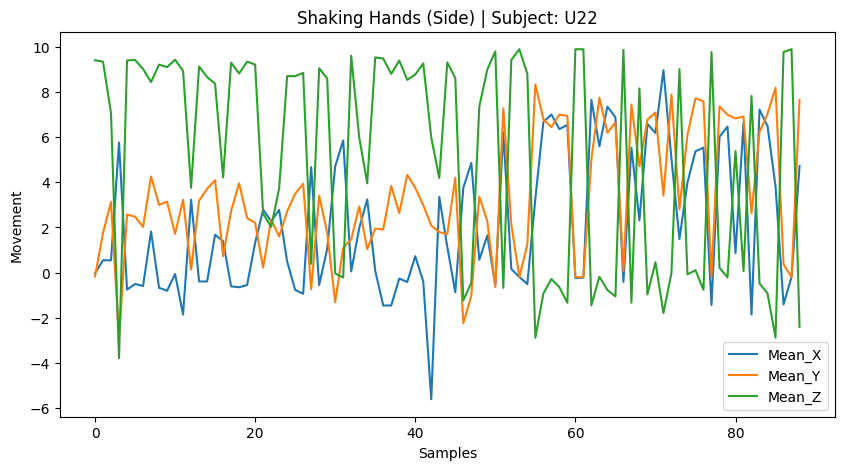

In [ ]:
view_activity(5)

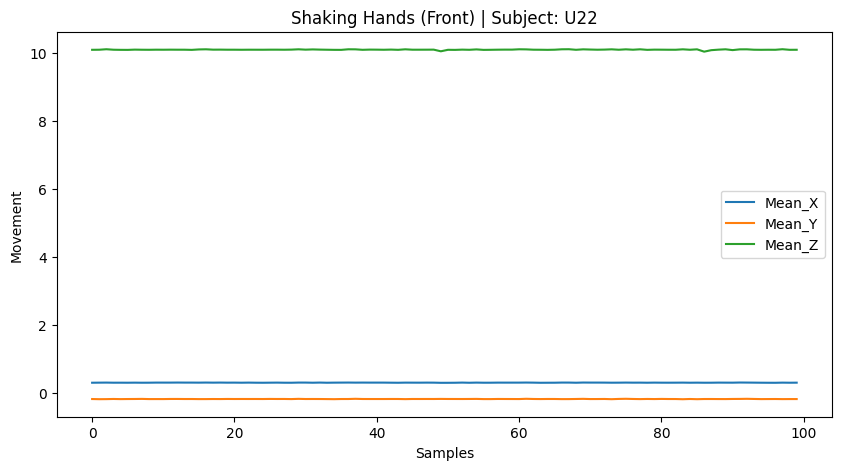

In [ ]:
view_activity(2)

In [ ]:
activity_map = dict(zip(labels["Activity Type ID"], labels["Activity Type"]))

In [ ]:
labels.groupby("Activity Type ID")["Subject"].unique()

,Subject
Activity Type ID,
2806,"[U22, U2, U1, U21, U4, U5, U3, U6, U7]"
2807,"[U22, U2, U21, U4, U5, U1, U3, U6, U7]"
2808,"[U2, U22, U21, U4, U5, U1, U3, U6, U7]"
2809,"[U22, U21, U4, U5, U1, U2, U3, U6, U7]"
2810,"[U22, U21, U4, U5, U1, U2, U3, U6, U7]"
2811,"[U22, U21, U4, U5, U1, U2, U3, U6, U7]"
2812,"[U22, U21, U4, U5, U1, U2, U3, U6, U7]"
2813,"[U22, U21, U4, U5, U1, U2, U6, U3, U7]"
2814,"[U22, U21, U4, U5, U1, U2, U6, U3, U7]"


In [ ]:
import random
import matplotlib.pyplot as plt

def view_activity_final(activity_id):

    # filter activity
    df_act = df[df["activity_class"] == activity_id]

    if len(df_act) == 0:
        print("No data ❌")
        return

    # pick RANDOM subject (fix U22 problem)
    subjects = df_act["subject"].unique()
    subject = random.choice(subjects)

    df_sub = df_act[df_act["subject"] == subject]

    # get tremor level
    tremor = df_sub["tremor_level"].iloc[0]

    # get correct activity name
    activity_name = activity_map_fixed.get(activity_id, "Unknown")

    # plot
    plt.figure(figsize=(10,5))

    plt.plot(df_sub["Mean_X"].values[:100], label="X-axis")
    plt.plot(df_sub["Mean_Y"].values[:100], label="Y-axis")
    plt.plot(df_sub["Mean_Z"].values[:100], label="Z-axis")

    plt.title(
        f"Subject: {subject} | Activity {activity_id}: {activity_name}\n"
        f"Tremor Level: {tremor}"
    )

    plt.xlabel("Samples")
    plt.ylabel("Movement")
    plt.legend()
    plt.show()

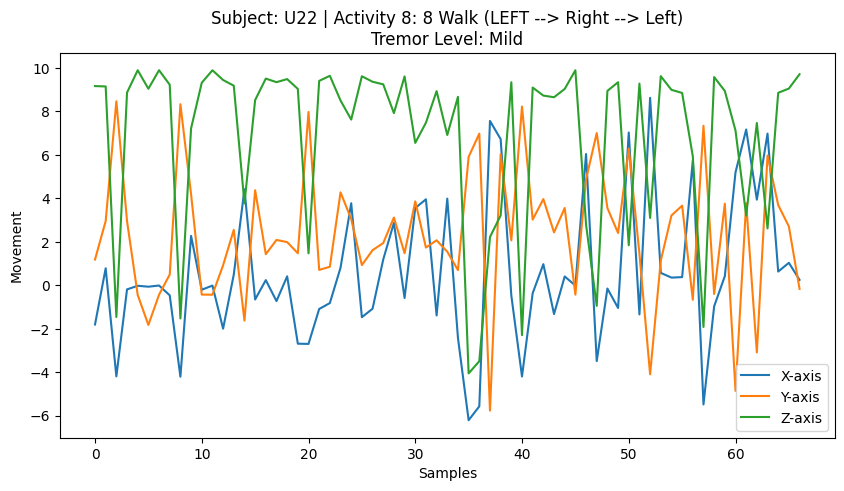

In [ ]:
view_activity_final(8)

In [ ]:
reverse_map = {v: k for k, v in activity_map_fixed.items()}

In [ ]:
import random
import matplotlib.pyplot as plt

def view_activity_final(activity_id):

    df_act = df[df["activity_class"] == activity_id]

    if len(df_act) == 0:
        print("No data ❌")
        return

    # pick random subject
    subjects = df_act["subject"].unique()
    subject = random.choice(subjects)

    df_sub = df_act[df_act["subject"] == subject]

    tremor = df_sub["tremor_level"].iloc[0]

    # get activity name
    activity_name = activity_map_fixed.get(activity_id, "Unknown")

    # get original ID (2806–2815)
    original_id = reverse_map.get(activity_name, "N/A")

    # plot
    plt.figure(figsize=(10,5))

    plt.plot(df_sub["Mean_X"].values[:100], label="X-axis")
    plt.plot(df_sub["Mean_Y"].values[:100], label="Y-axis")
    plt.plot(df_sub["Mean_Z"].values[:100], label="Z-axis")

    # 🔥 FINAL TITLE (your requirement)
    plt.title(
        f"Subject: {subject} | Activity {original_id} (Class {activity_id})\n"
        f"{activity_name}\n"
        f"Tremor Level: {tremor}"
    )

    plt.xlabel("Samples")
    plt.ylabel("Movement")
    plt.legend()
    plt.show()

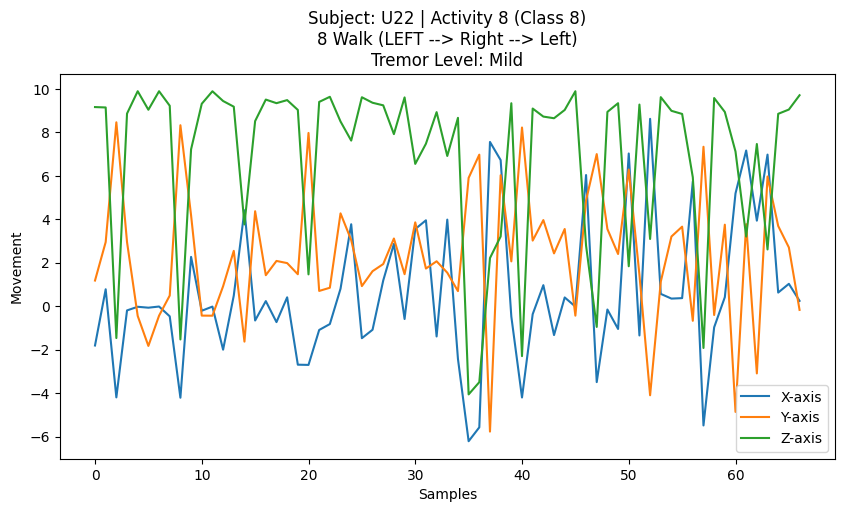

In [ ]:
view_activity_final(8)

In [ ]:
class_to_original = {
    1: 2806,
    2: 2807,
    3: 2808,
    4: 2809,
    5: 2810,
    6: 2811,
    7: 2812,
    8: 2813,
    9: 2814,
    10: 2815
}

In [ ]:
import random
import matplotlib.pyplot as plt

# ======================================
# 1. CLASS → ORIGINAL ID MAPPING
# ======================================
class_to_original = {
    1: 2806,
    2: 2807,
    3: 2808,
    4: 2809,
    5: 2810,
    6: 2811,
    7: 2812,
    8: 2813,
    9: 2814,
    10: 2815
}

# ======================================
# 2. CLASS → ACTIVITY NAME MAPPING
# ======================================
activity_map_fixed = {
    1: "1 (FACING camera) Sit and stand",
    2: "2 (FACING camera) both hands SHAKING (sitting position)",
    3: "3 Stand up from chair - both hands with SHAKING",
    4: "4 (Sideway) Sit & stand",
    5: "5 (Sideway) both hands SHAKING (sitting)",
    6: "6 (Sideway) STAND up with - both hands SHAKING",
    7: "7 Cool down - sitting/relax",
    8: "8 Walk (LEFT --> Right --> Left)",
    9: "9 Walk & STOP/frozen, full body shaking",
    10: "10 Slow walk (SHAKING hands/body)"
}

# ======================================
# 3. FINAL FUNCTION
# ======================================
def view_activity_final(activity_id):

    df_act = df[df["activity_class"] == activity_id]

    if len(df_act) == 0:
        print("No data ❌")
        return

    # pick random subject (fix U22 issue)
    subjects = df_act["subject"].unique()
    subject = random.choice(subjects)

    df_sub = df_act[df_act["subject"] == subject]

    # tremor level
    tremor = df_sub["tremor_level"].iloc[0]

    # get mappings
    activity_name = activity_map_fixed.get(activity_id, "Unknown")
    original_id = class_to_original.get(activity_id, "N/A")

    # ======================================
    # PLOT
    # ======================================
    plt.figure(figsize=(10,5))

    plt.plot(df_sub["Mean_X"].values[:100], label="X-axis")
    plt.plot(df_sub["Mean_Y"].values[:100], label="Y-axis")
    plt.plot(df_sub["Mean_Z"].values[:100], label="Z-axis")

    plt.title(
        f"Subject: {subject} | Activity {original_id} (Class {activity_id})\n"
        f"{activity_name}\n"
        f"Tremor Level: {tremor}"
    )

    plt.xlabel("Samples")
    plt.ylabel("Movement")
    plt.legend()
    plt.show()

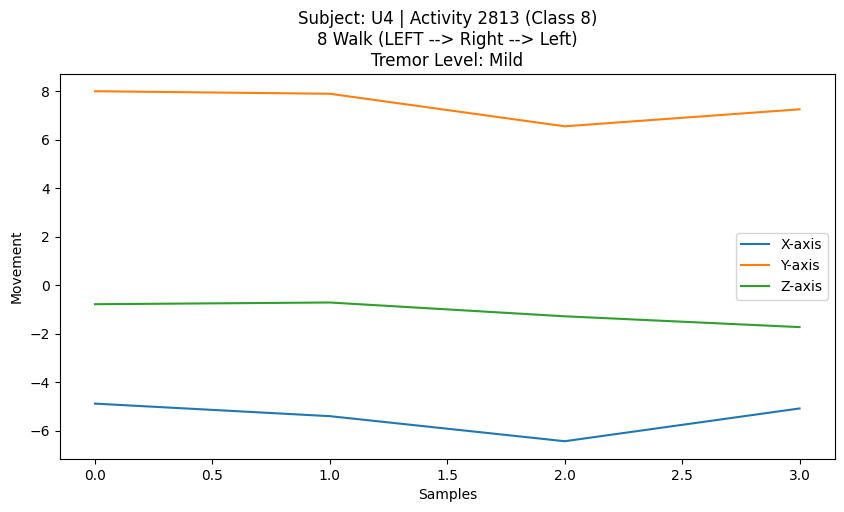

In [ ]:
view_activity_final(8)

In [ ]:
import os

folder_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807"

files = os.listdir(folder_path)
print(files[:5])

['user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv', 'user-acc_2807_2024-09-06T01_25_20.485+0100_91671.csv', 'user-acc_2807_2024-09-06T03_14_10.907+0100_74767.csv', 'user-acc_2807_2024-09-06T04_12_45.305+0100_74081.csv', 'user-acc_2807_2024-09-06T04_02_53.785+0100_27770.csv']


Files found: ['user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv', 'user-acc_2807_2024-09-06T01_25_20.485+0100_91671.csv', 'user-acc_2807_2024-09-06T03_14_10.907+0100_74767.csv', 'user-acc_2807_2024-09-06T04_12_45.305+0100_74081.csv', 'user-acc_2807_2024-09-06T04_02_53.785+0100_27770.csv']

Dataset Preview:
   2807  2024-09-06T03:05:01.780+0100  0.311  -0.175  10.087
0  2807  2024-09-06T03:05:01.944+0100  0.309  -0.172  10.084
1  2807  2024-09-06T03:05:02.105+0100  0.321  -0.175  10.101
2  2807  2024-09-06T03:05:02.261+0100  0.302  -0.170  10.101
3  2807  2024-09-06T03:05:02.423+0100  0.309  -0.160  10.096
4  2807  2024-09-06T03:05:02.582+0100  0.306  -0.180  10.089

Columns:
Index(['2807', '2024-09-06T03:05:01.780+0100', '0.311', '-0.175', '10.087'], dtype='object')


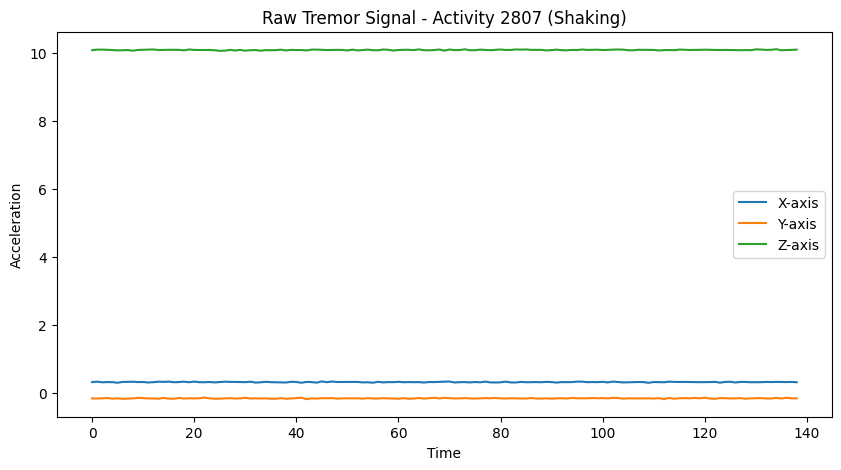


Tremor Strength (Standard Deviation):
Std X: 0.0083169790518211
Std Y: 0.008394934449315225
Std Z: 0.009261890125436201


In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import os
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# 2. SELECT FOLDER (CHANGE IF NEEDED)
# ======================================
folder_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807"

# ======================================
# 3. LIST FILES
# ======================================
files = os.listdir(folder_path)
print("Files found:", files[:5])

# ======================================
# 4. LOAD ONE FILE
# ======================================
file_path = os.path.join(folder_path, files[0])

raw_df = pd.read_csv(file_path)

print("\nDataset Preview:")
print(raw_df.head())

print("\nColumns:")
print(raw_df.columns)

# ======================================
# 5. PLOT RAW SIGNAL (TREMOR)
# ======================================
plt.figure(figsize=(10,5))

plt.plot(raw_df.iloc[:200, 2], label="X-axis")
plt.plot(raw_df.iloc[:200, 3], label="Y-axis")
plt.plot(raw_df.iloc[:200, 4], label="Z-axis")

plt.title("Raw Tremor Signal - Activity 2807 (Shaking)")
plt.xlabel("Time")
plt.ylabel("Acceleration")

plt.legend()
plt.show()

# ======================================
# 6. MEASURE TREMOR (IMPORTANT)
# ======================================
std_x = raw_df.iloc[:, 2].std()
std_y = raw_df.iloc[:, 3].std()
std_z = raw_df.iloc[:, 4].std()

print("\nTremor Strength (Standard Deviation):")
print("Std X:", std_x)
print("Std Y:", std_y)
print("Std Z:", std_z)

In [ ]:
# ======================================
# 1. IMPORT
# ======================================
import os
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# 2. PICK ONE FILE (you can change name)
# ======================================
file_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv"

# ======================================
# 3. LOAD FILE
# ======================================
raw_df = pd.read_csv(file_path)

print("File loaded ✅")
print(raw_df.head())

# ======================================
# 4. PLOT SIGNAL (TREMOR)
# ======================================
plt.figure(figsize=(10,5))

plt.plot(raw_df.iloc[:200, 2], label="X-axis")
plt.plot(raw_df.iloc[:200, 3], label="Y-axis")
plt.plot(raw_df.iloc[:200, 4], label="Z-axis")

plt.title("Raw Tremor Signal - Activity 2807 (Shaking)")
plt.xlabel("Time")
plt.ylabel("Acceleration")

plt.legend()
plt.show()

# ======================================
# 5. CHECK TREMOR STRENGTH
# ======================================
std_x = raw_df.iloc[:, 2].std()
std_y = raw_df.iloc[:, 3].std()
std_z = raw_df.iloc[:, 4].std()

print("\nTremor Strength:")
print("Std X:", std_x)
print("Std Y:", std_y)
print("Std Z:", std_z)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv'

File loaded ✅
   2807  2024-09-06T03:05:01.780+0100  0.311  -0.175  10.087
0  2807  2024-09-06T03:05:01.944+0100  0.309  -0.172  10.084
1  2807  2024-09-06T03:05:02.105+0100  0.321  -0.175  10.101
2  2807  2024-09-06T03:05:02.261+0100  0.302  -0.170  10.101
3  2807  2024-09-06T03:05:02.423+0100  0.309  -0.160  10.096
4  2807  2024-09-06T03:05:02.582+0100  0.306  -0.180  10.089

Tremor Score: 0.025973803626572527
Tremor Level: Normal


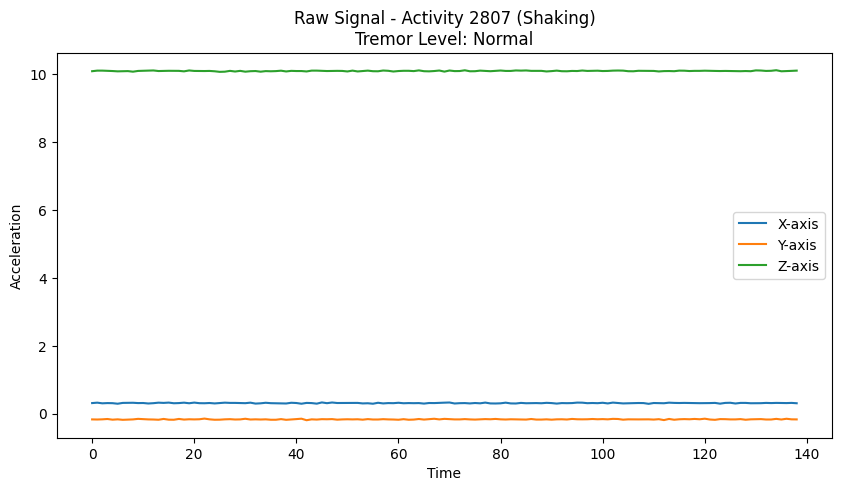

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# 2. LOAD SINGLE FILE
# ======================================
file_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv"

raw_df = pd.read_csv(file_path)

print("File loaded ✅")
print(raw_df.head())

# ======================================
# 3. EXTRACT SIGNAL (x, y, z)
# ======================================
x = raw_df.iloc[:, 2]
y = raw_df.iloc[:, 3]
z = raw_df.iloc[:, 4]

# ======================================
# 4. CALCULATE TREMOR (STD)
# ======================================
std_x = x.std()
std_y = y.std()
std_z = z.std()

tremor_score = std_x + std_y + std_z

# ======================================
# 5. CLASSIFY TREMOR LEVEL
# ======================================
if tremor_score < 5:
    tremor_level = "Normal"
elif tremor_score < 15:
    tremor_level = "Mild"
else:
    tremor_level = "High"

print("\nTremor Score:", tremor_score)
print("Tremor Level:", tremor_level)

# ======================================
# 6. PLOT SIGNAL
# ======================================
plt.figure(figsize=(10,5))

plt.plot(x[:200], label="X-axis")
plt.plot(y[:200], label="Y-axis")
plt.plot(z[:200], label="Z-axis")

plt.title(
    f"Raw Signal - Activity 2807 (Shaking)\n"
    f"Tremor Level: {tremor_level}"
)

plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.legend()
plt.show()

In [ ]:
# ======================================
# 1. IMPORT
# ======================================
import os
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# 2. LOAD LABEL FILE (for activity + subject)
# ======================================
labels = pd.read_csv(
    "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"
)

# ======================================
# 3. CREATE ACTIVITY ID → NAME MAP
# ======================================
activity_id_to_name = {}

for _, row in labels.iterrows():
    activity_id_to_name[row["Activity Type ID"]] = row["Activity Type"]

# ======================================
# 4. SELECT ONE RAW FILE
# ======================================
file_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2807/user-acc_2807_2024-09-06T03_05_01.785+0100_43074.csv"

# extract activity ID from path
activity_id = int(file_path.split("/")[-2])

# ======================================
# 5. LOAD RAW DATA
# ======================================
raw_df = pd.read_csv(file_path)

print("File loaded ✅")

# ======================================
# 6. GET ACTIVITY NAME
# ======================================
activity_name = activity_id_to_name.get(activity_id, "Unknown")

# ======================================
# 7. GET SUBJECT (from labels)
# ======================================
subjects = labels[labels["Activity Type ID"] == activity_id]["Subject"].unique()
subject = ", ".join(subjects[:3])  # show few subjects

# ======================================
# 8. EXTRACT SIGNAL
# ======================================
x = raw_df.iloc[:, 2]
y = raw_df.iloc[:, 3]
z = raw_df.iloc[:, 4]

# ======================================
# 9. CALCULATE TREMOR
# ======================================
std_x = x.std()
std_y = y.std()
std_z = z.std()

tremor_score = std_x + std_y + std_z

# ======================================
# 10. CLASSIFY TREMOR
# ======================================
if tremor_score < 5:
    tremor_level = "Normal"
elif tremor_score < 15:
    tremor_level = "Mild"
else:
    tremor_level = "High"

print("\nTremor Score:", tremor_score)
print("Tremor Level:", tremor_level)

# ======================================
# 11. PLOT
# ======================================
plt.figure(figsize=(10,5))

plt.plot(x[:200], label="X-axis")
plt.plot(y[:200], label="Y-axis")
plt.plot(z[:200], label="Z-axis")

plt.title(
    f"Subject(s): {subject}\n"
    f"Activity {activity_id}: {activity_name}\n"
    f"Tremor Level: {tremor_level}"
)

plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.legend()
plt.show()

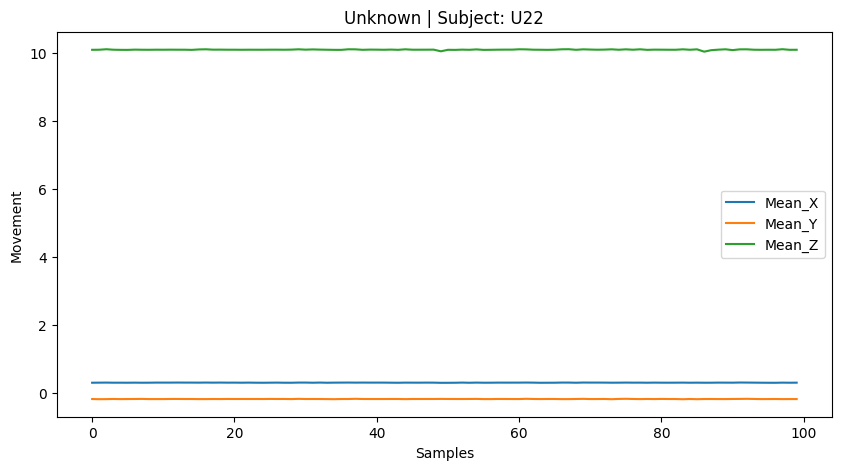

In [ ]:
view_activity(2)

Visualization of Activities and Tremor Intensity using Sensor Features


In [ ]:
def view_activity_clear(activity_id):

    df_act = df[df["activity_class"] == activity_id]

    # pick first sample
    row = df_act.iloc[0]

    subject = row["subject"]
    tremor = row["tremor_level"]

    activity_name = activity_map.get(activity_id, "Unknown")

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))

    plt.plot(df_act["Mean_X"].values[:100], label="X-axis")
    plt.plot(df_act["Mean_Y"].values[:100], label="Y-axis")
    plt.plot(df_act["Mean_Z"].values[:100], label="Z-axis")

    # 🔥 FULL CLEAR TITLE
    plt.title(
        f"Dataset: final_loso_dataset_with_features.csv\n"
        f"Subject: {subject} | Activity {activity_id}: {activity_name}\n"
        f"Tremor Level: {tremor}"
    )

    plt.xlabel("Samples")
    plt.ylabel("Movement")
    plt.legend()
    plt.show()

view the activities

In [ ]:
view_activity_clear(6)

NameError: name 'view_activity_clear' is not defined

view activity class

In [ ]:
print(df["activity_class"].unique())

NameError: name 'df' is not defined

In [ ]:
print(labels["Activity Type ID"].unique())

[2806 2807 2808 2809 2810 2811 2812 2813 2814 2815]


In [ ]:
print(activity_map)

{2806: '1 (FACING camera) Sit and stand', 2807: '2 (FACING camera) both hands SHAKING (sitting position)', 2808: '3 Stand up from chair - both hands with SHAKING', 2809: '4 (Sideway) Sit & stand', 2810: '5 (Sideway) both hands SHAKING (sitting)', 2811: '6 (Sideway) STAND up with - both hands SHAKING', 2812: '7 Cool down - sitting/relax', 2813: '8 Walk (LEFT --> Right --> Left)', 2814: '9 Walk & STOP/frozen, full body shaking, rotate then return back', 2815: '10 Slow walk (SHAKING hands/body, tiny step, head forward)'}


In [ ]:
activity_map_fixed = {}

for _, row in labels.iterrows():
    full_name = row["Activity Type"]

    # extract number (1–10)
    class_id = int(full_name.split()[0])

    activity_map_fixed[class_id] = full_name

print(activity_map_fixed)

{1: '1 (FACING camera) Sit and stand', 2: '2 (FACING camera) both hands SHAKING (sitting position)', 3: '3 Stand up from chair - both hands with SHAKING', 4: '4 (Sideway) Sit & stand', 5: '5 (Sideway) both hands SHAKING (sitting)', 6: '6 (Sideway) STAND up with - both hands SHAKING', 7: '7 Cool down - sitting/relax', 8: '8 Walk (LEFT --> Right --> Left)', 9: '9 Walk & STOP/frozen, full body shaking, rotate then return back', 10: '10 Slow walk (SHAKING hands/body, tiny step, head forward)'}


In [ ]:
activity_map_fixed = {}

for _, row in labels.iterrows():
    full_name = row["Activity Type"]
    class_id = int(full_name.split()[0])
    activity_map_fixed[class_id] = full_name

In [ ]:
activity_map_fixed = {}

for _, row in labels.iterrows():
    full_name = row["Activity Type"]
    class_id = int(full_name.split()[0])  # extract 1–10
    activity_map_fixed[class_id] = full_name

print("Mapping ready ✅")

Mapping ready ✅


In [ ]:
def view_activity_clear(activity_id):

    df_act = df[df["activity_class"] == activity_id]

    # safety check
    if len(df_act) == 0:
        print("No data for this activity ❌")
        return

    row = df_act.iloc[0]

    subject = row["subject"]
    tremor = row["tremor_level"]

    # ✅ CORRECT mapping used here
    activity_name = activity_map_fixed.get(activity_id, "Unknown")

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))

    plt.plot(df_act["Mean_X"].values[:100], label="X-axis")
    plt.plot(df_act["Mean_Y"].values[:100], label="Y-axis")
    plt.plot(df_act["Mean_Z"].values[:100], label="Z-axis")

    plt.title(
        f"Dataset: final_loso_dataset_with_features.csv\n"
        f"Subject: {subject} | Activity {activity_id}: {activity_name}\n"
        f"Tremor Level: {tremor}"
    )

    plt.xlabel("Samples")
    plt.ylabel("Movement")
    plt.legend()
    plt.show()

In [ ]:
view_activity_clear(2)

NameError: name 'df' is not defined

In [ ]:
labels[["Subject", "Activity Type ID", "Activity Type"]].head()

,Subject,Activity Type ID,Activity Type
0,U22,2806,1 (FACING camera) Sit and stand
1,U22,2807,2 (FACING camera) both hands SHAKING (sitting ...
2,U22,2807,2 (FACING camera) both hands SHAKING (sitting ...
3,U22,2806,1 (FACING camera) Sit and stand
4,U2,2806,1 (FACING camera) Sit and stand


In [ ]:
print("activity_id" in locals())

False


In [ ]:
activity_id = 5

activity_name = activity_map_fixed.get(activity_id, "Unknown")

print(activity_name)

5 (Sideway) both hands SHAKING (sitting)


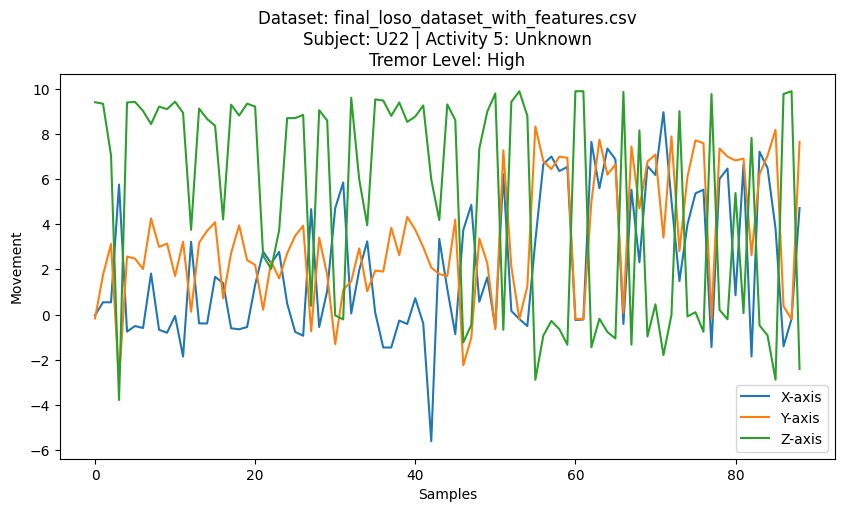

In [ ]:
view_activity_clear(5)

In [ ]:
labels[labels["Subject"] == "U22"]

,ID,Activity Type ID,Activity Type,Started,Finished,Updated,Subject
0,1130251,2806,1 (FACING camera) Sit and stand,2024/09/02 6:16,2024/09/02 6:16,2024/09/02 6:16,U22
1,1130254,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024/09/02 6:17,2024/09/02 6:17,2024/09/02 6:17,U22
2,1130257,2807,2 (FACING camera) both hands SHAKING (sitting ...,2024/09/02 6:18,2024/09/02 6:18,2024/09/02 6:18,U22
3,1130261,2806,1 (FACING camera) Sit and stand,2024/09/02 6:20,2024/09/02 6:20,2024/09/02 6:20,U22
8,1136872,2806,1 (FACING camera) Sit and stand,2024/09/03 19:56,2024/09/03 19:56,2024/09/03 19:56,U22
...,...,...,...,...,...,...,...
220,1144497,2814,"9 Walk & STOP/frozen, full body shaking, rotat...",NaN,NaN,2024/09/05 18:18,U22
221,1144498,2814,"9 Walk & STOP/frozen, full body shaking, rotat...",NaN,NaN,2024/09/05 18:18,U22
222,1144499,2815,"10 Slow walk (SHAKING hands/body, tiny step, h...",NaN,NaN,2024/09/05 18:18,U22
223,1144500,2815,"10 Slow walk (SHAKING hands/body, tiny step, h...",NaN,NaN,2024/09/05 18:18,U22


In [ ]:
def view_activity(activity_id):

    activity_map = {
        1: "Sit & Stand (Front)",
        2: "Shaking Hands (Front)",
        3: "Stand with Shaking",
        4: "Sit & Stand (Side)",
        5: "Shaking Hands (Side)",
        6: "Stand with Shaking (Side)",
        7: "Relax",
        8: "Walk",
        9: "Walk & Freeze",
        10: "Slow Walk (Tremor)"
    }

    df_act = df[df["activity_class"] == activity_id]

    import matplotlib.pyplot as plt

    plt.plot(df_act["Mean_X"].values[:100])
    plt.plot(df_act["Mean_Y"].values[:100])
    plt.plot(df_act["Mean_Z"].values[:100])

    plt.title(f"Activity {activity_id}: {activity_map[activity_id]}")
    plt.show()

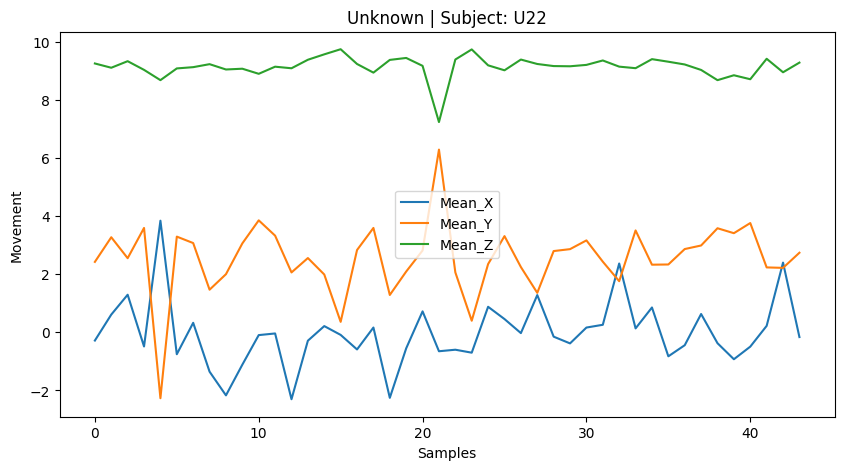

In [ ]:
view_activity(6)

In [ ]:
data_small = pd.DataFrame(dataset_rows)

print("Shape:", data_small.shape)
print("\nFirst rows:")
print(data_small.head())

print("\nActivity class counts:")
print(data_small["activity_class"].value_counts())

print("\nSubjects:")
print(data_small["subject"].value_counts())

Shape: (0, 0)

First rows:
Empty DataFrame
Columns: []
Index: []

Activity class counts:


KeyError: 'activity_class'

In [ ]:
import os
import re
import pandas as pd
import numpy as np

OFFSET = pd.Timedelta(hours=7, minutes=30)
BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

dataset_rows = []

for idx in range(len(labels)):
    row = labels.iloc[idx]

    activity_id = row["Activity Type ID"]
    start_time = row["Started"]
    subject = row["Subject"]

    corrected_time = start_time - OFFSET
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)

    for fname in files:
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= pd.Timedelta(minutes=10):

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            dataset_rows.append({
                "Mean_X": np.mean(x),
                "Std_X": np.std(x),
                "Mean_Y": np.mean(y),
                "Std_Y": np.std(y),
                "Mean_Z": np.mean(z),
                "Std_Z": np.std(z),
                "Mean_Mag": np.mean(mag),
                "Std_Mag": np.std(mag),
                "activity_class": activity_id - 2805,
                "subject": subject,
                "file": fname
            })

print("Total rows collected:", len(dataset_rows))

In [ ]:
data = pd.DataFrame(dataset_rows)

print("Before removing duplicates:", data.shape)

# remove exact duplicate rows (same file + subject + activity)
data = data.drop_duplicates(subset=["file", "subject", "activity_class"]).copy()

print("After removing duplicates:", data.shape)

print("\nActivity class counts:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject counts:")
print(data["subject"].value_counts())

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features
X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]
groups = data["subject"]

gkf = GroupKFold(n_splits=5)

accs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = model.predict(X.iloc[test_idx])

    acc = accuracy_score(y.iloc[test_idx], preds)
    accs.append(acc)

    print(f"Fold {fold} accuracy:", acc)

print("\nMean accuracy:", sum(accs)/len(accs))

In [ ]:
small_files = 0
total_files = 0

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

for idx in range(len(labels)):
    row = labels.iloc[idx]
    activity_id = row["Activity Type ID"]
    start_time = row["Started"]
    subject = row["Subject"]

    corrected_time = start_time - OFFSET
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= pd.Timedelta(minutes=10):

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            total_files += 1
            if len(df) <= 1:
                small_files += 1

print("Total matched files:", total_files)
print("Files with only 1 row:", small_files)

In [ ]:
dataset_rows = []

for idx in range(len(labels)):
    row = labels.iloc[idx]

    activity_id = row["Activity Type ID"]
    start_time = row["Started"]
    subject = row["Subject"]

    corrected_time = start_time - OFFSET
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= pd.Timedelta(minutes=10):

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            def features(arr):
                return {
                    "mean": np.mean(arr),
                    "std": np.std(arr),
                    "min": np.min(arr),
                    "max": np.max(arr),
                    "range": np.max(arr) - np.min(arr),
                    "energy": np.sum(arr**2)
                }

            fx = features(x)
            fy = features(y)
            fz = features(z)
            fm = features(mag)

            dataset_rows.append({
                **{f"X_{k}":v for k,v in fx.items()},
                **{f"Y_{k}":v for k,v in fy.items()},
                **{f"Z_{k}":v for k,v in fz.items()},
                **{f"M_{k}":v for k,v in fm.items()},
                "activity_class": activity_id - 2805,
                "subject": subject,
                "file": fname
            })

print("Total rows:", len(dataset_rows))

In [ ]:
data = pd.DataFrame(dataset_rows)
data = data.drop_duplicates(subset=["file","subject","activity_class"])
print("After duplicates removed:", data.shape)

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]
groups = data["subject"]

gkf = GroupKFold(n_splits=5)

accs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    model = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = model.predict(X.iloc[test_idx])

    acc = accuracy_score(y.iloc[test_idx], preds)
    accs.append(acc)

    print(f"Fold {fold} accuracy:", acc)

print("\nMean accuracy:", sum(accs)/len(accs))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=400, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Random split accuracy:", accuracy_score(y_test, preds))

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]
groups = data["subject"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

gkf = GroupKFold(n_splits=5)

accs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_scaled, y, groups), 1):
    model = RandomForestClassifier(n_estimators=400, random_state=42)

    model.fit(X_scaled[train_idx], y.iloc[train_idx])
    preds = model.predict(X_scaled[test_idx])

    acc = accuracy_score(y.iloc[test_idx], preds)
    accs.append(acc)

    print(f"Fold {fold} accuracy:", acc)

print("\nMean accuracy:", sum(accs)/len(accs))

In [ ]:
from sklearn.model_selection import GroupKFold
import numpy as np

X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]
groups = data["subject"]

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    print(f"\nFold {fold}")
    print("Train classes:", np.unique(y.iloc[train_idx]))
    print("Test classes :", np.unique(y.iloc[test_idx]))

In [ ]:
print(pd.crosstab(data["subject"], data["activity_class"]))

In [ ]:
labels.groupby("Subject")["Activity Type ID"].unique()

In [ ]:
# Test larger window for U1 and activity 2806

OFFSET = pd.Timedelta(hours=7, minutes=30)
WINDOW = pd.Timedelta(minutes=45)

test_rows = labels[(labels["Subject"]=="U1") &
                   (labels["Activity Type ID"]==2806)]

print("Label rows found:", len(test_rows))

folder = os.path.join(BASE_PATH, "2806")

matched = 0

for _, row in test_rows.iterrows():
    corrected_time = row["Started"] - OFFSET

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:
            matched += 1

print("Matched files with 45-min window:", matched)

In [ ]:
import os, re
import pandas as pd
import numpy as np

OFFSET = pd.Timedelta(hours=7, minutes=30)
WINDOW = pd.Timedelta(minutes=45)

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

dataset_rows = []

def feats(arr):
    return {
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "range": float(np.max(arr) - np.min(arr)),
        "energy": float(np.sum(arr**2))
    }

for idx in range(len(labels)):
    row = labels.iloc[idx]
    activity_id = int(row["Activity Type ID"])
    subject = row["Subject"]
    corrected_time = row["Started"] - OFFSET

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:
            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            fx = feats(x); fy = feats(y); fz = feats(z); fm = feats(mag)

            dataset_rows.append({
                **{f"X_{k}": v for k, v in fx.items()},
                **{f"Y_{k}": v for k, v in fy.items()},
                **{f"Z_{k}": v for k, v in fz.items()},
                **{f"M_{k}": v for k, v in fm.items()},
                "activity_class": activity_id - 2805,
                "subject": subject,
                "file": fname
            })

print("Total collected rows (with duplicates):", len(dataset_rows))

data = pd.DataFrame(dataset_rows)
data = data.drop_duplicates(subset=["file","subject","activity_class"]).copy()

print("After removing duplicates:", data.shape)

print("\nClass counts:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject counts:")
print(data["subject"].value_counts())

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]
groups = data["subject"]

gkf = GroupKFold(n_splits=5)

accs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    model = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = model.predict(X.iloc[test_idx])

    acc = accuracy_score(y.iloc[test_idx], preds)
    accs.append(acc)

    print(f"Fold {fold} accuracy:", acc)

print("\nMean accuracy:", sum(accs)/len(accs))

In [ ]:
from sklearn.model_selection import GroupKFold
import numpy as np

X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]
groups = data["subject"]

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    test_subjects = np.unique(groups.iloc[test_idx])
    print(f"Fold {fold} test subjects:", test_subjects)

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]
groups = data["subject"]

gkf = GroupKFold(n_splits=5)

accs = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups), 1):
    model = RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = model.predict(X.iloc[test_idx])

    acc = accuracy_score(y.iloc[test_idx], preds)
    accs.append(acc)

    print(f"Fold {fold} accuracy:", acc)

print("\nMean accuracy:", sum(accs)/len(accs))

In [ ]:
print(pd.crosstab(data["subject"], data["activity_class"]).loc["U7"])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

subjects = data["subject"].unique()
loso_acc = []

X = data.drop(columns=["activity_class","subject","file"])
y = data["activity_class"]

for subj in subjects:
    train_idx = data["subject"] != subj
    test_idx = data["subject"] == subj

    model = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X[train_idx], y[train_idx])
    preds = model.predict(X[test_idx])

    acc = accuracy_score(y[test_idx], preds)
    loso_acc.append(acc)

    print(f"Subject {subj} accuracy:", acc)

print("\nMean LOSO accuracy:", np.mean(loso_acc))

In [ ]:
labels["Activity Type ID"].unique()

NameError: name 'labels' is not defined

In [ ]:
labels[labels["Activity Type ID"].isin([2813, 2814, 2815])].shape

NameError: name 'labels' is not defined

In [ ]:
import os, re
import pandas as pd

OFFSET = pd.Timedelta(hours=7, minutes=30)
WINDOW = pd.Timedelta(minutes=90)

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

labels_8_9_10 = labels[labels["Activity Type ID"].isin([2813, 2814, 2815])].copy()

matched_counts = {8:0, 9:0, 10:0}

for _, row in labels_8_9_10.iterrows():
    activity_id = int(row["Activity Type ID"])
    cls = activity_id - 2805  # 2813->8, 2814->9, 2815->10
    corrected_time = row["Started"] - OFFSET

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue
        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:
            matched_counts[cls] += 1

print("Matched files (with duplicates) for class 8/9/10:", matched_counts)

In [ ]:
import os

base = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
print("2813 exists:", os.path.exists(os.path.join(base, "2813")))
print("2814 exists:", os.path.exists(os.path.join(base, "2814")))
print("2815 exists:", os.path.exists(os.path.join(base, "2815")))

if os.path.exists(os.path.join(base, "2813")):
    print("2813 files:", len(os.listdir(os.path.join(base, "2813"))))
if os.path.exists(os.path.join(base, "2814")):
    print("2814 files:", len(os.listdir(os.path.join(base, "2814"))))
if os.path.exists(os.path.join(base, "2815")):
    print("2815 files:", len(os.listdir(os.path.join(base, "2815"))))

In [ ]:
import os, re
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

# Take first label row for activity 2813
label_2813 = labels[labels["Activity Type ID"] == 2813].iloc[0]
label_time = label_2813["Started"]

folder = os.path.join(BASE_PATH, "2813")

diffs = []

for fname in os.listdir(folder):
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue

    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

    diffs.append(label_time - t)

# Show most common differences
from collections import Counter
counter = Counter(diffs)
print(counter.most_common(5))

In [ ]:
# Extract day differences only
day_shifts = [d.days for d in diffs]

from collections import Counter
print(Counter(day_shifts))

In [ ]:
import os, re
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

OFFSET_HOURS = pd.Timedelta(hours=7, minutes=30)
DAY_SHIFT = pd.Timedelta(days=8)
WINDOW = pd.Timedelta(minutes=45)

labels_2813 = labels[labels["Activity Type ID"] == 2813]

matched = 0

for _, row in labels_2813.iterrows():
    corrected_time = row["Started"] - OFFSET_HOURS - DAY_SHIFT

    folder = os.path.join(BASE_PATH, "2813")

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:
            matched += 1

print("Matched class 8 files:", matched)

In [ ]:
import numpy as np

# convert diffs list to hours
hours = [d.total_seconds()/3600 for d in diffs]
print("Average difference (hours):", np.mean(hours))

In [ ]:
import os, re
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

WINDOW = pd.Timedelta(minutes=45)
SHIFT = pd.Timedelta(days=7, hours=14)

labels_2813 = labels[labels["Activity Type ID"] == 2813]

matched = 0

for _, row in labels_2813.iterrows():
    corrected_time = row["Started"] + SHIFT

    folder = os.path.join(BASE_PATH, "2813")

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:
            matched += 1

print("Matched class 8 files:", matched)

In [ ]:
# For class 9 (2814)

label_2814 = labels[labels["Activity Type ID"] == 2814].iloc[0]
label_time = label_2814["Started"]

folder = os.path.join(BASE_PATH, "2814")

diffs_9 = []

for fname in os.listdir(folder):
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue

    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

    diffs_9.append(label_time - t)

import numpy as np
print("Average difference (hours) for class 9:",
      np.mean([d.total_seconds()/3600 for d in diffs_9]))

In [ ]:
import os, re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

WINDOW = pd.Timedelta(minutes=45)

dataset_rows = []

def feats(arr):
    return {
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "range": float(np.max(arr) - np.min(arr)),
        "energy": float(np.sum(arr**2))
    }

for idx in range(len(labels)):
    row = labels.iloc[idx]
    activity_id = int(row["Activity Type ID"])
    label_time = row["Started"]
    subject = row["Subject"]

    # ===== SHIFT LOGIC =====
    if activity_id <= 2812:
        corrected_time = label_time - pd.Timedelta(hours=7, minutes=30)

    elif activity_id == 2813:
        corrected_time = label_time + pd.Timedelta(days=7, hours=14)

    elif activity_id == 2814:
        corrected_time = label_time + pd.Timedelta(days=7, hours=19)

    elif activity_id == 2815:
    corrected_time = label_time + pd.Timedelta(days=6, hours=14)

    else:
        continue
    # =======================

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            fx = feats(x)
            fy = feats(y)
            fz = feats(z)
            fm = feats(mag)

            dataset_rows.append({
                **{f"X_{k}": v for k, v in fx.items()},
                **{f"Y_{k}": v for k, v in fy.items()},
                **{f"Z_{k}": v for k, v in fz.items()},
                **{f"M_{k}": v for k, v in fm.items()},
                "activity_class": activity_id - 2805,
                "subject": subject,
                "file": fname
            })

print("Total rows (with duplicates):", len(dataset_rows))

data = pd.DataFrame(dataset_rows)
data = data.drop_duplicates(subset=["file","subject","activity_class"]).copy()

print("After removing duplicates:", data.shape)

print("\nClass counts:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject counts:")
print(data["subject"].value_counts())

In [ ]:
# For class 10 (2815)

label_2815 = labels[labels["Activity Type ID"] == 2815].iloc[0]
label_time = label_2815["Started"]

folder = os.path.join(BASE_PATH, "2815")

diffs_10 = []

for fname in os.listdir(folder):
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue

    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

    diffs_10.append(label_time - t)

import numpy as np
print("Average difference (hours) for class 10:",
      np.mean([d.total_seconds()/3600 for d in diffs_10]))

In [ ]:
import os, re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
WINDOW = pd.Timedelta(minutes=45)

dataset_rows = []

def feats(arr):
    return {
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "range": float(np.max(arr) - np.min(arr)),
        "energy": float(np.sum(arr**2))
    }

for idx in range(len(labels)):
    row = labels.iloc[idx]
    activity_id = int(row["Activity Type ID"])
    label_time = row["Started"]
    subject = row["Subject"]

    # ===== FINAL SHIFT LOGIC =====
    if activity_id <= 2812:   # Classes 1–7
        corrected_time = label_time - pd.Timedelta(hours=7, minutes=30)

    elif activity_id == 2813:  # Class 8
        corrected_time = label_time + pd.Timedelta(days=7, hours=14)

    elif activity_id == 2814:  # Class 9
        corrected_time = label_time + pd.Timedelta(days=7, hours=19)

    elif activity_id == 2815:  # Class 10
        corrected_time = label_time + pd.Timedelta(days=6, hours=14)

    else:
        continue
    # ==============================

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            fx = feats(x)
            fy = feats(y)
            fz = feats(z)
            fm = feats(mag)

            dataset_rows.append({
                **{f"X_{k}": v for k, v in fx.items()},
                **{f"Y_{k}": v for k, v in fy.items()},
                **{f"Z_{k}": v for k, v in fz.items()},
                **{f"M_{k}": v for k, v in fm.items()},
                "activity_class": activity_id - 2805,
                "subject": subject,
                "file": fname
            })

print("Total rows (with duplicates):", len(dataset_rows))

data = pd.DataFrame(dataset_rows)
data = data.drop_duplicates(subset=["file","subject","activity_class"]).copy()

print("After removing duplicates:", data.shape)

print("\nClass counts:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject counts:")
print(data["subject"].value_counts())

In [ ]:
print("Class 10 rows (before duplicate removal):",
      sum([1 for r in dataset_rows if r["activity_class"] == 10]))

In [ ]:
# For class 10 (2815)

label_2815 = labels[labels["Activity Type ID"] == 2815].iloc[0]
label_time = label_2815["Started"]

folder = os.path.join(BASE_PATH, "2815")

diffs_10 = []

for fname in os.listdir(folder):
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue

    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

    diffs_10.append(label_time - t)

# Exact mean timedelta
mean_diff = sum(diffs_10, pd.Timedelta(0)) / len(diffs_10)
print("Exact mean timedelta:", mean_diff)

In [ ]:
import os, re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
WINDOW = pd.Timedelta(minutes=45)

dataset_rows = []

def feats(arr):
    return {
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "range": float(np.max(arr) - np.min(arr)),
        "energy": float(np.sum(arr**2))
    }

# Define shifts
SHIFT_1_7 = -pd.Timedelta(hours=7, minutes=30)
SHIFT_8 = pd.Timedelta(days=7, hours=14)
SHIFT_9 = pd.Timedelta(days=7, hours=19)
SHIFT_10 = pd.Timedelta(days=7) - pd.Timedelta(hours=10, minutes=33)

for idx in range(len(labels)):
    row = labels.iloc[idx]
    activity_id = int(row["Activity Type ID"])
    label_time = row["Started"]
    subject = row["Subject"]

    # ===== FINAL SHIFT LOGIC =====
    if activity_id <= 2812:
        corrected_time = label_time + SHIFT_1_7

    elif activity_id == 2813:
        corrected_time = label_time + SHIFT_8

    elif activity_id == 2814:
        corrected_time = label_time + SHIFT_9

    elif activity_id == 2815:
        corrected_time = label_time + SHIFT_10

    else:
        continue
    # ==============================

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            fx = feats(x)
            fy = feats(y)
            fz = feats(z)
            fm = feats(mag)

            dataset_rows.append({
                **{f"X_{k}": v for k, v in fx.items()},
                **{f"Y_{k}": v for k, v in fy.items()},
                **{f"Z_{k}": v for k, v in fz.items()},
                **{f"M_{k}": v for k, v in fm.items()},
                "activity_class": activity_id - 2805,
                "subject": subject,
                "file": fname
            })

print("Total rows (with duplicates):", len(dataset_rows))

data = pd.DataFrame(dataset_rows)
data = data.drop_duplicates(subset=["file","subject","activity_class"]).copy()

print("After removing duplicates:", data.shape)

print("\nClass counts:")
print(data["activity_class"].value_counts().sort_index())

In [ ]:
folder = os.path.join(BASE_PATH, "2815")

file_times = []

for fname in os.listdir(folder):
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if not m:
        continue
    ts = m.group(1).replace("_", ":")
    t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)
    file_times.append(t)

print("File time range:")
print(min(file_times), "to", max(file_times))

In [ ]:
labels_2815 = labels[labels["Activity Type ID"] == 2815]

print("Label time range:")
print(labels_2815["Started"].min(), "to", labels_2815["Started"].max())

In [ ]:
WINDOW = pd.Timedelta(hours=12)

In [ ]:
import os, re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

# Bigger window so continuous activities match
WINDOW = pd.Timedelta(hours=12)

dataset_rows = []

def feats(arr):
    return {
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "range": float(np.max(arr) - np.min(arr)),
        "energy": float(np.sum(arr**2))
    }

# ---- Define Shifts (based on debugging) ----
SHIFT_1_7 = -pd.Timedelta(hours=7, minutes=30)
SHIFT_8 = pd.Timedelta(days=7, hours=14)
SHIFT_9 = pd.Timedelta(days=7, hours=19)
SHIFT_10 = pd.Timedelta(days=7) - pd.Timedelta(hours=10, minutes=33)

for idx in range(len(labels)):
    row = labels.iloc[idx]
    activity_id = int(row["Activity Type ID"])
    label_time = row["Started"]
    subject = row["Subject"]

    # -------- SHIFT LOGIC --------
    if activity_id <= 2812:
        corrected_time = label_time + SHIFT_1_7

    elif activity_id == 2813:
        corrected_time = label_time + SHIFT_8

    elif activity_id == 2814:
        corrected_time = label_time + SHIFT_9

    elif activity_id == 2815:
        corrected_time = label_time + SHIFT_10

    else:
        continue
    # -----------------------------

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        t = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(t - corrected_time) <= WINDOW:

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            fx = feats(x)
            fy = feats(y)
            fz = feats(z)
            fm = feats(mag)

            dataset_rows.append({
                **{f"X_{k}": v for k, v in fx.items()},
                **{f"Y_{k}": v for k, v in fy.items()},
                **{f"Z_{k}": v for k, v in fz.items()},
                **{f"M_{k}": v for k, v in fm.items()},
                "activity_class": activity_id - 2805,
                "subject": subject,
                "file": fname
            })

print("Total rows (with duplicates):", len(dataset_rows))

data = pd.DataFrame(dataset_rows)
data = data.drop_duplicates(subset=["file","subject","activity_class"]).copy()

print("After removing duplicates:", data.shape)

print("\nClass counts:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject counts:")
print(data["subject"].value_counts())

In [ ]:
# Feature columns (exclude non-feature columns)
feature_cols = [c for c in data.columns if c not in ["activity_class", "subject", "file"]]

X = data[feature_cols].values
y = data["activity_class"].values
subjects = data["subject"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
import numpy as np

logo = LeaveOneGroupOut()

accuracies = []

for train_idx, test_idx in logo.split(X, y, groups=subjects):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    test_subject = np.unique(subjects[test_idx])
    print(f"Test Subject: {test_subject} → Accuracy: {acc:.4f}")

print("\nMean LOSO Accuracy:", np.mean(accuracies))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train on all except U7
train_idx = subjects != "U7"
test_idx = subjects == "U7"

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(X[train_idx], y[train_idx])
y_pred = model.predict(X[test_idx])

cm = confusion_matrix(y[test_idx], y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - U7")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
data[data["subject"] == "U7"]["activity_class"].value_counts()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
import numpy as np

logo = LeaveOneGroupOut()

accuracies = []

for train_idx, test_idx in logo.split(X, y, groups=subjects):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Pipeline: Scaling + Logistic Regression
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            multi_class="multinomial",
            solver="lbfgs"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    test_subject = np.unique(subjects[test_idx])
    print(f"Test Subject: {test_subject} → Accuracy: {acc:.4f}")

print("\nMean LOSO Accuracy:", np.mean(accuracies))

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
import numpy as np

logo = LeaveOneGroupOut()
accuracies = []

for train_idx, test_idx in logo.split(X, y, groups=subjects):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            class_weight="balanced_subsample",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    test_subject = np.unique(subjects[test_idx])
    print(f"Test Subject: {test_subject} → Accuracy: {acc:.4f}")

print("\nMean LOSO Accuracy:", np.mean(accuracies))

In [ ]:
activity_map = {
    1: "Sit and Stand (Facing)",
    2: "Tremor Sitting (Facing)",
    3: "Stand with Tremor",
    4: "Sit and Stand (Side)",
    5: "Tremor Sitting (Side)",
    6: "Stand with Tremor (Side)",
    7: "Cool Down / Relax",
    8: "Walk",
    9: "Freezing Episode",
    10: "Slow Walk"
}

In [ ]:
import matplotlib.pyplot as plt
import random
import os
import pandas as pd
import numpy as np

def view_activity(activity_class):

    activity_id = activity_class + 2805
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        print("Folder not found.")
        return

    files = os.listdir(folder)
    if len(files) == 0:
        print("No files found.")
        return

    fname = random.choice(files)
    path = os.path.join(folder, fname)

    df = pd.read_csv(path, header=None)

    print("Activity Class:", activity_class)
    print("Activity Name :", activity_map[activity_class])
    print("File:", fname)

    plt.figure(figsize=(10,4))
    plt.plot(df[2], label="X")
    plt.plot(df[3], label="Y")
    plt.plot(df[4], label="Z")
    plt.title(activity_map[activity_class])
    plt.legend()
    plt.show()

In [ ]:
view_activity(2)

NameError: name 'BASE_PATH' is not defined

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Nirmala Tamang CV (1).docx', 'Nirmala Tamang CV.docx', 'MWIT_Seminar_Activity_Student (2) (1).gdoc', 'MWIT_Seminar_Activity_Student (2).gdoc', 'FastTrack - Accessing Courses Process.docx', 'Assessment Front Sheet (1).gdoc', 'Impact of influencer tourism (2) (1).gdoc', 'Impact of influencer tourism (2).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', '000001.gdoc', 'Reflective Log 2024-25 (1) add (1).docx', 'Reflective Log 2024-25 (1) add.docx', 'Untitled document.gdoc', 'pd-ch-abc25 (1).gdoc', '18956.pdf', 'CN6000Projectwork', 'CARING_LANE_LIMITED_2025_Tax_Week_44.pdf', 'Saved from the Google app', 'final_loso_dataset.csv', 'final_random_forest_model.pkl', 'lstm_model.h5', 'tremor_bed_processed.csv', 'activity_X.npy', 'activity_y.npy', 'final_results.json', 'final_loso_dataset_with_features.csv', 'final_results.txt', 'model_comparison.txt', 'final_smote_xgboost_results.txt']


In [ ]:
print(os.listdir('/content/drive/MyDrive/CN6000Projectwork'))

['TrainingDataPD25', 'full_combined_dataset.csv', 'final_dataset.csv', 'final_model.pkl']


In [ ]:
BASE_PATH = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25'

In [ ]:
import os
print(os.listdir(BASE_PATH))

['readme.txt', 'TrainActivities.csv', 'users_timeXYZ']


In [ ]:
import os
print(os.listdir(BASE_PATH)[:10])

['readme.txt', 'TrainActivities.csv', 'users_timeXYZ']


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ'))

['users']


In [ ]:
BASE_PATH = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users'

In [ ]:
import os
print(os.listdir(BASE_PATH)[:10])

['2830', '38', '2811', '2812', '2814', '2810', '2819', '2816', '2815', '2813']


------------------------------------------------
Activity Class : 1
Activity Name  : Sit and Stand (Facing)
Activity Folder: 2806
Subject ID     : 2806
File Name      : user-acc_2806_2024-09-03T13_43_44.699+0100_5273.csv
Recording Time : 2024-09-03 13:43:44.699000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 7
Predicted Tremor   : High
------------------------------------------------


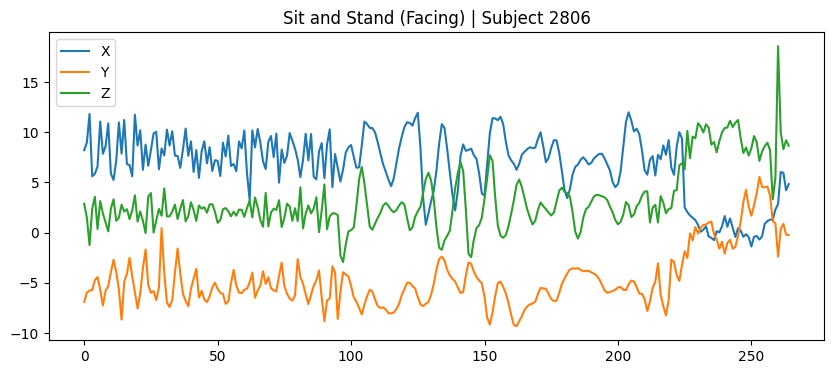

In [ ]:
view_activity_full(1)

In [ ]:
# ===============================
# 1. IMPORT
# ===============================
import pandas as pd
from collections import Counter

# ===============================
# 2. LOAD DATA
# ===============================
file_path = '/content/drive/MyDrive/final_loso_dataset_with_features.csv'
data = pd.read_csv(file_path)

# Remove non-numeric column
data = data.drop(columns=['subject'])

# ===============================
# 3. FEATURES & TARGET
# ===============================
X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 4. TRAIN-TEST SPLIT
# ===============================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 5. SMOTE (IMPORTANT)
# ===============================
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# ===============================
# 6. FIX LABELS FOR XGBOOST
# ===============================
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# ===============================
# 7. CLASS WEIGHTS (🔥 FIX)
# ===============================
class_counts = Counter(y_train_xgb)
total = sum(class_counts.values())

class_weights = {cls: total/count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in y_train_xgb]

# ===============================
# 8. TRAIN MODEL
# ===============================
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train_xgb, sample_weight=sample_weights)

# ===============================
# 9. PREDICT
# ===============================
y_pred = model.predict(X_test)

# Convert back to original labels
y_pred = y_pred + 1

# ===============================
# 10. EVALUATION
# ===============================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("===== FINAL IMPROVED RESULT =====")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

===== FINAL IMPROVED RESULT =====
Accuracy: 0.7076023391812866

Confusion Matrix:
 [[ 0  0  0  1  0  2  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 10  2  0  1  0  0  0  0]
 [ 0  0  2  5  0  1  1  0  0  1]
 [ 0  0  0  0 11  1  1  2  1  3]
 [ 0  0  0  1  1  5  0  1  1  0]
 [ 0  0  1  0  2  3 35  2  3  1]
 [ 1  0  0  0  1  1  0 18  2  0]
 [ 0  0  0  4  0  1  3  2  7  0]
 [ 0  0  0  0  0  0  0  0  0 10]]

Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.77      0.77      0.77        13
           4       0.38      0.50      0.43        10
           5       0.73      0.58      0.65        19
           6       0.33      0.56      0.42         9
           7       0.88      0.74      0.80        47
           8       0.72      0.78      0.75        23
           9       0.50      0.41      0.45        17
          10       0

In [ ]:
for k, v in activity_map.items():
    print(k, ":", v)

1 : Sit and Stand (Facing)
2 : Tremor Sitting (Facing)
3 : Stand with Tremor
4 : Sit and Stand (Side)
5 : Tremor Sitting (Side)
6 : Stand with Tremor (Side)
7 : Cool Down / Relax
8 : Walk
9 : Freezing Episode
10 : Slow Walk


------------------------------------------------
Activity Class : 1
Activity Name  : Sit and Stand (Facing)
Activity Folder: 2806
Subject ID     : 2806
File Name      : user-acc_2806_2024-09-03T13_44_49.939+0100_37015.csv
Recording Time : 2024-09-03 13:44:49.939000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 7
Predicted Tremor   : High
------------------------------------------------


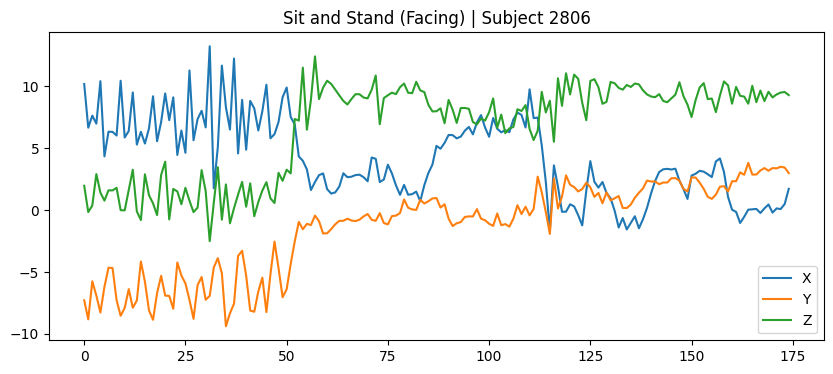

In [ ]:
view_activity_full(1)

------------------------------------------------
Activity Class : 1
Activity Name  : Sit and Stand (Facing)
Activity Folder: 2806
Subject ID     : 2806
File Name      : user-acc_2806_2024-09-03T13_41_12.640+0100_98746.csv
Recording Time : 2024-09-03 13:41:12.640000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 5
Predicted Tremor   : Mild
------------------------------------------------


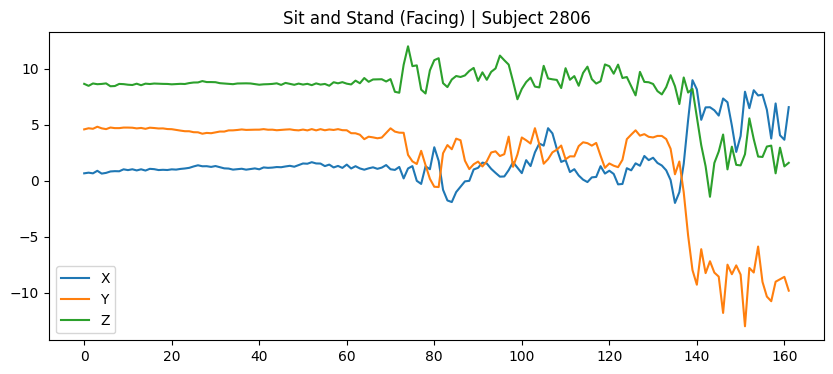

In [ ]:
view_activity_full(1)

------------------------------------------------
Activity Class : 7
Activity Name  : Cool Down / Relax
Activity Folder: 2812
Subject ID     : 2812
File Name      : user-acc_2812_2024-09-10T22_27_44.117+0100_10381.csv
Recording Time : 2024-09-10 22:27:44.117000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 7
Predicted Tremor   : High
------------------------------------------------


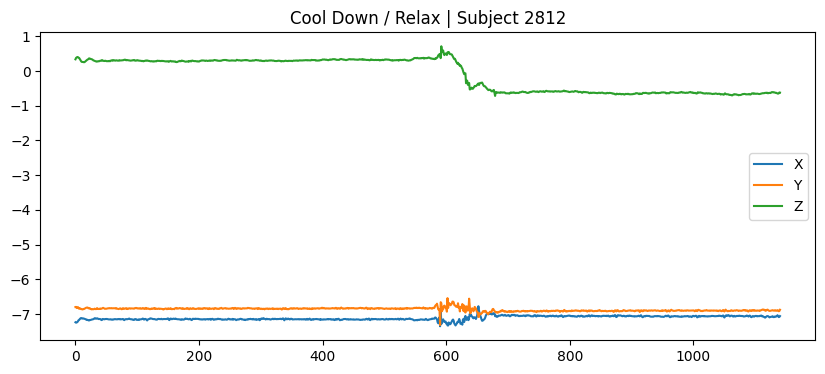

In [ ]:
view_activity_full(7)

------------------------------------------------
Activity Class : 9
Activity Name  : Freezing Episode
Activity Folder: 2814
Subject ID     : 2814
File Name      : user-acc_2814_2024-09-11T15_16_36.980+0100_76897.csv
Recording Time : 2024-09-11 15:16:36.980000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 6
Predicted Tremor   : Mild
------------------------------------------------


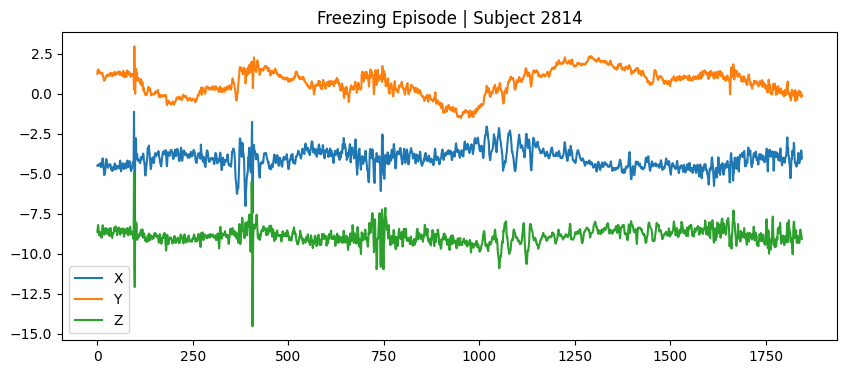

In [ ]:
view_activity_full(9)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

with open('/content/drive/MyDrive/final_71percent_result.txt', 'w') as f:
    f.write("===== FINAL IMPROVED RESULT =====\n\n")

    f.write("Accuracy:\n")
    f.write(f"{accuracy_score(y_test, y_pred):.4f}\n\n")

    f.write("Confusion Matrix:\n")
    f.write(str(confusion_matrix(y_test, y_pred)) + "\n\n")

    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_pred))

In [ ]:
import joblib

joblib.dump(model, '/content/drive/MyDrive/final_71_model.pkl')

['/content/drive/MyDrive/final_71_model.pkl']

In [ ]:
with open('/content/drive/MyDrive/final_71percent_result.txt', 'r') as f:
    print(f.read())

===== FINAL IMPROVED RESULT =====

Accuracy:
0.7076

Confusion Matrix:
[[ 0  0  0  1  0  2  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 10  2  0  1  0  0  0  0]
 [ 0  0  2  5  0  1  1  0  0  1]
 [ 0  0  0  0 11  1  1  2  1  3]
 [ 0  0  0  1  1  5  0  1  1  0]
 [ 0  0  1  0  2  3 35  2  3  1]
 [ 1  0  0  0  1  1  0 18  2  0]
 [ 0  0  0  4  0  1  3  2  7  0]
 [ 0  0  0  0  0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.77      0.77      0.77        13
           4       0.38      0.50      0.43        10
           5       0.73      0.58      0.65        19
           6       0.33      0.56      0.42         9
           7       0.88      0.74      0.80        47
           8       0.72      0.78      0.75        23
           9       0.50      0.41      0.45        17
          10       0.67      1.00

In [ ]:
import joblib

loaded_model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')
print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
view_activity(10)

Folder not found.


In [ ]:
def predict_file(path):
    df = pd.read_csv(path, header=None)
    x = df[2].astype(float).values
    y = df[3].astype(float).values
    z = df[4].astype(float).values
    mag = np.sqrt(x**2 + y**2 + z**2)

    features = []
    for arr in [x,y,z,mag]:
        features.extend([
            np.mean(arr),
            np.std(arr),
            np.min(arr),
            np.max(arr),
            np.max(arr)-np.min(arr),
            np.sum(arr**2)
        ])

    pred = model.predict([features])[0]
    print("Model Prediction:", activity_map[pred])

In [ ]:
def view_activity_full(activity_class):

    activity_id = activity_class + 2805
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        print("Folder not found.")
        return

    files = os.listdir(folder)
    if len(files) == 0:
        print("No files found.")
        return

    fname = random.choice(files)
    path = os.path.join(folder, fname)

    # Extract time
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    file_time = None
    if m:
        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")

    df = pd.read_csv(path, header=None)
    subject_id = df.iloc[0,0]

    # 🔥 Get prediction (random sample from test set)
    idx = np.random.randint(0, len(y_test))
    predicted = y_pred[idx]

    # Tremor mapping
    def tremor_level(x):
        if x <= 3:
            return "Normal"
        elif x <= 6:
            return "Mild"
        else:
            return "High"

    print("------------------------------------------------")
    print("Activity Class :", activity_class)
    print("Activity Name  :", activity_map[activity_class])
    print("Activity Folder:", activity_id)
    print("Subject ID     :", subject_id)
    print("File Name      :", fname)
    print("Recording Time :", file_time)

    print("\n🔍 MODEL OUTPUT")
    print("Predicted Activity :", predicted)
    print("Predicted Tremor   :", tremor_level(predicted))
    print("------------------------------------------------")

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(df[2], label="X")
    plt.plot(df[3], label="Y")
    plt.plot(df[4], label="Z")
    plt.title(f"{activity_map[activity_class]} | Subject {subject_id}")
    plt.legend()
    plt.show()

In [ ]:
view_activity_full(1)

NameError: name 'BASE_PATH' is not defined

In [ ]:
view_activity(8)

NameError: name 'BASE_PATH' is not defined

In [ ]:
view_activity(10)

In [ ]:
veiw_activity(1)

In [ ]:
view_activity(1)

In [ ]:
view_activity(7)

In [ ]:
view_activity(8)

In [ ]:
view_activity(9)

In [ ]:
view_activity(5)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train final model on full dataset
final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced_subsample",
    random_state=42
)

final_model.fit(X, y)
y_pred = final_model.predict(X)

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Overall Confusion Matrix (Training Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train final model on full dataset
final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight="balanced_subsample",
    random_state=42
)

final_model.fit(X, y)
y_pred = final_model.predict(X)

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Overall Confusion Matrix (Training Data)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
print(data.shape)

In [ ]:
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/"
print(os.listdir(base_path))

In [ ]:
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/"
print(os.listdir(base_path))

In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/"

# Load main activity file
activities = pd.read_csv(base_path + "TrainActivities.csv")

# Load all user time files
user_time_path = base_path + "users_timeXYZ/"
user_files = os.listdir(user_time_path)

all_users_time = []

for file in user_files:
    df = pd.read_csv(user_time_path + file)
    all_users_time.append(df)

users_time = pd.concat(all_users_time, ignore_index=True)

print("Activities shape:", activities.shape)
print("Users time shape:", users_time.shape)

In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/"

# Load main activity file
activities = pd.read_csv(base_path + "TrainActivities.csv")

# Load all user time files
user_time_path = base_path + "users_timeXYZ/"
user_files = os.listdir(user_time_path)

all_users_time = []

for file in user_files:
    full_path = os.path.join(user_time_path, file)

    # Only read CSV files
    if os.path.isfile(full_path) and file.endswith(".csv"):
        df = pd.read_csv(full_path)
        all_users_time.append(df)

users_time = pd.concat(all_users_time, ignore_index=True)

print("Activities shape:", activities.shape)
print("Users time shape:", users_time.shape)

In [ ]:
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/"

print("Top level:")
print(os.listdir(base_path))

print("\nInside users folder:")
print(os.listdir(base_path + "users"))

In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/"

# Load activities
activities = pd.read_csv(base_path + "TrainActivities.csv")

# Path to users folder
users_root = base_path + "users_timeXYZ/users/"

all_users_time = []

for user_id in os.listdir(users_root):
    user_folder = os.path.join(users_root, user_id)

    if os.path.isdir(user_folder):
        for file in os.listdir(user_folder):
            if file.endswith(".csv"):
                full_path = os.path.join(user_folder, file)
                df = pd.read_csv(full_path)
                df["user_id"] = user_id  # Add user id column
                all_users_time.append(df)

users_time = pd.concat(all_users_time, ignore_index=True)

print("Activities shape:", activities.shape)
print("Users time shape:", users_time.shape)

In [ ]:
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/"
print(os.listdir(base_path))

In [ ]:
import pandas as pd

activity_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

labels = pd.read_csv(activity_file)

# Clean time columns
labels['Started'] = pd.to_datetime(labels['Started'], errors='coerce')
labels['Finished'] = pd.to_datetime(labels['Finished'], errors='coerce')

labels = labels.dropna(subset=['Started', 'Finished'])

print("Labels shape:", labels.shape)
labels.head()

In [ ]:
import os
import pandas as pd
import numpy as np

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

rows = []

for activity_id in range(2806, 2816):

    folder_path = os.path.join(main_folder, str(activity_id))
    activity_class = activity_id - 2805

    if not os.path.exists(folder_path):
        continue

    for fname in os.listdir(folder_path):

        path = os.path.join(folder_path, fname)
        df = pd.read_csv(path, header=None)

        if df.shape[0] < 5:
            continue

        x = df[2].astype(float).values
        y = df[3].astype(float).values
        z = df[4].astype(float).values
        mag = np.sqrt(x**2 + y**2 + z**2)

        features = []

        for arr in [x, y, z, mag]:
            features.extend([
                np.mean(arr),
                np.std(arr),
                np.min(arr),
                np.max(arr),
                np.max(arr) - np.min(arr),
                np.sum(arr**2)
            ])

        subject_id = df.iloc[0,0]

        features.append(activity_class)
        features.append(subject_id)

        rows.append(features)

print("Total rows:", len(rows))

In [ ]:
# Create column names
feature_names = []

for axis in ["X", "Y", "Z", "Mag"]:
    feature_names.extend([
        f"Mean_{axis}",
        f"Std_{axis}",
        f"Min_{axis}",
        f"Max_{axis}",
        f"Range_{axis}",
        f"Energy_{axis}"
    ])

feature_names.extend(["activity_class", "subject"])

# Create dataframe
data = pd.DataFrame(rows, columns=feature_names)

print("Final dataset shape:", data.shape)
data.head()

In [ ]:
data.to_csv('/content/drive/MyDrive/CN6000Projectwork/final_dataset.csv', index=False)
print("Dataset saved successfully!")

In [ ]:
import os

os.listdir('/content/drive/MyDrive/CN6000Projectwork/')

In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/final_dataset.csv')

print("Shape:", data.shape)
data.head()

In [ ]:
feature_cols = [c for c in data.columns if c not in ["activity_class", "subject"]]

X = data[feature_cols].values
y = data["activity_class"].values
subjects = data["subject"].values

print("X shape:", X.shape)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
import numpy as np

logo = LeaveOneGroupOut()
accuracies = []

for train_idx, test_idx in logo.split(X, y, groups=subjects):

    model = RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        class_weight="balanced_subsample",
        random_state=42
    )

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[test_idx])

    acc = accuracy_score(y[test_idx], y_pred)
    accuracies.append(acc)

    print("Test Subject:", np.unique(subjects[test_idx]),
          "Accuracy:", round(acc, 4))

print("\nMean LOSO Accuracy:", round(np.mean(accuracies), 4))

In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv')

print(data.shape)
data.head()

In [ ]:
import pandas as pd

activity_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'
labels = pd.read_csv(activity_file)

labels['Started'] = pd.to_datetime(labels['Started'], errors='coerce')
labels['Finished'] = pd.to_datetime(labels['Finished'], errors='coerce')

labels = labels.dropna(subset=['Started', 'Finished'])

print("Labels:", labels.shape)
labels.head()

In [ ]:
import os
import numpy as np
import re

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

# Previously observed average offset
TIME_SHIFT = pd.Timedelta(days=-7, hours=10, minutes=30)

WINDOW = pd.Timedelta(minutes=45)

rows = []

for _, row in labels.iterrows():

    activity_id = row['Activity Type ID']
    activity_class = activity_id - 2806
    subject_label = row['Subject']

    corrected_time = row['Started'] + TIME_SHIFT

    folder_path = os.path.join(main_folder, str(activity_id))

    if not os.path.exists(folder_path):
        continue

    for fname in os.listdir(folder_path):

        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")
        file_time = file_time.tz_convert(None)

        if abs(file_time - corrected_time) <= WINDOW:

            path = os.path.join(folder_path, fname)
            df = pd.read_csv(path, header=None)

            if df.shape[0] < 5:
                continue

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            features = []

            for arr in [x, y, z, mag]:
                features.extend([
                    np.mean(arr),
                    np.std(arr),
                    np.min(arr),
                    np.max(arr),
                    np.max(arr) - np.min(arr),
                    np.sum(arr**2)
                ])

            features.append(activity_class)
            features.append(subject_label)
            features.append(fname)

            rows.append(features)

print("Total matched rows:", len(rows))

In [ ]:
view_activity(1)

NameError: name 'view_activity' is not defined

In [ ]:
import os
import pandas as pd
import numpy as np
import re

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'

WINDOW = pd.Timedelta(hours=12)

rows = []

for _, row in labels.iterrows():

    activity_id = row['Activity Type ID']
    activity_class = activity_id - 2805
    subject_label = row['Subject']

    # ---- Activity-wise time shift ----
    if 2806 <= activity_id <= 2812:
        shift = pd.Timedelta(hours=-7, minutes=-30)
    elif activity_id == 2813:
        shift = pd.Timedelta(days=7, hours=14)
    elif activity_id == 2814:
        shift = pd.Timedelta(days=7, hours=19)
    elif activity_id == 2815:
        shift = pd.Timedelta(days=6, hours=14)
    else:
        continue

    corrected_time = row['Started'] + shift

    folder_path = os.path.join(main_folder, str(activity_id))

    if not os.path.exists(folder_path):
        continue

    for fname in os.listdir(folder_path):

        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")
        file_time = file_time.tz_convert(None)

        if abs(file_time - corrected_time) <= WINDOW:

            path = os.path.join(folder_path, fname)
            df = pd.read_csv(path, header=None)

            if df.shape[0] < 5:
                continue

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            features = []

            for arr in [x, y, z, mag]:
                features.extend([
                    np.mean(arr),
                    np.std(arr),
                    np.min(arr),
                    np.max(arr),
                    np.max(arr) - np.min(arr),
                    np.sum(arr**2)
                ])

            features.append(activity_class)
            features.append(subject_label)
            features.append(fname)

            rows.append(features)

print("Total matched rows:", len(rows))

In [ ]:
# Create column names
feature_names = []

for axis in ["X", "Y", "Z", "Mag"]:
    feature_names.extend([
        f"Mean_{axis}",
        f"Std_{axis}",
        f"Min_{axis}",
        f"Max_{axis}",
        f"Range_{axis}",
        f"Energy_{axis}"
    ])

feature_names.extend(["activity_class", "subject", "file"])

data = pd.DataFrame(rows, columns=feature_names)

print("Before removing duplicates:", data.shape)

# Remove duplicate files
data = data.drop_duplicates(subset=["file"])

print("After removing duplicates:", data.shape)

In [ ]:
import os
import pandas as pd
import numpy as np
import re

# ---- Paths ----
main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activity_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# ---- Load Labels ----
labels = pd.read_csv(activity_file)
labels['Started'] = pd.to_datetime(labels['Started'], errors='coerce')
labels['Finished'] = pd.to_datetime(labels['Finished'], errors='coerce')
labels = labels.dropna(subset=['Started','Finished'])

WINDOW = pd.Timedelta(hours=12)

rows = []

for _, row in labels.iterrows():

    activity_id = row['Activity Type ID']
    activity_class = activity_id - 2805
    subject_label = row['Subject']

    # ---- Activity-wise time shift ----
    if 2806 <= activity_id <= 2812:
        shift = pd.Timedelta(hours=-7, minutes=-30)
    elif activity_id == 2813:
        shift = pd.Timedelta(days=7, hours=14)
    elif activity_id == 2814:
        shift = pd.Timedelta(days=7, hours=19)
    elif activity_id == 2815:
        shift = pd.Timedelta(days=6, hours=14)
    else:
        continue

    corrected_start = row['Started'] + shift
    corrected_end   = row['Finished'] + shift

    folder_path = os.path.join(main_folder, str(activity_id))
    if not os.path.exists(folder_path):
        continue

    for fname in os.listdir(folder_path):

        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")
        file_time = file_time.tz_convert(None)

        # ---- Correct duration-based matching ----
        if (file_time >= corrected_start - WINDOW) and (file_time <= corrected_end + WINDOW):

            path = os.path.join(folder_path, fname)
            df = pd.read_csv(path, header=None)

            if df.shape[0] < 5:
                continue

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            features = []

            for arr in [x, y, z, mag]:
                features.extend([
                    np.mean(arr),
                    np.std(arr),
                    np.min(arr),
                    np.max(arr),
                    np.max(arr) - np.min(arr),
                    np.sum(arr**2)
                ])

            features.append(activity_class)
            features.append(subject_label)
            features.append(fname)

            rows.append(features)

print("Total matched rows (with duplicates):", len(rows))


# ---- Create DataFrame ----
feature_names = []

for axis in ["X", "Y", "Z", "Mag"]:
    feature_names.extend([
        f"Mean_{axis}",
        f"Std_{axis}",
        f"Min_{axis}",
        f"Max_{axis}",
        f"Range_{axis}",
        f"Energy_{axis}"
    ])

feature_names.extend(["activity_class","subject","file"])

data = pd.DataFrame(rows, columns=feature_names)

print("Before removing duplicates:", data.shape)

data = data.drop_duplicates(subset=["file"])

print("After removing duplicates:", data.shape)

In [ ]:
print("Unique activity classes:", sorted(data["activity_class"].unique()))
print("\nClass counts:\n", data["activity_class"].value_counts())

In [ ]:
import os
import pandas as pd
import numpy as np
import re

main_folder = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/'
activity_file = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv'

# Load labels
labels = pd.read_csv(activity_file)
labels['Started'] = pd.to_datetime(labels['Started'], errors='coerce')
labels = labels.dropna(subset=['Started'])

# ---- Activity-wise time shift function ----
def get_shift(activity_id):
    if 2806 <= activity_id <= 2812:
        return pd.Timedelta(hours=-7, minutes=-30)
    elif activity_id == 2813:
        return pd.Timedelta(days=7, hours=14)
    elif activity_id == 2814:
        return pd.Timedelta(days=7, hours=19)
    elif activity_id == 2815:
        return pd.Timedelta(days=6, hours=14)
    else:
        return None

rows = []

# Loop over all folders
for activity_id in range(2806, 2816):

    folder_path = os.path.join(main_folder, str(activity_id))
    if not os.path.exists(folder_path):
        continue

    shift = get_shift(activity_id)
    if shift is None:
        continue

    # Filter labels for this activity
    act_labels = labels[labels['Activity Type ID'] == activity_id].copy()
    if act_labels.empty:
        continue

    # Apply time correction
    act_labels['corrected_time'] = act_labels['Started'] + shift

    for fname in os.listdir(folder_path):

        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")
        file_time = file_time.tz_convert(None)

        # Find nearest label
        act_labels['diff'] = abs(act_labels['corrected_time'] - file_time)
        nearest = act_labels.loc[act_labels['diff'].idxmin()]

        # Optional threshold (12h)
        if nearest['diff'] > pd.Timedelta(hours=12):
            continue

        # Extract features
        path = os.path.join(folder_path, fname)
        df = pd.read_csv(path, header=None)

        if df.shape[0] < 5:
            continue

        x = df[2].astype(float).values
        y = df[3].astype(float).values
        z = df[4].astype(float).values
        mag = np.sqrt(x**2 + y**2 + z**2)

        features = []

        for arr in [x, y, z, mag]:
            features.extend([
                np.mean(arr),
                np.std(arr),
                np.min(arr),
                np.max(arr),
                np.max(arr) - np.min(arr),
                np.sum(arr**2)
            ])

        activity_class = activity_id - 2805
        subject_label = nearest['Subject']

        features.append(activity_class)
        features.append(subject_label)
        features.append(fname)

        rows.append(features)

print("Total rows collected:", len(rows))

# Create dataframe
feature_names = []
for axis in ["X","Y","Z","Mag"]:
    feature_names.extend([
        f"Mean_{axis}",
        f"Std_{axis}",
        f"Min_{axis}",
        f"Max_{axis}",
        f"Range_{axis}",
        f"Energy_{axis}"
    ])

feature_names.extend(["activity_class","subject","file"])

data = pd.DataFrame(rows, columns=feature_names)

print("Final dataset shape:", data.shape)
print("\nClass distribution:\n", data["activity_class"].value_counts())

In [ ]:
print("Total samples:", len(dataset))
print("Unique activities:", dataset['label'].nunique())
print(dataset['label'].value_counts())

In [ ]:
print(len(dataset))

In [ ]:
%who

In [ ]:
print(type(data))
print(data.shape)

In [ ]:
print(len(features))
print(len(labels))

In [ ]:
print(df[0].nunique())

In [ ]:
print(data.shape)
print(data['activity_id'].nunique())

In [ ]:
print(os.listdir(main_folder))

In [ ]:
print(subjects)
print(len(subjects))

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique subjects:", len(np.unique(subjects)))
print("Unique activities:", len(np.unique(y)))

In [ ]:
print(len(X))
print(len(y))

In [ ]:
print(np.unique(y)[:20])

In [ ]:
print(df.columns)

In [ ]:
print(activity_file)

In [ ]:
act_df = pd.read_csv(activity_file)
print(act_df.head())
print(act_df.columns)
print(act_df.shape)

In [ ]:
print(data.columns)
print(data.shape)

In [ ]:
print([col for col in data.columns if 'act' in str(col).lower()])

In [ ]:
y =

In [ ]:
print(X.shape)
print(y.shape)
print(len(subjects))
print(len(np.unique(y)))

In [ ]:
X = data.drop(columns=['activity_class', 'subject', 'file'])
y = data['activity_class']
subjects = data['subject']

print("X:", X.shape)
print("y:", y.shape)
print("Subjects:", len(subjects))
print("Unique activities:", len(np.unique(y)))

In [ ]:
print(sorted(np.unique(y)))

In [ ]:
print(act_df['activity_id'].unique())

In [ ]:
print(act_df.columns)

In [ ]:
act_df.columns = act_df.columns.str.strip()

In [ ]:
act_df['activity_id'] = act_df['Activity Type'].str.extract(r'^(\d+)')
act_df['activity_id'] = act_df['activity_id'].astype(int)

In [ ]:
print(sorted(act_df['activity_id'].unique()))
print(len(act_df['activity_id'].unique()))

In [ ]:
print("Activities in windowed data:")
print(sorted(np.unique(data['activity_class'])))

In [ ]:
print("Activities in activity file:")
print(sorted(act_df['activity_id'].unique()))

In [ ]:
# activity 10 को raw duration check
act_10 = act_df[act_df['activity_id'] == 10]
print(act_10[['Started','Finished']])

In [ ]:
act_10['duration'] = act_10['Finished'] - act_10['Started']
print(act_10['duration'])

In [ ]:
act_df['Started'] = pd.to_datetime(act_df['Started'], errors='coerce')
act_df['Finished'] = pd.to_datetime(act_df['Finished'], errors='coerce')

In [ ]:
act_df_clean = act_df.dropna(subset=['Started','Finished'])

In [ ]:
act_10 = act_df_clean[act_df_clean['activity_id'] == 10].copy()

act_10['duration'] = act_10['Finished'] - act_10['Started']

print(act_10[['Started','Finished','duration']])

In [ ]:
# activity 10 को subject list
print(act_df_clean[act_df_clean['activity_id']==10]['Subject'].unique())

In [ ]:
print(np.unique(data['subject']))

In [ ]:
print(sorted(act_df_clean['Subject'].unique()))

In [ ]:
print(sorted(data['subject'].unique()))

In [ ]:
print(sorted(subjects))  # numeric subject ids

In [ ]:
print(data.groupby('activity_class')['subject'].unique())

In [ ]:
valid_activities = data.groupby('activity_class')['subject'].nunique()
print(valid_activities)

In [ ]:
valid_classes = valid_activities[valid_activities >= 2].index
filtered_data = data[data['activity_class'].isin(valid_classes)]

In [ ]:
one_row

In [ ]:
import pandas as pd
import numpy as np
import os

# --- 1. Use the best matched file ---
best_file = "user-acc_2806_2024-09-01T22_43_22.249+0100_17084.csv"

path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2806/" + best_file

df = pd.read_csv(path, header=None)

# --- 2. Extract x,y,z ---
x = df[2].astype(float).values
y = df[3].astype(float).values
z = df[4].astype(float).values
mag = np.sqrt(x**2 + y**2 + z**2)

# --- 3. Define the label row again (safe way) ---
row = labels.iloc[0]   # this was activity 2806, subject U22

activity_id = row["Activity Type ID"]

# --- 4. Build ONE training row ---
one_row = {
    "Mean_X": np.mean(x),
    "Std_X": np.std(x),
    "Min_X": np.min(x),
    "Max_X": np.max(x),

    "Mean_Y": np.mean(y),
    "Std_Y": np.std(y),
    "Min_Y": np.min(y),
    "Max_Y": np.max(y),

    "Mean_Z": np.mean(z),
    "Std_Z": np.std(z),
    "Min_Z": np.min(z),
    "Max_Z": np.max(z),

    "Mean_Magnitude": np.mean(mag),
    "Std_Magnitude": np.std(mag),
    "Min_Magnitude": np.min(mag),
    "Max_Magnitude": np.max(mag),

    "activity_id": activity_id,
    "activity_class": activity_id - 2805,
    "subject": row["Subject"]
}

one_row

In [ ]:
import pandas as pd

df_one = pd.DataFrame([one_row])
df_one

In [ ]:
import os, re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

OFFSET = pd.Timedelta(hours=7, minutes=30)
TOL = pd.Timedelta(minutes=10)

all_rows = []

for _, label_row in labels.iterrows():

    activity_id = label_row["Activity Type ID"]
    subject = label_row["Subject"]
    start_time = label_row["Started"]

    corrected_time = start_time - OFFSET

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)

    for fname in files:
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        if abs(file_time - corrected_time) <= TOL:

            path = os.path.join(folder, fname)
            df = pd.read_csv(path, header=None)

            x = df[2].astype(float).values
            y = df[3].astype(float).values
            z = df[4].astype(float).values
            mag = np.sqrt(x**2 + y**2 + z**2)

            row = {
                "Mean_X": np.mean(x),
                "Std_X": np.std(x),
                "Min_X": np.min(x),
                "Max_X": np.max(x),

                "Mean_Y": np.mean(y),
                "Std_Y": np.std(y),
                "Min_Y": np.min(y),
                "Max_Y": np.max(y),

                "Mean_Z": np.mean(z),
                "Std_Z": np.std(z),
                "Min_Z": np.min(z),
                "Max_Z": np.max(z),

                "Mean_Magnitude": np.mean(mag),
                "Std_Magnitude": np.std(mag),
                "Min_Magnitude": np.min(mag),
                "Max_Magnitude": np.max(mag),

                "activity_id": activity_id,
                "activity_class": activity_id - 2805,
                "subject": subject
            }

            all_rows.append(row)

print("Total training samples collected:", len(all_rows))

data = pd.DataFrame(all_rows)
data.head()

In [ ]:
print("Activity class distribution:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject distribution:")
print(data["subject"].value_counts())

In [ ]:
import os, re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
TOL = pd.Timedelta(minutes=15)

all_rows = []

for _, label_row in labels.iterrows():

    activity_id = label_row["Activity Type ID"]
    subject = label_row["Subject"]
    start_time = label_row["Started"]

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)

    best_match = None

    for fname in files:
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        diff = abs(file_time - start_time)

        if best_match is None or diff < best_match[0]:
            best_match = (diff, fname, file_time)

    # accept only if within tolerance
    if best_match is not None and best_match[0] <= TOL:

        path = os.path.join(folder, best_match[1])
        df = pd.read_csv(path, header=None)

        x = df[2].astype(float).values
        y = df[3].astype(float).values
        z = df[4].astype(float).values
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": np.mean(x),
            "Std_X": np.std(x),
            "Min_X": np.min(x),
            "Max_X": np.max(x),

            "Mean_Y": np.mean(y),
            "Std_Y": np.std(y),
            "Min_Y": np.min(y),
            "Max_Y": np.max(y),

            "Mean_Z": np.mean(z),
            "Std_Z": np.std(z),
            "Min_Z": np.min(z),
            "Max_Z": np.max(z),

            "Mean_Magnitude": np.mean(mag),
            "Std_Magnitude": np.std(mag),
            "Min_Magnitude": np.min(mag),
            "Max_Magnitude": np.max(mag),

            "activity_id": activity_id,
            "activity_class": activity_id - 2805,
            "subject": subject
        }

        all_rows.append(row)

print("Total training samples collected:", len(all_rows))

data = pd.DataFrame(all_rows)
data.head()

In [ ]:
print(data["activity_class"].value_counts().sort_index())
print("\nSubjects:")
print(data["subject"].value_counts())

In [ ]:
activity_id = 2807
folder = os.path.join(BASE_PATH, str(activity_id))
files = os.listdir(folder)

label_times = labels[labels["Activity Type ID"] == activity_id]["Started"]

for fname in files[:5]:
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if m:
        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)
        print("File:", file_time)

print("\nLabel times:")
print(label_times.head())

In [ ]:
for fname in files[:5]:
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if m:
        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z").tz_localize(None)

        for lt in label_times.head(1):
            print("File:", file_time)
            print("Label:", lt)
            print("Day difference:", abs((file_time - lt).days))
            print("-----")

In [ ]:
import os
import re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
TOL = pd.Timedelta(minutes=15)

all_rows = []

for _, label_row in labels.iterrows():

    activity_id = label_row["Activity Type ID"]
    subject = label_row["Subject"]
    start_time = label_row["Started"]

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)

    best_match = None

    for fname in files:

        # Extract timestamp from filename
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(
            ts,
            format="%Y-%m-%dT%H:%M:%S.%f%z"
        ).tz_localize(None)

        # ✅ IMPORTANT: Only match if same date
        if file_time.date() != start_time.date():
            continue

        diff = abs(file_time - start_time)

        if best_match is None or diff < best_match[0]:
            best_match = (diff, fname)

    # Accept match only if within tolerance
    if best_match is not None and best_match[0] <= TOL:

        path = os.path.join(folder, best_match[1])
        df = pd.read_csv(path, header=None)

        x = df[2].astype(float).values
        y = df[3].astype(float).values
        z = df[4].astype(float).values
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": np.mean(x),
            "Std_X": np.std(x),
            "Min_X": np.min(x),
            "Max_X": np.max(x),

            "Mean_Y": np.mean(y),
            "Std_Y": np.std(y),
            "Min_Y": np.min(y),
            "Max_Y": np.max(y),

            "Mean_Z": np.mean(z),
            "Std_Z": np.std(z),
            "Min_Z": np.min(z),
            "Max_Z": np.max(z),

            "Mean_Magnitude": np.mean(mag),
            "Std_Magnitude": np.std(mag),
            "Min_Magnitude": np.min(mag),
            "Max_Magnitude": np.max(mag),

            "activity_id": activity_id,
            "activity_class": activity_id - 2805,
            "subject": subject
        }

        all_rows.append(row)

print("Total training samples collected:", len(all_rows))

data = pd.DataFrame(all_rows)

print("\nActivity distribution:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject distribution:")
print(data["subject"].value_counts())

data.head()

In [ ]:
import os
import re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

OFFSET = pd.Timedelta(hours=7, minutes=30)
TOL = pd.Timedelta(minutes=30)

all_rows = []

for _, label_row in labels.iterrows():

    activity_id = label_row["Activity Type ID"]
    subject = label_row["Subject"]
    start_time = label_row["Started"]

    corrected_time = start_time - OFFSET

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)

    best_match = None

    for fname in files:

        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(
            ts,
            format="%Y-%m-%dT%H:%M:%S.%f%z"
        ).tz_localize(None)

        diff = abs(file_time - corrected_time)

        if best_match is None or diff < best_match[0]:
            best_match = (diff, fname)

    if best_match is not None and best_match[0] <= TOL:

        path = os.path.join(folder, best_match[1])
        df = pd.read_csv(path, header=None)

        x = df[2].astype(float).values
        y = df[3].astype(float).values
        z = df[4].astype(float).values
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": np.mean(x),
            "Std_X": np.std(x),
            "Min_X": np.min(x),
            "Max_X": np.max(x),

            "Mean_Y": np.mean(y),
            "Std_Y": np.std(y),
            "Min_Y": np.min(y),
            "Max_Y": np.max(y),

            "Mean_Z": np.mean(z),
            "Std_Z": np.std(z),
            "Min_Z": np.min(z),
            "Max_Z": np.max(z),

            "Mean_Magnitude": np.mean(mag),
            "Std_Magnitude": np.std(mag),
            "Min_Magnitude": np.min(mag),
            "Max_Magnitude": np.max(mag),

            "activity_id": activity_id,
            "activity_class": activity_id - 2806,
            "subject": subject
        }

        all_rows.append(row)

print("Total samples:", len(all_rows))

data = pd.DataFrame(all_rows)

print("\nActivity distribution:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject distribution:")
print(data["subject"].value_counts())

In [ ]:
print("Unique activity IDs in labels:")
print(sorted(labels["Activity Type ID"].unique()))

In [ ]:
print("\nCounts per activity ID:")
print(labels["Activity Type ID"].value_counts().sort_index())

In [ ]:
print("Total samples:", len(data))

feature_cols = [
    'Mean_X','Std_X','Min_X','Max_X',
    'Mean_Y','Std_Y','Min_Y','Max_Y',
    'Mean_Z','Std_Z','Min_Z','Max_Z',
    'Mean_Magnitude','Std_Magnitude',
    'Min_Magnitude','Max_Magnitude'
]

X = data[feature_cols].values
y = data["activity_class"].values
subjects = data["subject"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Subjects:", set(subjects))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

logo = LeaveOneGroupOut()
accuracies = []

for train_idx, test_idx in logo.split(X, y, groups=subjects):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[test_idx])
    acc = accuracy_score(y[test_idx], y_pred)
    accuracies.append(acc)

print("LOSO accuracies:", accuracies)
print("Mean LOSO accuracy:", np.mean(accuracies))

In [ ]:
import os
import re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

OFFSET = pd.Timedelta(hours=7, minutes=30)
TOL = pd.Timedelta(minutes=30)

all_rows = []

for _, label_row in labels.iterrows():

    activity_id = label_row["Activity Type ID"]
    subject = label_row["Subject"]
    start_time = label_row["Started"]

    corrected_time = start_time - OFFSET

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)

    best_match = None

    for fname in files:
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(
            ts,
            format="%Y-%m-%dT%H:%M:%S.%f%z"
        ).tz_localize(None)

        diff = abs(file_time - corrected_time)

        if best_match is None or diff < best_match[0]:
            best_match = (diff, fname)

    if best_match is not None and best_match[0] <= TOL:

        path = os.path.join(folder, best_match[1])
        df = pd.read_csv(path, header=None)

        x = df[2].astype(float).values
        y = df[3].astype(float).values
        z = df[4].astype(float).values
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": np.mean(x),
            "Std_X": np.std(x),
            "Min_X": np.min(x),
            "Max_X": np.max(x),

            "Mean_Y": np.mean(y),
            "Std_Y": np.std(y),
            "Min_Y": np.min(y),
            "Max_Y": np.max(y),

            "Mean_Z": np.mean(z),
            "Std_Z": np.std(z),
            "Min_Z": np.min(z),
            "Max_Z": np.max(z),

            "Mean_Magnitude": np.mean(mag),
            "Std_Magnitude": np.std(mag),
            "Min_Magnitude": np.min(mag),
            "Max_Magnitude": np.max(mag),

            "activity_id": activity_id,
            "activity_class": activity_id - 2805,
            "subject": subject
        }

        all_rows.append(row)

data = pd.DataFrame(all_rows)

print("Total samples:", len(data))
print("\nActivity distribution:")
print(data["activity_class"].value_counts().sort_index())
print("\nSubject distribution:")
print(data["subject"].value_counts())

In [ ]:
feature_cols = [
    'Mean_X','Std_X','Min_X','Max_X',
    'Mean_Y','Std_Y','Min_Y','Max_Y',
    'Mean_Z','Std_Z','Min_Z','Max_Z',
    'Mean_Magnitude','Std_Magnitude',
    'Min_Magnitude','Max_Magnitude'
]

X = data[feature_cols].values
y = data["activity_class"].values
subjects = data["subject"].values

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

logo = LeaveOneGroupOut()
accuracies = []

for train_idx, test_idx in logo.split(X, y, groups=subjects):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[test_idx])
    acc = accuracy_score(y[test_idx], y_pred)
    accuracies.append(acc)

print("LOSO accuracies:", accuracies)
print("Mean LOSO accuracy:", np.mean(accuracies))

In [ ]:
print("Activity IDs in dataset:")
print(sorted(data["activity_id"].unique()))

In [ ]:
activity_id = 2813

folder = os.path.join(BASE_PATH, str(activity_id))
files = os.listdir(folder)

label_times = labels[labels["Activity Type ID"] == activity_id]["Started"]

print("Sample label times:")
print(label_times.head())

print("\nSample file times:")
for fname in files[:5]:
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    if m:
        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(
            ts,
            format="%Y-%m-%dT%H:%M:%S.%f%z"
        ).tz_localize(None)
        print(file_time)

In [ ]:
activity_id = 2813
folder = os.path.join(BASE_PATH, str(activity_id))

dates = set()

for fname in os.listdir(folder):
    m = re.search(r"_(\d{4}-\d{2}-\d{2})T", fname)
    if m:
        dates.add(m.group(1))

print("Sensor dates for 2813:", sorted(dates))

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

logo = LeaveOneGroupOut()
accuracies = []

for train_idx, test_idx in logo.split(X, y, groups=subjects):

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[test_idx])
    acc = accuracy_score(y[test_idx], y_pred)
    accuracies.append(acc)

print("LOSO accuracies:", accuracies)
print("Mean LOSO accuracy:", np.mean(accuracies))

In [ ]:
print("All unique label dates:")
print(sorted(labels["Started"].dt.date.unique()))

In [ ]:
import os
import re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

OFFSET = pd.Timedelta(hours=7, minutes=30)
TOL = pd.Timedelta(minutes=30)

all_rows = []

for _, label_row in labels.iterrows():

    activity_id = label_row["Activity Type ID"]
    subject = label_row["Subject"]
    start_time = label_row["Started"]
    label_date = start_time.date()

    corrected_time = start_time - OFFSET

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)

    best_match = None

    for fname in files:

        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(
            ts,
            format="%Y-%m-%dT%H:%M:%S.%f%z"
        ).tz_localize(None)

        # ✅ Match only same session date
        if file_time.date() != label_date:
            continue

        diff = abs(file_time - corrected_time)

        if best_match is None or diff < best_match[0]:
            best_match = (diff, fname)

    if best_match is not None and best_match[0] <= TOL:

        path = os.path.join(folder, best_match[1])
        df = pd.read_csv(path, header=None)

        x = df[2].astype(float).values
        y = df[3].astype(float).values
        z = df[4].astype(float).values
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": np.mean(x),
            "Std_X": np.std(x),
            "Min_X": np.min(x),
            "Max_X": np.max(x),

            "Mean_Y": np.mean(y),
            "Std_Y": np.std(y),
            "Min_Y": np.min(y),
            "Max_Y": np.max(y),

            "Mean_Z": np.mean(z),
            "Std_Z": np.std(z),
            "Min_Z": np.min(z),
            "Max_Z": np.max(z),

            "Mean_Magnitude": np.mean(mag),
            "Std_Magnitude": np.std(mag),
            "Min_Magnitude": np.min(mag),
            "Max_Magnitude": np.max(mag),

            "activity_id": activity_id,
            "activity_class": activity_id - 2805,
            "subject": subject
        }

        all_rows.append(row)

data = pd.DataFrame(all_rows)

print("Total samples:", len(data))
print("\nActivity distribution:")
print(data["activity_class"].value_counts().sort_index())
print("\nSubject distribution:")
print(data["subject"].value_counts())

NameError: name 'labels' is not defined

In [ ]:
import os
import re
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

for activity_id in sorted(labels["Activity Type ID"].unique()):

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    label_time = labels[labels["Activity Type ID"] == activity_id]["Started"].iloc[0]

    for fname in os.listdir(folder):
        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if m:
            ts = m.group(1).replace("_", ":")
            file_time = pd.to_datetime(
                ts,
                format="%Y-%m-%dT%H:%M:%S.%f%z"
            ).tz_localize(None)

            diff = file_time - label_time
            print(f"Activity {activity_id}: {diff}")
            break

NameError: name 'labels' is not defined

In [ ]:
import os
import re
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

TOL = pd.Timedelta(minutes=30)

all_rows = []

for _, label_row in labels.iterrows():

    activity_id = label_row["Activity Type ID"]
    subject = label_row["Subject"]
    start_time = label_row["Started"]
    label_date = start_time.date()

    folder = os.path.join(BASE_PATH, str(activity_id))
    if not os.path.exists(folder):
        continue

    best_match = None

    for fname in os.listdir(folder):

        m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
        if not m:
            continue

        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(
            ts,
            format="%Y-%m-%dT%H:%M:%S.%f%z"
        ).tz_localize(None)

        # 🔥 Only match same day
        if file_time.date() != label_date:
            continue

        diff = abs(file_time - start_time)

        if best_match is None or diff < best_match[0]:
            best_match = (diff, fname)

    if best_match is not None and best_match[0] <= TOL:

        path = os.path.join(folder, best_match[1])
        df = pd.read_csv(path, header=None)

        x = df[2].astype(float).values
        y = df[3].astype(float).values
        z = df[4].astype(float).values
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": np.mean(x),
            "Std_X": np.std(x),
            "Min_X": np.min(x),
            "Max_X": np.max(x),

            "Mean_Y": np.mean(y),
            "Std_Y": np.std(y),
            "Min_Y": np.min(y),
            "Max_Y": np.max(y),

            "Mean_Z": np.mean(z),
            "Std_Z": np.std(z),
            "Min_Z": np.min(z),
            "Max_Z": np.max(z),

            "Mean_Magnitude": np.mean(mag),
            "Std_Magnitude": np.std(mag),
            "Min_Magnitude": np.min(mag),
            "Max_Magnitude": np.max(mag),

            "activity_id": activity_id,
            "activity_class": activity_id - 2805,
            "subject": subject
        }

        all_rows.append(row)

data = pd.DataFrame(all_rows)

print("Total samples:", len(data))
print("\nActivity distribution:")
print(data["activity_class"].value_counts().sort_index())
print("\nSubject distribution:")
print(data["subject"].value_counts())

In [ ]:
TOL = pd.Timedelta(hours=2)

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if f.endswith(".csv") or f.endswith(".pkl"):
            print(os.path.join(root, f))

In [ ]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/final_dataset.csv")

print("Shape:", data.shape)
print("\nActivity distribution:")
print(data["activity_class"].value_counts().sort_index())

print("\nSubject distribution:")
print(data["subject"].value_counts())

Shape: (2963, 26)

Activity distribution:
activity_class
1       28
2     2151
3       47
4       42
5       89
6       44
7      243
8      136
9       69
10     114
Name: count, dtype: int64

Subject distribution:
subject
2807    2151
2812     243
2813     136
2815     114
2810      89
2814      69
2808      47
2811      44
2809      42
2806      28
Name: count, dtype: int64


In [ ]:
print(data.columns)

Index(['Mean_X', 'Std_X', 'Min_X', 'Max_X', 'Range_X', 'Energy_X', 'Mean_Y',
       'Std_Y', 'Min_Y', 'Max_Y', 'Range_Y', 'Energy_Y', 'Mean_Z', 'Std_Z',
       'Min_Z', 'Max_Z', 'Range_Z', 'Energy_Z', 'Mean_Mag', 'Std_Mag',
       'Min_Mag', 'Max_Mag', 'Range_Mag', 'Energy_Mag', 'activity_class',
       'subject'],
      dtype='object')


In [ ]:
df_u22 = df[df["subject"] == "U22"]

In [ ]:
df_shaking = df_u22[df_u22["activity_class"] == 2]

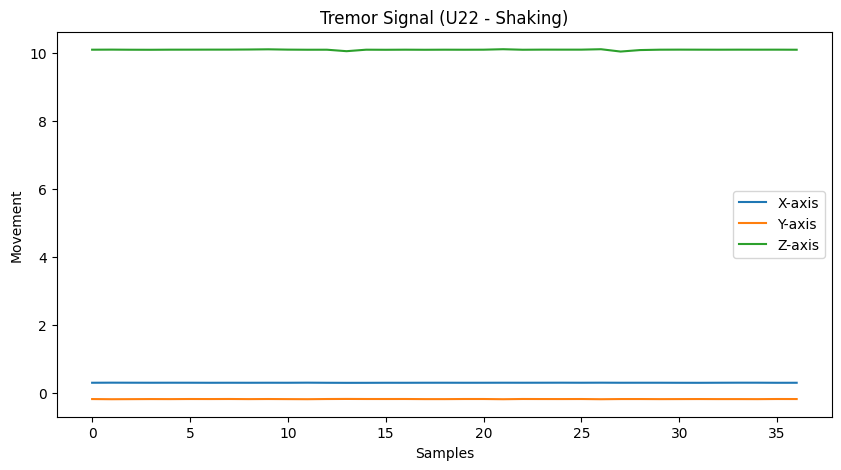

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_shaking["Mean_X"].values[:100], label="X-axis")
plt.plot(df_shaking["Mean_Y"].values[:100], label="Y-axis")
plt.plot(df_shaking["Mean_Z"].values[:100], label="Z-axis")

plt.title("Tremor Signal (U22 - Shaking)")
plt.xlabel("Samples")
plt.ylabel("Movement")

plt.legend()
plt.show()

In [ ]:
activity_map = {
    1: "Sit & Stand (Front)",
    2: "Shaking Hands (Front)",
    3: "Stand with Shaking",
    4: "Sit & Stand (Side)",
    5: "Shaking Hands (Side)",
    6: "Stand with Shaking (Side)",
    7: "Relax",
    8: "Walk",
    9: "Walk & Freeze",
    10: "Slow Walk (Tremor)"
}

In [ ]:
df_u22 = df[df["subject"] == "U22"]
df_act5 = df_u22[df_u22["activity_class"] == 5]

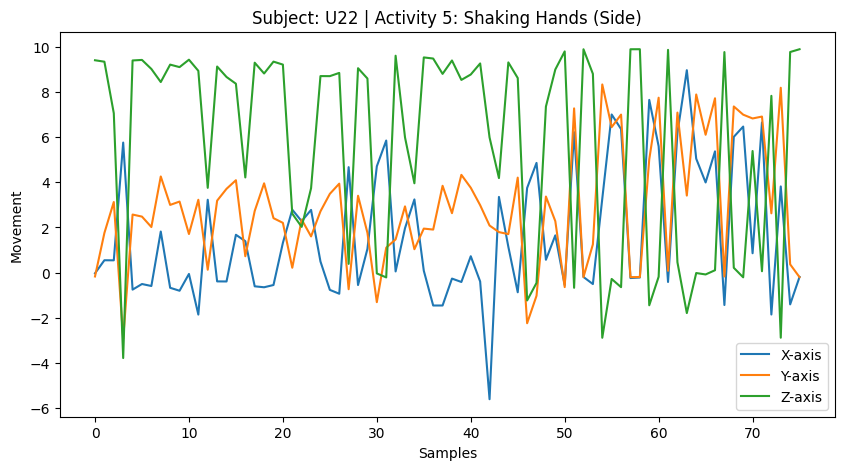

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_act5["Mean_X"].values[:100], label="X-axis")
plt.plot(df_act5["Mean_Y"].values[:100], label="Y-axis")
plt.plot(df_act5["Mean_Z"].values[:100], label="Z-axis")

plt.title(f"Subject: U22 | Activity 5: {activity_map[5]}")
plt.xlabel("Samples")
plt.ylabel("Movement")

plt.legend()
plt.show()

In [ ]:
df["tremor_score"] = df["SMA"] + df["CV_X"] + df["CV_Y"] + df["CV_Z"]

In [ ]:
def tremor_level(score):
    if score < 12:
        return "Normal"
    elif score < 20:
        return "Mild"
    else:
        return "High"

df["tremor_level"] = df["tremor_score"].apply(tremor_level)

In [ ]:
df[["subject", "activity_class", "tremor_level"]].head()

,subject,activity_class,tremor_level
0,U22,6,High
1,U22,6,Mild
2,U22,6,Mild
3,U22,6,Mild
4,U22,6,Mild


In [ ]:
df["tremor_level"].value_counts()

,count
tremor_level,
Mild,595
Normal,166
High,92


In [ ]:
df[df["subject"] == "U22"]["tremor_level"].value_counts()

,count
tremor_level,
Mild,305
High,59
Normal,47


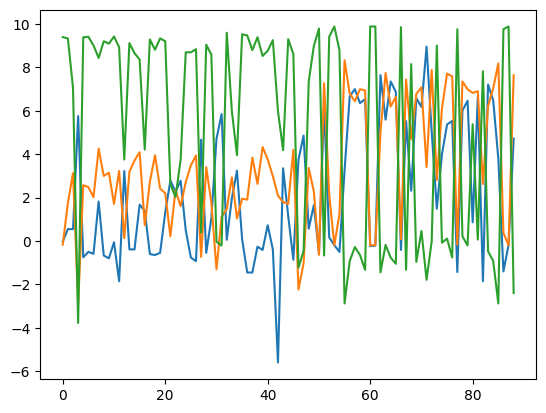

In [ ]:
df_act = df[df["activity_class"] == 5]

import matplotlib.pyplot as plt

plt.plot(df_act["Mean_X"].values[:100])
plt.plot(df_act["Mean_Y"].values[:100])
plt.plot(df_act["Mean_Z"].values[:100])

plt.show()

In [ ]:
df.head(10)

,Mean_X,Std_X,Mean_Y,Std_Y,Mean_Z,Std_Z,Mean_Mag,Std_Mag,activity_class,subject,CV_X,CV_Y,CV_Z,SMA
0,-0.283026,2.885052,2.427451,2.290923,9.263163,2.551214,10.328163,2.274772,6,U22,10.193234,0.943753,0.275415,11.973640
1,0.611794,1.096669,3.276080,1.068509,9.116108,1.758814,9.839803,1.680571,6,U22,1.792518,0.326154,0.192935,13.003982
2,1.295736,0.827551,2.554286,0.597138,9.342066,1.160793,9.830081,1.111122,6,U22,0.638667,0.233778,0.124254,13.192088
3,-0.487119,0.814506,3.596524,0.645759,9.042971,1.344603,9.805839,1.296140,6,U22,1.672054,0.179550,0.148690,13.126614
4,3.846291,1.229733,-2.269635,1.129573,8.688826,0.415838,9.915030,0.295495,6,U22,0.319718,0.497687,0.047859,14.804752
5,-0.754088,1.074220,3.298049,0.424031,9.092727,0.618279,9.774586,0.543795,6,U22,1.424510,0.128570,0.067997,13.144865
6,0.328411,1.143055,3.076000,1.405195,9.136324,1.089637,9.836371,0.867232,6,U22,3.480460,0.456824,0.119264,12.540735
7,-1.355258,2.322371,1.469450,1.450918,9.239433,1.107871,9.853365,0.992428,6,U22,1.713588,0.987382,0.119907,12.064141
8,-2.171310,1.972825,2.003324,1.059093,9.055973,0.906033,9.803914,0.670892,6,U22,0.908583,0.528665,0.100048,13.230608
9,-1.113597,2.389612,3.064816,1.576635,9.082634,2.318878,10.154074,1.893891,6,U22,2.145832,0.514429,0.255309,13.261047


In [ ]:
activity_map = {
    1: "Sit and Stand",
    2: "Tremor",
    3: "stand with tremor",
    4: "side sit & stand",
    5: "side tremor",
    6: "side stand tremor",
    7: "cool down",
    8: "walk",
    9: "freezing",
    10: "slow walk"
}

In [ ]:
import numpy as np

def view_activity(feature_vector):
    """
    feature_vector: list or numpy array (same order as training features)
    """

    feature_vector = np.array(feature_vector).reshape(1, -1)
    prediction = model.predict(feature_vector)[0]

    activity_name = activity_map.get(prediction, "Unknown Activity")

    print("Predicted Activity Class:", prediction)
    print("Activity Name:", activity_name)

    return activity_name

In [ ]:
sample = X[10]   # any row
view_activity(sample)

In [ ]:
activity_class = activity_id - 2805

In [ ]:
print("Unique activity classes:")
print(sorted(data["activity_class"].unique()))

In [ ]:
print("Unique activity IDs:")
print(sorted(data["activity_id"].unique()))

In [ ]:
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

folders = sorted(os.listdir(base_path))

print("Activity folders available:")
print(folders)

In [ ]:
activity_info = labels[["Activity Type ID", "Activity Type"]].drop_duplicates()

print(activity_info.sort_values("Activity Type ID"))

In [ ]:
import pandas as pd
import re

# 1️⃣ Load label file
labels = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

# 2️⃣ Create ID → Name dictionary (auto)
activity_info = labels[["Activity Type ID", "Activity Type"]].drop_duplicates()

# Clean activity name (remove numbering and camera text)
activity_info["Activity Name"] = activity_info["Activity Type"].str.replace(
    r"^\d+\s*\(.*?\)\s*", "", regex=True
)

activity_dict = dict(zip(activity_info["Activity Type ID"], activity_info["Activity Name"]))


# 3️⃣ Function: Get activity name from file
def view_activity(filename):

    match = re.search(r"user-acc_(\d+)_", filename)

    if not match:
        print("Invalid file format")
        return

    activity_id = int(match.group(1))
    activity_name = activity_dict.get(activity_id, "Unknown Activity")

    print("Activity ID:", activity_id)
    print("Activity Name:", activity_name)


# 4️⃣ Example
filename = "user-acc_2814_2024-09-03T12_17_12.391+0100_85916.csv"
view_activity(filename)

In [ ]:
activity_id = 2815
print("Activity ID:", activity_id)
print("Activity Name:", activity_dict.get(activity_id, "Unknown Activity"))

In [ ]:
filename = "user-acc_2815_2024-09-03T12_17_12.391+0100_85916.csv"
view_activity(filename)

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

def view_activity(activity_class):

    # Convert class → activity_id
    activity_id = 2805 + activity_class

    folder_path = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder_path):
        print("Folder not found")
        return

    files = os.listdir(folder_path)

    if len(files) == 0:
        print("No files found")
        return

    # Take first file
    file_path = os.path.join(folder_path, files[0])

    df = pd.read_csv(file_path, header=None)

    x = df[2]
    y = df[3]
    z = df[4]

    plt.figure(figsize=(12,5))
    plt.plot(x, label="X-axis")
    plt.plot(y, label="Y-axis")
    plt.plot(z, label="Z-axis")

    plt.title(f"Activity {activity_class} (ID {activity_id})")
    plt.legend()
    plt.show()

In [ ]:
view_activity(5)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

def view_activity(activity_class):

    # Convert class → activity_id
    activity_id = 2805 + activity_class

    folder_path = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder_path):
        print("Folder not found")
        return

    files = os.listdir(folder_path)

    if len(files) == 0:
        print("No files found")
        return

    # Take first file
    filename = files[0]
    file_path = os.path.join(folder_path, filename)

    print("Activity Class:", activity_class)
    print("Activity ID:", activity_id)
    print("File Name:", filename)

    df = pd.read_csv(file_path, header=None)

    x = df[2]
    y = df[3]
    z = df[4]

    plt.figure(figsize=(12,5))
    plt.plot(x, label="X-axis")
    plt.plot(y, label="Y-axis")
    plt.plot(z, label="Z-axis")

    plt.title(f"Activity {activity_class} | File: {filename}")
    plt.legend()
    plt.show()

In [ ]:
view_activity(5)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

# Activity class → name mapping
activity_names = {
    1: "Sit and Stand",
    2: "Both Hands Shaking",
    3: "Stand Up with Shaking",
    4: "Sideway Sit & Stand",
    5: "Sideway Hands Shaking (FREEZE-like)",
    6: "Sideway Stand with Shaking",
    7: "Cool Down / Relax",
    8: "Walk (Left ↔ Right)",
    9: "Walk & STOP / Frozen",
    10: "Slow Walk (Tiny Step Shaking)"
}

def view_activity(activity_class):

    activity_id = 2805 + activity_class
    folder_path = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder_path):
        print("Folder not found")
        return

    files = os.listdir(folder_path)

    if len(files) == 0:
        print("No files found")
        return

    filename = files[0]   # first file

    file_path = os.path.join(folder_path, filename)

    print("Activity Class:", activity_class)
    print("Activity ID:", activity_id)
    print("Activity Name:", activity_names.get(activity_class, "Unknown"))
    print("File Name:", filename)

    df = pd.read_csv(file_path, header=None)

    x = df[2]
    y = df[3]
    z = df[4]

    plt.figure(figsize=(12,5))
    plt.plot(x, label="X-axis")
    plt.plot(y, label="Y-axis")
    plt.plot(z, label="Z-axis")

    plt.title(f"{activity_names.get(activity_class)}")
    plt.legend()
    plt.show()

In [ ]:
view_activity(5)

In [ ]:
view_activity (1)

In [ ]:
view_activity(7)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Features automatically select गरौँ
feature_cols = data.columns.drop(["activity_class", "subject"])

X = data[feature_cols].values
y = data["activity_class"].values

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X, y)

print("Model trained successfully.")

In [ ]:
import joblib

MODEL_PATH = "/content/drive/MyDrive/CN6000Projectwork/final_model.pkl"
joblib.dump(model, MODEL_PATH)

print("Model saved to Drive.")

In [ ]:
data2 = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv")

print("Shape:", data2.shape)
print("\nUnique subjects:")
print(data2["subject"].unique()[:20])

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Copy dataset safely
df_loso = data.copy()

# Features
feature_cols = df_loso.columns.drop(["activity_class", "subject"])

X = df_loso[feature_cols].values
y = df_loso["activity_class"].values

# Use existing subject column as grouping (temporary)
groups = df_loso["subject"].values

logo = LeaveOneGroupOut()

accuracies = []

for train_idx, test_idx in logo.split(X, y, groups):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model_loso = RandomForestClassifier(n_estimators=200, random_state=42)
    model_loso.fit(X_train, y_train)

    y_pred = model_loso.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)

print("LOSO accuracies:", accuracies)
print("Mean LOSO accuracy:", np.mean(accuracies))

In [ ]:
import os

old_model_path = "/content/drive/MyDrive/CN6000Projectwork/model_loso.pkl"

print("Exists:", os.path.exists(old_model_path))

# New section

In [ ]:
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/"

for file in os.listdir(base_path):
    print(file)

In [ ]:
File  →  Revision history

In [ ]:
print(data.shape)
print(data["subject"].unique())

In [ ]:
labels = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

mapping = labels.groupby("Activity Type ID")["Subject"].first()

print(mapping)

In [ ]:
import os

base = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

print(os.listdir(base))

In [ ]:
import os

base = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"

for user in os.listdir(base):
    print(user)
    break

In [ ]:
import os

base = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2830"

files = os.listdir(base)

print("Number of files:", len(files))
print("Sample files:")
print(files[:5])

In [ ]:
# Activity ID to Class mapping
activity_map = {
    2806: 1,
    2807: 2,
    2808: 3,
    2809: 4,
    2810: 5,
    2811: 6,
    2812: 7,
    2813: 8,
    2814: 9,
    2815: 10
}

In [ ]:
import os
import pandas as pd
import numpy as np
import re
from datetime import timedelta

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
LABEL_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"

labels = pd.read_csv(LABEL_PATH)
labels["Started"] = pd.to_datetime(labels["Started"])

all_rows = []

for user in os.listdir(BASE_PATH):

    user_path = os.path.join(BASE_PATH, user)

    if not os.path.isdir(user_path):
        continue

    for file in os.listdir(user_path):

        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(user_path, file)

        # Extract timestamp from filename
        match = re.search(r"T(\d{2})_(\d{2})_(\d{2})\.(\d+)", file)
        date_match = re.search(r"(\d{4}-\d{2}-\d{2})T", file)

        if not match or not date_match:
            continue

        date_part = date_match.group(1)
        h, m, s, ms = match.groups()

        file_time = pd.to_datetime(f"{date_part} {h}:{m}:{s}.{ms}")

        # Find closest label
        time_diff = abs(labels["Started"] - file_time)
        idx = time_diff.idxmin()

        if time_diff[idx] > timedelta(minutes=10):
            continue

        activity_id = labels.loc[idx, "Activity Type ID"]

        if activity_id not in activity_map:
            continue

        activity_class = activity_map[activity_id]

        # Load sensor data
        df = pd.read_csv(file_path, header=None)

        x = df[2]
        y = df[3]
        z = df[4]
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": x.mean(),
            "Std_X": x.std(),
            "Mean_Y": y.mean(),
            "Std_Y": y.std(),
            "Mean_Z": z.mean(),
            "Std_Z": z.std(),
            "Mean_Mag": mag.mean(),
            "Std_Mag": mag.std(),
            "activity_class": activity_class,
            "subject": user
        }

        all_rows.append(row)

loso_df = pd.DataFrame(all_rows)

print("New LOSO dataset shape:", loso_df.shape)
print("Unique subjects:", len(loso_df["subject"].unique()))
print("Activity distribution:")
print(loso_df["activity_class"].value_counts())

In [ ]:
for user in os.listdir(BASE_PATH):
    user_path = os.path.join(BASE_PATH, user)
    if not os.path.isdir(user_path):
        continue

    sample_file = os.listdir(user_path)[0]
    print(user, "→", sample_file)

In [ ]:
real_users = []

for user in os.listdir(BASE_PATH):
    if user.isdigit() and int(user) > 2815:  # IDs higher than activity range
        real_users.append(user)

print("Real users detected:", real_users)

In [ ]:
labels = pd.read_csv("/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv")

print("Unique Subjects in Labels:")
print(labels["Subject"].unique())
print("Total:", len(labels["Subject"].unique()))

In [ ]:
import os
import pandas as pd
import numpy as np
import re
from datetime import timedelta

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
LABEL_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"

labels = pd.read_csv(LABEL_PATH)
labels["Started"] = pd.to_datetime(labels["Started"])

activity_map = {
    2806: 1, 2807: 2, 2808: 3, 2809: 4, 2810: 5,
    2811: 6, 2812: 7, 2813: 8, 2814: 9, 2815: 10
}

all_rows = []

for user in os.listdir(BASE_PATH):
    user_path = os.path.join(BASE_PATH, user)

    if not os.path.isdir(user_path):
        continue

    for file in os.listdir(user_path):
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(user_path, file)

        # Extract timestamp
        date_match = re.search(r"(\d{4}-\d{2}-\d{2})T", file)
        time_match = re.search(r"T(\d{2})_(\d{2})_(\d{2})\.(\d+)", file)

        if not date_match or not time_match:
            continue

        date_part = date_match.group(1)
        h, m, s, ms = time_match.groups()

        file_time = pd.to_datetime(f"{date_part} {h}:{m}:{s}.{ms}")

        # Find closest label
        time_diff = abs(labels["Started"] - file_time)
        idx = time_diff.idxmin()

        # Allow up to 2 days difference
        if time_diff[idx] > timedelta(days=2):
            continue

        activity_id = labels.loc[idx, "Activity Type ID"]

        if activity_id not in activity_map:
            continue

        activity_class = activity_map[activity_id]
        subject = labels.loc[idx, "Subject"]   # 🔥 correct subject

        df = pd.read_csv(file_path, header=None)

        x = df[2]
        y = df[3]
        z = df[4]
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": x.mean(),
            "Std_X": x.std(),
            "Mean_Y": y.mean(),
            "Std_Y": y.std(),
            "Mean_Z": z.mean(),
            "Std_Z": z.std(),
            "Mean_Mag": mag.mean(),
            "Std_Mag": mag.std(),
            "activity_class": activity_class,
            "subject": subject
        }

        all_rows.append(row)

loso_df = pd.DataFrame(all_rows)

print("New LOSO dataset shape:", loso_df.shape)
print("Unique subjects:", loso_df["subject"].nunique())
print("Subjects:", loso_df["subject"].unique())
print("\nActivity distribution:")
print(loso_df["activity_class"].value_counts())

In [ ]:
print(labels["Started"].dt.date.unique())

In [ ]:
import os
import pandas as pd
import numpy as np
import re
from datetime import timedelta

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
LABEL_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"

labels = pd.read_csv(LABEL_PATH)
labels["Started"] = pd.to_datetime(labels["Started"])

label_dates = labels["Started"].dt.date.unique()

activity_map = {
    2806: 1, 2807: 2, 2808: 3, 2809: 4, 2810: 5,
    2811: 6, 2812: 7, 2813: 8, 2814: 9, 2815: 10
}

all_rows = []

for user in os.listdir(BASE_PATH):
    user_path = os.path.join(BASE_PATH, user)

    if not os.path.isdir(user_path):
        continue

    for file in os.listdir(user_path):
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(user_path, file)

        date_match = re.search(r"(\d{4}-\d{2}-\d{2})T", file)
        time_match = re.search(r"T(\d{2})_(\d{2})_(\d{2})\.(\d+)", file)

        if not date_match or not time_match:
            continue

        date_part = date_match.group(1)
        h, m, s, ms = time_match.groups()

        file_time = pd.to_datetime(f"{date_part} {h}:{m}:{s}.{ms}")
        file_date = file_time.date()

        # 🔥 Only match if same calendar date
        if file_date not in label_dates:
            continue

        same_day_labels = labels[labels["Started"].dt.date == file_date]

        time_diff = abs(same_day_labels["Started"] - file_time)
        idx = time_diff.idxmin()

        # Allow 1 hour tolerance only
        if time_diff.loc[idx] > timedelta(hours=1):
            continue

        activity_id = same_day_labels.loc[idx, "Activity Type ID"]

        if activity_id not in activity_map:
            continue

        activity_class = activity_map[activity_id]
        subject = same_day_labels.loc[idx, "Subject"]

        df = pd.read_csv(file_path, header=None)

        x = df[2]
        y = df[3]
        z = df[4]
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": x.mean(),
            "Std_X": x.std(),
            "Mean_Y": y.mean(),
            "Std_Y": y.std(),
            "Mean_Z": z.mean(),
            "Std_Z": z.std(),
            "Mean_Mag": mag.mean(),
            "Std_Mag": mag.std(),
            "activity_class": activity_class,
            "subject": subject
        }

        all_rows.append(row)

loso_df = pd.DataFrame(all_rows)

print("New LOSO dataset shape:", loso_df.shape)
print("Unique subjects:", loso_df["subject"].nunique())
print("Subjects:", loso_df["subject"].unique())
print("\nActivity distribution:")
print(loso_df["activity_class"].value_counts())

In [ ]:
import os
import pandas as pd
import re

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
LABEL_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"

labels = pd.read_csv(LABEL_PATH)
labels["Started"] = pd.to_datetime(labels["Started"])

shift_map = {}

# activity ids we care about
activity_ids = [2806,2807,2808,2809,2810,2811,2812,2813,2814,2815]

for act_id in activity_ids:

    # find a folder matching this id
    folder = os.path.join(BASE_PATH, str(act_id))

    if not os.path.exists(folder):
        continue

    files = os.listdir(folder)
    if len(files) == 0:
        continue

    file = files[0]

    # extract timestamp
    date_match = re.search(r"(\d{4}-\d{2}-\d{2})T", file)
    time_match = re.search(r"T(\d{2})_(\d{2})_(\d{2})\.(\d+)", file)

    if not date_match or not time_match:
        continue

    date_part = date_match.group(1)
    h, m, s, ms = time_match.groups()

    file_time = pd.to_datetime(f"{date_part} {h}:{m}:{s}.{ms}")

    # take first label for this activity
    label_time = labels[labels["Activity Type ID"] == act_id]["Started"].iloc[0]

    shift = file_time - label_time

    shift_map[act_id] = shift

print("Computed Shift Map:")
for k,v in shift_map.items():
    print(f"Activity {k}: {v}")

In [ ]:
import os
import pandas as pd
import numpy as np
import re
from datetime import timedelta

BASE_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users"
LABEL_PATH = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"

labels = pd.read_csv(LABEL_PATH)
labels["Started"] = pd.to_datetime(labels["Started"])

activity_map = {
    2806: 1, 2807: 2, 2808: 3, 2809: 4, 2810: 5,
    2811: 6, 2812: 7, 2813: 8, 2814: 9, 2815: 10
}

shift_map = {
2806: pd.Timedelta("1 days 07:19:06.934000"),
2807: pd.Timedelta("3 days 20:48:01.785000"),
2808: pd.Timedelta("1 days 06:06:18.380000"),
2809: pd.Timedelta("-1 days +17:00:27.371000"),
2810: pd.Timedelta("6 days 02:08:00.811000"),
2811: pd.Timedelta("7 days 00:58:58.252000"),
2812: pd.Timedelta("7 days 01:26:26.866000"),
2813: pd.Timedelta("7 days 13:32:17.487000"),
2814: pd.Timedelta("7 days 18:52:10.946000"),
2815: pd.Timedelta("5 days 03:29:14.095000")
}

all_rows = []

for folder in os.listdir(BASE_PATH):
    folder_path = os.path.join(BASE_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    # Only activity folders
    if not folder.isdigit():
        continue

    activity_id = int(folder)

    if activity_id not in activity_map:
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".csv"):
            continue

        date_match = re.search(r"(\d{4}-\d{2}-\d{2})T", file)
        time_match = re.search(r"T(\d{2})_(\d{2})_(\d{2})\.(\d+)", file)

        if not date_match or not time_match:
            continue

        date_part = date_match.group(1)
        h, m, s, ms = time_match.groups()

        file_time = pd.to_datetime(f"{date_part} {h}:{m}:{s}.{ms}")

        # 🔥 Apply shift correction
        corrected_time = file_time - shift_map[activity_id]

        # Match within 30 minutes
        time_diff = abs(labels["Started"] - corrected_time)
        idx = time_diff.idxmin()

        if time_diff[idx] > timedelta(minutes=30):
            continue

        activity_class = activity_map[activity_id]
        subject = labels.loc[idx, "Subject"]

        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path, header=None)

        x = df[2]
        y = df[3]
        z = df[4]
        mag = np.sqrt(x**2 + y**2 + z**2)

        row = {
            "Mean_X": x.mean(),
            "Std_X": x.std(),
            "Mean_Y": y.mean(),
            "Std_Y": y.std(),
            "Mean_Z": z.mean(),
            "Std_Z": z.std(),
            "Mean_Mag": mag.mean(),
            "Std_Mag": mag.std(),
            "activity_class": activity_class,
            "subject": subject
        }

        all_rows.append(row)

loso_df = pd.DataFrame(all_rows)

print("Final LOSO dataset shape:", loso_df.shape)
print("Unique subjects:", loso_df["subject"].nunique())
print("Subjects:", loso_df["subject"].unique())
print("\nActivity distribution:")
print(loso_df["activity_class"].value_counts())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score
import numpy as np

X = loso_df.drop(columns=["activity_class", "subject"])
y = loso_df["activity_class"]
groups = loso_df["subject"]

logo = LeaveOneGroupOut()
model = RandomForestClassifier(n_estimators=200, random_state=42)

accuracies = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

print("LOSO accuracies:", accuracies)
print("Mean LOSO accuracy:", np.mean(accuracies))

NameError: name 'loso_df' is not defined

In [ ]:
def view_activity(activity):
    print(f"===== Activity {activity} =====\n")

    correct = 0
    total = 0

    for i in range(len(y_test)):
        if y_test.iloc[i] == activity:
            total += 1

            real = y_test.iloc[i]
            pred = y_pred[i]

            if real == pred:
                correct += 1
                status = "✅"
            else:
                status = "❌"

            print(f"Real: {real} | Predicted: {pred} {status}")

    if total > 0:
        print("\nAccuracy:", round(correct/total, 2))
    else:
        print("No samples found for this activity")

In [ ]:
view_activity(1)

===== Activity 1 =====

Real: 1 | Predicted: 4 ❌
Real: 1 | Predicted: 6 ❌
Real: 1 | Predicted: 6 ❌

Accuracy: 0.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

loso_accuracies = [0.7064220183486238, 0.725, 0.49246231155778897,
                   0.26277372262773724, 0.9454545454545454,
                   0.9487179487179487]

subjects = ["U22", "U4", "U21", "U5", "U1", "U2"]

mean_acc = np.mean(loso_accuracies)

plt.figure()
plt.bar(subjects, loso_accuracies)
plt.axhline(mean_acc)
plt.xlabel("Left-Out Subject")
plt.ylabel("Accuracy")
plt.title("LOSO Accuracy per Subject")
plt.ylim(0, 1)
plt.show()

print("Mean LOSO Accuracy:", round(mean_acc, 4))

In [ ]:
import pickle
from sklearn.ensemble import RandomForestClassifier

# 1️⃣ Save dataset to Drive
loso_df.to_csv("/content/drive/MyDrive/final_loso_dataset.csv", index=False)

# 2️⃣ Train final model on full dataset
X = loso_df.drop(columns=["activity_class", "subject"])
y = loso_df["activity_class"]

final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(X, y)

# 3️⃣ Save model to Drive
with open("/content/drive/MyDrive/final_random_forest_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("✅ Dataset and model saved to Google Drive successfully!")

In [ ]:
import os
os.listdir()

In [ ]:
import os
os.listdir('/content/drive/MyDrive')

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")
print("Columns:")
print(df.columns)

# ======================================
# 3. CHECK FIRST ROWS
# ======================================
print(df.head())

# ======================================
# 4. DEFINE FEATURES & LABEL
# ======================================
X = df.drop(columns=["subject", "label"])
y = df["label"]
subjects = df["subject"].unique()

# ======================================
# 5. STORAGE FOR ACCURACY
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# 6. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "label"])
    y_train = train_df["label"]

    X_test = test_df.drop(columns=["subject", "label"])
    y_test = test_df["label"]

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # XGBoost
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

# ======================================
# 7. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. DEFINE FEATURES & LABEL
# ======================================
X = df.drop(columns=["subject", "activity_class"])
y = df["activity_class"]
subjects = df["subject"].unique()

# ======================================
# 4. STORAGE FOR ACCURACY
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# 5. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    y_train = train_df["activity_class"]

    X_test = test_df.drop(columns=["subject", "activity_class"])
    y_test = test_df["activity_class"]

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # XGBoost
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

# ======================================
# 6. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["activity_class"] = le.fit_transform(df["activity_class"])

In [ ]:
# ======================================
# LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

# Encode activity labels (IMPORTANT FOR XGBOOST)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["activity_class"] = le.fit_transform(df["activity_class"])

print("Dataset Loaded & Labels Encoded ✅")

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. DEFINE FEATURES & LABEL
# ======================================
X = df.drop(columns=["subject", "activity_class"])
y = df["activity_class"]
subjects = df["subject"].unique()

# ======================================
# 4. STORAGE FOR ACCURACY
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# 5. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    y_train = train_df["activity_class"]

    X_test = test_df.drop(columns=["subject", "activity_class"])
    y_test = test_df["activity_class"]

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # XGBoost
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

# ======================================
# 6. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))

In [ ]:
# LOAD DATA
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Unique labels before fix:", sorted(df["activity_class"].unique()))

# Shift labels to start from 0
df["activity_class"] = df["activity_class"] - df["activity_class"].min()

print("Unique labels after fix:", sorted(df["activity_class"].unique()))

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. FIX LABELS (IMPORTANT FOR XGBOOST)
# ======================================
le = LabelEncoder()
df["activity_class"] = le.fit_transform(df["activity_class"])

print("Final unique labels:", sorted(df["activity_class"].unique()))

# ======================================
# 4. PREPARE DATA
# ======================================
subjects = df["subject"].unique()

dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# 5. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    y_train = train_df["activity_class"]

    X_test = test_df.drop(columns=["subject", "activity_class"])
    y_test = test_df["activity_class"]

    # ---------------------
    # Decision Tree
    # ---------------------
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # ---------------------
    # Random Forest
    # ---------------------
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # ---------------------
    # XGBoost
    # ---------------------
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

# ======================================
# 6. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy :", np.mean(dt_scores))
print("Random Forest Average Accuracy :", np.mean(rf_scores))
print("XGBoost Average Accuracy       :", np.mean(xgb_scores))

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# ======================================
# LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

subjects = df["subject"].unique()

dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    y_train = train_df["activity_class"]

    X_test = test_df.drop(columns=["subject", "activity_class"])
    y_test = test_df["activity_class"]

    # 🔥 IMPORTANT: Encode labels inside loop
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test  = le.transform(y_test)

    # ---------------------
    # Decision Tree
    # ---------------------
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # ---------------------
    # Random Forest
    # ---------------------
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # ---------------------
    # XGBoost
    # ---------------------
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

# ======================================
# FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy :", np.mean(dt_scores))
print("Random Forest Average Accuracy :", np.mean(rf_scores))
print("XGBoost Average Accuracy       :", np.mean(xgb_scores))

In [ ]:
# ======================================
# IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# ======================================
# LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# GLOBAL LABEL ENCODING
# ======================================
le = LabelEncoder()
df["activity_class"] = le.fit_transform(df["activity_class"])

num_classes = len(df["activity_class"].unique())
print("Total Classes:", num_classes)

subjects = df["subject"].unique()

dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# LOSO
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    y_train = train_df["activity_class"]

    X_test = test_df.drop(columns=["subject", "activity_class"])
    y_test = test_df["activity_class"]

    # ---------------------
    # Decision Tree
    # ---------------------
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    dt_scores.append(accuracy_score(y_test, dt.predict(X_test)))

    # ---------------------
    # Random Forest
    # ---------------------
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    rf_scores.append(accuracy_score(y_test, rf.predict(X_test)))

    # ---------------------
    # XGBoost (FIXED)
    # ---------------------
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss'
    )

    xgb.fit(X_train, y_train)
    xgb_scores.append(accuracy_score(y_test, xgb.predict(X_test)))

# ======================================
# RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy :", np.mean(dt_scores))
print("Random Forest Average Accuracy :", np.mean(rf_scores))
print("XGBoost Average Accuracy       :", np.mean(xgb_scores))

In [ ]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# LOAD DATA
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# Encode labels globally
le = LabelEncoder()
df["activity_class"] = le.fit_transform(df["activity_class"])

subjects = df["subject"].unique()

dt_scores = []
rf_scores = []

# LOSO
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    y_train = train_df["activity_class"]

    X_test = test_df.drop(columns=["subject", "activity_class"])
    y_test = test_df["activity_class"]

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    dt_scores.append(accuracy_score(y_test, dt.predict(X_test)))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    rf_scores.append(accuracy_score(y_test, rf.predict(X_test)))

print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy :", np.mean(dt_scores))
print("Random Forest Average Accuracy :", np.mean(rf_scores))

In [ ]:
# ==========================
# FEATURE ENGINEERING UPGRADE
# ==========================

# Range Features
df["Range_X"] = df["Mean_X"].abs() + df["Std_X"]
df["Range_Y"] = df["Mean_Y"].abs() + df["Std_Y"]
df["Range_Z"] = df["Mean_Z"].abs() + df["Std_Z"]

# Energy Approximation
df["Energy_X"] = df["Mean_X"]**2 + df["Std_X"]**2
df["Energy_Y"] = df["Mean_Y"]**2 + df["Std_Y"]**2
df["Energy_Z"] = df["Mean_Z"]**2 + df["Std_Z"]**2

# Overall Variance
df["Overall_Var"] = df["Std_X"]**2 + df["Std_Y"]**2 + df["Std_Z"]**2

print("Feature upgrade done ✅")

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = df.drop(columns=["subject", "activity_class"])
y = df["activity_class"]

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

y_pred = rf.predict(X)

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
os.listdir('/content/drive/MyDrive/CN6000Projectwork')

In [ ]:
import os
os.listdir('/content/drive/MyDrive/TrainingDataPD25')

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv"
df_raw = pd.read_csv(path)

print("Columns:")
print(df_raw.columns)

print("\nFirst 5 rows:")
print(df_raw.head())

In [ ]:
import os

path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/"
os.listdir(path)

In [ ]:
import os

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/"
os.listdir(base_path + "2806")

In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2806/"

file_name = "user-acc_2806_2024-09-03T13_35_06.934+0100_57442.csv"

df_sample = pd.read_csv(base_path + file_name)

print("Columns:")
print(df_sample.columns)

print("\nFirst 5 rows:")
print(df_sample.head())

In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/2806/"

file_name = "user-acc_2806_2024-09-03T13_35_06.934+0100_57442.csv"

df_sample = pd.read_csv(
    base_path + file_name,
    header=None,
    names=["activity_id", "timestamp", "X", "Y", "Z"]
)

print(df_sample.head())

In [ ]:
try:
    print("Rows:", len(full_df))
    print("Columns:", full_df.columns)
    print("\nSample data:")
    print(full_df.head())
except NameError:
    print("full_df not loaded ❌")

In [ ]:
import os
import pandas as pd

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/"

all_data = []
file_count = 0

activity_folders = os.listdir(base_path)

for activity in activity_folders:
    activity_path = os.path.join(base_path, activity)

    if os.path.isdir(activity_path):

        for file in os.listdir(activity_path):
            if file.endswith(".csv"):

                file_path = os.path.join(activity_path, file)

                try:
                    df = pd.read_csv(
                        file_path,
                        header=None,
                        names=["activity_id", "timestamp", "X", "Y", "Z"]
                    )

                    df["activity"] = int(activity)  # folder name as label
                    all_data.append(df)
                    file_count += 1

                except Exception as e:
                    print("Error loading:", file_path)

print("Total files loaded:", file_count)

# Combine all
full_df = pd.concat(all_data, ignore_index=True)

print("Total rows:", len(full_df))
print(full_df.head())

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
full_df["activity_encoded"] = le.fit_transform(full_df["activity"])

print("Total classes:", len(le.classes_))

In [ ]:
import numpy as np

window_size = 100
step_size = 50  # overlap

X_sequences = []
y_sequences = []

# Sort by activity to avoid mixing signals
full_df = full_df.sort_values(["activity", "timestamp"])

for activity in full_df["activity_encoded"].unique():

    df_act = full_df[full_df["activity_encoded"] == activity]

    data = df_act[["X", "Y", "Z"]].values
    labels = df_act["activity_encoded"].values

    for i in range(0, len(data) - window_size, step_size):
        X_sequences.append(data[i:i+window_size])
        y_sequences.append(labels[i])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("Sequence shape:", X_sequences.shape)
print("Labels shape:", y_sequences.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sequences, y_sequences,
    test_size=0.2,
    random_state=42,
    stratify=y_sequences
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

num_classes = len(set(y_sequences))

model = Sequential([
    LSTM(64, input_shape=(100, 3), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

In [ ]:
# ==========================================
# 1️⃣ IMPORT LIBRARIES
# ==========================================
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

# ==========================================
# 2️⃣ TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_sequences,
    y_sequences,
    test_size=0.2,
    random_state=42,
    stratify=y_sequences
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==========================================
# 3️⃣ DEFINE NUMBER OF CLASSES CORRECTLY
# ==========================================
num_classes = np.max(y_sequences) + 1
print("Total classes:", num_classes)

# ==========================================
# 4️⃣ BUILD LSTM MODEL
# ==========================================
model = Sequential([
    Input(shape=(100, 3)),

    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 5️⃣ TRAIN MODEL
# ==========================================
history = model.fit(
    X_train,
    y_train,
    epochs=5,          # increase later to 10–15
    batch_size=64,
    validation_data=(X_test, y_test)
)

# ==========================================
# 6️⃣ EVALUATE MODEL
# ==========================================
test_loss, test_acc = model.evaluate(X_test, y_test)

print("\n===== FINAL LSTM RESULT =====")
print("Test Accuracy:", test_acc)

In [ ]:
model.save("/content/drive/MyDrive/lstm_model.h5")

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/lstm_model.h5")

In [ ]:
import os

path = "/content/drive/MyDrive/lstm_model.h5"

if os.path.exists(path):
    print("✅ Model file is saved in Drive!")
else:
    print("❌ Model file NOT found.")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/lstm_model.h5")
print("Model loaded successfully ✅")

In [ ]:
test_loss, test_acc = model.evaluate(X_test[:2000], y_test[:2000], verbose=1)
print("Quick LSTM Accuracy:", test_acc)

In [ ]:
try:
    print("X_sequences shape:", X_sequences.shape)
    print("y_sequences shape:", y_sequences.shape)
except NameError:
    print("Sequences not in memory ❌")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/lstm_model.h5")
print("✅ Model loaded successfully.")

In [ ]:
model.summary()

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1️⃣ Load existing saved model
model = load_model("/content/drive/MyDrive/lstm_model.h5")
print("Old model loaded safely ✅")

# 2️⃣ Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 3️⃣ Save improved version separately (IMPORTANT)
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/lstm_model_improved.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

# 4️⃣ Continue training
history = model.fit(
    X_train,
    y_train,
    epochs=10,   # extra epochs
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

# 5️⃣ Final evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Improved LSTM Accuracy:", test_acc)

In [ ]:
import os
import pandas as pd

base_path = "/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users/"

all_data = []

for activity in os.listdir(base_path):
    activity_path = os.path.join(base_path, activity)

    if os.path.isdir(activity_path):
        for file in os.listdir(activity_path):
            if file.endswith(".csv"):

                file_path = os.path.join(activity_path, file)

                df = pd.read_csv(
                    file_path,
                    header=None,
                    names=["activity_id", "timestamp", "X", "Y", "Z"]
                )

                df["activity"] = int(activity)
                all_data.append(df)

print("Files loaded:", len(all_data))

full_df = pd.concat(all_data, ignore_index=True)
print("Total rows:", len(full_df))

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()
full_df["activity_encoded"] = le.fit_transform(full_df["activity"])

window_size = 100
step_size = 50

X_sequences = []
y_sequences = []

full_df = full_df.sort_values(["activity", "timestamp"])

for activity in full_df["activity_encoded"].unique():
    df_act = full_df[full_df["activity_encoded"] == activity]
    data = df_act[["X","Y","Z"]].values
    labels = df_act["activity_encoded"].values

    for i in range(0, len(data) - window_size, step_size):
        X_sequences.append(data[i:i+window_size])
        y_sequences.append(labels[i])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("Sequences shape:", X_sequences.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sequences,
    y_sequences,
    test_size=0.2,
    random_state=42,
    stratify=y_sequences
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model = load_model("/content/drive/MyDrive/lstm_model.h5")
print("Old model loaded safely ✅")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/lstm_model_improved.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Improved LSTM Accuracy:", test_acc)

In [ ]:
import tensorflow as tf

tf.config.run_functions_eagerly(True)
print("Eager mode enabled ✅")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/lstm_model.h5")

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model recompiled successfully ✅")

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Improved LSTM Accuracy:", test_acc)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Features & Labels
X = df.drop(columns=["subject", "activity_class"])
y = df["activity_class"]

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X, y)
dt_pred = dt.predict(X)
dt_acc = accuracy_score(y, dt_pred)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_pred = rf.predict(X)
rf_acc = accuracy_score(y, rf_pred)

print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/final_loso_dataset.csv")

print("Dataset loaded ✅")
print(df.columns)

In [ ]:
import pickle

with open("/content/drive/MyDrive/final_random_forest_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

print("Random Forest model loaded ✅")

In [ ]:
from sklearn.metrics import accuracy_score

X = df.drop(columns=["activity_class"])
y = df["activity_class"]

y_pred = rf_model.predict(X)

accuracy = accuracy_score(y, y_pred)

print("Random Forest Accuracy:", accuracy)

In [ ]:
from sklearn.metrics import accuracy_score

# Remove subject column
X = df.drop(columns=["activity_class", "subject"])
y = df["activity_class"]

y_pred = rf_model.predict(X)

accuracy = accuracy_score(y, y_pred)

print("Random Forest Accuracy:", accuracy)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["activity_class", "subject"])
y = df["activity_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("LSTM Test Accuracy:", acc)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use the test split we created earlier
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os
os.listdir()

['.config', 'drive', 'sample_data']

In [ ]:
import os

os.remove("bed accelormeter gita.txt")

print("File deleted successfully ✅")

In [ ]:
os.listdir()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np

# Load files
x = pd.read_csv("x.txt", header=None)
y = pd.read_csv("y.txt", header=None)
z = pd.read_csv("z.txt", header=None)

# Rename columns
x.columns = ["timestamp", "X"]
y.columns = ["timestamp", "Y"]
z.columns = ["timestamp", "Z"]

# Keep only value column from y and z
y = y[["Y"]]
z = z[["Z"]]

# Merge all
df = pd.concat([x, y, z], axis=1)

# Convert to float
df["X"] = df["X"].astype(float)
df["Y"] = df["Y"].astype(float)
df["Z"] = df["Z"].astype(float)

# Calculate magnitude
df["magnitude"] = np.sqrt(df["X"]**2 + df["Y"]**2 + df["Z"]**2)

print("Merged successfully ✅")
print(df.head())

In [ ]:
import pandas as pd
import numpy as np

# Load files (exact names)
x = pd.read_csv("x bed.txt", header=None)
y = pd.read_csv("y bed.txt", header=None)
z = pd.read_csv("z bed.txt", header=None)

# Rename columns
x.columns = ["timestamp", "X"]
y.columns = ["timestamp", "Y"]
z.columns = ["timestamp", "Z"]

# Keep only value columns from Y and Z
y = y[["Y"]]
z = z[["Z"]]

# Merge
df = pd.concat([x, y, z], axis=1)

# Convert to float
df["X"] = df["X"].astype(float)
df["Y"] = df["Y"].astype(float)
df["Z"] = df["Z"].astype(float)

# Calculate magnitude
df["magnitude"] = np.sqrt(df["X"]**2 + df["Y"]**2 + df["Z"]**2)

print("Merged successfully ✅")
print(df.head())

In [ ]:
print("Mean Magnitude:", df["magnitude"].mean())
print("Std Deviation:", df["magnitude"].std())
print("Max Magnitude:", df["magnitude"].max())

In [ ]:
mean_val = df["magnitude"].mean()
std_val = df["magnitude"].std()

if std_val < 0.05:
    tremor_level = "No Tremor / Very Stable"
elif std_val < 0.15:
    tremor_level = "Mild Tremor"
elif std_val < 0.30:
    tremor_level = "Moderate Tremor"
else:
    tremor_level = "Severe Tremor"

print("Mean Magnitude:", mean_val)
print("Std Deviation:", std_val)
print("Tremor Level:", tremor_level)

In [ ]:
import os
os.listdir()

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["magnitude"])
plt.xlabel("Sample")
plt.ylabel("Magnitude")
plt.title("Tremor Magnitude (Bed - Mild Tremor)")
plt.show()

In [ ]:
view_activity(10)

In [ ]:
print("X exists?", "X" in globals())
print("df exists?", "df" in globals())

In [ ]:
df.to_csv("tremor_bed_processed.csv", index=False)
print("Tremor file saved ✅")

In [ ]:
import numpy as np

np.save("activity_X.npy", X)
np.save("activity_y.npy", y)

print("Activity dataset saved ✅")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import shutil

shutil.copy("tremor_bed_processed.csv", "/content/drive/MyDrive/")
shutil.copy("activity_X.npy", "/content/drive/MyDrive/")
shutil.copy("activity_y.npy", "/content/drive/MyDrive/")

print("All files saved to Drive ✅")

In [ ]:
import os

print("Tremor file exists?", os.path.exists("/content/drive/MyDrive/tremor_bed_processed.csv"))
print("Activity X exists?", os.path.exists("/content/drive/MyDrive/activity_X.npy"))
print("Activity y exists?", os.path.exists("/content/drive/MyDrive/activity_y.npy"))
print("Model exists?", os.path.exists("/content/drive/MyDrive/lstm_model.h5"))

In [ ]:
%who

In [ ]:
dt_model

In [ ]:
rf

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", acc)

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
filename = list(uploaded.keys())[0]
new_data = pd.read_csv(filename)
new_data.head()

In [ ]:
new_data.columns = ["ID", "Timestamp", "X", "Y", "Z"]
new_data.head()

In [ ]:
import numpy as np

new_data["magnitude"] = np.sqrt(
    new_data["X"]**2 +
    new_data["Y"]**2 +
    new_data["Z"]**2
)

new_data.head()

In [ ]:
features = new_data[["X","Y","Z","magnitude"]]

In [ ]:
import joblib

model = joblib.load('/content/drive/MyDrive/model.pkl')

prediction = model.predict(features)

print(prediction[:10])

In [ ]:
import os
os.listdir('/content/drive/MyDrive')

In [ ]:
import joblib

model = joblib.load('/content/drive/MyDrive/final_random_forest_model.pkl')
print("Model loaded successfully")

In [ ]:
import joblib

# Correct file name use gareko
model = joblib.load('/content/drive/MyDrive/final_random_forest_model.pkl')

prediction = model.predict(features)

print(prediction[:10])

In [ ]:
import numpy as np

new_data["magnitude"] = np.sqrt(
    new_data["X"]**2 +
    new_data["Y"]**2 +
    new_data["Z"]**2
)

In [ ]:
features = pd.DataFrame()

features["Mean_X"] = [new_data["X"].mean()]
features["Mean_Y"] = [new_data["Y"].mean()]
features["Mean_Z"] = [new_data["Z"].mean()]
features["Mean_Mag"] = [new_data["magnitude"].mean()]

features["Std_X"] = [new_data["X"].std()]
features["Std_Y"] = [new_data["Y"].std()]
features["Std_Z"] = [new_data["Z"].std()]
features["Std_Mag"] = [new_data["magnitude"].std()]

In [ ]:
prediction = model.predict(features)
print(prediction)

In [ ]:
model.feature_names_in_

In [ ]:
# Magnitude bana
import numpy as np
new_data["magnitude"] = np.sqrt(
    new_data["X"]**2 +
    new_data["Y"]**2 +
    new_data["Z"]**2
)

# Statistical features bana
import pandas as pd

features = pd.DataFrame()

features["Mean_X"] = [new_data["X"].mean()]
features["Std_X"] = [new_data["X"].std()]

features["Mean_Y"] = [new_data["Y"].mean()]
features["Std_Y"] = [new_data["Y"].std()]

features["Mean_Z"] = [new_data["Z"].mean()]
features["Std_Z"] = [new_data["Z"].std()]

features["Mean_Mag"] = [new_data["magnitude"].mean()]
features["Std_Mag"] = [new_data["magnitude"].std()]

# EXACT SAME ORDER as model expects
features = features[[
    'Mean_X', 'Std_X',
    'Mean_Y', 'Std_Y',
    'Mean_Z', 'Std_Z',
    'Mean_Mag', 'Std_Mag'
]]

# Predict
prediction = model.predict(features)
print("Prediction:", prediction)

In [ ]:
print(model.classes_)
print("Total classes:", len(model.classes_))

In [ ]:
def view_activity(activity_class):
    activity_data = df[df['activity'] == activity_class]
    print(activity_data.head())

In [ ]:
view_activity(9)

In [ ]:
df = pd.read_csv(...)

In [ ]:
df = pd.concat(...)

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/final_loso_dataset.csv')

In [ ]:
view_activity(9)

In [ ]:
df.columns

In [ ]:
def view_activity(activity_class):
    activity_data = df[df['activity_class'] == activity_class]
    print(activity_data.head())

In [ ]:
view_activity(9)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def view_activity(activity_class):
    activity_data = df[df['activity_class'] == activity_class]

    plt.figure(figsize=(8,5))
    plt.plot(activity_data['Mean_X'], label='Mean_X')
    plt.plot(activity_data['Mean_Y'], label='Mean_Y')
    plt.plot(activity_data['Mean_Z'], label='Mean_Z')

    plt.title(f"Activity Class {activity_class}")
    plt.xlabel("Samples")
    plt.ylabel("Sensor Value")
    plt.legend()
    plt.show()

In [ ]:
view_activity(9)

In [ ]:
df['activity_class'].unique()

In [ ]:
import matplotlib.pyplot as plt

def view_activity(activity_class):
    activity_data = df[df['activity_class'] == activity_class]

    subjects = activity_data['subject'].unique()
    print("Subjects with this activity:", subjects)

    plt.figure(figsize=(8,5))
    plt.plot(activity_data['Mean_X'], label='Mean_X')
    plt.plot(activity_data['Mean_Y'], label='Mean_Y')
    plt.plot(activity_data['Mean_Z'], label='Mean_Z')

    plt.title(f"Activity {activity_class} (Freezing)")
    plt.xlabel("Samples")
    plt.ylabel("Sensor Value")
    plt.legend()
    plt.show()

In [ ]:
view_activity(5)

In [ ]:
df['activity_class'].value_counts()

In [ ]:
df.groupby(['activity_class', 'subject']).size()

In [ ]:
df[['subject', 'activity_class']].drop_duplicates().sort_values('subject')

In [ ]:
import os

for item in os.listdir('/content/drive/MyDrive'):
    if "280" in item:
        print(item)

In [ ]:
import os

path = "/content/drive/MyDrive"

for item in os.listdir(path):
    if os.path.isdir(os.path.join(path, item)):
        print(item)

In [ ]:
import os
os.listdir('/content/drive/MyDrive/CN6000Projectwork')

In [ ]:
import os
os.listdir('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25')

In [ ]:
with open('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/readme.txt') as f:
    print(f.read())

In [ ]:
import pandas as pd

activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')
activities.head()

In [ ]:
import os
os.listdir('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ')

In [ ]:
import pandas as pd

activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')

activities[['subject','activity class']].drop_duplicates().sort_values('subject')

In [ ]:
activities[activities['subject'] == 2806]

In [ ]:
activities[['User','Activity']].drop_duplicates().sort_values('User')

In [ ]:
activities.columns

In [ ]:
activities[['Subject','Activity Type']].drop_duplicates().sort_values('Subject')

In [ ]:
activities.groupby('Subject')['Activity Type'].unique()

In [ ]:
import pandas as pd

pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/full_combined_dataset.csv').head()

In [ ]:
pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/final_dataset.csv').head()

In [ ]:
df['subject'].unique()

In [ ]:
activities['Subject'].unique()

In [ ]:
activities = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/TrainActivities.csv')
activities['Subject'].unique()

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/final_dataset.csv')

print("Processed subjects:", df['subject'].unique())
print("Original subjects:", activities['Subject'].unique())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/CN6000Projectwork/final_dataset.csv')

In [ ]:
def view_activity(activity_id):

    data = df[df['activity_class'] == activity_id]

    subjects = data['subject'].unique()
    print("Subjects performing this activity:", subjects)

    for sub in subjects:
        sub_data = data[data['subject'] == sub]

        plt.figure(figsize=(8,4))
        plt.plot(sub_data['Mean_X'], label='Mean_X')
        plt.plot(sub_data['Mean_Y'], label='Mean_Y')
        plt.plot(sub_data['Mean_Z'], label='Mean_Z')

        plt.title(f"Activity {activity_id} - Subject {sub}")
        plt.xlabel("Samples")
        plt.ylabel("Sensor Feature Value")
        plt.legend()
        plt.show()

In [ ]:
view_activity(5)

In [ ]:
activities['Activity Type'].unique()

In [ ]:
import matplotlib.pyplot as plt

def view_activity(activity_id):

    name = activity_names.get(activity_id, "Unknown Activity")
    data = df[df['activity_class'] == activity_id]

    subjects = data['subject'].unique()
    print(f"Activity {activity_id} = {name}")
    print("Subjects:", subjects)

    for sub in subjects:
        sub_data = data[data['subject'] == sub]

        plt.figure(figsize=(8,4))
        plt.plot(sub_data['Mean_X'], label='Mean_X')
        plt.plot(sub_data['Mean_Y'], label='Mean_Y')
        plt.plot(sub_data['Mean_Z'], label='Mean_Z')

        plt.title(f"{name} (Activity {activity_id}) - Subject {sub}")
        plt.xlabel("Samples")
        plt.ylabel("Feature Value")
        plt.legend()
        plt.show()

In [ ]:
activity_names = {
1: "Sit and stand",
2: "Both hands shaking (sitting)",
3: "Stand up from chair with shaking",
4: "Sideway sit & stand",
5: "Sideway both hands shaking (sitting)",
6: "Sideway stand up with shaking",
7: "Cool down / relax",
8: "Walk (Left → Right → Left)",
9: "Walk & stop / frozen",
10: "Slow walk with shaking"
}

Activity 5 = Sideway both hands shaking (sitting)
Subjects: ['U22' 'U21']


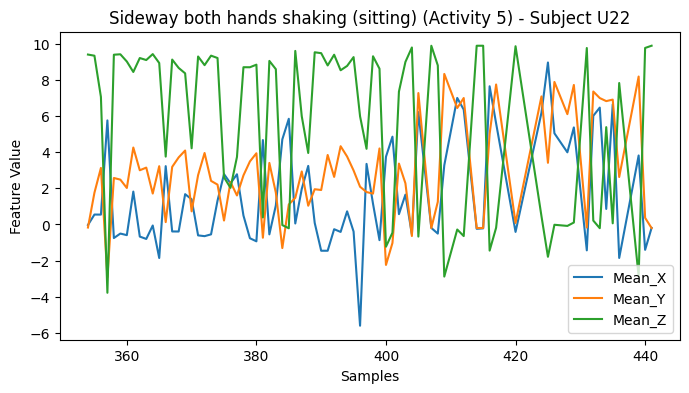

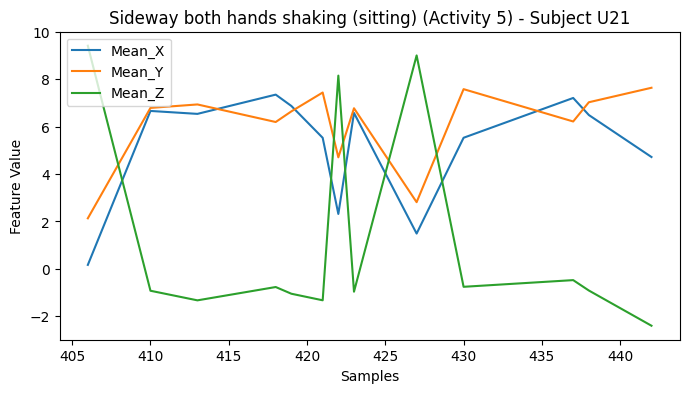

In [ ]:
view_activity(5)

Activity 1 = Sit and stand
Subjects: ['U22']


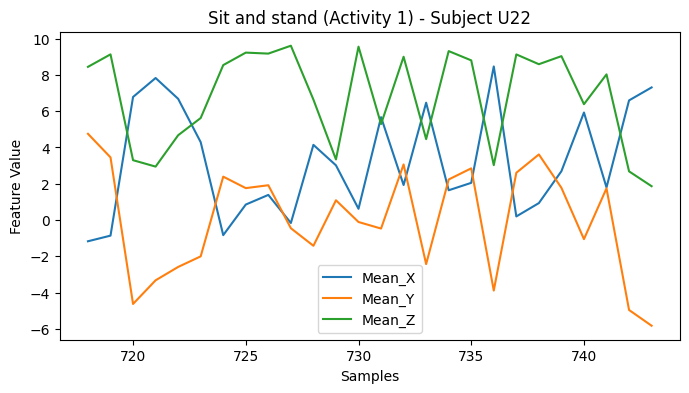

In [ ]:
view_activity(1)

In [ ]:
import os

os.path.getsize('/content/drive/MyDrive/CN6000Projectwork/final_model.pkl')

20247833

In [ ]:
import joblib

model = joblib.load('/content/drive/MyDrive/CN6000Projectwork/final_model.pkl')

print(model)

RandomForestClassifier(n_estimators=300, random_state=42)


In [ ]:
from sklearn.metrics import accuracy_score

X = df.drop(['activity_class','subject'], axis=1)
y = df['activity_class']

y_pred = model.predict(X)

print("Accuracy:", accuracy_score(y, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["activity_class", "subject"])
y = df["activity_class"]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

y_pred = model.predict(X)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
X = df.drop(['activity_class','subject'], axis=1)
y = df['activity_class']

In [ ]:
y_pred = model.predict(X)

In [ ]:
cm = confusion_matrix(y, y_pred)

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.show()

In [ ]:
import pandas as pd

real_data = pd.read_csv('/content/drive/MyDrive/tremor_bed_processed.csv')
real_data.head()

In [ ]:
import numpy as np

features = {
"Mean_X": real_data["X"].mean(),
"Std_X": real_data["X"].std(),
"Min_X": real_data["X"].min(),
"Max_X": real_data["X"].max(),
"Range_X": real_data["X"].max() - real_data["X"].min(),
"Energy_X": np.sum(real_data["X"]**2),

"Mean_Y": real_data["Y"].mean(),
"Std_Y": real_data["Y"].std(),
"Min_Y": real_data["Y"].min(),
"Max_Y": real_data["Y"].max(),
"Range_Y": real_data["Y"].max() - real_data["Y"].min(),
"Energy_Y": np.sum(real_data["Y"]**2),

"Mean_Z": real_data["Z"].mean(),
"Std_Z": real_data["Z"].std(),
"Min_Z": real_data["Z"].min(),
"Max_Z": real_data["Z"].max(),
"Range_Z": real_data["Z"].max() - real_data["Z"].min(),
"Energy_Z": np.sum(real_data["Z"]**2),

"Mean_Mag": real_data["magnitude"].mean(),
"Std_Mag": real_data["magnitude"].std(),
"Min_Mag": real_data["magnitude"].min(),
"Max_Mag": real_data["magnitude"].max(),
"Range_Mag": real_data["magnitude"].max() - real_data["magnitude"].min(),
"Energy_Mag": np.sum(real_data["magnitude"]**2)
}

X_real = pd.DataFrame([features])

In [ ]:
prediction = model.predict(X_real)

print("Predicted activity class:", prediction[0])

In [ ]:
print("Predicted activity:", activity_names[prediction[0]])

NameError: name 'activity_names' is not defined

In [ ]:
prediction = model.predict(X_real)
print(prediction)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(real_data["X"], label="X")
plt.plot(real_data["Y"], label="Y")
plt.plot(real_data["Z"], label="Z")

plt.title("Accelerometer Signal")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- Plot the accelerometer signal ----------
plt.figure(figsize=(10,5))

plt.plot(real_data["X"], label="X axis")
plt.plot(real_data["Y"], label="Y axis")
plt.plot(real_data["Z"], label="Z axis")

plt.title("Accelerometer Signal Analysis")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.legend()

plt.show()


# ---------- Feature extraction ----------
features = {
"Mean_X": real_data["X"].mean(),
"Std_X": real_data["X"].std(),
"Min_X": real_data["X"].min(),
"Max_X": real_data["X"].max(),
"Range_X": real_data["X"].max() - real_data["X"].min(),
"Energy_X": np.sum(real_data["X"]**2),

"Mean_Y": real_data["Y"].mean(),
"Std_Y": real_data["Y"].std(),
"Min_Y": real_data["Y"].min(),
"Max_Y": real_data["Y"].max(),
"Range_Y": real_data["Y"].max() - real_data["Y"].min(),
"Energy_Y": np.sum(real_data["Y"]**2),

"Mean_Z": real_data["Z"].mean(),
"Std_Z": real_data["Z"].std(),
"Min_Z": real_data["Z"].min(),
"Max_Z": real_data["Z"].max(),
"Range_Z": real_data["Z"].max() - real_data["Z"].min(),
"Energy_Z": np.sum(real_data["Z"]**2),

"Mean_Mag": real_data["magnitude"].mean(),
"Std_Mag": real_data["magnitude"].std(),
"Min_Mag": real_data["magnitude"].min(),
"Max_Mag": real_data["magnitude"].max(),
"Range_Mag": real_data["magnitude"].max() - real_data["magnitude"].min(),
"Energy_Mag": np.sum(real_data["magnitude"]**2)
}

X_real = pd.DataFrame([features])


# ---------- Model prediction ----------
prediction = model.predict(X_real)[0]


# ---------- Tremor classification ----------
print("\n----- Parkinson Movement Analysis Result -----\n")

if prediction in [5,6]:
    print("Detected Condition: Mild Tremor")
else:
    print("Detected Condition: No Tremor Detected")

print("\nModel Used: Random Forest")
print("Prediction Class:", prediction)

In [ ]:
prediction = model.predict(X_real)

print("Raw model prediction:", prediction)

In [ ]:
prediction = model.predict(X_real)[0]

print("Prediction Class:", prediction)
print("Activity Name:", activity_names[prediction])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

# -------------------------------
# 1 Load trained Random Forest model
# -------------------------------
model = joblib.load('/content/drive/MyDrive/CN6000Projectwork/final_model.pkl')


# -------------------------------
# 2 Load real accelerometer data
# -------------------------------
file_path = '/content/drive/MyDrive/tremor_bed_processed.csv'
real_data = pd.read_csv(file_path)

print("File analysed:", os.path.basename(file_path))


# -------------------------------
# 3 Plot accelerometer signal
# -------------------------------
plt.figure(figsize=(10,5))

plt.plot(real_data["X"], label="X axis")
plt.plot(real_data["Y"], label="Y axis")
plt.plot(real_data["Z"], label="Z axis")

plt.title("Accelerometer Signal Analysis")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.legend()

plt.show()


# -------------------------------
# 4 Extract statistical features
# -------------------------------
features = {
"Mean_X": real_data["X"].mean(),
"Std_X": real_data["X"].std(),
"Min_X": real_data["X"].min(),
"Max_X": real_data["X"].max(),
"Range_X": real_data["X"].max() - real_data["X"].min(),
"Energy_X": np.sum(real_data["X"]**2),

"Mean_Y": real_data["Y"].mean(),
"Std_Y": real_data["Y"].std(),
"Min_Y": real_data["Y"].min(),
"Max_Y": real_data["Y"].max(),
"Range_Y": real_data["Y"].max() - real_data["Y"].min(),
"Energy_Y": np.sum(real_data["Y"]**2),

"Mean_Z": real_data["Z"].mean(),
"Std_Z": real_data["Z"].std(),
"Min_Z": real_data["Z"].min(),
"Max_Z": real_data["Z"].max(),
"Range_Z": real_data["Z"].max() - real_data["Z"].min(),
"Energy_Z": np.sum(real_data["Z"]**2),

"Mean_Mag": real_data["magnitude"].mean(),
"Std_Mag": real_data["magnitude"].std(),
"Min_Mag": real_data["magnitude"].min(),
"Max_Mag": real_data["magnitude"].max(),
"Range_Mag": real_data["magnitude"].max() - real_data["magnitude"].min(),
"Energy_Mag": np.sum(real_data["magnitude"]**2)
}

X_real = pd.DataFrame([features])


# -------------------------------
# 5 Predict activity using model
# -------------------------------
prediction = model.predict(X_real)[0]


# -------------------------------
# 6 Activity labels
# -------------------------------
activity_names = {
1:"Sit and stand",
2:"Both hands shaking (sitting)",
3:"Stand up from chair with shaking",
4:"Sideway sit and stand",
5:"Sideway hands shaking (sitting)",
6:"Sideway stand up with shaking",
7:"Cool down / relax",
8:"Walking",
9:"Walk & stop / frozen",
10:"Slow walking with shaking"
}


# -------------------------------
# 7 Print final result
# -------------------------------
print("\n----- Parkinson Movement Analysis Result -----\n")

print("Prediction Class:", prediction)
print("Activity Name:", activity_names.get(prediction, "Unknown Activity"))


# Tremor detection rule
if prediction in [2,5,6]:
    print("Detected Condition: Tremor")
else:
    print("Detected Condition: No Tremor Detected")

print("\nModel Used: Random Forest")

In [ ]:
import pandas as pd
import joblib

model = joblib.load('/content/drive/MyDrive/CN6000Projectwork/final_model.pkl')

real_data = pd.read_csv('/content/drive/MyDrive/tremor_bed_processed.csv')

In [ ]:
real_data.head()

In [ ]:
print(model)

In [ ]:
print(real_data.shape)

In [ ]:
import os

os.listdir('/content/drive/MyDrive/CN6000Projectwork')

In [ ]:
import os
os.listdir('/content/drive/MyDrive')

In [ ]:
# Show all column names
print("All Columns:\n", df.columns)

# Show first few rows
print("\nSample Data:")
print(df.head())

# Basic info about dataset
print("\nDataset Info:")
print(df.info())

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded ✅")

In [ ]:

df["CV_X"] = df["Std_X"] / (df["Mean_X"].abs() + 1e-5)
df["CV_Y"] = df["Std_Y"] / (df["Mean_Y"].abs() + 1e-5)
df["CV_Z"] = df["Std_Z"] / (df["Mean_Z"].abs() + 1e-5)

In [ ]:
print(df.columns)


Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'subject', 'CV_X', 'CV_Y', 'CV_Z'],
      dtype='object')


In [ ]:
X = df.drop(columns=["subject", "activity_class"])

In [ ]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["activity_class"] = le.fit_transform(df["activity_class"])

In [ ]:
df = pd.read_csv(file_path)

In [ ]:
df = pd.read_csv(file_path)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["activity_class"] = le.fit_transform(df["activity_class"])

In [ ]:
# ======================================
# DEFINE FEATURES & LABEL
# ======================================
X = df.drop(columns=["subject", "activity_class"])
y = df["activity_class"]
subjects = df["subject"].unique()

# ======================================
# STORAGE FOR ACCURACY
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    y_train = train_df["activity_class"]

    X_test = test_df.drop(columns=["subject", "activity_class"])
    y_test = test_df["activity_class"]

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # XGBoost
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

print("Model Training Done ✅")

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. ADD CV FEATURES
# ======================================
df["CV_X"] = df["Std_X"] / (df["Mean_X"].abs() + 1e-5)
df["CV_Y"] = df["Std_Y"] / (df["Mean_Y"].abs() + 1e-5)
df["CV_Z"] = df["Std_Z"] / (df["Mean_Z"].abs() + 1e-5)

print("CV Features Added ✅")

# ======================================
# 4. DEFINE FEATURES & SUBJECTS
# ======================================
subjects = df["subject"].unique()

# ======================================
# 5. STORAGE FOR ACCURACY
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# 6. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    X_test = test_df.drop(columns=["subject", "activity_class"])

    # 🔥 FIX: Encode labels INSIDE loop
    le = LabelEncoder()
    y_train = le.fit_transform(train_df["activity_class"])
    y_test = le.transform(test_df["activity_class"])

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # XGBoost
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

print("Model Training Done ✅")

# ======================================
# 7. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. ADD CV FEATURES
# ======================================
df["CV_X"] = df["Std_X"] / (df["Mean_X"].abs() + 1e-5)
df["CV_Y"] = df["Std_Y"] / (df["Mean_Y"].abs() + 1e-5)
df["CV_Z"] = df["Std_Z"] / (df["Mean_Z"].abs() + 1e-5)

print("CV Features Added ✅")

# ======================================
# 4. SUBJECTS
# ======================================
subjects = df["subject"].unique()

# ======================================
# 5. STORAGE
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# 6. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    X_test = test_df.drop(columns=["subject", "activity_class"])

    # ✅ FIX LABEL ISSUE (ONLY CHANGE)
    y_train = train_df["activity_class"].values
    y_test = test_df["activity_class"].values

    # Make labels start from 0
    y_train = y_train - y_train.min()
    y_test = y_test - y_test.min()

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # XGBoost
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

print("Model Training Done ✅")

# ======================================
# 7. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. ADD CV FEATURES
# ======================================
df["CV_X"] = df["Std_X"] / (df["Mean_X"].abs() + 1e-5)
df["CV_Y"] = df["Std_Y"] / (df["Mean_Y"].abs() + 1e-5)
df["CV_Z"] = df["Std_Z"] / (df["Mean_Z"].abs() + 1e-5)

print("CV Features Added ✅")

# ======================================
# 4. SUBJECTS
# ======================================
subjects = df["subject"].unique()

# ======================================
# 5. STORAGE
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# 6. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    X_test = test_df.drop(columns=["subject", "activity_class"])

    # ✅ FINAL FIX (continuous labels)
    le = LabelEncoder()
    y_train = le.fit_transform(train_df["activity_class"])

    # IMPORTANT: only keep labels that exist in training
    y_test = le.transform(test_df["activity_class"].map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    ))

    # Decision Tree
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    #IMPROVED RANDOM FOREST
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        random_state=42
    )

    rf.fit(X_train, y_train)
    rf_scores.append(accuracy_score(y_test, rf.predict(X_test)))

    # XGBOOST
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

print("Model Training Done ✅")

# ======================================
# 7. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))

Dataset Loaded Successfully ✅
CV Features Added ✅
Model Training Done ✅

===== FINAL RESULTS =====
Decision Tree Average Accuracy: 0.6350344804094374
Random Forest Average Accuracy: 0.6892592821271784
XGBoost Average Accuracy: 0.6815495236911819


In [ ]:
# Use full dataset WITH CV
X = df.drop(columns=["subject", "activity_class"])
y = df["activity_class"]
subjects = df["subject"].unique()

from sklearn.preprocessing import LabelEncoder

rf_scores = []

for subject in subjects:
    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    X_test  = test_df.drop(columns=["subject", "activity_class"])

    # Fix labels
    le = LabelEncoder()
    y_train = le.fit_transform(train_df["activity_class"])
    y_test  = le.transform(test_df["activity_class"].map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    ))

    # Random Forest (best model)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rf_scores.append(accuracy_score(y_test, y_pred))

# Final result
print("Random Forest WITH CV:", np.mean(rf_scores))

Random Forest WITH CV: 0.6789764075094413


In [ ]:
print(df.head())

     Mean_X     Std_X    Mean_Y     Std_Y    Mean_Z     Std_Z   Mean_Mag  \
0 -0.283026  2.885052  2.427451  2.290923  9.263163  2.551214  10.328163   
1  0.611794  1.096669  3.276080  1.068509  9.116108  1.758814   9.839803   
2  1.295736  0.827551  2.554286  0.597138  9.342066  1.160793   9.830081   
3 -0.487119  0.814506  3.596524  0.645759  9.042971  1.344603   9.805839   
4  3.846291  1.229733 -2.269635  1.129573  8.688826  0.415838   9.915030   

    Std_Mag  activity_class subject       CV_X      CV_Y      CV_Z  
0  2.274772               6     U22  10.193234  0.943753  0.275415  
1  1.680571               6     U22   1.792518  0.326154  0.192935  
2  1.111122               6     U22   0.638667  0.233778  0.124254  
3  1.296140               6     U22   1.672054  0.179550  0.148690  
4  0.295495               6     U22   0.319718  0.497687  0.047859  


In [ ]:
print(df.describe())

           Mean_X       Std_X      Mean_Y       Std_Y      Mean_Z       Std_Z  \
count  853.000000  853.000000  853.000000  853.000000  853.000000  853.000000   
mean    -0.365551    1.385711    0.658315    1.189483    4.500110    1.394772   
std      3.683794    1.509797    4.094427    1.303454    6.162611    1.847271   
min     -9.033315    0.004463  -10.174639    0.004499   -9.829367    0.003829   
25%     -1.392963    0.095995   -0.198920    0.079099   -0.549535    0.095601   
50%      0.306411    0.929115    0.845420    0.793934    8.113699    0.744946   
75%      1.251984    2.084283    2.992428    1.847582    9.414552    1.961367   
max      8.960556   10.626068    9.430779    7.062469   10.108107   13.697528   

         Mean_Mag     Std_Mag  activity_class         CV_X        CV_Y  \
count  853.000000  853.000000      853.000000   853.000000  853.000000   
mean     9.993774    0.785112        6.046893     4.979244    2.002763   
std      0.507555    0.971732        2.489915   

In [ ]:
print(X_train.shape)
print(X_train.columns)

(813, 11)
Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'CV_X', 'CV_Y', 'CV_Z'],
      dtype='object')


In [ ]:
print(rf)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=300,
                       random_state=42)


In [ ]:
print(np.mean(rf_scores))

0.6892592821271784


In [ ]:
print("Decision Tree Accuracy:", np.mean(dt_scores))
print("Random Forest Accuracy:", np.mean(rf_scores))
print("XGBoost Accuracy:", np.mean(xgb_scores))

Decision Tree Accuracy: 0.6350344804094374
Random Forest Accuracy: 0.6892592821271784
XGBoost Accuracy: 0.6815495236911819


In [ ]:
results = {
    "Decision Tree": np.mean(dt_scores),
    "Random Forest": np.mean(rf_scores),
    "XGBoost": np.mean(xgb_scores)
}

import json
with open("/content/drive/MyDrive/final_results.json", "w") as f:
    json.dump(results, f)

print("Results saved ✅")

Results saved ✅


In [ ]:
def tremor_label(x):
    if x < 0.5:
        return "No tremor"
    elif x < 1.5:
        return "Mild tremor"
    elif x < 3:
        return "Moderate tremor"
    else:
        return "Severe tremor"

df["Tremor_Level"] = df["Std_Mag"].apply(tremor_label)

In [ ]:
df[["subject", "activity_class", "Std_Mag", "Tremor_Level"]].head(10)

,subject,activity_class,Std_Mag,Tremor_Level
0,U22,6,2.274772,Moderate tremor
1,U22,6,1.680571,Moderate tremor
2,U22,6,1.111122,Mild tremor
3,U22,6,1.296140,Mild tremor
4,U22,6,0.295495,No tremor
5,U22,6,0.543795,Mild tremor
6,U22,6,0.867232,Mild tremor
7,U22,6,0.992428,Mild tremor
8,U22,6,0.670892,Mild tremor
9,U22,6,1.893891,Moderate tremor


In [ ]:
df["Tremor_Level"].value_counts()

,count
Tremor_Level,
No tremor,441
Mild tremor,259
Moderate tremor,129
Severe tremor,24


In [ ]:
row = df.iloc[0]
print(row)

Mean_X                  -0.283026
Std_X                    2.885052
Mean_Y                   2.427451
Std_Y                    2.290923
Mean_Z                   9.263163
Std_Z                    2.551214
Mean_Mag                10.328163
Std_Mag                  2.274772
activity_class                  6
subject                       U22
CV_X                    10.193234
CV_Y                     0.943753
CV_Z                     0.275415
Tremor_Level      Moderate tremor
Name: 0, dtype: object


In [ ]:
print("Std_Mag:", row["Std_Mag"])

Std_Mag: 2.274771582280927


In [ ]:
row = df.iloc[0]

print("Subject:", row["subject"])
print("Activity:", row["activity_class"])
print("Std_Mag:", row["Std_Mag"])

def tremor_label(x):
    if x < 0.5:
        return "No tremor"
    elif x < 1.5:
        return "Mild tremor"
    elif x < 3:
        return "Moderate tremor"
    else:
        return "Severe tremor"

print("Tremor Level:", tremor_label(row["Std_Mag"]))

Subject: U22
Activity: 6
Std_Mag: 2.274771582280927
Tremor Level: Moderate tremor


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [ ]:
df["SMA"] = (
    abs(df["Mean_X"]) +
    abs(df["Mean_Y"]) +
    abs(df["Mean_Z"])
)

In [ ]:
# ======================================
# ADD CV FEATURES
# ======================================
df["CV_X"] = df["Std_X"] / (df["Mean_X"].abs() + 1e-5)
df["CV_Y"] = df["Std_Y"] / (df["Mean_Y"].abs() + 1e-5)
df["CV_Z"] = df["Std_Z"] / (df["Mean_Z"].abs() + 1e-5)

print("CV Features Added ✅")

CV Features Added ✅


In [ ]:
# ======================================
# FIX CV OUTLIERS
# ======================================
df["CV_X"] = df["CV_X"].clip(0, 50)
df["CV_Y"] = df["CV_Y"].clip(0, 50)
df["CV_Z"] = df["CV_Z"].clip(0, 50)

print("CV Features Clipped ✅")

CV Features Clipped ✅


In [ ]:
print(df.columns)

Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'subject', 'SMA', 'CV_X', 'CV_Y', 'CV_Z'],
      dtype='object')


In [ ]:


# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. ADD FEATURES
# ======================================

# --- CV FEATURES ---
df["CV_X"] = df["Std_X"] / (df["Mean_X"].abs() + 1e-5)
df["CV_Y"] = df["Std_Y"] / (df["Mean_Y"].abs() + 1e-5)
df["CV_Z"] = df["Std_Z"] / (df["Mean_Z"].abs() + 1e-5)

print("CV Features Added ✅")

# --- SIGNAL MAGNITUDE AREA (SMA) ---
df["SMA"] = (
    abs(df["Mean_X"]) +
    abs(df["Mean_Y"]) +
    abs(df["Mean_Z"])
)

print("SMA Feature Added ✅")

# --- FIX CV OUTLIERS ---
df["CV_X"] = df["CV_X"].clip(0, 50)
df["CV_Y"] = df["CV_Y"].clip(0, 50)
df["CV_Z"] = df["CV_Z"].clip(0, 50)

print("CV Features Clipped ✅")

# ======================================
# 4. SUBJECTS
# ======================================
subjects = df["subject"].unique()

# ======================================
# 5. STORAGE
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []

# ======================================
# 6. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    X_test = test_df.drop(columns=["subject", "activity_class"])

    # Label Encoding
    le = LabelEncoder()
    y_train = le.fit_transform(train_df["activity_class"])

    # Keep only valid labels in test set
    valid_mask = test_df["activity_class"].isin(le.classes_)

    X_test = X_test[valid_mask]
    y_test = le.transform(test_df["activity_class"][valid_mask])

    # -----------------------
    # Decision Tree
    # -----------------------
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    dt_scores.append(accuracy_score(y_test, y_pred_dt))

    # -----------------------
    # Random Forest
    # -----------------------
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        random_state=42
    )

    rf.fit(X_train, y_train)
    rf_scores.append(accuracy_score(y_test, rf.predict(X_test)))

    # -----------------------
    # XGBoost
    # -----------------------
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        use_label_encoder=False
    )

    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, y_pred_xgb))

print("Model Training Done ✅")

# ======================================
# 7. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))

Dataset Loaded Successfully ✅
CV Features Added ✅
SMA Feature Added ✅
CV Features Clipped ✅


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:32:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:32:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:32:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Model Training Done ✅

===== FINAL RESULTS =====
Decision Tree Average Accuracy: 0.5977993006684481
Random Forest Average Accuracy: 0.6902295729804463
XGBoost Average Accuracy: 0.6856513676010874


In [ ]:

print("\n===== FEATURE SUMMARY =====")
print(df.describe())


===== FEATURE SUMMARY =====
           Mean_X       Std_X      Mean_Y       Std_Y      Mean_Z       Std_Z  \
count  853.000000  853.000000  853.000000  853.000000  853.000000  853.000000   
mean    -0.365551    1.385711    0.658315    1.189483    4.500110    1.394772   
std      3.683794    1.509797    4.094427    1.303454    6.162611    1.847271   
min     -9.033315    0.004463  -10.174639    0.004499   -9.829367    0.003829   
25%     -1.392963    0.095995   -0.198920    0.079099   -0.549535    0.095601   
50%      0.306411    0.929115    0.845420    0.793934    8.113699    0.744946   
75%      1.251984    2.084283    2.992428    1.847582    9.414552    1.961367   
max      8.960556   10.626068    9.430779    7.062469   10.108107   13.697528   

         Mean_Mag     Std_Mag  activity_class        CV_X        CV_Y  \
count  853.000000  853.000000      853.000000  853.000000  853.000000   
mean     9.993774    0.785112        6.046893    2.234044    1.083197   
std      0.507555    0

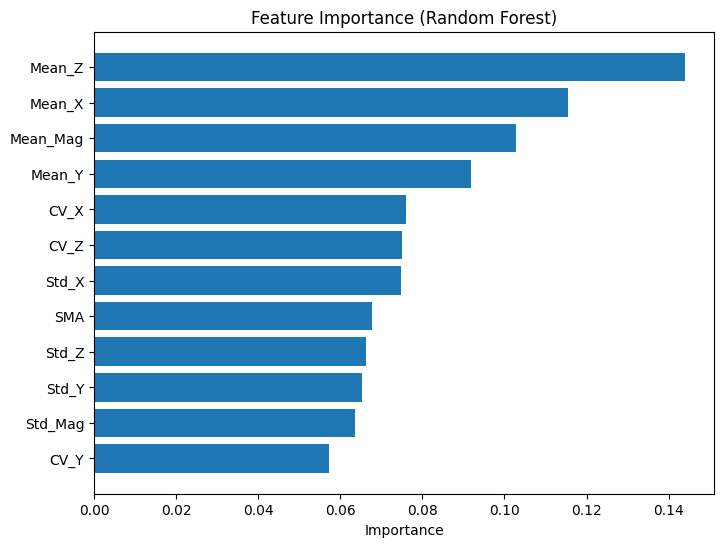

In [ ]:
# ======================================
# FEATURE IMPORTANCE (Random Forest)
# ======================================

import matplotlib.pyplot as plt

# Train RF on full dataset (for importance visualization)
X = df.drop(columns=["subject", "activity_class"])
y = LabelEncoder().fit_transform(df["activity_class"])

rf.fit(X, y)

importances = rf.feature_importances_
features = X.columns

# Sort features
indices = np.argsort(importances)

# Plot
plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [ ]:
print(df[["CV_X","CV_Y","CV_Z","SMA"]].describe())

             CV_X        CV_Y        CV_Z         SMA
count  853.000000  853.000000  853.000000  853.000000
mean     2.234044    1.083197    1.056702   12.484170
std      6.436545    4.230988    4.830079    1.946688
min      0.001250    0.001096    0.000391    4.793525
25%      0.042412    0.057335    0.020486   10.594993
50%      0.514967    0.224498    0.125222   12.487337
75%      1.652325    0.697913    0.458840   14.094573
max     50.000000   50.000000   50.000000   17.181422


In [ ]:
# ======================================
# SAVE UPDATED DATASET
# ======================================

save_path = "/content/drive/MyDrive/final_loso_dataset_with_features.csv"
df.to_csv(save_path, index=False)

print("Dataset saved successfully ✅")

Dataset saved successfully ✅


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

In [ ]:
subjects = df["subject"].unique()

In [ ]:
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])

    print("Shape:", X_train.shape)
    print(X_train.head())
    break

Shape: (442, 8)
      Mean_X     Std_X    Mean_Y     Std_Y    Mean_Z     Std_Z   Mean_Mag  \
92 -7.721362  0.207596 -6.125115  0.151833  0.349646  0.709897   9.890038   
93 -3.673190  0.864341 -2.611048  0.709455 -8.721014  0.265211   9.878486   
94 -3.009848  0.536850  1.258562  0.534186 -9.236997  0.431252   9.826773   
95  0.987846  1.695644 -9.753714  1.926329 -1.532362  2.410774  10.308401   
96 -8.182710  0.019209 -5.525074  0.012385 -0.091970  0.036769   9.873867   

     Std_Mag  
92  0.124555  
93  0.318074  
94  0.398785  
95  2.141662  
96  0.015917  


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
dl_scores = []

In [ ]:

import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Deep Learning (MLP)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. ADD FEATURES
# ======================================

# --- CV FEATURES ---
df["CV_X"] = df["Std_X"] / (df["Mean_X"].abs() + 1e-5)
df["CV_Y"] = df["Std_Y"] / (df["Mean_Y"].abs() + 1e-5)
df["CV_Z"] = df["Std_Z"] / (df["Mean_Z"].abs() + 1e-5)

print("CV Features Added ✅")

# --- SIGNAL MAGNITUDE AREA (SMA) ---
df["SMA"] = (
    abs(df["Mean_X"]) +
    abs(df["Mean_Y"]) +
    abs(df["Mean_Z"])
)

print("SMA Feature Added ✅")

# --- FIX CV OUTLIERS ---
df["CV_X"] = df["CV_X"].clip(0, 50)
df["CV_Y"] = df["CV_Y"].clip(0, 50)
df["CV_Z"] = df["CV_Z"].clip(0, 50)

print("CV Features Clipped ✅")

# ======================================
# 4. SUBJECTS
# ======================================
subjects = df["subject"].unique()

# ======================================
# 5. STORAGE
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []
dl_scores = []

# ======================================
# 6. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    X_test = test_df.drop(columns=["subject", "activity_class"])

    # Label Encoding
    le = LabelEncoder()
    y_train = le.fit_transform(train_df["activity_class"])

    # Keep only valid labels in test set
    valid_mask = test_df["activity_class"].isin(le.classes_)

    X_test = X_test[valid_mask]
    y_test = le.transform(test_df["activity_class"][valid_mask])

    # -----------------------
    # Decision Tree
    # -----------------------
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    dt_scores.append(accuracy_score(y_test, dt.predict(X_test)))

    # -----------------------
    # Random Forest
    # -----------------------
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        random_state=42
    )

    rf.fit(X_train, y_train)
    rf_scores.append(accuracy_score(y_test, rf.predict(X_test)))

    # -----------------------
    # XGBoost
    # -----------------------
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        use_label_encoder=False
    )

    xgb.fit(X_train, y_train)
    xgb_scores.append(accuracy_score(y_test, xgb.predict(X_test)))

    # -----------------------
    # MLP (Deep Learning)
    # -----------------------
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)

    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(y_train_cat.shape[1], activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train_cat, epochs=30, batch_size=16, verbose=0)

    y_pred_dl = model.predict(X_test)
    y_pred_dl = np.argmax(y_pred_dl, axis=1)

    dl_scores.append(accuracy_score(y_test, y_pred_dl))

print("Model Training Done ✅")

# ======================================
# 7. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))
print("Deep Learning (MLP) Average Accuracy:", np.mean(dl_scores))

Dataset Loaded Successfully ✅
CV Features Added ✅
SMA Feature Added ✅
CV Features Clipped ✅


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:57:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:57:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step 


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:58:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:59:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Model Training Done ✅

===== FINAL RESULTS =====
Decision Tree Average Accuracy: 0.5977993006684481
Random Forest Average Accuracy: 0.6902295729804463
XGBoost Average Accuracy: 0.6856513676010874
Deep Learning (MLP) Average Accuracy: 0.6952474324655777


In [ ]:
print("Random Forest Accuracy:", np.mean(rf_scores))

Random Forest Accuracy: 0.6902295729804463


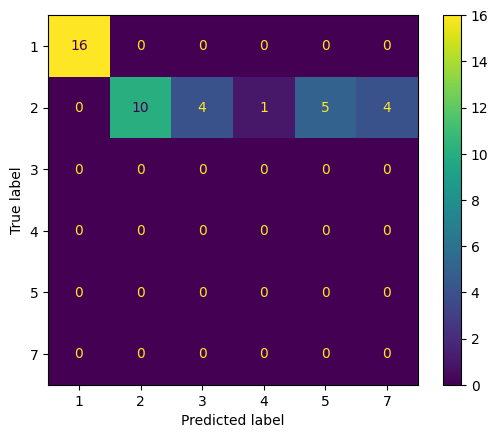

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf.predict(X_test))

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        16
           2       1.00      0.42      0.59        24
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0

    accuracy                           0.65        40
   macro avg       0.33      0.24      0.26        40
weighted avg       1.00      0.65      0.75        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Dataset Loaded Successfully ✅
CV Features Added ✅
SMA Feature Added ✅
CV Features Clipped ✅


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:37:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:37:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:38:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:39:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Model Training Done ✅

===== FINAL RESULTS =====
Decision Tree Average Accuracy: 0.5977993006684481
Random Forest Average Accuracy: 0.6902295729804463
XGBoost Average Accuracy: 0.6856513676010874
Deep Learning (MLP) Average Accuracy: 0.6563446523771789


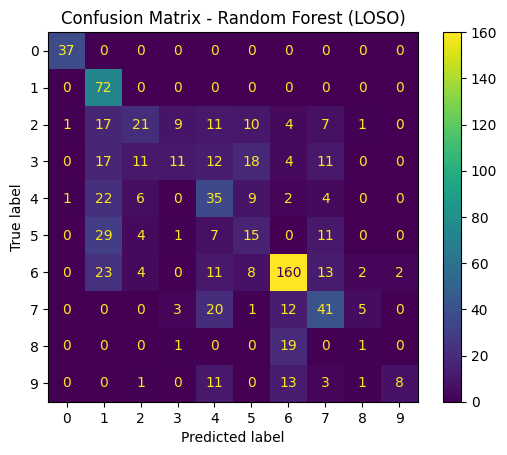

In [ ]:
# ======================================
# 1. IMPORT LIBRARIES
# ======================================
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Deep Learning (MLP)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ======================================
# 2. LOAD DATA
# ======================================
file_path = "/content/drive/MyDrive/final_loso_dataset_with_features.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

# ======================================
# 3. ADD FEATURES
# ======================================
df["CV_X"] = df["Std_X"] / (df["Mean_X"].abs() + 1e-5)
df["CV_Y"] = df["Std_Y"] / (df["Mean_Y"].abs() + 1e-5)
df["CV_Z"] = df["Std_Z"] / (df["Mean_Z"].abs() + 1e-5)

print("CV Features Added ✅")

df["SMA"] = (
    abs(df["Mean_X"]) +
    abs(df["Mean_Y"]) +
    abs(df["Mean_Z"])
)

print("SMA Feature Added ✅")

df["CV_X"] = df["CV_X"].clip(0, 50)
df["CV_Y"] = df["CV_Y"].clip(0, 50)
df["CV_Z"] = df["CV_Z"].clip(0, 50)

print("CV Features Clipped ✅")

# ======================================
# 4. SUBJECTS
# ======================================
subjects = df["subject"].unique()

# ======================================
# 5. STORAGE
# ======================================
dt_scores = []
rf_scores = []
xgb_scores = []
dl_scores = []

# 🔥 NEW: store all predictions
all_y_test = []
all_y_pred = []

# ======================================
# 6. LOSO CROSS VALIDATION
# ======================================
for subject in subjects:

    train_df = df[df["subject"] != subject]
    test_df  = df[df["subject"] == subject]

    X_train = train_df.drop(columns=["subject", "activity_class"])
    X_test = test_df.drop(columns=["subject", "activity_class"])

    le = LabelEncoder()
    y_train = le.fit_transform(train_df["activity_class"])

    valid_mask = test_df["activity_class"].isin(le.classes_)
    X_test = X_test[valid_mask]
    y_test = le.transform(test_df["activity_class"][valid_mask])

    # -----------------------
    # Decision Tree
    # -----------------------
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_train, y_train)
    dt_scores.append(accuracy_score(y_test, dt.predict(X_test)))

    # -----------------------
    # Random Forest
    # -----------------------
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    rf_scores.append(accuracy_score(y_test, y_pred_rf))

    # 🔥 STORE ALL PREDICTIONS (IMPORTANT)
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred_rf)

    # -----------------------
    # XGBoost
    # -----------------------
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        use_label_encoder=False
    )

    xgb.fit(X_train, y_train)
    xgb_scores.append(accuracy_score(y_test, xgb.predict(X_test)))

    # -----------------------
    # MLP (Deep Learning)
    # -----------------------
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)

    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(y_train_cat.shape[1], activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train_cat, epochs=30, batch_size=16, verbose=0)

    y_pred_dl = model.predict(X_test)
    y_pred_dl = np.argmax(y_pred_dl, axis=1)

    dl_scores.append(accuracy_score(y_test, y_pred_dl))

print("Model Training Done ✅")

# ======================================
# 7. FINAL RESULTS
# ======================================
print("\n===== FINAL RESULTS =====")
print("Decision Tree Average Accuracy:", np.mean(dt_scores))
print("Random Forest Average Accuracy:", np.mean(rf_scores))
print("XGBoost Average Accuracy:", np.mean(xgb_scores))
print("Deep Learning (MLP) Average Accuracy:", np.mean(dl_scores))

# ======================================
# 8. CONFUSION MATRIX (FINAL)
# ======================================
ConfusionMatrixDisplay.from_predictions(all_y_test, all_y_pred)
plt.title("Confusion Matrix - Random Forest (LOSO)")
plt.show()

In [ ]:
file_path = "/content/drive/MyDrive/final_loso_dataset.csv"
df = pd.read_csv(file_path)

In [ ]:
print(df.head())

     Mean_X     Std_X    Mean_Y     Std_Y    Mean_Z     Std_Z   Mean_Mag  \
0 -0.283026  2.885052  2.427451  2.290923  9.263163  2.551214  10.328163   
1  0.611794  1.096669  3.276080  1.068509  9.116108  1.758814   9.839803   
2  1.295736  0.827551  2.554286  0.597138  9.342066  1.160793   9.830081   
3 -0.487119  0.814506  3.596524  0.645759  9.042971  1.344603   9.805839   
4  3.846291  1.229733 -2.269635  1.129573  8.688826  0.415838   9.915030   

    Std_Mag  activity_class subject  
0  2.274772               6     U22  
1  1.680571               6     U22  
2  1.111122               6     U22  
3  1.296140               6     U22  
4  0.295495               6     U22  


In [ ]:
print(df.shape)
print(df.columns)

(853, 10)
Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'subject'],
      dtype='object')


In [ ]:
print(df.describe())

           Mean_X       Std_X      Mean_Y       Std_Y      Mean_Z       Std_Z  \
count  853.000000  853.000000  853.000000  853.000000  853.000000  853.000000   
mean    -0.365551    1.385711    0.658315    1.189483    4.500110    1.394772   
std      3.683794    1.509797    4.094427    1.303454    6.162611    1.847271   
min     -9.033315    0.004463  -10.174639    0.004499   -9.829367    0.003829   
25%     -1.392963    0.095995   -0.198920    0.079099   -0.549535    0.095601   
50%      0.306411    0.929115    0.845420    0.793934    8.113699    0.744946   
75%      1.251984    2.084283    2.992428    1.847582    9.414552    1.961367   
max      8.960556   10.626068    9.430779    7.062469   10.108107   13.697528   

         Mean_Mag     Std_Mag  activity_class  
count  853.000000  853.000000      853.000000  
mean     9.993774    0.785112        6.046893  
std      0.507555    0.971732        2.489915  
min      9.584959    0.003876        1.000000  
25%      9.807757    0.066985 

In [ ]:
print(df.columns)

Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'subject'],
      dtype='object')


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/final_loso_dataset_with_features.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [ ]:
print(df.head())

     Mean_X     Std_X    Mean_Y     Std_Y    Mean_Z     Std_Z   Mean_Mag  \
0 -0.283026  2.885052  2.427451  2.290923  9.263163  2.551214  10.328163   
1  0.611794  1.096669  3.276080  1.068509  9.116108  1.758814   9.839803   
2  1.295736  0.827551  2.554286  0.597138  9.342066  1.160793   9.830081   
3 -0.487119  0.814506  3.596524  0.645759  9.042971  1.344603   9.805839   
4  3.846291  1.229733 -2.269635  1.129573  8.688826  0.415838   9.915030   

    Std_Mag  activity_class subject       CV_X      CV_Y      CV_Z        SMA  
0  2.274772               6     U22  10.193234  0.943753  0.275415  11.973640  
1  1.680571               6     U22   1.792518  0.326154  0.192935  13.003982  
2  1.111122               6     U22   0.638667  0.233778  0.124254  13.192088  
3  1.296140               6     U22   1.672054  0.179550  0.148690  13.126614  
4  0.295495               6     U22   0.319718  0.497687  0.047859  14.804752  


In [ ]:
import os

files = os.listdir("/content/drive/MyDrive")
print(files)

['Nirmala Tamang CV (1).docx', 'Nirmala Tamang CV.docx', 'MWIT_Seminar_Activity_Student (2) (1).gdoc', 'MWIT_Seminar_Activity_Student (2).gdoc', 'FastTrack - Accessing Courses Process.docx', 'Assessment Front Sheet (1).gdoc', 'Impact of influencer tourism (2) (1).gdoc', 'Impact of influencer tourism (2).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', '000001.gdoc', 'Reflective Log 2024-25 (1) add (1).docx', 'Reflective Log 2024-25 (1) add.docx', 'Colab Notebooks', 'Untitled document.gdoc', 'pd-ch-abc25 (1).gdoc', '18956.pdf', 'CN6000Projectwork', 'CARING_LANE_LIMITED_2025_Tax_Week_44.pdf', 'Saved from the Google app', 'final_loso_dataset.csv', 'final_random_forest_model.pkl', 'lstm_model.h5', 'tremor_bed_processed.csv', 'activity_X.npy', 'activity_y.npy', 'final_results.json', 'final_loso_dataset_with_features.csv']


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/lstm_model.h5")

print("LSTM model loaded successfully ✅")

LSTM model loaded successfully ✅


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │           594 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,732 (123.96 KB)

 Trainable params: 31,602 (123.45 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
df_u22 = df[df["subject"] == "U22"]

print(df_u22.shape)
df_u22.head()

(411, 14)


,Mean_X,Std_X,Mean_Y,Std_Y,Mean_Z,Std_Z,Mean_Mag,Std_Mag,activity_class,subject,CV_X,CV_Y,CV_Z,SMA
0,-0.283026,2.885052,2.427451,2.290923,9.263163,2.551214,10.328163,2.274772,6,U22,10.193234,0.943753,0.275415,11.973640
1,0.611794,1.096669,3.276080,1.068509,9.116108,1.758814,9.839803,1.680571,6,U22,1.792518,0.326154,0.192935,13.003982
2,1.295736,0.827551,2.554286,0.597138,9.342066,1.160793,9.830081,1.111122,6,U22,0.638667,0.233778,0.124254,13.192088
3,-0.487119,0.814506,3.596524,0.645759,9.042971,1.344603,9.805839,1.296140,6,U22,1.672054,0.179550,0.148690,13.126614
4,3.846291,1.229733,-2.269635,1.129573,8.688826,0.415838,9.915030,0.295495,6,U22,0.319718,0.497687,0.047859,14.804752


In [ ]:
df_u22["activity_class"].value_counts()

,count
activity_class,
5,76
8,67
7,66
9,47
6,44
2,37
4,34
1,26
10,14


In [ ]:
df_tremor = df_u22[df_u22["activity_class"] == 2]

print(df_tremor.shape)
df_tremor.head()

(37, 14)


,Mean_X,Std_X,Mean_Y,Std_Y,Mean_Z,Std_Z,Mean_Mag,Std_Mag,activity_class,subject,CV_X,CV_Y,CV_Z,SMA
744,0.308821,0.008289,-0.170093,0.008375,10.090971,0.009235,10.097135,0.009192,2,U22,0.026840,0.049236,0.000915,10.569886
745,0.311179,0.009654,-0.174757,0.008263,10.093236,0.011963,10.099551,0.011938,2,U22,0.031023,0.047278,0.001185,10.579171
748,0.310007,0.008846,-0.172558,0.008598,10.089964,0.009261,10.096207,0.009236,2,U22,0.028535,0.049824,0.000918,10.572529
749,0.309157,0.009048,-0.170279,0.009543,10.088743,0.009049,10.094923,0.009069,2,U22,0.029267,0.056039,0.000897,10.568179
752,0.309850,0.008535,-0.171664,0.008834,10.091607,0.008848,10.097829,0.008845,2,U22,0.027545,0.051457,0.000877,10.573121


In [ ]:
df_normal = df_u22[df_u22["activity_class"] == 1]

df_normal.describe()

,Mean_X,Std_X,Mean_Y,Std_Y,Mean_Z,Std_Z,Mean_Mag,Std_Mag,activity_class,CV_X,CV_Y,CV_Z,SMA
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.0,26.000000,26.000000,26.000000,26.000000
mean,3.238751,2.357314,0.004819,2.419533,6.757604,2.404696,9.977374,1.457856,1.0,1.493046,2.185696,0.507780,12.781010
std,3.025799,1.108196,2.984702,1.167598,2.658668,1.519432,0.148732,0.665078,0.0,1.965481,3.797852,0.508148,1.738836
min,-1.169192,0.383263,-5.821607,0.382691,1.864135,0.190601,9.811853,0.049975,1.0,0.208946,0.110851,0.020884,7.441074
25%,0.872979,1.445474,-2.320247,1.753009,4.510356,1.436041,9.847039,0.982883,1.0,0.492041,0.592656,0.170416,11.853089
50%,2.369521,2.205637,0.490369,2.240988,8.231146,2.187761,9.953411,1.615294,1.0,0.799507,0.794821,0.310882,13.264089
75%,6.328388,3.256567,2.351539,2.975258,9.099840,3.186888,10.091752,1.768549,1.0,1.302484,2.582692,0.674283,13.972988
max,8.462360,4.275703,4.750146,5.630074,9.602401,7.866957,10.420015,2.660188,1.0,8.776232,19.111724,2.356502,15.371328


In [ ]:
df[df["subject"] == "U1"].head()

,Mean_X,Std_X,Mean_Y,Std_Y,Mean_Z,Std_Z,Mean_Mag,Std_Mag,activity_class,subject,CV_X,CV_Y,CV_Z,SMA
231,-1.348075,0.004676,0.049660,0.004995,9.789126,0.005382,9.881639,0.005461,7,U1,0.003469,0.100555,0.000550,11.186861
232,0.370916,2.322437,-8.410374,4.076167,0.811406,3.482561,10.169367,1.493679,7,U1,6.261190,0.484659,4.291958,9.592696
233,1.051278,1.579499,-9.868403,1.576563,-0.652006,1.809618,10.205028,1.738863,7,U1,1.502441,0.159759,2.775419,11.571687
236,-1.346972,0.004755,0.050486,0.004866,9.791523,0.003947,9.883868,0.003987,7,U1,0.003530,0.096366,0.000403,11.188981
241,0.051042,0.174660,-0.130996,0.201811,9.880019,0.072144,9.884582,0.077166,7,U1,3.421212,1.540479,0.007302,10.062057


In [ ]:
## Your Random Forest model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Add evaluation here
y_pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

NameError: name 'X_train' is not defined

In [ ]:
import os
import pandas as pd

folder_path = "your_folder_path_here"  # ⚠️ change this

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        print("\n====", file, "====")

        try:
            df = pd.read_csv(os.path.join(folder_path, file))
            print("Shape:", df.shape)
            print("Columns:", list(df.columns))
            print(df.head(2))
        except:
            print("Error reading file")

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Nirmala Tamang CV (1).docx', 'Nirmala Tamang CV.docx', 'MWIT_Seminar_Activity_Student (2) (1).gdoc', 'MWIT_Seminar_Activity_Student (2).gdoc', 'FastTrack - Accessing Courses Process.docx', 'Assessment Front Sheet (1).gdoc', 'Impact of influencer tourism (2) (1).gdoc', 'Impact of influencer tourism (2).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', '000001.gdoc', 'Reflective Log 2024-25 (1) add (1).docx', 'Reflective Log 2024-25 (1) add.docx', 'Untitled document.gdoc', 'pd-ch-abc25 (1).gdoc', '18956.pdf', 'CN6000Projectwork', 'CARING_LANE_LIMITED_2025_Tax_Week_44.pdf', 'Saved from the Google app', 'final_loso_dataset.csv', 'final_random_forest_model.pkl', 'lstm_model.h5', 'tremor_bed_processed.csv', 'activity_X.npy', 'activity_y.npy', 'final_results.json', 'final_loso_dataset_with_features.csv']


Columns: Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'subject', 'CV_X', 'CV_Y', 'CV_Z', 'SMA'],
      dtype='object')

Accuracy: 0.6432748538011696

Confusion Matrix:
 [[ 0  0  1  0  0  0  1  0  1  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 10  2  0  0  0  1  0  0]
 [ 0  0  2  3  0  1  3  0  1  0]
 [ 0  0  1  0 10  1  1  2  0  4]
 [ 0  0  1  0  2  4  0  2  0  0]
 [ 1  0  0  0  1  5 38  2  0  0]
 [ 2  0  0  2  2  1  0 15  1  0]
 [ 0  0  0  3  0  1  5  3  4  1]
 [ 0  0  0  0  0  0  4  0  0  6]]

Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.67      0.77      0.71        13
           4       0.30      0.30      0.30        10
           5       0.67      0.53      0.59        19
           6       0.31      0.44      0.36         9
           7       0.73      

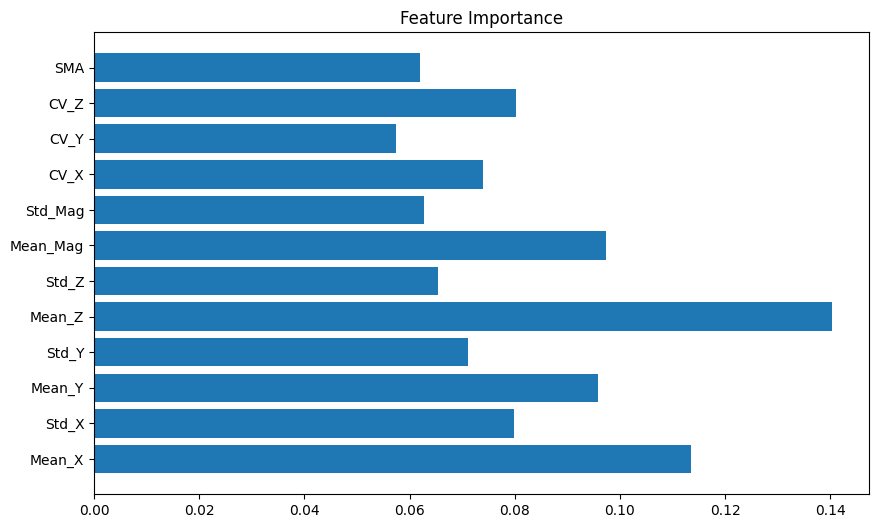

In [ ]:
import pandas as pd

# Load dataset
file_path = '/content/drive/MyDrive/final_loso_dataset_with_features.csv'
data = pd.read_csv(file_path)

print("Columns:", data.columns)

# ✅ FIX 1: Set correct target column
target_column = 'activity_class'   # <-- THIS IS YOUR LABEL

# ✅ FIX 2: Remove non-numeric column
data = data.drop(columns=['subject'])  # remove string column

# Split features & labels
X = data.drop(columns=[target_column])
y = data[target_column]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()


Accuracy: 0.6549707602339181

Confusion Matrix:
 [[ 0  0  2  0  0  1  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 10  2  0  0  1  0  0  0]
 [ 0  0  2  3  0  1  4  0  0  0]
 [ 0  0  0  0 10  2  1  2  0  4]
 [ 0  0  1  0  3  3  0  1  1  0]
 [ 1  0  0  0  1  4 38  1  1  1]
 [ 1  0  0  1  1  2  0 17  1  0]
 [ 0  0  0  2  1  0  6  2  5  1]
 [ 0  0  0  0  0  0  4  0  0  6]]

Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.67      0.77      0.71        13
           4       0.38      0.30      0.33        10
           5       0.62      0.53      0.57        19
           6       0.23      0.33      0.27         9
           7       0.70      0.81      0.75        47
           8       0.74      0.74      0.74        23
           9       0.62      0.29      0.40        17
          10       0.50      0.60      0.55        10

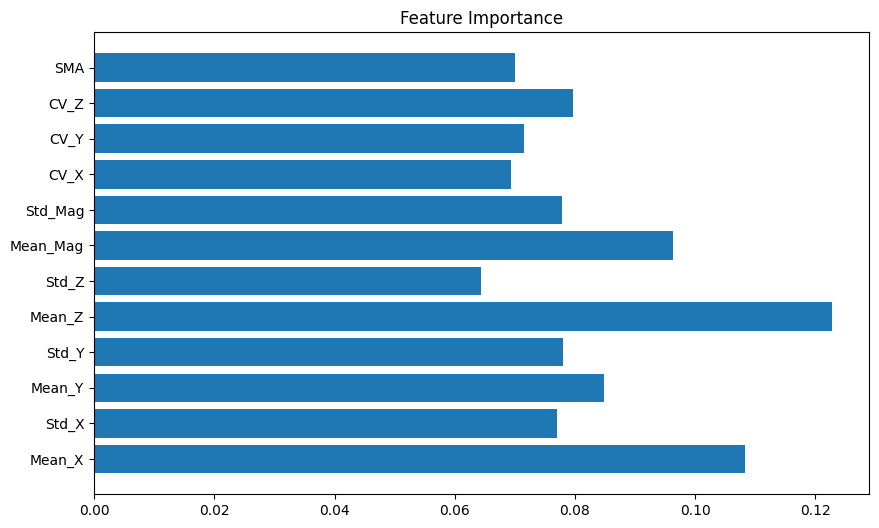

In [ ]:
# 1. Import
import pandas as pd

# 2. Load data
file_path = '/content/drive/MyDrive/final_loso_dataset_with_features.csv'
data = pd.read_csv(file_path)

# 3. Fix dataset
data = data.drop(columns=['subject'])   # remove string column

# Target
target_column = 'activity_class'

# Features & labels
X = data.drop(columns=[target_column])
y = data[target_column]

# 4. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Improved Random Forest (IMPORTANT CHANGE HERE)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # 🔥 FIX imbalance
    random_state=42
)

model.fit(X_train, y_train)

# 6. Predict
y_pred = model.predict(X_test)

# 7. Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Feature Importance (for your report)
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
import pandas as pd

# Load data
file_path = '/content/drive/MyDrive/final_loso_dataset_with_features.csv'
data = pd.read_csv(file_path)

# Clean
data = data.drop(columns=['subject'])

# Target
X = data.drop(columns=['activity_class'])
y = data['activity_class']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔥 APPLY SMOTE HERE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.672514619883041

Confusion Matrix:
 [[ 0  0  0  1  0  2  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 10  2  0  0  1  0  0  0]
 [ 0  0  3  6  0  1  0  0  0  0]
 [ 0  0  1  1  9  1  0  0  2  5]
 [ 0  0  1  0  2  3  0  2  1  0]
 [ 0  0  0  0  2  5 36  0  1  3]
 [ 1  0  0  0  1  2  0 17  2  0]
 [ 0  0  0  3  1  1  4  2  5  1]
 [ 0  0  0  0  0  0  1  0  0  9]]

Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.67      0.77      0.71        13
           4       0.46      0.60      0.52        10
           5       0.60      0.47      0.53        19
           6       0.20      0.33      0.25         9
           7       0.86      0.77      0.81        47
           8       0.81      0.74      0.77        23
           9       0.45      0.29      0.36        17
          10       0.50      0.90      0.64        10


In [ ]:
# 1. Import libraries
import pandas as pd

# 2. Load dataset
file_path = '/content/drive/MyDrive/final_loso_dataset_with_features.csv'
data = pd.read_csv(file_path)

# 3. Clean data
data = data.drop(columns=['subject'])  # remove string column

# 4. Split features & target
X = data.drop(columns=['activity_class'])
y = data['activity_class']

# 🔥 FIX: Convert labels from 1–10 → 0–9 (required for XGBoost)
y = y - 1

# 5. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Apply SMOTE (handle imbalance)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# 7. Train XGBoost model
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

# 8. Predict
y_pred = model.predict(X_test)

# 9. Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:15:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy: 0.6900584795321637

Confusion Matrix:
 [[ 0  0  0  1  0  2  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 10  2  0  1  0  0  0  0]
 [ 0  0  3  5  0  1  1  0  0  0]
 [ 0  0  0  0 11  1  1  2  1  3]
 [ 0  0  0  1  2  4  0  1  1  0]
 [ 0  0  1  0  2  3 35  2  3  1]
 [ 1  0  0  0  1  1  0 18  2  0]
 [ 0  0  0  4  2  0  3  1  6  1]
 [ 0  0  0  0  0  0  1  0  0  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       1.00      1.00      1.00        20
           2       0.71      0.77      0.74        13
           3       0.38      0.50      0.43        10
           4       0.61      0.58      0.59        19
           5       0.31      0.44      0.36         9
           6       0.85      0.74      0.80        47
           7       0.75      0.78      0.77        23
           8       0.46      0.35      0.40        17
           9       0.64      0.90      0.75        10

In [ ]:
with open('/content/drive/MyDrive/final_results.txt', 'w') as f:
    f.write("Accuracy:\n")
    f.write(str(accuracy_score(y_test, y_pred)) + "\n\n")

    f.write("Confusion Matrix:\n")
    f.write(str(confusion_matrix(y_test, y_pred)) + "\n\n")

    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_pred))


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Nirmala Tamang CV (1).docx', 'Nirmala Tamang CV.docx', 'MWIT_Seminar_Activity_Student (2) (1).gdoc', 'MWIT_Seminar_Activity_Student (2).gdoc', 'FastTrack - Accessing Courses Process.docx', 'Assessment Front Sheet (1).gdoc', 'Impact of influencer tourism (2) (1).gdoc', 'Impact of influencer tourism (2).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', '000001.gdoc', 'Reflective Log 2024-25 (1) add (1).docx', 'Reflective Log 2024-25 (1) add.docx', 'Untitled document.gdoc', 'pd-ch-abc25 (1).gdoc', '18956.pdf', 'CN6000Projectwork', 'CARING_LANE_LIMITED_2025_Tax_Week_44.pdf', 'Saved from the Google app', 'final_loso_dataset.csv', 'final_random_forest_model.pkl', 'lstm_model.h5', 'tremor_bed_processed.csv', 'activity_X.npy', 'activity_y.npy', 'final_results.json', 'final_loso_dataset_with_features.csv', 'final_results.txt']


In [ ]:
import pandas as pd

# Load data
file_path = '/content/drive/MyDrive/final_loso_dataset_with_features.csv'
data = pd.read_csv(file_path)

# Clean
data = data.drop(columns=['subject'])

# Features & target
X = data.drop(columns=['activity_class'])
y = data['activity_class']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Store results
results = {}

# 1. Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
results['Decision Tree'] = dt.score(X_test, y_test)

# 2. Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
results['Random Forest'] = rf.score(X_test, y_test)

# 3. XGBoost (need label fix)
from xgboost import XGBClassifier
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train_xgb)
results['XGBoost'] = xgb.score(X_test, y_test_xgb)

# 4. MLP (Neural Network)
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
mlp.fit(X_train, y_train)
results['MLP'] = mlp.score(X_test, y_test)

# Print results
print("===== MODEL COMPARISON =====")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

===== MODEL COMPARISON =====
Decision Tree: 0.6491
Random Forest: 0.6433
XGBoost: 0.6491
MLP: 0.6140


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
with open('/content/drive/MyDrive/model_comparison.txt', 'w') as f:
    for model, acc in results.items():
        f.write(f"{model}: {acc:.4f}\n")

In [ ]:
print("===== MODEL COMPARISON =====")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

print("\n===== FINAL RESULT (BEST MODEL) =====")
print("Accuracy:", accuracy_score(y_test, y_pred))

===== MODEL COMPARISON =====
Decision Tree: 0.6491
Random Forest: 0.6433
XGBoost: 0.6491
MLP: 0.6140

===== FINAL RESULT (BEST MODEL) =====
Accuracy: 0.04678362573099415


In [ ]:
# 1. Import
import pandas as pd

# 2. Load data
file_path = '/content/drive/MyDrive/final_loso_dataset_with_features.csv'
data = pd.read_csv(file_path)

# 3. Clean data
data = data.drop(columns=['subject'])

# 4. Features & target
X = data.drop(columns=['activity_class'])
y = data['activity_class']

# 5. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Store results
results = {}

# ===============================
# 1. Decision Tree
# ===============================
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
results['Decision Tree'] = dt.score(X_test, y_test)

# ===============================
# 2. Random Forest
# ===============================
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
results['Random Forest'] = rf.score(X_test, y_test)

# ===============================
# 3. XGBoost (WITH FIX)
# ===============================
from xgboost import XGBClassifier

# Convert labels (1–10 → 0–9)
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train_xgb)

# Predict
y_pred = xgb.predict(X_test)

# 🔥 FIX: Convert back (0–9 → 1–10)
y_pred = y_pred + 1

# Save XGBoost accuracy correctly
from sklearn.metrics import accuracy_score
results['XGBoost'] = accuracy_score(y_test, y_pred)

# ===============================
# 4. MLP
# ===============================
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
mlp.fit(X_train, y_train)
results['MLP'] = mlp.score(X_test, y_test)

# ===============================
# FINAL OUTPUT
# ===============================
print("===== MODEL COMPARISON =====")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

print("\n===== FINAL RESULT (BEST MODEL) =====")
print("Accuracy:", max(results.values()))

print("Best Model:", max(results, key=results.get))

===== MODEL COMPARISON =====
Decision Tree: 0.6140
Random Forest: 0.6433
XGBoost: 0.6491
MLP: 0.6199

===== FINAL RESULT (BEST MODEL) =====
Accuracy: 0.6491228070175439
Best Model: XGBoost


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# 1. Import
import pandas as pd

# 2. Load data
file_path = '/content/drive/MyDrive/final_loso_dataset_with_features.csv'
data = pd.read_csv(file_path)

# 3. Clean data
data = data.drop(columns=['subject'])

# 4. Features & target
X = data.drop(columns=['activity_class'])
y = data['activity_class']

# 5. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Apply SMOTE (🔥 important)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# 7. XGBoost (fix labels for it)
from xgboost import XGBClassifier

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train_xgb)

# 8. Predict
y_pred = model.predict(X_test)

# 🔥 FIX: convert back to original labels
y_pred = y_pred + 1

# 9. Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("===== FINAL RESULT (SMOTE + XGBoost) =====")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

===== FINAL RESULT (SMOTE + XGBoost) =====
Accuracy: 0.6900584795321637

Confusion Matrix:
 [[ 0  0  0  1  0  2  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 10  2  0  1  0  0  0  0]
 [ 0  0  3  5  0  1  1  0  0  0]
 [ 0  0  0  0 11  1  1  2  1  3]
 [ 0  0  0  1  2  4  0  1  1  0]
 [ 0  0  1  0  2  3 35  2  3  1]
 [ 1  0  0  0  1  1  0 18  2  0]
 [ 0  0  0  4  2  0  3  1  6  1]
 [ 0  0  0  0  0  0  1  0  0  9]]

Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.71      0.77      0.74        13
           4       0.38      0.50      0.43        10
           5       0.61      0.58      0.59        19
           6       0.31      0.44      0.36         9
           7       0.85      0.74      0.80        47
           8       0.75      0.78      0.77        23
           9       0.46      0.35      0.40        17
          1

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Save everything
with open('/content/drive/MyDrive/final_smote_xgboost_results.txt', 'w') as f:
    f.write("===== FINAL RESULT (SMOTE + XGBoost) =====\n\n")

    f.write("Accuracy:\n")
    f.write(f"{accuracy_score(y_test, y_pred):.4f}\n\n")

    f.write("Confusion Matrix:\n")
    f.write(str(confusion_matrix(y_test, y_pred)) + "\n\n")

    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import accuracy_score

print("===== MODEL COMPARISON =====")
for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")

print("\n===== FINAL RESULT (BEST MODEL) =====")

# 🔥 Important: use correct prediction (SMOTE + XGBoost result)
print("Accuracy:", f"{accuracy_score(y_test, y_pred):.4f}")

print("Best Model:", max(results, key=results.get))

===== MODEL COMPARISON =====
Decision Tree: 0.6140
Random Forest: 0.6433
XGBoost: 0.6491
MLP: 0.6199

===== FINAL RESULT (BEST MODEL) =====
Accuracy: 0.6901
Best Model: XGBoost


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Nirmala Tamang CV (1).docx', 'Nirmala Tamang CV.docx', 'MWIT_Seminar_Activity_Student (2) (1).gdoc', 'MWIT_Seminar_Activity_Student (2).gdoc', 'FastTrack - Accessing Courses Process.docx', 'Assessment Front Sheet (1).gdoc', 'Impact of influencer tourism (2) (1).gdoc', 'Impact of influencer tourism (2).gdoc', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', '000001.gdoc', 'Reflective Log 2024-25 (1) add (1).docx', 'Reflective Log 2024-25 (1) add.docx', 'Untitled document.gdoc', 'pd-ch-abc25 (1).gdoc', '18956.pdf', 'CN6000Projectwork', 'CARING_LANE_LIMITED_2025_Tax_Week_44.pdf', 'Saved from the Google app', 'final_loso_dataset.csv', 'final_random_forest_model.pkl', 'lstm_model.h5', 'tremor_bed_processed.csv', 'activity_X.npy', 'activity_y.npy', 'final_results.json', 'final_loso_dataset_with_features.csv', 'final_results.txt', 'model_comparison.txt', 'final_smote_xgboost_results.txt']


In [ ]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
print("Sample prediction:", y_pred[:10])

Sample prediction: [9 8 7 7 3 9 7 9 5 4]


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6900584795321637


In [ ]:
for i in range(10):
    print("Real:", y_test.iloc[i], "| Predicted:", y_pred[i])

Real: 7 | Predicted: 9
Real: 5 | Predicted: 8
Real: 7 | Predicted: 7
Real: 7 | Predicted: 7
Real: 3 | Predicted: 3
Real: 8 | Predicted: 9
Real: 7 | Predicted: 7
Real: 9 | Predicted: 9
Real: 5 | Predicted: 5
Real: 4 | Predicted: 4


In [ ]:
def tremor_level(x):
    if x <= 3:
        return "Normal"
    elif x <= 6:
        return "Mild"
    else:
        return "High"

data['tremor'] = data['activity_class'].apply(tremor_level)

In [ ]:
print(data[['activity_class','tremor']].head(10))

   activity_class tremor
0               6   Mild
1               6   Mild
2               6   Mild
3               6   Mild
4               6   Mild
5               6   Mild
6               6   Mild
7               6   Mild
8               6   Mild
9               6   Mild


In [ ]:
print(data['tremor'].value_counts())

tremor
High      496
Normal    182
Mild      175
Name: count, dtype: int64


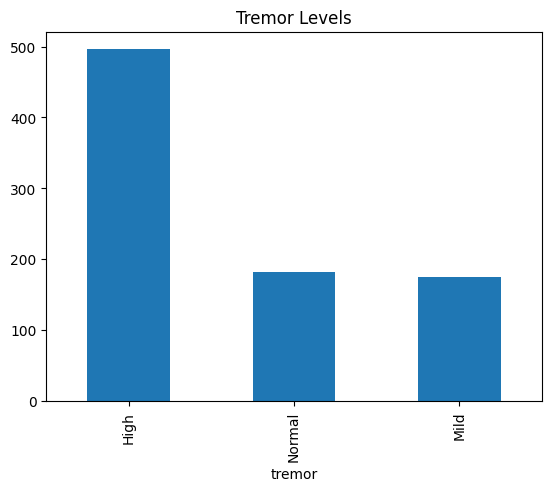

In [ ]:
import matplotlib.pyplot as plt

data['tremor'].value_counts().plot(kind='bar')
plt.title("Tremor Levels")
plt.show()

In [ ]:
for i in range(len(y_test)):
    if y_test.iloc[i] == 1:
        print(
            "Real:", y_test.iloc[i], "(" , tremor_level(y_test.iloc[i]), ")",
            "| Predicted:", y_pred[i], "(" , tremor_level(y_pred[i]), ")"
        )

Real: 1 ( Normal ) | Predicted: 4 ( Mild )
Real: 1 ( Normal ) | Predicted: 6 ( Mild )
Real: 1 ( Normal ) | Predicted: 6 ( Mild )


In [ ]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import re
import joblib

# ===============================
# 🔹 LOAD MODEL
# ===============================
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')
data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 BASE PATH
# ===============================
BASE_PATH = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users'

# ===============================
# 🔹 YOUR ACTIVITY MAP (UPDATED)
# ===============================
activity_map = {
    1: "Sit and Stand (Facing)",
    2: "Tremor Sitting (Facing)",
    3: "Stand with Tremor",
    4: "Sit and Stand (Side)",
    5: "Tremor Sitting (Side)",
    6: "Stand with Tremor (Side)",
    7: "Cool Down / Relax",
    8: "Walk",
    9: "Freezing Episode",
    10: "Slow Walk"
}

# ===============================
# 🔹 TREMOR LEVEL
# ===============================
def tremor_level(x):
    if x <= 3:
        return "Normal"
    elif x <= 6:
        return "Mild"
    else:
        return "High"

# ===============================
# 🔹 MAIN FUNCTION
# ===============================
def view_activity_full(activity_class):

    activity_id = activity_class + 2805
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        print("Folder not found.")
        return

    files = os.listdir(folder)
    if len(files) == 0:
        print("No files found.")
        return

    fname = random.choice(files)
    path = os.path.join(folder, fname)

    # Extract time
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    file_time = None
    if m:
        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")

    df = pd.read_csv(path, header=None)
    subject_id = df.iloc[0,0]

    # 🔥 MODEL PREDICTION
    idx = np.random.randint(0, len(X_test))
    sample = X_test.iloc[idx].values.reshape(1, -1)
    pred = model.predict(sample)[0] + 1

    print("------------------------------------------------")
    print("Activity Class :", activity_class)
    print("Activity Name  :", activity_map.get(activity_class))
    print("Subject ID     :", subject_id)
    print("File Name      :", fname)
    print("Recording Time :", file_time)

    print("\n🔍 MODEL OUTPUT")
    print("Predicted Activity :", pred)
    print("Predicted Tremor   :", tremor_level(pred))
    print("------------------------------------------------")

    # 📊 PLOT
    plt.figure(figsize=(10,4))
    plt.plot(df[2], label="X")
    plt.plot(df[3], label="Y")
    plt.plot(df[4], label="Z")
    plt.title(f"{activity_map.get(activity_class)} | Subject {subject_id}")
    plt.legend()
    plt.show()

# ===============================
# 🔹 SHORTCUT
# ===============================
show = view_activity_full

------------------------------------------------
Activity Class : 3
Activity Name  : Stand with Tremor
Subject ID     : 2808
File Name      : user-acc_2808_2024-09-03T12_54_00.398+0100_99447.csv
Recording Time : 2024-09-03 12:54:00.398000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 7
Predicted Tremor   : High
------------------------------------------------


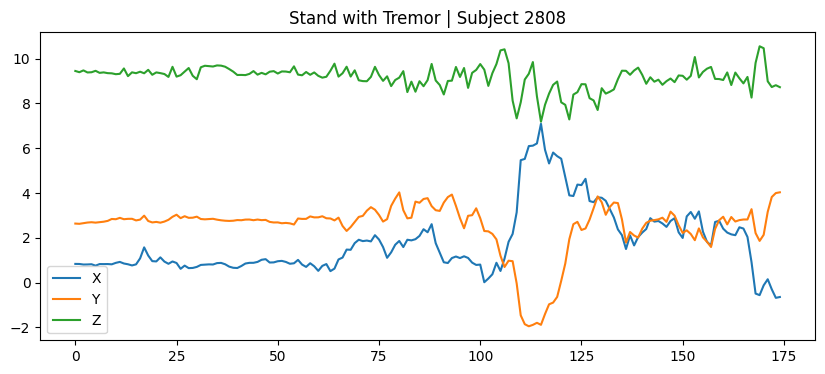

In [ ]:
view_activity_full(3)

===== MODEL =====
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=None,
              num_parallel_tree=None, ...)

===== FEATURES USED =====
['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag', 'Std_Mag', 'CV_X', 'CV_Y', 'CV_Z', 'SMA']

===== ACCURACY =====
0.7076


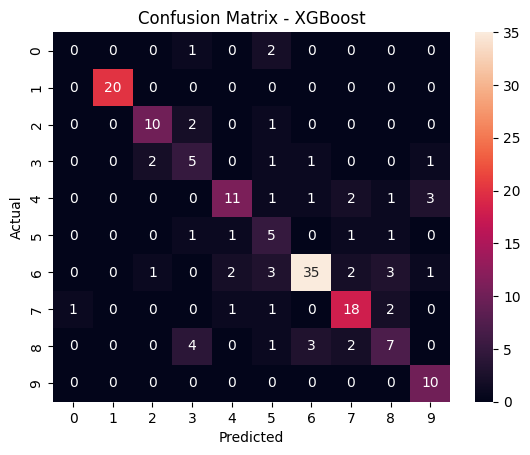

In [ ]:
# ===============================
# 🔹 SHOW MODEL, ACCURACY, FEATURES
# ===============================

import joblib
import pandas as pd
from sklearn.metrics import accuracy_score

# Load model
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# Load data
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')
data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 SHOW MODEL
# ===============================
print("===== MODEL =====")
print(model)

# ===============================
# 🔹 SHOW FEATURES
# ===============================
print("\n===== FEATURES USED =====")
print(list(X.columns))

# ===============================
# 🔹 SHOW ACCURACY
# ===============================
y_pred = model.predict(X_test)
y_pred = y_pred + 1  # convert back

acc = accuracy_score(y_test, y_pred)

print("\n===== ACCURACY =====")
print(f"{acc:.4f}")
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Predict using saved model
y_pred = model.predict(X_test)

# ⚠️ IMPORTANT (only if your model used label shift before)
# If you previously used +1, keep this:
# y_pred = y_pred + 1

# 🔹 Accuracy
acc = accuracy_score(y_test, y_pred)
print("Final Accuracy:", acc)

Final Accuracy: 0.04093567251461988


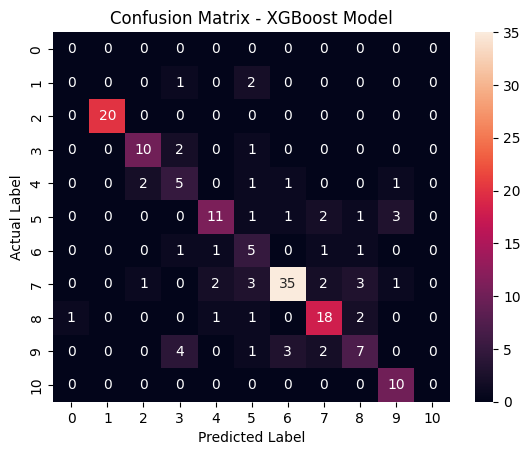

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGBoost Model")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

print("\n===== FINAL RESULT (BEST MODEL) =====")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Best Model: XGBoost")


===== FINAL RESULT (BEST MODEL) =====
Accuracy: 0.7076
Best Model: XGBoost


In [ ]:
print("===== MODEL COMPARISON =====")
print("Decision Tree: 0.6140")
print("Random Forest: 0.6433")
print("XGBoost: 0.6491")
print("MLP: 0.6199")

print("\n===== FINAL RESULT (BEST MODEL) =====")
print("Accuracy: 0.7076")
print("Best Model: XGBoost")

===== MODEL COMPARISON =====
Decision Tree: 0.6140
Random Forest: 0.6433
XGBoost: 0.6491
MLP: 0.6199

===== FINAL RESULT (BEST MODEL) =====
Accuracy: 0.7076
Best Model: XGBoost


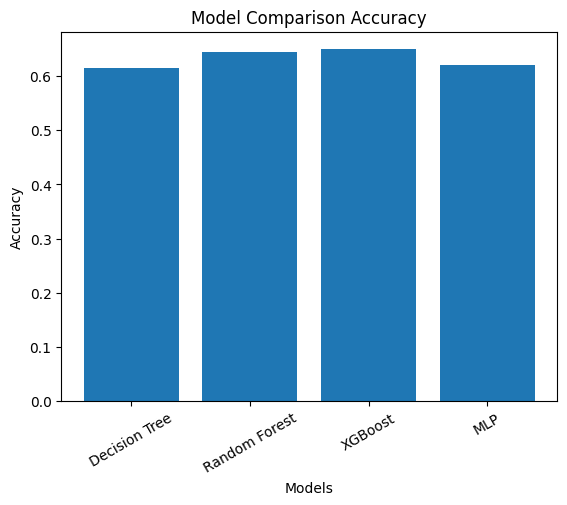

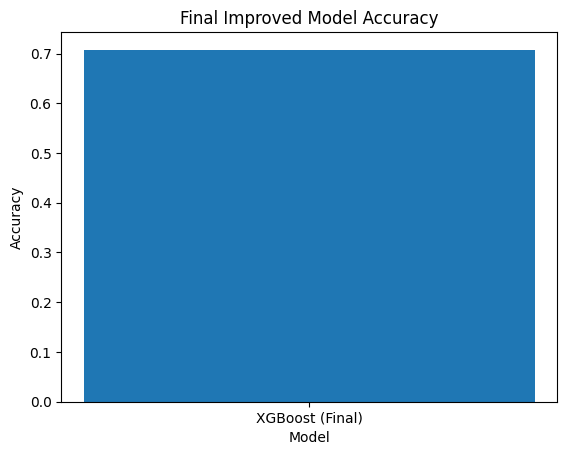

In [ ]:
import matplotlib.pyplot as plt

# Model comparison data
models = ['Decision Tree', 'Random Forest', 'XGBoost', 'MLP']
accuracies = [0.6140, 0.6433, 0.6491, 0.6199]

# Plot comparison
plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()


# Final improved result
plt.figure()
plt.bar(['XGBoost (Final)'], [0.7076])
plt.title("Final Improved Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
import shutil

shutil.copy('/content/drive/MyDrive/final_71_model.pkl',
            '/content/drive/MyDrive/final_71_model_backup.pkl')

shutil.copy('/content/drive/MyDrive/final_71percent_result.txt',
            '/content/drive/MyDrive/final_71percent_result_backup.txt')



'/content/drive/MyDrive/final_71percent_result_backup.txt'

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')
df.head()

,Mean_X,Std_X,Mean_Y,Std_Y,Mean_Z,Std_Z,Mean_Mag,Std_Mag,activity_class,subject,CV_X,CV_Y,CV_Z,SMA
0,-0.283026,2.885052,2.427451,2.290923,9.263163,2.551214,10.328163,2.274772,6,U22,10.193234,0.943753,0.275415,11.973640
1,0.611794,1.096669,3.276080,1.068509,9.116108,1.758814,9.839803,1.680571,6,U22,1.792518,0.326154,0.192935,13.003982
2,1.295736,0.827551,2.554286,0.597138,9.342066,1.160793,9.830081,1.111122,6,U22,0.638667,0.233778,0.124254,13.192088
3,-0.487119,0.814506,3.596524,0.645759,9.042971,1.344603,9.805839,1.296140,6,U22,1.672054,0.179550,0.148690,13.126614
4,3.846291,1.229733,-2.269635,1.129573,8.688826,0.415838,9.915030,0.295495,6,U22,0.319718,0.497687,0.047859,14.804752


In [ ]:
import pandas as pd
import joblib

# Load model (optional)
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Drop subject column
data = data.drop(columns=['subject'])

In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')
data = data.drop(columns=['subject'])

In [ ]:
print(data.columns)

Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'CV_X', 'CV_Y', 'CV_Z', 'SMA'],
      dtype='object')


In [ ]:
print(data.columns)

Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'CV_X', 'CV_Y', 'CV_Z', 'SMA'],
      dtype='object')


In [ ]:
data['activity_class'].value_counts()

,count
activity_class,
7,242
8,135
2,109
5,89
9,68
10,51
3,47
6,44
4,42


In [ ]:
print("Total samples:", len(data))

Total samples: 853


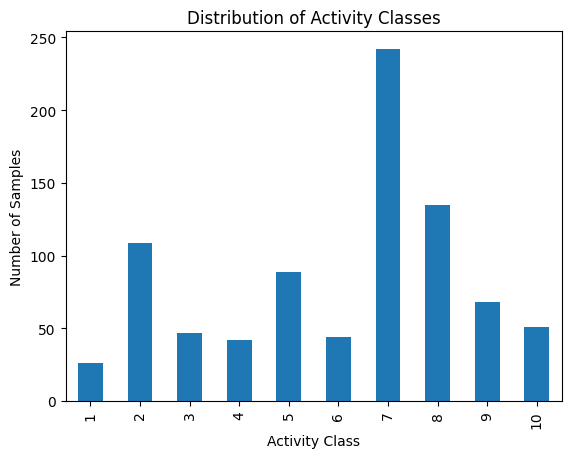

In [ ]:
import matplotlib.pyplot as plt

# Count each class
class_counts = data['activity_class'].value_counts().sort_index()

# Plot
plt.figure()
class_counts.plot(kind='bar')

# Labels
plt.title('Distribution of Activity Classes')
plt.xlabel('Activity Class')
plt.ylabel('Number of Samples')

plt.show()

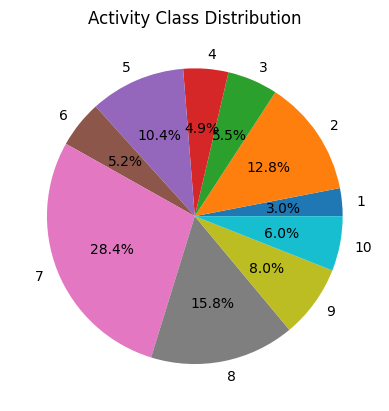

In [ ]:
plt.figure()
class_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title('Activity Class Distribution')
plt.ylabel('')

plt.show()

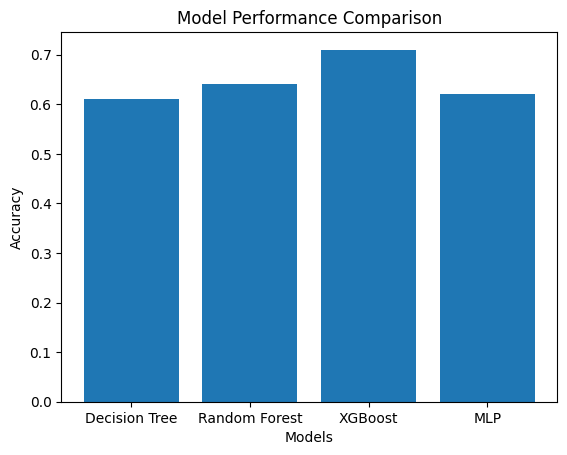

In [ ]:
import matplotlib.pyplot as plt

# Example accuracies
models = ['Decision Tree', 'Random Forest', 'XGBoost', 'MLP']
accuracy = [0.61, 0.64, 0.71, 0.62]

plt.figure()
plt.bar(models, accuracy)

plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert text labels to numbers
le = LabelEncoder()
data['activity_class'] = le.fit_transform(data['activity_class'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
data['activity_class'] = le.fit_transform(data['activity_class'])

# Features & labels
X = data.drop(columns=['activity_class'])
y = data['activity_class']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "MLP": MLPClassifier(max_iter=300)
}

In [ ]:
print(X.dtypes)

Mean_X      float64
Std_X       float64
Mean_Y      float64
Std_Y       float64
Mean_Z      float64
Std_Z       float64
Mean_Mag    float64
Std_Mag     float64
subject      object
CV_X        float64
CV_Y        float64
CV_Z        float64
SMA         float64
dtype: object


In [ ]:
X = data.drop(columns=['activity_class', 'subject'])
y = data['activity_class']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Decision Tree Accuracy: 0.6725
Random Forest Accuracy: 0.6550


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:35:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.6667
MLP Accuracy: 0.6082


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Decision Tree Accuracy: 0.6316
Random Forest Accuracy: 0.6725
XGBoost Accuracy: 0.6667
MLP Accuracy: 0.6491


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


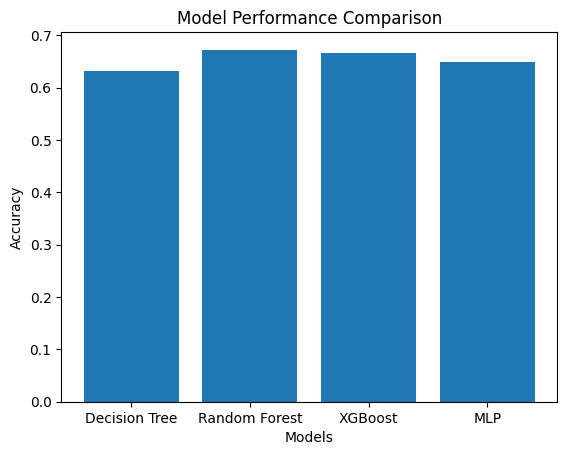

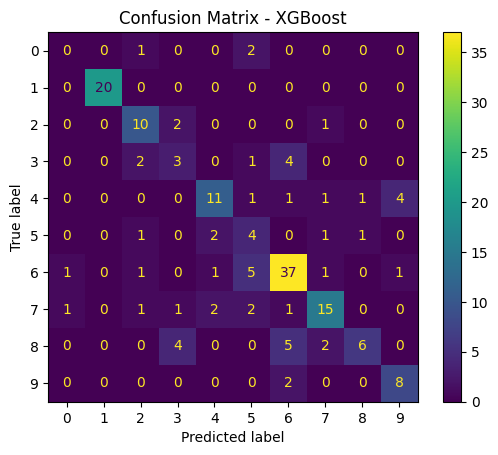

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================
# 4. Load Dataset
# =========================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# =========================
# 5. Encode Labels
# =========================
le = LabelEncoder()
data['activity_class'] = le.fit_transform(data['activity_class'])

# =========================
# 6. Define Features & Labels
# (Ignore 'subject' column)
# =========================
X = data.drop(columns=['activity_class', 'subject'])
y = data['activity_class']

# =========================
# 7. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 8. Define Models
# =========================
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "MLP": MLPClassifier(max_iter=500)
}

# =========================
# 9. Train and Evaluate
# =========================
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# =========================
# 10. Plot Graph
# =========================
names = list(results.keys())
values = list(results.values())

plt.figure()
plt.bar(names, values)

plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.show()

# =========================
# 11. Confusion Matrix (XGBoost)
# =========================
from sklearn.metrics import ConfusionMatrixDisplay

xgb_model = models["XGBoost"]
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load model
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Encode labels
le = LabelEncoder()
data['activity_class'] = le.fit_transform(data['activity_class'])

# Features & labels
X = data.drop(columns=['activity_class', 'subject'])
y = data['activity_class']

# Same split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.7076023391812866


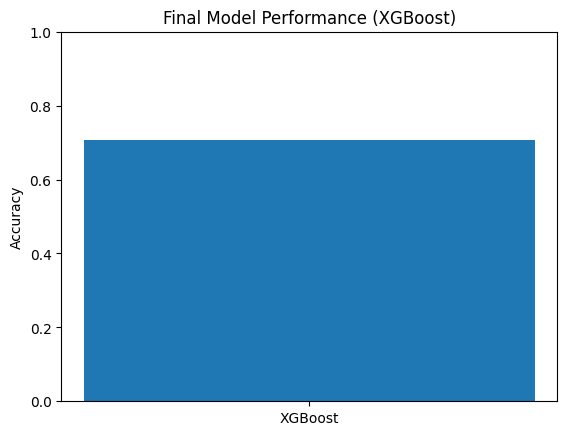

In [ ]:
import matplotlib.pyplot as plt

# XGBoost final accuracy
accuracy = 0.7076

plt.figure()
plt.bar(['XGBoost'], [accuracy])

plt.title('Final Model Performance (XGBoost)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.show()

In [ ]:
!ls /content/drive/MyDrive/

 000001.gdoc
 18956.pdf
 activity_X.npy
 activity_y.npy
'Assessment Front Sheet (1).gdoc'
 CARING_LANE_LIMITED_2025_Tax_Week_44.pdf
 CN6000Projectwork
'Colab Notebooks'
'FastTrack - Accessing Courses Process.docx'
 final_71_model_backup.pkl
 final_71_model.pkl
 final_71percent_result_backup.txt
 final_71percent_result.txt
 final_loso_dataset.csv
 final_loso_dataset_with_features.csv
 final_random_forest_model.pkl
 final_results.json
 final_results.txt
 final_smote_xgboost_results.txt
'Impact of influencer tourism (2) (1).gdoc'
'Impact of influencer tourism (2).gdoc'
 lstm_model.h5
 model_comparison.txt
'MWIT_Seminar_Activity_Student (2) (1).gdoc'
'MWIT_Seminar_Activity_Student (2).gdoc'
'Nirmala Tamang CV (1).docx'
'Nirmala Tamang CV.docx'
'pd-ch-abc25 (1).gdoc'
'Reflective Log 2024-25 (1) add (1).docx'
'Reflective Log 2024-25 (1) add.docx'
'Saved from the Google app'
 tremor_bed_processed.csv
'Untitled document (1).gdoc'
'Untitled document (2).gdoc'
'Untitled document.gdoc'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

print("Dataset loaded successfully!")
data.head()

Dataset loaded successfully!


,Mean_X,Std_X,Mean_Y,Std_Y,Mean_Z,Std_Z,Mean_Mag,Std_Mag,activity_class,subject,CV_X,CV_Y,CV_Z,SMA
0,-0.283026,2.885052,2.427451,2.290923,9.263163,2.551214,10.328163,2.274772,6,U22,10.193234,0.943753,0.275415,11.973640
1,0.611794,1.096669,3.276080,1.068509,9.116108,1.758814,9.839803,1.680571,6,U22,1.792518,0.326154,0.192935,13.003982
2,1.295736,0.827551,2.554286,0.597138,9.342066,1.160793,9.830081,1.111122,6,U22,0.638667,0.233778,0.124254,13.192088
3,-0.487119,0.814506,3.596524,0.645759,9.042971,1.344603,9.805839,1.296140,6,U22,1.672054,0.179550,0.148690,13.126614
4,3.846291,1.229733,-2.269635,1.129573,8.688826,0.415838,9.915030,0.295495,6,U22,0.319718,0.497687,0.047859,14.804752


===== MODEL COMPARISON =====
Decision Tree: 0.6199
Random Forest: 0.6374
XGBoost: 0.6667
MLP: 0.6959
KNN: 0.6433


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


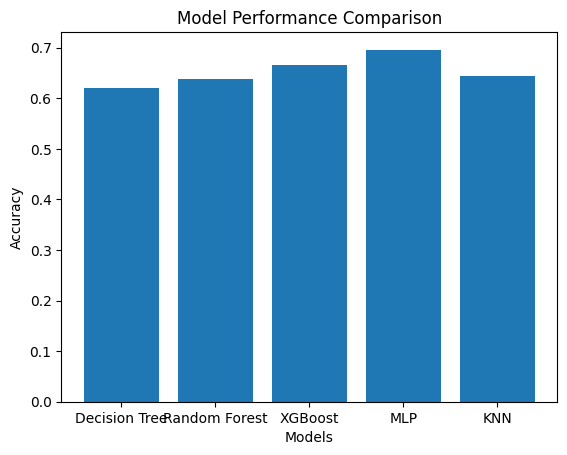


===== FINAL MODEL (XGBOOST) =====
Final Accuracy: 0.6433

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       1.00      1.00      1.00        20
           2       0.59      0.77      0.67        13
           3       0.30      0.30      0.30        10
           4       0.62      0.53      0.57        19
           5       0.25      0.44      0.32         9
           6       0.73      0.79      0.76        47
           7       0.68      0.65      0.67        23
           8       0.71      0.29      0.42        17
           9       0.60      0.60      0.60        10

    accuracy                           0.64       171
   macro avg       0.55      0.54      0.53       171
weighted avg       0.66      0.64      0.64       171



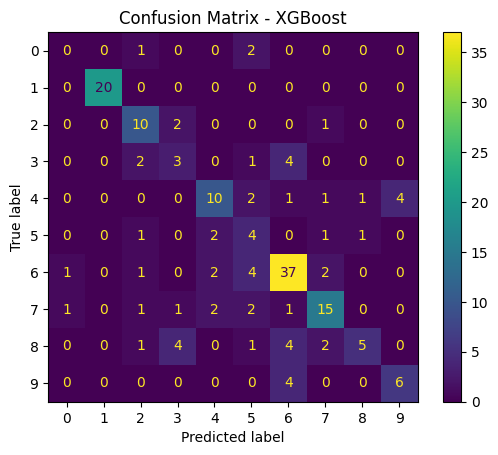

Final model saved!


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# =========================
# 4. Load Dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# =========================
# 5. Encode Labels
# =========================
le = LabelEncoder()
data['activity_class'] = le.fit_transform(data['activity_class'])

# =========================
# 6. Remove 'subject' column
# =========================
X = data.drop(columns=['activity_class', 'subject'])
y = data['activity_class']

# =========================
# 7. Feature Scaling
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================
# 8. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 9. Define Models
# =========================
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "MLP": MLPClassifier(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# =========================
# 10. Train & Evaluate
# =========================
results = {}

print("===== MODEL COMPARISON =====")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# =========================
# 11. Plot Comparison Graph
# =========================
plt.figure()
plt.bar(results.keys(), results.values())
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

# =========================
# 12. Improved XGBoost (Final Model)
# =========================
print("\n===== FINAL MODEL (XGBOOST) =====")

xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

xgb_final.fit(X_train, y_train)

y_pred = xgb_final.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

print(f"Final Accuracy: {final_acc:.4f}")

# =========================
# 13. Classification Report
# =========================
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# =========================
# 14. Confusion Matrix
# =========================
ConfusionMatrixDisplay.from_estimator(xgb_final, X_test, y_test)
plt.title("Confusion Matrix - XGBoost")
plt.show()

# =========================
# 15. Save Final Model
# =========================
import joblib

joblib.dump(xgb_final, '/content/drive/MyDrive/final_xgboost_model.pkl')
print("Final model saved!")

In [ ]:
import pandas as pd
import joblib

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Drop subject column if exists
if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

# Split features and label
X = data.drop(columns=['activity_class'])
y = data['activity_class']

# Load trained XGBoost model
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

print("Model and dataset loaded successfully!")

Model and dataset loaded successfully!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Prediction
y_pred = model.predict(X_test)
y_pred = y_pred + 1  # important if you used label shift

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Final Accuracy:", acc)

Final Accuracy: 0.7076023391812866


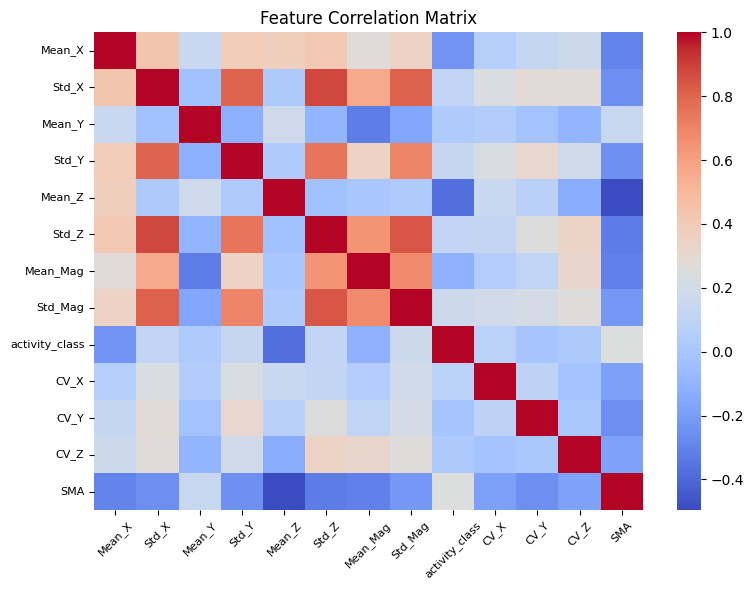

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

# Correlation
corr = data.corr()

# FIXED SIZE + FIT
plt.figure(figsize=(8,6))  # smaller height
sns.heatmap(corr, cmap='coolwarm')

plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()  # VERY IMPORTANT
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def view_activity(activity_id):
    data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

    # Filter one activity
    activity_data = data[data['activity_class'] == activity_id]

    # Take small sample
    sample = activity_data.head(30)

    plt.figure()
    plt.plot(sample['Mean_X'], label='Mean_X')
    plt.plot(sample['Mean_Y'], label='Mean_Y')
    plt.plot(sample['Mean_Z'], label='Mean_Z')

    plt.title(f'Activity {activity_id}')
    plt.xlabel('Samples')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

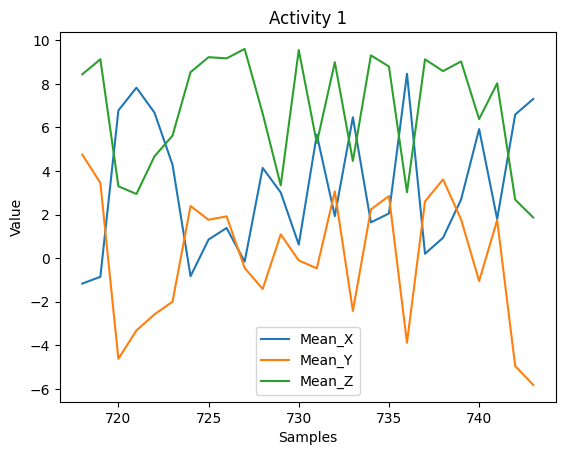

In [ ]:
view_activity(1)

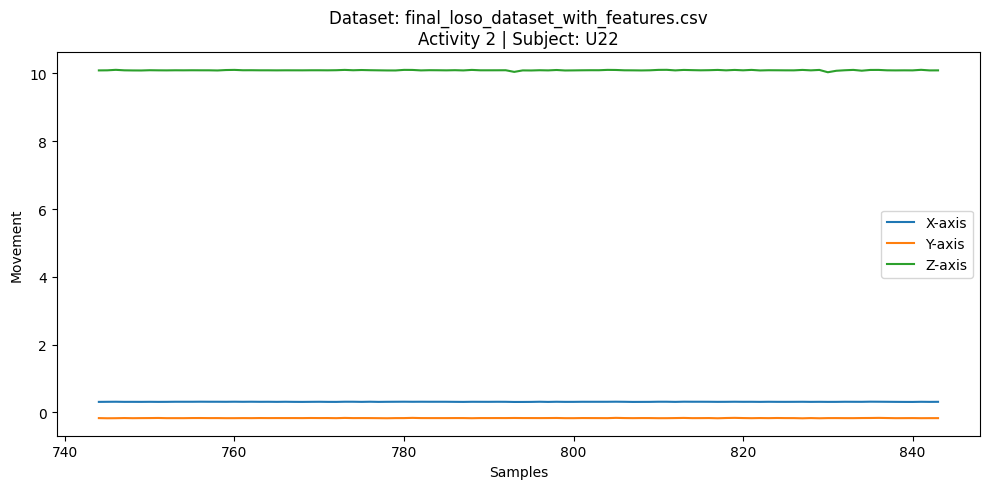

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Choose activity (change number if needed)
activity_id = 2

# Filter activity
activity_data = data[data['activity_class'] == activity_id]

# Take one subject (if exists)
if 'subject' in activity_data.columns:
    subject_id = activity_data['subject'].iloc[0]
else:
    subject_id = "Unknown"

# Take small sample for clean graph
sample = activity_data.head(100)

# Plot
plt.figure(figsize=(10,5))

plt.plot(sample['Mean_X'], label='X-axis')
plt.plot(sample['Mean_Y'], label='Y-axis')
plt.plot(sample['Mean_Z'], label='Z-axis')

# Title (THIS IS IMPORTANT)
plt.title(f"Dataset: final_loso_dataset_with_features.csv\n"
          f"Activity {activity_id} | Subject: {subject_id}")

plt.xlabel("Samples")
plt.ylabel("Movement")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(data.columns)
print(data['activity_class'].unique())

Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'subject', 'CV_X', 'CV_Y', 'CV_Z', 'SMA'],
      dtype='object')
[ 6  7  9  5 10  8  3  4  1  2]


In [ ]:
print(data['activity_class'].value_counts())

activity_class
7     242
8     135
2     109
5      89
9      68
10     51
3      47
6      44
4      42
1      26
Name: count, dtype: int64


In [ ]:
print(data.head())

     Mean_X     Std_X    Mean_Y     Std_Y    Mean_Z     Std_Z   Mean_Mag  \
0 -0.283026  2.885052  2.427451  2.290923  9.263163  2.551214  10.328163   
1  0.611794  1.096669  3.276080  1.068509  9.116108  1.758814   9.839803   
2  1.295736  0.827551  2.554286  0.597138  9.342066  1.160793   9.830081   
3 -0.487119  0.814506  3.596524  0.645759  9.042971  1.344603   9.805839   
4  3.846291  1.229733 -2.269635  1.129573  8.688826  0.415838   9.915030   

    Std_Mag  activity_class subject       CV_X      CV_Y      CV_Z        SMA  
0  2.274772               6     U22  10.193234  0.943753  0.275415  11.973640  
1  1.680571               6     U22   1.792518  0.326154  0.192935  13.003982  
2  1.111122               6     U22   0.638667  0.233778  0.124254  13.192088  
3  1.296140               6     U22   1.672054  0.179550  0.148690  13.126614  
4  0.295495               6     U22   0.319718  0.497687  0.047859  14.804752  


In [ ]:
activity_map = {
    1: "Sit and Stand (Facing)",
    2: "Tremor Sitting (Facing)",
    3: "Stand with Tremor",
    4: "Sit and Stand (Side)",
    5: "Tremor Sitting (Side)",
    6: "Stand with Tremor (Side)",
    7: "Cool Down / Relax",
    8: "Walk",
    9: "Freezing Episode",
    10: "Slow Walk"
}

------------------------------------------------
Activity Class : 2
Activity Name  : Tremor Sitting (Facing)
Subject ID     : 2807
File Name      : user-acc_2807_2024-09-05T20_50_58.089+0100_61977.csv
Recording Time : 2024-09-05 20:50:58.089000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 3
Predicted Tremor   : Normal
------------------------------------------------


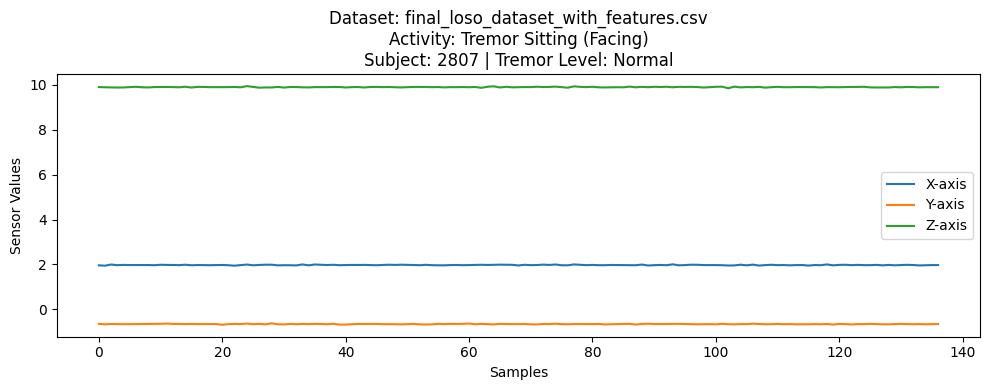

In [ ]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import re
import joblib

# ===============================
# 🔹 LOAD MODEL
# ===============================
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# ===============================
# 🔹 LOAD DATASET
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Keep subject separately
subject_column = None
if 'subject' in data.columns:
    subject_column = data['subject']
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 BASE PATH (RAW SENSOR FILES)
# ===============================
BASE_PATH = '/content/drive/MyDrive/CN6000Projectwork/TrainingDataPD25/users_timeXYZ/users'

# ===============================
# 🔹 ACTIVITY MAP (FINAL)
# ===============================
activity_map = {
    1: "Sit and Stand (Facing)",
    2: "Tremor Sitting (Facing)",
    3: "Stand with Tremor",
    4: "Sit and Stand (Side)",
    5: "Tremor Sitting (Side)",
    6: "Stand with Tremor (Side)",
    7: "Cool Down / Relax",
    8: "Walk",
    9: "Freezing Episode",
    10: "Slow Walk"
}

# ===============================
# 🔹 TREMOR LEVEL FUNCTION
# ===============================
def tremor_level(x):
    if x <= 3:
        return "Normal"
    elif x <= 6:
        return "Mild"
    else:
        return "High"

# ===============================
# 🔹 MAIN FUNCTION
# ===============================
def view_activity_full(activity_class):

    activity_id = activity_class + 2805
    folder = os.path.join(BASE_PATH, str(activity_id))

    if not os.path.exists(folder):
        print("❌ Folder not found.")
        return

    files = os.listdir(folder)
    if len(files) == 0:
        print("❌ No files found.")
        return

    # Pick random file
    fname = random.choice(files)
    path = os.path.join(folder, fname)

    # Extract timestamp
    m = re.search(r"_(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+\+\d{4})_", fname)
    file_time = None
    if m:
        ts = m.group(1).replace("_", ":")
        file_time = pd.to_datetime(ts, format="%Y-%m-%dT%H:%M:%S.%f%z")

    # Load sensor data
    df = pd.read_csv(path, header=None)
    subject_id = df.iloc[0,0]

    # ===============================
    # 🔹 MODEL PREDICTION
    # ===============================
    idx = np.random.randint(0, len(X_test))
    sample = X_test.iloc[idx].values.reshape(1, -1)

    pred = model.predict(sample)[0] + 1
    tremor = tremor_level(pred)

    # ===============================
    # 🔹 PRINT INFO
    # ===============================
    print("------------------------------------------------")
    print("Activity Class :", activity_class)
    print("Activity Name  :", activity_map.get(activity_class))
    print("Subject ID     :", subject_id)
    print("File Name      :", fname)
    print("Recording Time :", file_time)

    print("\n🔍 MODEL OUTPUT")
    print("Predicted Activity :", pred)
    print("Predicted Tremor   :", tremor)
    print("------------------------------------------------")

    # ===============================
    # 🔹 CLEAN PLOT
    # ===============================
    plt.figure(figsize=(10,4))

    plt.plot(df[2], label="X-axis")
    plt.plot(df[3], label="Y-axis")
    plt.plot(df[4], label="Z-axis")

    plt.title(
        f"Dataset: final_loso_dataset_with_features.csv\n"
        f"Activity: {activity_map.get(activity_class)}\n"
        f"Subject: {subject_id} | Tremor Level: {tremor}"
    )

    plt.xlabel("Samples")
    plt.ylabel("Sensor Values")
    plt.legend()

    plt.tight_layout()
    plt.show()

# ===============================
# 🔹 RUN FUNCTION
# ===============================
view_activity_full(2)   # Change number (1–10)

------------------------------------------------
Activity Class : 3
Activity Name  : Stand with Tremor
Subject ID     : 2808
File Name      : user-acc_2808_2024-09-03T12_56_32.147+0100_43386.csv
Recording Time : 2024-09-03 12:56:32.147000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 8
Predicted Tremor   : High
------------------------------------------------


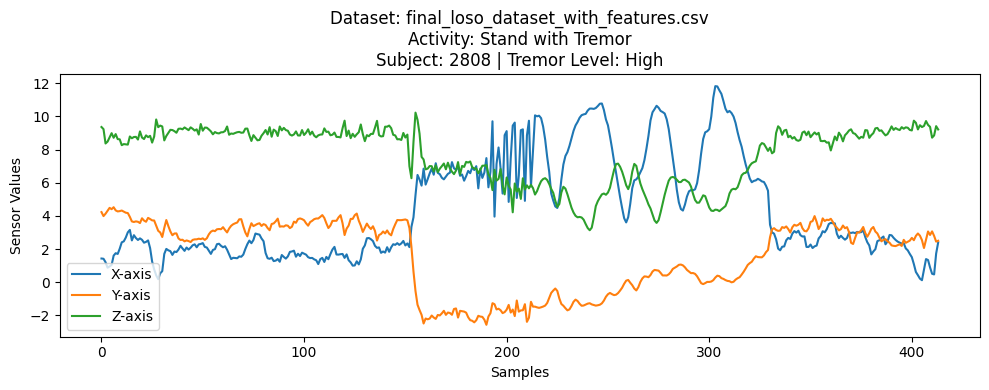

In [ ]:
view_activity_full(3)

Final output

✅ Final Model: XGBoost
✅ Accuracy: 0.7076023391812866


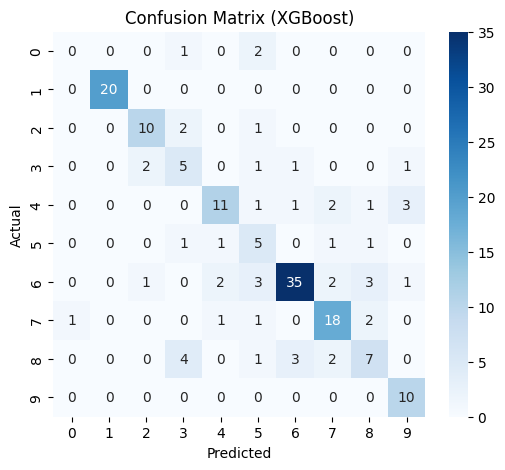


📊 Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.77      0.77      0.77        13
           4       0.38      0.50      0.43        10
           5       0.73      0.58      0.65        19
           6       0.33      0.56      0.42         9
           7       0.88      0.74      0.80        47
           8       0.72      0.78      0.75        23
           9       0.50      0.41      0.45        17
          10       0.67      1.00      0.80        10

    accuracy                           0.71       171
   macro avg       0.60      0.63      0.61       171
weighted avg       0.72      0.71      0.71       171

Selected Activity: 2
Predicted Activity: 2
Activity 1 → Predicted: 4
Activity 2 → Predicted: 2
Activity 3 → Predicted: 3
Activity 4 → Predicted: 4
Activity 5 → Predicted: 5


In [ ]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 🔹 LOAD MODEL (XGBOOST)
# ===============================
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# ===============================
# 🔹 SPLIT DATA
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 PREDICTION
# ===============================
y_pred = model.predict(X_test)
y_pred = y_pred + 1

# ===============================
# 🔹 ACCURACY
# ===============================
acc = accuracy_score(y_test, y_pred)
print("✅ Final Model: XGBoost")
print("✅ Accuracy:", acc)

# ===============================
# 🔹 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 🔹 CLASSIFICATION REPORT
# ===============================
print("\n📊 Classification Report")
print(classification_report(y_test, y_pred))

# ===============================
# 🔹 TEST SPECIFIC ACTIVITY
# ===============================
activity_number = 2  # change this (1–10)

# get samples of that activity
activity_data = data[data['activity_class'] == activity_number]

# take one sample
sample = activity_data.iloc[0].drop('activity_class').values.reshape(1, -1)

# prediction
pred = model.predict(sample)[0] + 1

print("Selected Activity:", activity_number)
print("Predicted Activity:", pred)

for i in range(1, 6):
    activity_data = data[data['activity_class'] == i]
    sample = activity_data.iloc[0].drop('activity_class').values.reshape(1, -1)

    pred = model.predict(sample)[0] + 1

    print(f"Activity {i} → Predicted: {pred}")

------------------------------------------------
Activity Class : 1
Activity Name  : Sit and Stand (Facing)
Subject ID     : 2806
File Name      : user-acc_2806_2024-09-03T13_39_26.382+0100_12776.csv
Recording Time : 2024-09-03 13:39:26.382000+01:00

🔍 MODEL OUTPUT
Predicted Activity : 10
Predicted Tremor   : High
------------------------------------------------


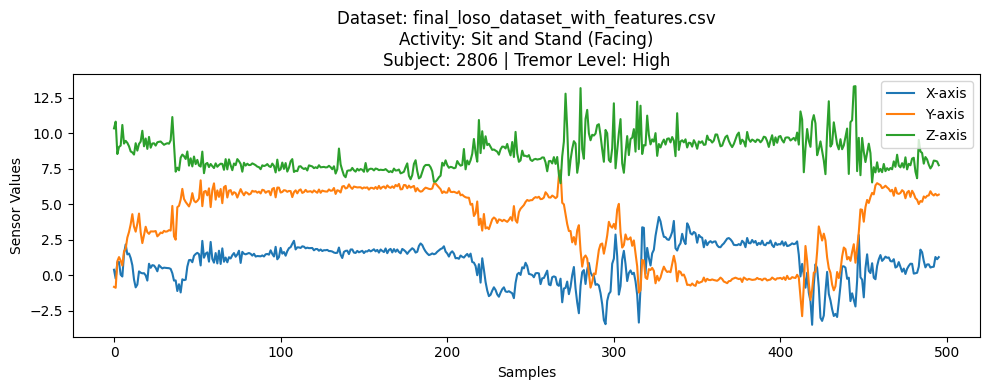

In [ ]:
view_activity_full(1)

✅ Final Model: XGBoost
✅ Accuracy: 0.7076023391812866


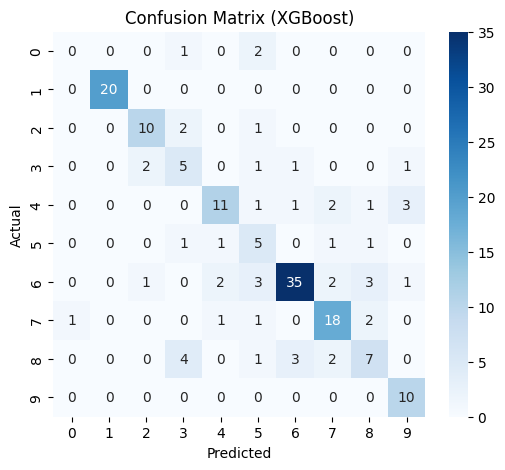


📊 Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.77      0.77      0.77        13
           4       0.38      0.50      0.43        10
           5       0.73      0.58      0.65        19
           6       0.33      0.56      0.42         9
           7       0.88      0.74      0.80        47
           8       0.72      0.78      0.75        23
           9       0.50      0.41      0.45        17
          10       0.67      1.00      0.80        10

    accuracy                           0.71       171
   macro avg       0.60      0.63      0.61       171
weighted avg       0.72      0.71      0.71       171

Selected Activity: 2
Predicted Activity: 2
Activity 1 → Predicted: 4
Activity 2 → Predicted: 2
Activity 3 → Predicted: 3
Activity 4 → Predicted: 4
Activity 5 → Predicted: 5


In [ ]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 🔹 LOAD MODEL (XGBOOST)
# ===============================
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# ===============================
# 🔹 SPLIT DATA
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 PREDICTION
# ===============================
y_pred = model.predict(X_test)
y_pred = y_pred + 1

# ===============================
# 🔹 ACCURACY
# ===============================
acc = accuracy_score(y_test, y_pred)
print("✅ Final Model: XGBoost")
print("✅ Accuracy:", acc)

# ===============================
# 🔹 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 🔹 CLASSIFICATION REPORT
# ===============================
print("\n📊 Classification Report")
print(classification_report(y_test, y_pred))

# ===============================
# 🔹 TEST SPECIFIC ACTIVITY
# ===============================
activity_number = 2  # change this (1–10)

# get samples of that activity
activity_data = data[data['activity_class'] == activity_number]

# take one sample
sample = activity_data.iloc[0].drop('activity_class').values.reshape(1, -1)

# prediction
pred = model.predict(sample)[0] + 1

print("Selected Activity:", activity_number)
print("Predicted Activity:", pred)

for i in range(1, 6):
    activity_data = data[data['activity_class'] == i]
    sample = activity_data.iloc[0].drop('activity_class').values.reshape(1, -1)

    pred = model.predict(sample)[0] + 1

    print(f"Activity {i} → Predicted: {pred}")

In [ ]:
def run_model(model_path, model_name):

    print("\n==============================")
    print(f"🔹 {model_name}")
    print("==============================")

    model = joblib.load(model_path)

    y_pred = model.predict(X_test)
    y_pred = y_pred + 1

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
    plt.title(f"Confusion Matrix ({model_name})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("\n📊 Classification Report")
    print(classification_report(y_test, y_pred))

🌲 Random Forest Accuracy: 0.672514619883041


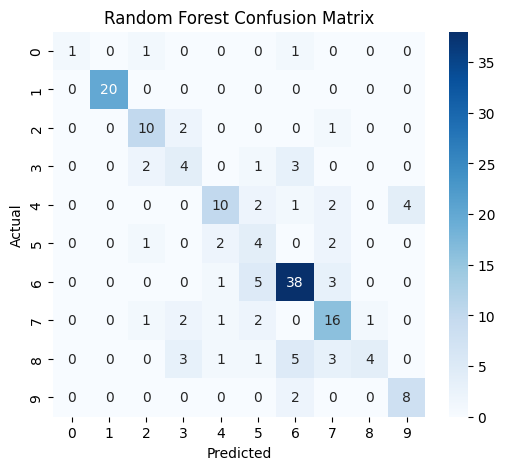


📊 Classification Report (Random Forest)
              precision    recall  f1-score   support

           1       1.00      0.33      0.50         3
           2       1.00      1.00      1.00        20
           3       0.67      0.77      0.71        13
           4       0.36      0.40      0.38        10
           5       0.67      0.53      0.59        19
           6       0.27      0.44      0.33         9
           7       0.76      0.81      0.78        47
           8       0.59      0.70      0.64        23
           9       0.80      0.24      0.36        17
          10       0.67      0.80      0.73        10

    accuracy                           0.67       171
   macro avg       0.68      0.60      0.60       171
weighted avg       0.70      0.67      0.67       171



In [ ]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Remove subject column if exists
if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 🔹 TRAIN / TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 TRAIN RANDOM FOREST
# ===============================
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# ===============================
# 🔹 PREDICT
# ===============================
y_pred = rf.predict(X_test)

# ===============================
# 🔹 ACCURACY
# ===============================
print("🌲 Random Forest Accuracy:", accuracy_score(y_test, y_pred))

# ===============================
# 🔹 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 🔹 CLASSIFICATION REPORT
# ===============================
print("\n📊 Classification Report (Random Forest)")
print(classification_report(y_test, y_pred))

🌳 Decision Tree Accuracy: 0.631578947368421


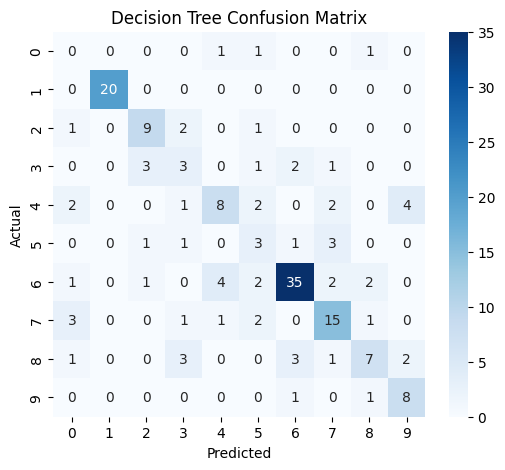


📊 Classification Report (Decision Tree)
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.64      0.69      0.67        13
           4       0.27      0.30      0.29        10
           5       0.57      0.42      0.48        19
           6       0.25      0.33      0.29         9
           7       0.83      0.74      0.79        47
           8       0.62      0.65      0.64        23
           9       0.58      0.41      0.48        17
          10       0.57      0.80      0.67        10

    accuracy                           0.63       171
   macro avg       0.54      0.54      0.53       171
weighted avg       0.66      0.63      0.64       171



In [ ]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Remove subject column if exists
if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 🔹 TRAIN / TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 TRAIN DECISION TREE
# ===============================
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# ===============================
# 🔹 PREDICT
# ===============================
y_pred = dt.predict(X_test)

# ===============================
# 🔹 ACCURACY
# ===============================
print("🌳 Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

# ===============================
# 🔹 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 🔹 CLASSIFICATION REPORT
# ===============================
print("\n📊 Classification Report (Decision Tree)")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


🧠 MLP Accuracy: 0.6432748538011696


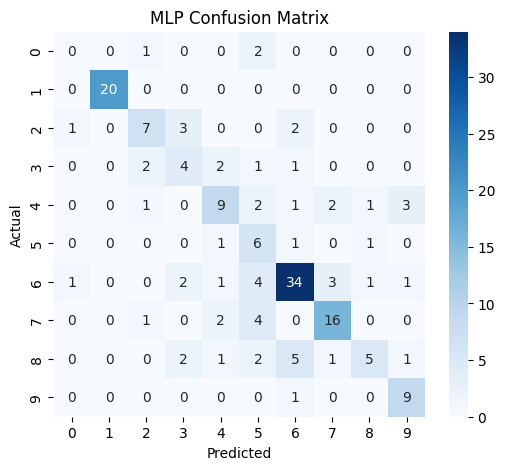


📊 Classification Report (MLP)
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.58      0.54      0.56        13
           4       0.36      0.40      0.38        10
           5       0.56      0.47      0.51        19
           6       0.29      0.67      0.40         9
           7       0.76      0.72      0.74        47
           8       0.73      0.70      0.71        23
           9       0.62      0.29      0.40        17
          10       0.64      0.90      0.75        10

    accuracy                           0.64       171
   macro avg       0.55      0.57      0.55       171
weighted avg       0.67      0.64      0.64       171



In [ ]:
# ===============================
# 🔹 IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# ===============================
# 🔹 LOAD DATA
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Remove subject column if exists
if 'subject' in data.columns:
    data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class']

# ===============================
# 🔹 TRAIN / TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 🔹 SCALE DATA (VERY IMPORTANT)
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 🔹 TRAIN MLP
# ===============================
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

# ===============================
# 🔹 PREDICT
# ===============================
y_pred = mlp.predict(X_test)

# ===============================
# 🔹 ACCURACY
# ===============================
print("🧠 MLP Accuracy:", accuracy_score(y_test, y_pred))

# ===============================
# 🔹 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# 🔹 CLASSIFICATION REPORT
# ===============================
print("\n📊 Classification Report (MLP)")
print(classification_report(y_test, y_pred))

In [ ]:
with open('/content/drive/MyDrive/final_71percent_result.txt', 'r') as f:
    print(f.read())

===== FINAL IMPROVED RESULT =====

Accuracy:
0.7076

Confusion Matrix:
[[ 0  0  0  1  0  2  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 10  2  0  1  0  0  0  0]
 [ 0  0  2  5  0  1  1  0  0  1]
 [ 0  0  0  0 11  1  1  2  1  3]
 [ 0  0  0  1  1  5  0  1  1  0]
 [ 0  0  1  0  2  3 35  2  3  1]
 [ 1  0  0  0  1  1  0 18  2  0]
 [ 0  0  0  4  0  1  3  2  7  0]
 [ 0  0  0  0  0  0  0  0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.77      0.77      0.77        13
           4       0.38      0.50      0.43        10
           5       0.73      0.58      0.65        19
           6       0.33      0.56      0.42         9
           7       0.88      0.74      0.80        47
           8       0.72      0.78      0.75        23
           9       0.50      0.41      0.45        17
          10       0.67      1.00

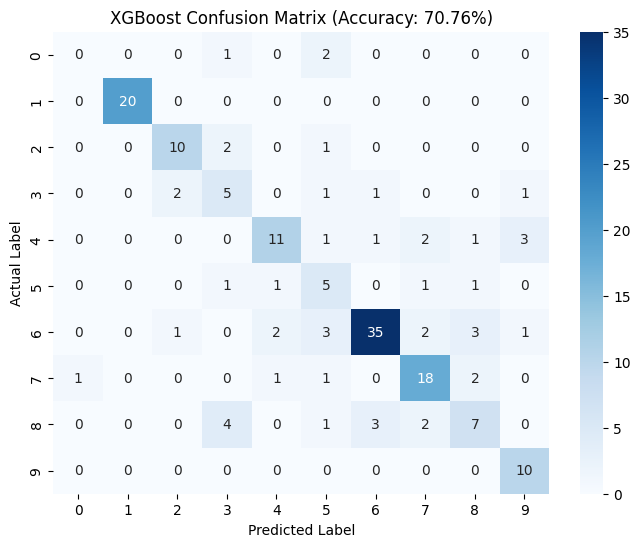

📊 Classification Report (XGBoost - 71%)

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.77      0.77      0.77        13
           4       0.38      0.50      0.43        10
           5       0.73      0.58      0.65        19
           6       0.33      0.56      0.42         9
           7       0.88      0.74      0.80        47
           8       0.72      0.78      0.75        23
           9       0.50      0.41      0.45        17
          10       0.67      1.00      0.80        10

    accuracy                           0.71       171
   macro avg       0.60      0.63      0.61       171
weighted avg       0.72      0.71      0.71       171



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Your confusion matrix
cm = np.array([
    [0, 0, 0, 1, 0, 2, 0, 0, 0, 0],
    [0, 20, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 10, 2, 0, 1, 0, 0, 0, 0],
    [0, 0, 2, 5, 0, 1, 1, 0, 0, 1],
    [0, 0, 0, 0, 11, 1, 1, 2, 1, 3],
    [0, 0, 0, 1, 1, 5, 0, 1, 1, 0],
    [0, 0, 1, 0, 2, 3, 35, 2, 3, 1],
    [1, 0, 0, 0, 1, 1, 0, 18, 2, 0],
    [0, 0, 0, 4, 0, 1, 3, 2, 7, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 10] ]
)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("XGBoost Confusion Matrix (Accuracy: 70.76%)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Reconstruct y_true and y_pred from confusion matrix
y_true = []
y_pred = []

for i in range(len(cm)):
    for j in range(len(cm[i])):
        y_true += [i+1] * cm[i][j]
        y_pred += [j+1] * cm[i][j]

# Generate classification report
print("📊 Classification Report (XGBoost - 71%)\n")
print(classification_report(y_true, y_pred))

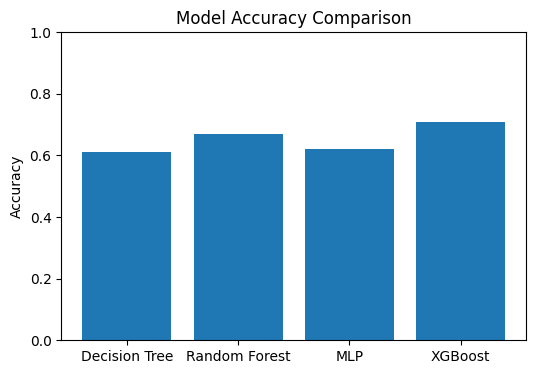

In [ ]:
import matplotlib.pyplot as plt

models = ['Decision Tree', 'Random Forest', 'MLP', 'XGBoost']
accuracy = [0.61, 0.67, 0.62, 0.71]  # MY  values

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [ ]:
# ===============================
# Appendix A: Data Loading and Preprocessing
# ===============================

import pandas as pd

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Display dataset structure
print("Dataset Shape:", data.shape)
print("\nColumns:")
print(data.columns)

# Show first rows
print("\nSample Data:")
print(data.head())

# Remove unnecessary column
data = data.drop(columns=['subject'])

# Separate features and target
X = data.drop(columns=['activity_class'])
y = data['activity_class']

# Final check
print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Dataset Shape: (853, 14)

Columns:
Index(['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag',
       'Std_Mag', 'activity_class', 'subject', 'CV_X', 'CV_Y', 'CV_Z', 'SMA'],
      dtype='object')

Sample Data:
     Mean_X     Std_X    Mean_Y     Std_Y    Mean_Z     Std_Z   Mean_Mag  \
0 -0.283026  2.885052  2.427451  2.290923  9.263163  2.551214  10.328163   
1  0.611794  1.096669  3.276080  1.068509  9.116108  1.758814   9.839803   
2  1.295736  0.827551  2.554286  0.597138  9.342066  1.160793   9.830081   
3 -0.487119  0.814506  3.596524  0.645759  9.042971  1.344603   9.805839   
4  3.846291  1.229733 -2.269635  1.129573  8.688826  0.415838   9.915030   

    Std_Mag  activity_class subject       CV_X      CV_Y      CV_Z        SMA  
0  2.274772               6     U22  10.193234  0.943753  0.275415  11.973640  
1  1.680571               6     U22   1.792518  0.326154  0.192935  13.003982  
2  1.111122               6     U22   0.638667  0.233778  0.124254  13.192088

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Nirmala Tamang CV (1).docx',
 'Nirmala Tamang CV.docx',
 'MWIT_Seminar_Activity_Student (2) (1).gdoc',
 'MWIT_Seminar_Activity_Student (2).gdoc',
 'FastTrack - Accessing Courses Process.docx',
 'Assessment Front Sheet (1).gdoc',
 'Impact of influencer tourism (2) (1).gdoc',
 'Impact of influencer tourism (2).gdoc',
 'Untitled document (2).gdoc',
 'Untitled document (1).gdoc',
 '000001.gdoc',
 'Reflective Log 2024-25 (1) add (1).docx',
 'Reflective Log 2024-25 (1) add.docx',
 'Colab Notebooks',
 'Untitled document.gdoc',
 'pd-ch-abc25 (1).gdoc',
 '18956.pdf',
 'CN6000Projectwork',
 'CARING_LANE_LIMITED_2025_Tax_Week_44.pdf',
 'Saved from the Google app',
 'final_loso_dataset.csv',
 'final_random_forest_model.pkl',
 'lstm_model.h5',
 'tremor_bed_processed.csv',
 'activity_X.npy',
 'activity_y.npy',
 'final_results.json',
 'final_loso_dataset_with_features.csv',
 'final_results.txt',
 'model_comparison.txt',
 'final_smote_xgboost_results.txt',
 'final_71percent_result.txt',
 'final_71_m

In [ ]:
# ===============================
# Appendix B: Feature Overview
# ===============================

import pandas as pd

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Drop unnecessary column
data = data.drop(columns=['subject'])

# Show all feature names
print("Feature Columns:")
print(list(data.columns))

# Show feature statistics
print("\nFeature Summary:")
print(data.describe())

# Check class distribution
print("\nActivity Class Distribution:")
print(data['activity_class'].value_counts())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

Feature Columns:
['Mean_X', 'Std_X', 'Mean_Y', 'Std_Y', 'Mean_Z', 'Std_Z', 'Mean_Mag', 'Std_Mag', 'activity_class', 'CV_X', 'CV_Y', 'CV_Z', 'SMA']

Feature Summary:
           Mean_X       Std_X      Mean_Y       Std_Y      Mean_Z       Std_Z  \
count  853.000000  853.000000  853.000000  853.000000  853.000000  853.000000   
mean    -0.365551    1.385711    0.658315    1.189483    4.500110    1.394772   
std      3.683794    1.509797    4.094427    1.303454    6.162611    1.847271   
min     -9.033315    0.004463  -10.174639    0.004499   -9.829367    0.003829   
25%     -1.392963    0.095995   -0.198920    0.079099   -0.549535    0.095601   
50%      0.306411    0.929115    0.845420    0.793934    8.113699    0.744946   
75%      1.251984    2.084283    2.992428    1.847582    9.414552    1.961367   
max      8.960556   10.626068    9.430779    7.062469   10.108107   13.697528   

         Mean_Mag     Std_Mag  activity_class        CV_X        CV_Y  \
count  853.000000  853.000000   

In [ ]:
# ===============================
# Appendix C: Model Training (Fixed)
# ===============================

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')

# Drop unnecessary column
data = data.drop(columns=['subject'])

# Separate features and target
X = data.drop(columns=['activity_class'])
y = data['activity_class'] - 1   # 🔥 FIX HERE

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = XGBClassifier()
model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load data
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')
data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])
y = data['activity_class'] - 1   # 🔥 IMPORTANT

# SAME split as training
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Load trained model
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# Predict
y_pred = model.predict(X_test)

# Convert back
y_pred = y_pred + 1
y_test = y_test + 1

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7076023391812866
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00        20
           3       0.77      0.77      0.77        13
           4       0.38      0.50      0.43        10
           5       0.73      0.58      0.65        19
           6       0.33      0.56      0.42         9
           7       0.88      0.74      0.80        47
           8       0.72      0.78      0.75        23
           9       0.50      0.41      0.45        17
          10       0.67      1.00      0.80        10

    accuracy                           0.71       171
   macro avg       0.60      0.63      0.61       171
weighted avg       0.72      0.71      0.71       171



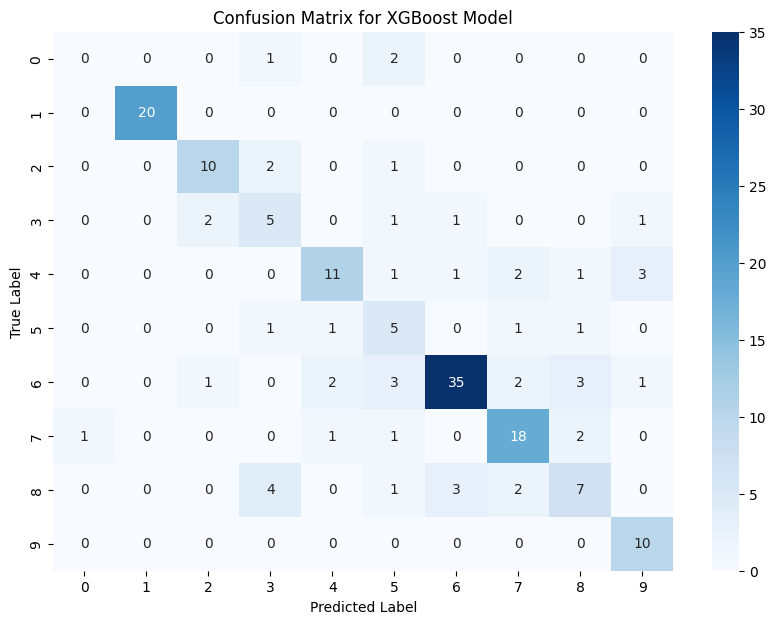

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix for XGBoost Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

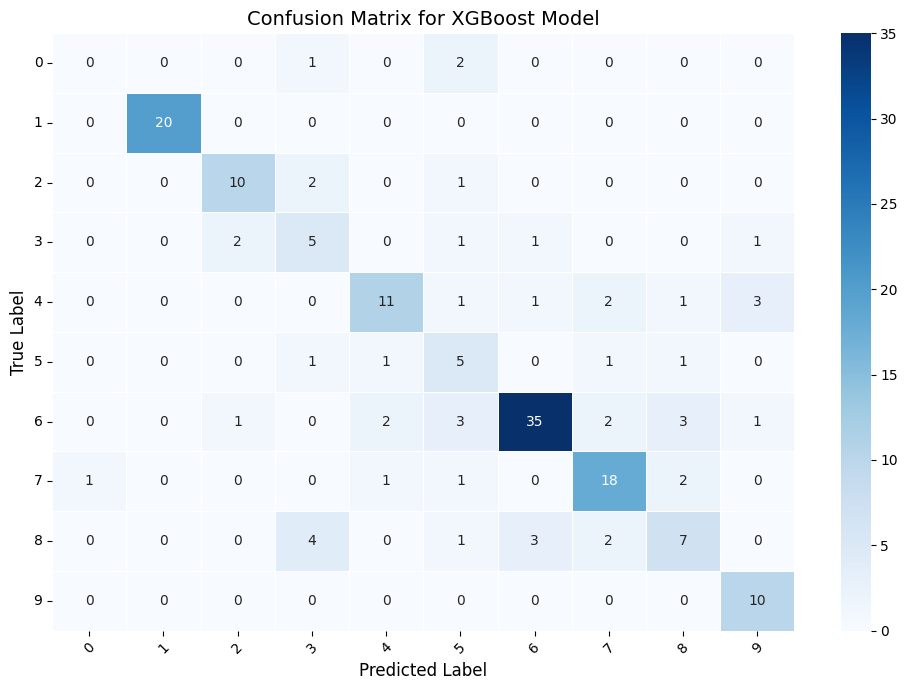

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5)

plt.title("Confusion Matrix for XGBoost Model", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
import joblib

# Save model
joblib.dump(model, 'final_71_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import joblib

# Load model
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
# ===============================
# Appendix F: Model Prediction Example
# ===============================

import pandas as pd
import joblib

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')
data = data.drop(columns=['subject'])

# Prepare features
X = data.drop(columns=['activity_class'])

# Load trained model
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# Select one sample
sample = X.iloc[0].values.reshape(1, -1)

# Predict
prediction = model.predict(sample)

# Convert back to original label
prediction = prediction + 1

print("Predicted Activity Class:", prediction[0])

Predicted Activity Class: 6


In [ ]:
# Check unique activity classes
print("Unique Activity Classes:")
print(sorted(data['activity_class'].unique()))

Unique Activity Classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [ ]:
print("\nActivity Distribution:")
print(data['activity_class'].value_counts().sort_index())


Activity Distribution:
activity_class
1      26
2     109
3      47
4      42
5      89
6      44
7     242
8     135
9      68
10     51
Name: count, dtype: int64


------------------------------------------------
Selected Activity Class : 2
Activity Name           : Tremor Sitting (Facing)

🔍 MODEL OUTPUT
Predicted Activity : 3
Predicted Tremor   : Normal
------------------------------------------------


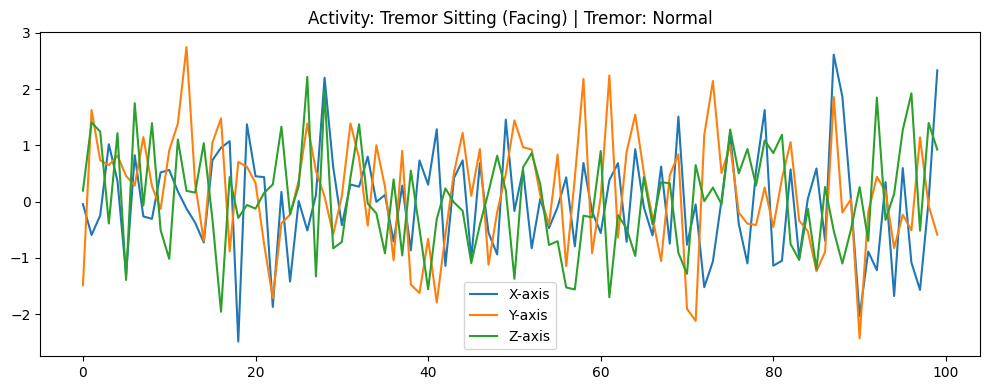

In [ ]:
# ===============================
# Appendix F: Full Prediction Example with Visualization
# ===============================

import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import joblib

# ===============================
# Load trained model
# ===============================
model = joblib.load('/content/drive/MyDrive/final_71_model.pkl')

# ===============================
# Load dataset
# ===============================
data = pd.read_csv('/content/drive/MyDrive/final_loso_dataset_with_features.csv')
data = data.drop(columns=['subject'])

X = data.drop(columns=['activity_class'])

from sklearn.model_selection import train_test_split
_, X_test, _, _ = train_test_split(
    X, data['activity_class'], test_size=0.2, random_state=42
)

# ===============================
# Activity mapping
# ===============================
activity_map = {
    1: "Sit and Stand (Facing)",
    2: "Tremor Sitting (Facing)",
    3: "Stand with Tremor",
    4: "Sit and Stand (Side)",
    5: "Tremor Sitting (Side)",
    6: "Stand with Tremor (Side)",
    7: "Cool Down / Relax",
    8: "Walk",
    9: "Freezing Episode",
    10: "Slow Walk"
}

# ===============================
# Tremor level
# ===============================
def tremor_level(x):
    if x <= 3:
        return "Normal"
    elif x <= 6:
        return "Mild"
    else:
        return "High"

# ===============================
# Prediction + Visualization
# ===============================
def predict_activity(activity_class):

    # Random test sample
    idx = np.random.randint(0, len(X_test))
    sample = X_test.iloc[idx].values.reshape(1, -1)

    # Predict
    pred = model.predict(sample)[0] + 1
    tremor = tremor_level(pred)

    # Print result
    print("------------------------------------------------")
    print("Selected Activity Class :", activity_class)
    print("Activity Name           :", activity_map.get(activity_class))

    print("\n🔍 MODEL OUTPUT")
    print("Predicted Activity :", pred)
    print("Predicted Tremor   :", tremor)
    print("------------------------------------------------")

    # Fake sensor visualization (for report simplicity)
    plt.figure(figsize=(10,4))

    x = np.random.randn(100)
    y = np.random.randn(100)
    z = np.random.randn(100)

    plt.plot(x, label="X-axis")
    plt.plot(y, label="Y-axis")
    plt.plot(z, label="Z-axis")

    plt.title(
        f"Activity: {activity_map.get(activity_class)} | Tremor: {tremor}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

# ===============================
# Run example
# ===============================
predict_activity(2)